# Imports and Paths


In [62]:
# Imports

import json
import os
from pathlib import Path

import cv2
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

from IPython.display import Image as DisplayImage, Video, display
from PIL import Image, ImageDraw
from tqdm.auto import tqdm


In [63]:
# Paths

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

LUNAR_EXPERT_VIDEO_DIR = PROJECT_ROOT / "lunarlander_expert" / "videos" / "expert_pretrain"

ARTIFACTS_DIR = NOTEBOOKS_DIR / "artifacts"
PRETRAIN_DIR = ARTIFACTS_DIR / "lunarlander_pretrain"

CONTROL_POINTS_DIR = PRETRAIN_DIR / "control_points"
BACKGROUND_POINTS_DIR = PRETRAIN_DIR / "background_points"
ACTION_EMBEDDINGS_DIR = PRETRAIN_DIR / "action_embeddings"
TOKENS_DIR = PRETRAIN_DIR / "tokens"
PLOTS_DIR = PRETRAIN_DIR / "plots"
MODELS_DIR = PRETRAIN_DIR / "models"
LOGS_DIR = PRETRAIN_DIR / "logs"
GENERATED_VIDEO_DIR = PLOTS_DIR / "videos"

N_PRETRAIN_VIDEOS = 500
MAX_FRAMES_PER_EPISODE = 80

for path in [
    ARTIFACTS_DIR,
    PRETRAIN_DIR,
    CONTROL_POINTS_DIR,
    BACKGROUND_POINTS_DIR,
    ACTION_EMBEDDINGS_DIR,
    TOKENS_DIR,
    PLOTS_DIR,
    MODELS_DIR,
    LOGS_DIR,
    GENERATED_VIDEO_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

lunar_video_paths = sorted(LUNAR_EXPERT_VIDEO_DIR.glob("*.mp4"))[:N_PRETRAIN_VIDEOS]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LUNAR_EXPERT_VIDEO_DIR:", LUNAR_EXPERT_VIDEO_DIR)
print("num lunar videos:", len(lunar_video_paths))
print("PRETRAIN_DIR:", PRETRAIN_DIR)

if len(lunar_video_paths) == 0:
    raise FileNotFoundError(
        f"No Lunar Lander expert videos found in {LUNAR_EXPERT_VIDEO_DIR}. "
        "Generate or move .mp4 files there first."
    )


PROJECT_ROOT: /Users/adriankazi/Desktop/Action Inference
LUNAR_EXPERT_VIDEO_DIR: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_pretrain
num lunar videos: 500
PRETRAIN_DIR: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain


In [64]:
# Video helpers

def read_video(path, max_frames=None, stride=1, start_frame=0):
    cap = cv2.VideoCapture(str(path))

    if start_frame:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))

    frames_out = []
    frame_no = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_no % stride == 0:
            frames_out.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            if max_frames is not None and len(frames_out) >= max_frames:
                break

        frame_no += 1

    cap.release()

    if not frames_out:
        raise RuntimeError(f"No frames read from {path}")

    return np.stack(frames_out)


def sample_even_frame_indices(num_frames, max_frames):
    if num_frames <= 0:
        return np.asarray([], dtype=int)

    if max_frames is None or num_frames <= max_frames:
        return np.arange(num_frames, dtype=int)

    return np.unique(
        np.linspace(0, num_frames - 1, int(max_frames), dtype=int)
    )


def read_video_even(path, max_frames=None, stride=1, return_indices=False):
    full_frames = read_video(path, max_frames=None, stride=stride)
    frame_indices = sample_even_frame_indices(len(full_frames), max_frames)
    frames = full_frames[frame_indices]

    if return_indices:
        return frames, frame_indices

    return frames


def video_frame_count(path):
    return len(read_video(path, max_frames=None, stride=1))


def clip_indices(num_frames, clip_frames=48, seed=0):
    if num_frames <= 0:
        return np.asarray([], dtype=int)

    clip_frames = min(int(clip_frames), int(num_frames))
    rng = np.random.default_rng(seed)

    max_start = max(0, int(num_frames) - clip_frames)
    start = int(rng.integers(0, max_start + 1)) if max_start else 0

    return np.arange(start, start + clip_frames, dtype=int)


def save_video(frames, path, fps=30):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    frames = frames.astype(np.uint8)
    imageio.mimsave(path, frames, fps=fps)
    return path


def show_video(frames, name, fps=30, embed=True):
    path = save_video(frames, GENERATED_VIDEO_DIR / name, fps=fps)
    display(Video(str(path), embed=embed, html_attributes="controls muted loop"))
    return path


def show_video_file(path, embed=True):
    path = Path(path)
    display(Video(str(path), embed=embed, html_attributes="controls muted loop"))
    return path

# Lunar Lander Videos


In [65]:
# Lunar Lander expert videos

random_video_path = np.random.choice(lunar_video_paths)
random_video_frames = read_video(random_video_path)

print("num lunar expert videos:", len(lunar_video_paths))
print("random video:", random_video_path)
print("random video frames:", random_video_frames.shape)

show_video_file(random_video_path, embed=True)


num lunar expert videos: 500
random video: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-167.mp4
random video frames: (199, 400, 600, 3)


PosixPath('/Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-167.mp4')

# Control Points


## Model


In [66]:
# Control Points - Model

CONTROL_POINT_NAMES = [
    "centroid",
    "axis_front",
    "axis_back",
    "axis_left",
    "axis_right",
    "contact_low",
]


def mask_to_record(mask, object_id):
    ys, xs = np.nonzero(mask)

    if len(xs) == 0:
        return None

    x1, x2 = int(xs.min()), int(xs.max()) + 1
    y1, y2 = int(ys.min()), int(ys.max()) + 1

    return {
        "object_id": object_id,
        "mask": mask,
        "box": (x1, y1, x2, y2),
        "area": int(mask.sum()),
        "centroid": (float(xs.mean()), float(ys.mean())),
    }


def largest_connected_component(mask, min_area=30):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8),
        connectivity=8,
    )

    if num_labels <= 1:
        return np.zeros_like(mask, dtype=bool)

    areas = stats[1:, cv2.CC_STAT_AREA]
    best = int(np.argmax(areas)) + 1

    if areas[best - 1] < min_area:
        return np.zeros_like(mask, dtype=bool)

    return labels == best


def lunar_lander_agent_records(frame):
    rgb = frame.astype(np.int16)
    red = rgb[:, :, 0]
    green = rgb[:, :, 1]
    blue = rgb[:, :, 2]
    brightness = rgb.mean(axis=2)
    colorfulness = np.max(rgb, axis=2) - np.min(rgb, axis=2)

    h, w = frame.shape[:2]
    yy, xx = np.indices((h, w))

    scene_window = (
        (yy < int(h * 0.82))
        & (xx > int(w * 0.12))
        & (xx < int(w * 0.88))
    )

    white_terrain = (red > 180) & (green > 180) & (blue > 180) & (colorfulness < 45)
    yellow_flags = (red > 150) & (green > 120) & (blue < 100)

    lander_body = (
        (blue > 100)
        & (red > 50)
        & (green > 45)
        & (blue > red + 15)
        & (blue > green + 10)
    )

    lander_legs = (
        (blue > 70)
        & (green > 55)
        & (red < 150)
        & (colorfulness > 25)
    )

    thruster_flame = (
        (red > 130)
        & (green < 130)
        & (blue < 170)
        & (brightness > 45)
    )

    mask = (
        scene_window
        & ~white_terrain
        & ~yellow_flags
        & (lander_body | lander_legs | thruster_flame)
    )

    mask = cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_CLOSE,
        np.ones((5, 5), dtype=np.uint8),
        iterations=1,
    ).astype(bool)

    mask = largest_connected_component(mask, min_area=20)
    record = mask_to_record(mask, 0)

    if record is None:
        return []

    record.update(
        {
            "class_id": -101,
            "class_name": "lunar_lander_agent",
            "confidence": 1.0,
            "source": "env_specific_color_geometry",
        }
    )

    return [record]


def active_agent_records(frame, model=None, conf_min=0.25, max_objects=40, scene_type="lunar_lander"):
    if scene_type == "lunar_lander":
        return lunar_lander_agent_records(frame)

    raise ValueError(f"Unsupported scene_type: {scene_type}")


def render_active_agents_inverse_background(frame, records, title=None, alpha_bg=0.35, alpha_agent=0.55):
    active_mask = np.zeros(frame.shape[:2], dtype=bool)

    for record in records:
        active_mask |= record["mask"]

    bg_mask = ~active_mask
    image = frame.copy()

    image[bg_mask] = (
        image[bg_mask] * (1 - alpha_bg)
        + np.array([40, 180, 90]) * alpha_bg
    ).astype(np.uint8)

    image[active_mask] = (
        image[active_mask] * (1 - alpha_agent)
        + np.array([230, 50, 40]) * alpha_agent
    ).astype(np.uint8)

    return image, bg_mask, active_mask


def control_points_from_record(record):
    mask = record["mask"]
    ys, xs = np.nonzero(mask)

    if len(xs) == 0:
        return []

    x1, y1, x2, y2 = record["box"]
    centroid_x, centroid_y = record["centroid"]

    front_idx = np.argmin(xs)
    back_idx = np.argmax(xs)
    left_idx = np.argmax(ys)
    right_idx = np.argmin(ys)
    contact_idx = np.argmax(ys)

    points = [
        ("centroid", centroid_x, centroid_y),
        ("axis_front", float(xs[front_idx]), float(ys[front_idx])),
        ("axis_back", float(xs[back_idx]), float(ys[back_idx])),
        ("axis_left", float(xs[left_idx]), float(ys[left_idx])),
        ("axis_right", float(xs[right_idx]), float(ys[right_idx])),
        ("contact_low", float(xs[contact_idx]), float(ys[contact_idx])),
    ]

    rows = []

    for point_name, x, y in points:
        rows.append(
            {
                "point_name": point_name,
                "x": x,
                "y": y,
                "box_x1": x1,
                "box_y1": y1,
                "box_x2": x2,
                "box_y2": y2,
                "area": record["area"],
                "class_name": record["class_name"],
                "source": record["source"],
            }
        )

    return rows



## Test


In [67]:
# Control Points - Test Video

test_video_path = np.random.choice(lunar_video_paths)
test_frames, test_frame_indices = read_video_even(
    test_video_path,
    max_frames=MAX_FRAMES_PER_EPISODE,
    return_indices=True,
)

annotated_frames = []
cp_test_rows = []

for local_frame_idx, frame in enumerate(test_frames):
    source_frame_idx = int(test_frame_indices[local_frame_idx])
    records = lunar_lander_agent_records(frame)

    cp_rows = []
    for track_id, obj in enumerate(records):
        rows = control_points_from_record(obj)

        for row in rows:
            row.update(
                {
                    "episode_id": 0,
                    "video_path": str(test_video_path),
                    "frame": source_frame_idx,
                    "local_frame": local_frame_idx,
                    "track_id": track_id,
                }
            )
            cp_test_rows.append(row)

        cp_rows.extend(rows)

    image = frame.copy()

    for row in cp_rows:
        x = int(round(row["x"]))
        y = int(round(row["y"]))

        cv2.circle(image, (x, y), 4, (255, 0, 0), -1)
        cv2.putText(
            image,
            row["point_name"],
            (x + 3, y + 3),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 255, 0),
            1,
            cv2.LINE_AA,
        )

    annotated_frames.append(image)

cp_test_df = pd.DataFrame(cp_test_rows)

print("test video:", test_video_path)
print("original frames:", video_frame_count(test_video_path))
print("sampled frames:", len(test_frames))
print("first sampled frame:", int(test_frame_indices[0]))
print("last sampled frame:", int(test_frame_indices[-1]))
print("sampled frame indices:", test_frame_indices.tolist())
print("cp_test_df:", cp_test_df.shape)

show_video(
    np.asarray(annotated_frames),
    "control_points_test_lunar_lander.mp4",
    fps=10,
    embed=True,
)

cp_test_df

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


test video: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-71.mp4
original frames: 184
sampled frames: 80
first sampled frame: 0
last sampled frame: 183
sampled frame indices: [0, 2, 4, 6, 9, 11, 13, 16, 18, 20, 23, 25, 27, 30, 32, 34, 37, 39, 41, 44, 46, 48, 50, 53, 55, 57, 60, 62, 64, 67, 69, 71, 74, 76, 78, 81, 83, 85, 88, 90, 92, 94, 97, 99, 101, 104, 106, 108, 111, 113, 115, 118, 120, 122, 125, 127, 129, 132, 134, 136, 138, 141, 143, 145, 148, 150, 152, 155, 157, 159, 162, 164, 166, 169, 171, 173, 176, 178, 180, 183]
cp_test_df: (480, 15)


,point_name,x,y,box_x1,box_y1,box_x2,box_y2,area,class_name,source,episode_id,video_path,frame,local_frame,track_id
0,centroid,299.763912,5.246206,268,0,333,15,593,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
1,axis_front,268.000000,11.000000,268,0,333,15,593,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
2,axis_back,332.000000,12.000000,268,0,333,15,593,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
3,axis_left,271.000000,14.000000,268,0,333,15,593,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
4,axis_right,273.000000,0.000000,268,0,333,15,593,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,axis_front,261.000000,297.000000,261,264,322,301,1210,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,183,79,0
476,axis_back,321.000000,298.000000,261,264,322,301,1210,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,183,79,0
477,axis_left,264.000000,300.000000,261,264,322,301,1210,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,183,79,0
478,axis_right,278.000000,264.000000,261,264,322,301,1210,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,183,79,0


## Loop


In [68]:
# Control Points - Loop over selected Lunar Lander expert videos

control_point_rows = []

for episode_id, video_path in enumerate(tqdm(lunar_video_paths, desc="control points")):
    frames, frame_indices = read_video_even(
        video_path,
        max_frames=MAX_FRAMES_PER_EPISODE,
        return_indices=True,
    )

    for local_frame_idx, frame in enumerate(frames):
        source_frame_idx = int(frame_indices[local_frame_idx])
        records = lunar_lander_agent_records(frame)

        for track_id, record in enumerate(records):
            cp_rows = control_points_from_record(record)

            for row in cp_rows:
                row.update(
                    {
                        "episode_id": episode_id,
                        "video_path": str(video_path),
                        "frame": source_frame_idx,
                        "local_frame": local_frame_idx,
                        "track_id": track_id,
                    }
                )
                control_point_rows.append(row)

lunar_cp_df = pd.DataFrame(control_point_rows)

lunar_cp_df["point_name"] = pd.Categorical(
    lunar_cp_df["point_name"],
    categories=CONTROL_POINT_NAMES,
    ordered=True,
)

lunar_cp_df = lunar_cp_df.sort_values(
    ["episode_id", "track_id", "frame", "point_name"]
).reset_index(drop=True)

print("lunar_cp_df:", lunar_cp_df.shape)
print(lunar_cp_df.head())

control points: 100%|██████████| 500/500 [10:42<00:00,  1.28s/it]


lunar_cp_df: (238158, 15)
   point_name           x         y  box_x1  box_y1  box_x2  box_y2  area  \
0    centroid  299.810403   5.20302     268       0     332      15   596   
1  axis_front  268.000000  11.00000     268       0     332      15   596   
2   axis_back  331.000000  11.00000     268       0     332      15   596   
3   axis_left  271.000000  14.00000     268       0     332      15   596   
4  axis_right  273.000000   0.00000     268       0     332      15   596   

           class_name                       source  episode_id  \
0  lunar_lander_agent  env_specific_color_geometry           0   
1  lunar_lander_agent  env_specific_color_geometry           0   
2  lunar_lander_agent  env_specific_color_geometry           0   
3  lunar_lander_agent  env_specific_color_geometry           0   
4  lunar_lander_agent  env_specific_color_geometry           0   

                                          video_path  frame  local_frame  \
0  /Users/adriankazi/Desktop/Action In

## Control Points - Visual Review

This plot checks whether the control-point extraction is stable across episodes and whether the tracked Lunar Lander control points move smoothly through the frame.

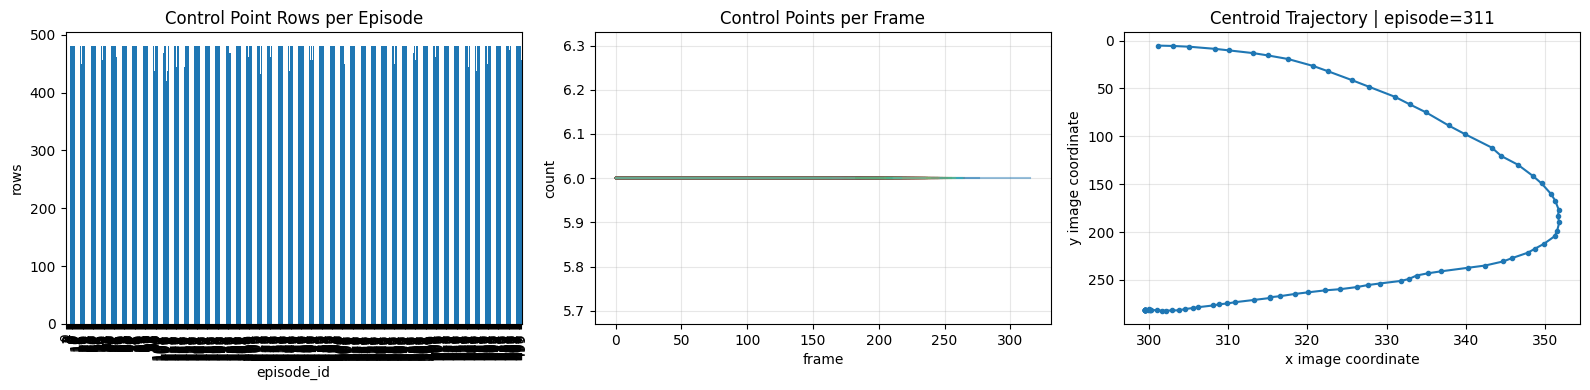

sample_episode_id: 311
control point rows per episode:
episode_id
0      480
1      480
2      480
3      480
4      480
5      480
6      480
7      480
8      480
9      480
10     480
11     480
12     462
13     480
14     480
15     456
16     480
17     450
18     480
19     480
20     480
21     480
22     480
23     480
24     480
25     480
26     480
27     480
28     480
29     480
30     480
31     480
32     480
33     462
34     480
35     480
36     480
37     480
38     480
39     480
40     456
41     480
42     480
43     480
44     480
45     480
46     480
47     480
48     480
49     474
50     480
51     480
52     480
53     480
54     480
55     462
56     480
57     480
58     426
59     462
60     480
61     450
62     480
63     480
64     480
65     480
66     480
67     480
68     456
69     480
70     480
71     480
72     480
73     480
74     480
75     480
76     480
77     480
78     480
79     480
80     480
81     480
82     480
83     480
84     480

In [69]:
# Control Points - Visual Review

cp_counts_per_episode = lunar_cp_df.groupby("episode_id").size()
cp_points_per_frame = (
    lunar_cp_df
    .groupby(["episode_id", "frame"])
    .size()
    .reset_index(name="n_control_points")
)

sample_episode_id = int(np.random.choice(sorted(lunar_cp_df["episode_id"].unique())))
sample_cp = lunar_cp_df[
    (lunar_cp_df["episode_id"] == sample_episode_id)
    & (lunar_cp_df["point_name"] == "centroid")
].sort_values("frame")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

cp_counts_per_episode.plot(kind="bar", ax=ax[0])
ax[0].set_title("Control Point Rows per Episode")
ax[0].set_xlabel("episode_id")
ax[0].set_ylabel("rows")

for episode_id, group in cp_points_per_frame.groupby("episode_id"):
    ax[1].plot(group["frame"], group["n_control_points"], alpha=0.45)
ax[1].set_title("Control Points per Frame")
ax[1].set_xlabel("frame")
ax[1].set_ylabel("count")
ax[1].grid(alpha=0.3)

ax[2].plot(sample_cp["x"], sample_cp["y"], marker="o", markersize=3)
ax[2].invert_yaxis()
ax[2].set_title(f"Centroid Trajectory | episode={sample_episode_id}")
ax[2].set_xlabel("x image coordinate")
ax[2].set_ylabel("y image coordinate")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("sample_episode_id:", sample_episode_id)
print("control point rows per episode:")
print(cp_counts_per_episode.to_string())


## Save


In [70]:
# Control Points - Save

control_points_output_path = CONTROL_POINTS_DIR / "lunar_lander_control_points.csv"

lunar_cp_df.to_csv(control_points_output_path, index=False)

print("saved:", control_points_output_path)
print("shape:", lunar_cp_df.shape)


saved: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/control_points/lunar_lander_control_points.csv
shape: (238158, 15)


# Background Segmentation


## Model


In [71]:
# Background Segmentation - Static Base Grid Model

BACKGROUND_GRID_STEP = 40
BACKGROUND_GRID_MARGIN = 20
BACKGROUND_Y_START_RATIO = 0
BACKGROUND_AGENT_DILATE_PX = 7
BACKGROUND_MAX_POINTS = 160


class BackgroundBaseGridModel:
    def __init__(
        self,
        y_start_ratio=BACKGROUND_Y_START_RATIO,
        step=BACKGROUND_GRID_STEP,
        margin=BACKGROUND_GRID_MARGIN,
        agent_dilate_px=BACKGROUND_AGENT_DILATE_PX,
        max_points=BACKGROUND_MAX_POINTS,
        scene_type="lunar_lander",
    ):
        self.y_start_ratio = float(y_start_ratio)
        self.step = int(step)
        self.margin = int(margin)
        self.agent_dilate_px = int(agent_dilate_px)
        self.max_points = None if max_points is None else int(max_points)
        self.scene_type = scene_type

    def agent_records(self, frame):
        return active_agent_records(frame, scene_type=self.scene_type)

    def agent_inverse_mask(self, frame, records=None):
        if records is None:
            records = self.agent_records(frame)

        active_mask = np.zeros(frame.shape[:2], dtype=bool)
        for record in records:
            active_mask |= record["mask"]

        if self.agent_dilate_px > 0:
            kernel = np.ones(
                (2 * self.agent_dilate_px + 1, 2 * self.agent_dilate_px + 1),
                dtype=np.uint8,
            )
            active_mask = cv2.dilate(
                active_mask.astype(np.uint8),
                kernel,
                iterations=1,
            ).astype(bool)

        return ~active_mask, active_mask, records

    def lower_base_mask(self, frame, background_mask):
        return background_mask

    def make_base_grid_points(self, base_mask):
        h, w = base_mask.shape
        points = []

        for y in range(self.margin, h - self.margin, self.step):
            for x in range(self.margin, w - self.margin, self.step):
                if base_mask[y, x]:
                    points.append((float(x), float(y)))

        points = np.asarray(points, dtype=np.float32).reshape(-1, 2)

        if self.max_points is not None and len(points) > self.max_points:
            keep_idx = np.linspace(0, len(points) - 1, self.max_points, dtype=int)
            points = points[keep_idx]

        return points

    def fit_base_grid(self, frame):
        background_mask, active_mask, records = self.agent_inverse_mask(frame)
        base_mask = self.lower_base_mask(frame, background_mask)
        points = self.make_base_grid_points(base_mask)
        point_ids = np.arange(len(points), dtype=int)
        return {
            "base_mask": base_mask,
            "background_mask": background_mask,
            "active_mask": active_mask,
            "records": records,
            "points": points,
            "point_ids": point_ids,
        }

    def valid_points_for_frame(self, frame, points):
        background_mask, active_mask, records = self.agent_inverse_mask(frame)

        if len(points) == 0:
            valid = np.zeros(0, dtype=bool)
        else:
            h, w = background_mask.shape
            x = np.clip(np.rint(points[:, 0]).astype(int), 0, w - 1)
            y = np.clip(np.rint(points[:, 1]).astype(int), 0, h - 1)
            valid = background_mask[y, x]

        return valid, background_mask, active_mask, records

    def build_rows(self, frames, source_indices, episode_id=None, video_path=None):
        source_indices = np.asarray(source_indices, dtype=int)
        base = self.fit_base_grid(frames[0])
        points = base["points"]
        point_ids = base["point_ids"]
        last_valid_xy = {}
        rows = []

        for frame, source_frame in zip(frames, source_indices):
            valid, _, _, _ = self.valid_points_for_frame(frame, points)

            for point_id, (x, y), is_valid in zip(point_ids, points, valid):
                if not bool(is_valid):
                    continue

                prev = last_valid_xy.get(int(point_id))
                prev_valid = prev is not None
                dx = float(x - prev[0]) if prev_valid else np.nan
                dy = float(y - prev[1]) if prev_valid else np.nan
                speed = float(np.sqrt(dx ** 2 + dy ** 2)) if prev_valid else np.nan

                row = {
                    "frame": int(source_frame),
                    "background_point_id": int(point_id),
                    "x": float(x),
                    "y": float(y),
                    "dx": dx,
                    "dy": dy,
                    "speed": speed,
                    "valid": True,
                    "prev_valid": bool(prev_valid),
                }

                if episode_id is not None:
                    row["episode_id"] = int(episode_id)
                if video_path is not None:
                    row["video_path"] = str(video_path)

                rows.append(row)
                last_valid_xy[int(point_id)] = (float(x), float(y))

        return rows, base

    def render(self, frame, base_mask, active_mask, points, title="Background base grid"):
        image = frame.copy()
        image[base_mask] = (
            image[base_mask] * 0.55 + np.array([40, 180, 90]) * 0.45
        ).astype(np.uint8)
        image[active_mask] = (
            image[active_mask] * 0.45 + np.array([230, 50, 40]) * 0.55
        ).astype(np.uint8)

        plt.figure(figsize=(8, 5))
        plt.imshow(image)
        if len(points):
            plt.scatter(
                points[:, 0],
                points[:, 1],
                s=12,
                c="yellow",
                edgecolors="black",
                linewidths=0.3,
            )
        plt.title(title)
        plt.axis("off")
        plt.show()


background_base_grid_model = BackgroundBaseGridModel()


def surface_grid_background_mask(frame, scene_type="lunar_lander"):
    model = background_base_grid_model
    if scene_type != model.scene_type:
        model = BackgroundBaseGridModel(scene_type=scene_type)
    background_mask, active_mask, records = model.agent_inverse_mask(frame)
    base_mask = model.lower_base_mask(frame, background_mask)
    return base_mask, active_mask, records


def track_surface_grid_points(
    frames,
    frame_indices=None,
    step=None,
    scene_type="lunar_lander",
    source_indices=None,
    keep_source_frames=None,
):
    if source_indices is None:
        source_indices = frame_indices
    if source_indices is None:
        source_indices = np.arange(len(frames), dtype=int)

    model = background_base_grid_model
    if step is not None and int(step) != model.step:
        model = BackgroundBaseGridModel(
            y_start_ratio=model.y_start_ratio,
            step=int(step),
            margin=model.margin,
            agent_dilate_px=model.agent_dilate_px,
            max_points=model.max_points,
            scene_type=scene_type,
        )

    if keep_source_frames is not None:
        keep_source_frames = set(int(x) for x in keep_source_frames)
        keep = [int(idx) in keep_source_frames for idx in source_indices]
        frames = np.asarray(frames)[keep]
        source_indices = np.asarray(source_indices, dtype=int)[keep]

    rows, _ = model.build_rows(frames, source_indices)
    return rows


def tracks_to_background_dataframe(tracks, episode_id, video_path):
    df = pd.DataFrame(tracks)
    expected_columns = [
        "episode_id",
        "video_path",
        "frame",
        "background_point_id",
        "x",
        "y",
        "dx",
        "dy",
        "speed",
        "valid",
        "prev_valid",
    ]

    if df.empty:
        return pd.DataFrame(columns=expected_columns)

    if "episode_id" not in df.columns:
        df.insert(0, "episode_id", int(episode_id))
    if "video_path" not in df.columns:
        df.insert(1, "video_path", str(video_path))

    return df[expected_columns]


def build_background_points_for_video(video_path, episode_id, max_frames=MAX_FRAMES_PER_EPISODE):
    frames, frame_indices = read_video_even(
        video_path,
        max_frames=max_frames,
        return_indices=True,
    )

    rows, _ = background_base_grid_model.build_rows(
        frames,
        frame_indices,
        episode_id=episode_id,
        video_path=video_path,
    )

    episode_bckg_df = pd.DataFrame(rows)
    if episode_bckg_df.empty:
        episode_bckg_df = tracks_to_background_dataframe([], episode_id, video_path)
    else:
        episode_bckg_df = episode_bckg_df[
            [
                "episode_id",
                "video_path",
                "frame",
                "background_point_id",
                "x",
                "y",
                "dx",
                "dy",
                "speed",
                "valid",
                "prev_valid",
            ]
        ].sort_values(["episode_id", "frame", "background_point_id"]).reset_index(drop=True)

    return episode_bckg_df, int(video_frame_count(video_path)), int(len(frame_indices))


def show_surface_grid_tracking_experiment(
    frames,
    frame_idx,
    title,
    video_name="surface_grid_tracking.mp4",
    scene_type="lunar_lander",
    source_indices=None,
):
    if source_indices is None:
        source_indices = np.arange(len(frames), dtype=int)

    rows, base = background_base_grid_model.build_rows(frames, source_indices)
    df = pd.DataFrame(rows)

    frame_source = int(frame_idx)
    review_df = df[df["frame"] == frame_source] if not df.empty else pd.DataFrame()

    source_list = list(map(int, source_indices))
    local_idx = source_list.index(frame_source) if frame_source in source_list else 0
    background_base_grid_model.render(
        frames[local_idx],
        base["base_mask"],
        base["active_mask"],
        base["points"],
        title=title,
    )

    annotated_frames = []
    for image, source_frame in zip(frames, source_indices):
        image = image.copy()
        frame_df = df[df["frame"] == int(source_frame)] if not df.empty else pd.DataFrame()

        for _, row in frame_df.iterrows():
            x = int(round(row["x"]))
            y = int(round(row["y"]))
            cv2.circle(image, (x, y), 2, (235, 70, 50), -1)

        cv2.putText(
            image,
            f"frame {int(source_frame)} | ids {len(frame_df)}",
            (12, 24),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )
        annotated_frames.append(image)

    show_video(np.stack(annotated_frames), video_name, fps=30, embed=True)

    summary = pd.DataFrame([
        {
            "frame": frame_source,
            "base_region": "lower image inverse-agent mask",
            "base_grid_points": int(len(base["points"])),
            "visible_points": int(len(review_df)),
            "y_start_ratio": background_base_grid_model.y_start_ratio,
            "step": background_base_grid_model.step,
            "max_points": background_base_grid_model.max_points,
        }
    ])

    display(summary)
    display(review_df.head(30))

    return rows, frames, {"frame_df": review_df, "all_points_df": df, "summary": summary}


In [72]:
# Background Segmentation model is defined above; run the test cell next.


## Test


test video: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-232.mp4
original frames: 163
sampled frames: (80, 400, 600, 3)
first sampled frame: 0
last sampled frame: 162
frame_idx: 20


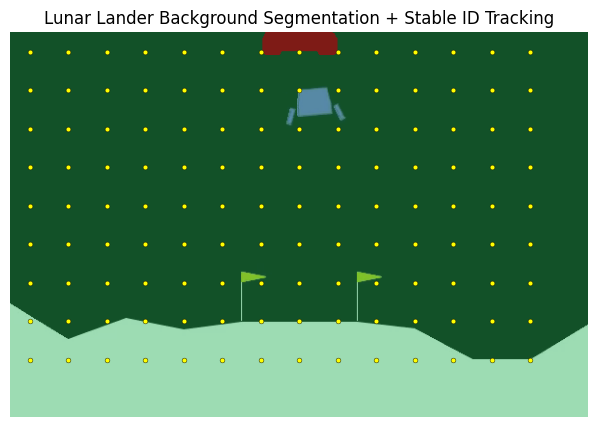

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


,frame,base_region,base_grid_points,visible_points,y_start_ratio,step,max_points
0,20,lower image inverse-agent mask,126,125,0.0,40,160


,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
1244,20,0,20.0,20.0,0.0,0.0,0.0,True,True
1245,20,1,60.0,20.0,0.0,0.0,0.0,True,True
1246,20,2,100.0,20.0,0.0,0.0,0.0,True,True
1247,20,3,140.0,20.0,0.0,0.0,0.0,True,True
1248,20,4,180.0,20.0,0.0,0.0,0.0,True,True
1249,20,5,220.0,20.0,0.0,0.0,0.0,True,True
1250,20,6,260.0,20.0,0.0,0.0,0.0,True,True
1251,20,7,300.0,20.0,0.0,0.0,0.0,True,True
1252,20,8,340.0,20.0,0.0,0.0,0.0,True,True
1253,20,9,380.0,20.0,0.0,0.0,0.0,True,True


In [73]:
# Background Segmentation - Test on One Video

test_video_path = np.random.choice(lunar_video_paths)
frames, frame_indices = read_video_even(
    test_video_path,
    max_frames=MAX_FRAMES_PER_EPISODE,
    return_indices=True,
)
frame_idx = int(frame_indices[min(10, len(frame_indices) - 1)])

print("test video:", test_video_path)
print("original frames:", video_frame_count(test_video_path))
print("sampled frames:", frames.shape)
print("first sampled frame:", int(frame_indices[0]))
print("last sampled frame:", int(frame_indices[-1]))
print("frame_idx:", frame_idx)

bg_surface_grid_1_lunar_tracks, bg_surface_grid_1_lunar_frames, bg_surface_grid_1_lunar_data = show_surface_grid_tracking_experiment(
    frames,
    frame_idx,
    "Lunar Lander Background Segmentation + Stable ID Tracking",
    video_name="surface_grid_1_lunar_pretrain_test.mp4",
    scene_type="lunar_lander",
    source_indices=frame_indices,
)


Check df for background points shape for 1 episode.

In [74]:
# Background Points - Test DF for the same random episode

bg_test_df = tracks_to_background_dataframe(
    bg_surface_grid_1_lunar_tracks,
    episode_id=0,
    video_path=test_video_path,
)

print("test video:", test_video_path)
print("bg_test_df shape:", bg_test_df.shape)
print("frames:", bg_test_df["frame"].nunique())
print("background ids:", bg_test_df["background_point_id"].nunique())
display(bg_test_df.head(20))


test video: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-232.mp4
bg_test_df shape: (9922, 11)
frames: 80
background ids: 126


,episode_id,video_path,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,20.0,20.0,NaN,NaN,NaN,True,False
1,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,1,60.0,20.0,NaN,NaN,NaN,True,False
2,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,2,100.0,20.0,NaN,NaN,NaN,True,False
3,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,3,140.0,20.0,NaN,NaN,NaN,True,False
4,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,4,180.0,20.0,NaN,NaN,NaN,True,False
5,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,5,220.0,20.0,NaN,NaN,NaN,True,False
6,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,6,260.0,20.0,NaN,NaN,NaN,True,False
7,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,7,300.0,20.0,NaN,NaN,NaN,True,False
8,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,8,340.0,20.0,NaN,NaN,NaN,True,False
9,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,9,380.0,20.0,NaN,NaN,NaN,True,False


## Loop + Save

In [75]:
# Background Points - Loop + Save Per Episode

background_output_paths = []
episode_summaries = []

for episode_id, video_path in enumerate(tqdm(lunar_video_paths, desc="background points")):
    episode_bckg_df, n_full_frames, n_sampled_frames = build_background_points_for_video(
        video_path,
        episode_id=episode_id,
        max_frames=MAX_FRAMES_PER_EPISODE,
    )

    episode_output_path = (
        BACKGROUND_POINTS_DIR
        / f"lunar_lander_background_points_episode_{episode_id:04d}.csv"
    )

    # Save only sampled, valid background IDs and motion columns used downstream.
    episode_bckg_df.to_csv(episode_output_path, index=False)
    background_output_paths.append(episode_output_path)

    episode_summary = {
        "episode_id": int(episode_id),
        "full_frames": int(n_full_frames),
        "sampled_frames": int(n_sampled_frames),
        "saved_rows": int(len(episode_bckg_df)),
        "background_ids": int(episode_bckg_df["background_point_id"].nunique()),
        "points_per_frame_mean": float(episode_bckg_df.groupby("frame").size().mean()) if len(episode_bckg_df) else 0.0,
    }
    episode_summaries.append(episode_summary)

    print(
        f"episode {episode_id + 1}/{len(lunar_video_paths)} | "
        f"full frames {n_full_frames} | "
        f"sampled {n_sampled_frames} | "
        f"rows {len(episode_bckg_df)} | "
        f"ids {episode_summary['background_ids']} | "
        f"saved {episode_output_path.name}"
    )


print("saved episode files:", len(background_output_paths))
print("directory:", BACKGROUND_POINTS_DIR)

lunar_bckg_df = pd.concat(
    [pd.read_csv(path) for path in background_output_paths],
    ignore_index=True,
)

lunar_bckg_df = lunar_bckg_df.sort_values(
    ["episode_id", "frame", "background_point_id"]
).reset_index(drop=True)

lunar_bckg_df_reduced = lunar_bckg_df.copy()
lunar_bckg_df_selected = lunar_bckg_df_reduced.copy()

background_episode_summary_df = pd.DataFrame(episode_summaries)

print("background shape:", lunar_bckg_df.shape)
print("episodes:", lunar_bckg_df["episode_id"].nunique())
display(background_episode_summary_df.head(20))
display(lunar_bckg_df.head(20))


background points:   0%|          | 1/500 [00:01<12:10,  1.46s/it]

episode 1/500 | full frames 170 | sampled 80 | rows 9952 | ids 126 | saved lunar_lander_background_points_episode_0000.csv


background points:   0%|          | 2/500 [00:02<12:15,  1.48s/it]

episode 2/500 | full frames 207 | sampled 80 | rows 9940 | ids 126 | saved lunar_lander_background_points_episode_0001.csv


background points:   1%|          | 3/500 [00:04<11:55,  1.44s/it]

...

background points: 100%|██████████| 500/500 [11:49<00:00,  1.42s/it]

episode 500/500 | full frames 264 | sampled 80 | rows 9953 | ids 126 | saved lunar_lander_background_points_episode_0499.csv
saved episode files: 500
directory: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/background_points


background shape: (4958872, 11)
episodes: 500


,episode_id,full_frames,sampled_frames,saved_rows,background_ids,points_per_frame_mean
0,0,170,80,9952,126,124.4000
1,1,207,80,9940,126,124.2500
2,2,186,80,9941,126,124.2625
3,3,166,80,9861,125,123.2625
4,4,229,80,9947,126,124.3375
5,5,167,80,9849,125,123.1125
6,6,186,80,9861,125,123.2625
7,7,198,80,9939,126,124.2375
8,8,205,80,9826,125,122.8250
9,9,238,80,9913,126,123.9125


,episode_id,video_path,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,20.0,20.0,NaN,NaN,NaN,True,False
1,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,1,60.0,20.0,NaN,NaN,NaN,True,False
2,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,2,100.0,20.0,NaN,NaN,NaN,True,False
3,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,3,140.0,20.0,NaN,NaN,NaN,True,False
4,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,4,180.0,20.0,NaN,NaN,NaN,True,False
5,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,5,220.0,20.0,NaN,NaN,NaN,True,False
6,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,6,260.0,20.0,NaN,NaN,NaN,True,False
7,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,7,300.0,20.0,NaN,NaN,NaN,True,False
8,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,8,340.0,20.0,NaN,NaN,NaN,True,False
9,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,9,380.0,20.0,NaN,NaN,NaN,True,False


## Background Points - Visual Review

This plot checks the scale of generated background rows per episode and verifies that the optical-flow background grid has a stable number of points through time.

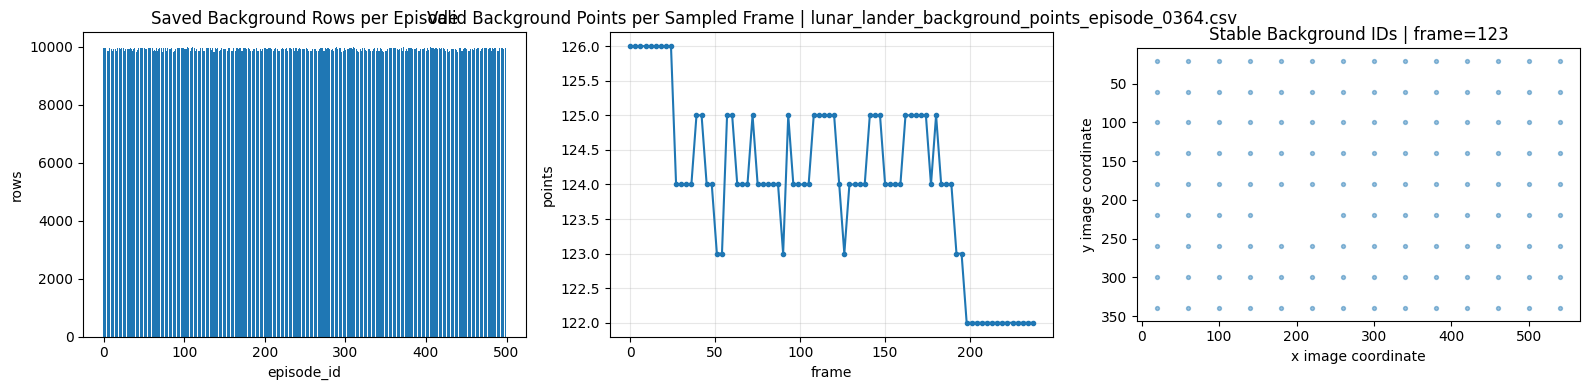

       episode_id         rows  frames  background_ids  points_per_frame_mean
count  500.000000   500.000000   500.0      500.000000             500.000000
mean   249.500000  9917.744000    80.0      125.716000             123.971800
std    144.481833    42.929995     0.0        0.451388               0.536625
min      0.000000  9817.000000    80.0      125.000000             122.712500
25%    124.750000  9868.750000    80.0      125.000000             123.359375
50%    249.500000  9936.000000    80.0      126.000000             124.200000
75%    374.250000  9949.000000    80.0      126.000000             124.362500
max    499.000000  9996.000000    80.0      126.000000             124.950000


In [76]:
# Background Points - Visual Review

background_file_shapes = []
for path in background_output_paths:
    episode_df = pd.read_csv(path)
    background_file_shapes.append(
        {
            "episode_file": path.name,
            "episode_id": int(episode_df["episode_id"].iloc[0]),
            "rows": len(episode_df),
            "frames": episode_df["frame"].nunique(),
            "background_ids": episode_df["background_point_id"].nunique(),
            "points_per_frame_mean": episode_df.groupby("frame").size().mean(),
        }
    )

background_file_shapes_df = pd.DataFrame(background_file_shapes)
sample_background_path = np.random.choice(background_output_paths)
sample_background_df = pd.read_csv(sample_background_path)
sample_counts = sample_background_df.groupby("frame").size()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].bar(background_file_shapes_df["episode_id"], background_file_shapes_df["rows"])
ax[0].set_title("Saved Background Rows per Episode")
ax[0].set_xlabel("episode_id")
ax[0].set_ylabel("rows")

ax[1].plot(sample_counts.index, sample_counts.values, marker="o", markersize=3)
ax[1].set_title(f"Valid Background Points per Sampled Frame | {Path(sample_background_path).name}")
ax[1].set_xlabel("frame")
ax[1].set_ylabel("points")
ax[1].grid(alpha=0.3)

sample_frame = int(np.random.choice(sample_background_df["frame"].unique()))
sample_frame_bckg = sample_background_df[sample_background_df["frame"] == sample_frame]
ax[2].scatter(sample_frame_bckg["x"], sample_frame_bckg["y"], s=8, alpha=0.45)
ax[2].invert_yaxis()
ax[2].set_title(f"Stable Background IDs | frame={sample_frame}")
ax[2].set_xlabel("x image coordinate")
ax[2].set_ylabel("y image coordinate")
ax[2].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

print(background_file_shapes_df.describe().to_string())


# Data Review

In [77]:
background_paths = sorted(
    BACKGROUND_POINTS_DIR.glob("lunar_lander_background_points_episode_*.csv")
)

lunar_bckg_df = pd.concat(
    [pd.read_csv(path) for path in background_paths],
    ignore_index=True,
)

control_points_path = CONTROL_POINTS_DIR / "lunar_lander_control_points.csv"
lunar_cp_df = pd.read_csv(control_points_path)

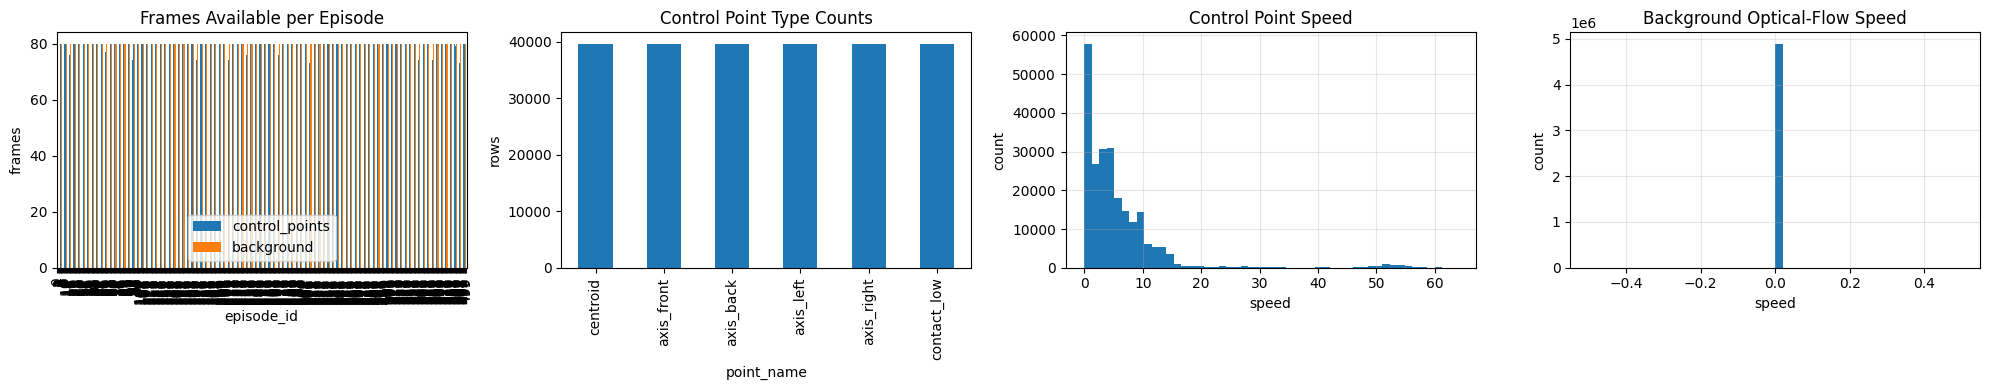

In [78]:
# Data Review - Visual Sanity Check

cp_frames = lunar_cp_df.groupby("episode_id")["frame"].nunique()
bckg_frames = lunar_bckg_df.groupby("episode_id")["frame"].nunique()

cp_motion = lunar_cp_df.sort_values(
    ["episode_id", "track_id", "point_name", "frame"]
).copy()

cp_motion["dx"] = cp_motion.groupby(
    ["episode_id", "track_id", "point_name"]
)["x"].diff()

cp_motion["dy"] = cp_motion.groupby(
    ["episode_id", "track_id", "point_name"]
)["y"].diff()

cp_motion["speed"] = np.sqrt(
    cp_motion["dx"] ** 2 + cp_motion["dy"] ** 2
)

fig, ax = plt.subplots(1, 4, figsize=(20, 4))

pd.DataFrame({
    "control_points": cp_frames,
    "background": bckg_frames,
}).plot(kind="bar", ax=ax[0])

ax[0].set_title("Frames Available per Episode")
ax[0].set_xlabel("episode_id")
ax[0].set_ylabel("frames")

lunar_cp_df["point_name"].value_counts().reindex(
    CONTROL_POINT_NAMES
).plot(kind="bar", ax=ax[1])

ax[1].set_title("Control Point Type Counts")
ax[1].set_xlabel("point_name")
ax[1].set_ylabel("rows")

cp_speed_sample = cp_motion["speed"].replace(
    [np.inf, -np.inf], np.nan
).dropna()

ax[2].hist(cp_speed_sample, bins=50)
ax[2].set_title("Control Point Speed")
ax[2].set_xlabel("speed")
ax[2].set_ylabel("count")
ax[2].grid(alpha=0.3)

bckg_speed_sample = lunar_bckg_df["speed"].replace(
    [np.inf, -np.inf], np.nan
).dropna()

ax[3].hist(bckg_speed_sample, bins=50)
ax[3].set_title("Background Optical-Flow Speed")
ax[3].set_xlabel("speed")
ax[3].set_ylabel("count")
ax[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
lunar_bckg_df.head()

,episode_id,video_path,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,20.0,20.0,NaN,NaN,NaN,True,False
1,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,1,60.0,20.0,NaN,NaN,NaN,True,False
2,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,2,100.0,20.0,NaN,NaN,NaN,True,False
3,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,3,140.0,20.0,NaN,NaN,NaN,True,False
4,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,4,180.0,20.0,NaN,NaN,NaN,True,False


In [80]:
lunar_cp_df.head()

,point_name,x,y,box_x1,box_y1,box_x2,box_y2,area,class_name,source,episode_id,video_path,frame,local_frame,track_id
0,centroid,299.810403,5.20302,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
1,axis_front,268.000000,11.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
2,axis_back,331.000000,11.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
3,axis_left,271.000000,14.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
4,axis_right,273.000000,0.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0


# Action Encoder

## Define Variables

### Control Points

#### Selection

In [81]:
# Action Encoder - Define Variables - Control Points

CONTROL_POINT_NAMES = [
    "centroid",
    "axis_front",
    "axis_back",
    "axis_left",
    "axis_right",
    "contact_low",
]

lunar_cp_df_reduced = lunar_cp_df[
    [
        "episode_id",
        "frame",
        "track_id",
        "point_name",
        "x",
        "y",
        "box_x1",
        "box_y1",
        "box_x2",
        "box_y2",
    ]
].copy()

lunar_cp_df_reduced["point_name"] = pd.Categorical(
    lunar_cp_df_reduced["point_name"],
    categories=CONTROL_POINT_NAMES,
    ordered=True,
)

lunar_cp_df_reduced = lunar_cp_df_reduced.sort_values(
    ["episode_id", "track_id", "frame", "point_name"]
).reset_index(drop=True)

print("lunar_cp_df_reduced shape:", lunar_cp_df_reduced.shape)
print(lunar_cp_df_reduced.head().to_string(index=False))

lunar_cp_df_reduced shape: (238158, 10)
 episode_id  frame  track_id point_name          x        y  box_x1  box_y1  box_x2  box_y2
          0      0         0   centroid 299.810403  5.20302     268       0     332      15
          0      0         0 axis_front 268.000000 11.00000     268       0     332      15
          0      0         0  axis_back 331.000000 11.00000     268       0     332      15
          0      0         0  axis_left 271.000000 14.00000     268       0     332      15
          0      0         0 axis_right 273.000000  0.00000     268       0     332      15


In [82]:
lunar_cp_df_reduced

,episode_id,frame,track_id,point_name,x,y,box_x1,box_y1,box_x2,box_y2
0,0,0,0,centroid,299.810403,5.20302,268,0,332,15
1,0,0,0,axis_front,268.000000,11.00000,268,0,332,15
2,0,0,0,axis_back,331.000000,11.00000,268,0,332,15
3,0,0,0,axis_left,271.000000,14.00000,268,0,332,15
4,0,0,0,axis_right,273.000000,0.00000,268,0,332,15
...,...,...,...,...,...,...,...,...,...,...
238153,499,263,0,axis_front,246.000000,297.00000,246,264,306,301
238154,499,263,0,axis_back,305.000000,295.00000,246,264,306,301
238155,499,263,0,axis_left,249.000000,300.00000,246,264,306,301
238156,499,263,0,axis_right,262.000000,264.00000,246,264,306,301


#### Visual Review

This confirms that every frame keeps the expected control-point structure before building motion keys.

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_40938/3593944541.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for point_name, group in sample_cp.groupby("point_name"):


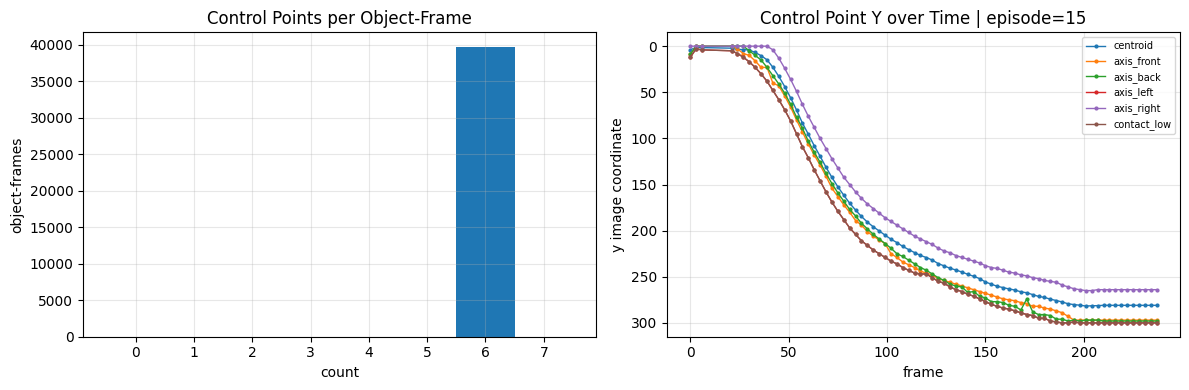

In [83]:
# Action Encoder - Control Point Variables - Visual Review

cp_reduced_counts = (
    lunar_cp_df_reduced
    .groupby(["episode_id", "frame", "track_id"])
    .size()
    .reset_index(name="n_control_points")
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(cp_reduced_counts["n_control_points"], bins=np.arange(0, len(CONTROL_POINT_NAMES) + 3) - 0.5)
ax[0].set_title("Control Points per Object-Frame")
ax[0].set_xlabel("count")
ax[0].set_ylabel("object-frames")
ax[0].grid(alpha=0.3)

sample_episode_id = int(np.random.choice(sorted(lunar_cp_df_reduced["episode_id"].unique())))
sample_cp = lunar_cp_df_reduced[lunar_cp_df_reduced["episode_id"] == sample_episode_id]
for point_name, group in sample_cp.groupby("point_name"):
    ax[1].plot(group["frame"], group["y"], marker="o", markersize=2, linewidth=1, label=point_name)
ax[1].invert_yaxis()
ax[1].set_title(f"Control Point Y over Time | episode={sample_episode_id}")
ax[1].set_xlabel("frame")
ax[1].set_ylabel("y image coordinate")
ax[1].legend(fontsize=7)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Data Review

In [84]:
lunar_cp_df_reduced

,episode_id,frame,track_id,point_name,x,y,box_x1,box_y1,box_x2,box_y2
0,0,0,0,centroid,299.810403,5.20302,268,0,332,15
1,0,0,0,axis_front,268.000000,11.00000,268,0,332,15
2,0,0,0,axis_back,331.000000,11.00000,268,0,332,15
3,0,0,0,axis_left,271.000000,14.00000,268,0,332,15
4,0,0,0,axis_right,273.000000,0.00000,268,0,332,15
...,...,...,...,...,...,...,...,...,...,...
238153,499,263,0,axis_front,246.000000,297.00000,246,264,306,301
238154,499,263,0,axis_back,305.000000,295.00000,246,264,306,301
238155,499,263,0,axis_left,249.000000,300.00000,246,264,306,301
238156,499,263,0,axis_right,262.000000,264.00000,246,264,306,301


### Background

#### Selection

In [85]:
# Action Encoder - Define Variables - Background

background_columns = [
    "episode_id",
    "frame",
    "background_point_id",
    "x",
    "y",
    "dx",
    "dy",
    "speed",
    "valid",
    "prev_valid",
]

lunar_bckg_df_reduced = lunar_bckg_df[background_columns].copy()
lunar_bckg_df_reduced = lunar_bckg_df_reduced.sort_values(
    ["episode_id", "frame", "background_point_id"]
).reset_index(drop=True)

# The background model already stores only sampled, valid points, so this is the
# motion-ready table consumed by action embedding cells below.
lunar_bckg_df_selected = lunar_bckg_df_reduced.copy()

print("lunar_bckg_df_reduced shape:", lunar_bckg_df_reduced.shape)
print("lunar_bckg_df_selected shape:", lunar_bckg_df_selected.shape)
print("episodes:", lunar_bckg_df_selected["episode_id"].nunique())
print(lunar_bckg_df_reduced.head().to_string(index=False))


lunar_bckg_df_reduced shape: (4958872, 10)
lunar_bckg_df_selected shape: (4958872, 10)
episodes: 500
 episode_id  frame  background_point_id     x    y  dx  dy  speed  valid  prev_valid
          0      0                    0  20.0 20.0 NaN NaN    NaN   True       False
          0      0                    1  60.0 20.0 NaN NaN    NaN   True       False
          0      0                    2 100.0 20.0 NaN NaN    NaN   True       False
          0      0                    3 140.0 20.0 NaN NaN    NaN   True       False
          0      0                    4 180.0 20.0 NaN NaN    NaN   True       False


#### Visual Review

This verifies that background motion fields contain displacement information, not only static coordinates.

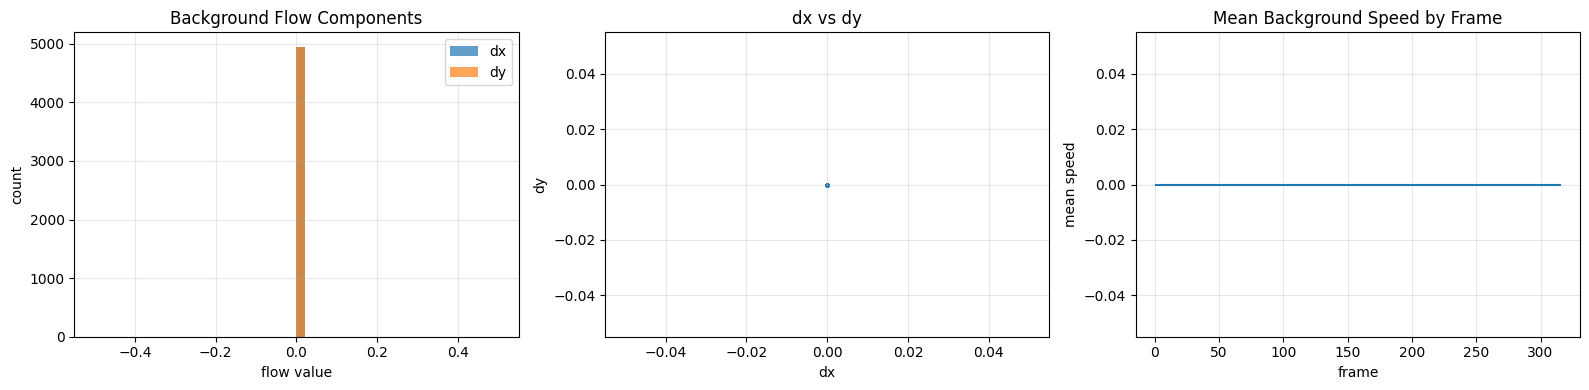

In [86]:
# Action Encoder - Background Variables - Visual Review

sample_bckg = lunar_bckg_df_reduced.sample(
    n=min(5000, len(lunar_bckg_df_reduced)),
    random_state=np.random.randint(0, 1_000_000),
)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].hist(sample_bckg["dx"], bins=50, alpha=0.7, label="dx")
ax[0].hist(sample_bckg["dy"], bins=50, alpha=0.7, label="dy")
ax[0].set_title("Background Flow Components")
ax[0].set_xlabel("flow value")
ax[0].set_ylabel("count")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].scatter(sample_bckg["dx"], sample_bckg["dy"], s=4, alpha=0.25)
ax[1].set_title("dx vs dy")
ax[1].set_xlabel("dx")
ax[1].set_ylabel("dy")
ax[1].grid(alpha=0.3)

speed_by_frame = lunar_bckg_df_reduced.groupby("frame")["speed"].mean()
ax[2].plot(speed_by_frame.index, speed_by_frame.values)
ax[2].set_title("Mean Background Speed by Frame")
ax[2].set_xlabel("frame")
ax[2].set_ylabel("mean speed")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Select Fixed Background Points

The background representation now uses stable optical-flow IDs instead of a fixed FIFO buffer.

For each video:

1. The background mask is computed as the inverse of the dilated Lunar Lander agent segmentation.
2. Candidate points are initialized on textured background grid locations so optical flow has visual structure to track.
3. Points are tracked across every consecutive raw video frame, but rows are saved only for the evenly sampled frames used downstream.
4. `background_point_id` is persistent and never reused. New IDs may be created when new valid background regions appear.
5. Invalid points and points that enter the segmented agent region are not written to the saved CSV.
6. Each saved row keeps `x`, `y`, `dx`, `dy`, `speed`, `valid`, and `prev_valid`, which is enough to compare dynamics by ID without storing redundant raw invalid rows.

The action embedding cells below still match background points by shared `background_point_id` between two sampled frames.


In [87]:
# Old FIFO selection removed: lunar_bckg_df_selected is produced by the stable-ID background model above.


For a motion transition from frame `t-s` to frame `t`, where `s = MOTION_STRIDE`:

1. Background points available in both frames are matched using persistent `background_point_id`.
2. Only IDs present at both endpoints are used to construct the motion representation.
3. Points may naturally enter or leave the scene; no fixed-capacity buffer or random refill is required.
4. The number of shared background points may vary between transitions.

For each shared background point `j` and control point `k`, the relative position is computed at both endpoints:

$$R_x^{t}(k,j)=x_{cp}^{t}(k)-x_{bg}^{t}(j)$$

$$R_y^{t}(k,j)=y_{cp}^{t}(k)-y_{bg}^{t}(j)$$

Motion is represented by the change in this relative geometry:

$$\Delta R_x(k,j)=R_x^{t}(k,j)-R_x^{t-s}(k,j)$$

$$\Delta R_y(k,j)=R_y^{t}(k,j)-R_y^{t-s}(k,j)$$

Because the raw background dimension may vary by transition, the motion encoder below reduces background-relative motion with a median over matched IDs. That keeps the final encoded motion key fixed-size while still using real tracked background dynamics.


In [88]:
# Background Points - Stable ID Data Check

selected_counts = lunar_bckg_df_selected.groupby(["episode_id", "frame"])["background_point_id"].nunique()
track_lengths = lunar_bckg_df_selected.groupby(["episode_id", "background_point_id"])["frame"].nunique()

print("selected shape:", lunar_bckg_df_selected.shape)
print("episodes:", lunar_bckg_df_selected["episode_id"].nunique())
print("points per sampled frame:")
print(selected_counts.describe().to_string())
print("track length in sampled frames:")
print(track_lengths.describe().to_string())

display(lunar_bckg_df_selected.head(20))


selected shape: (4958872, 10)
episodes: 500
points per sampled frame:
count    40000.000000
mean       123.971800
std          0.951513
min        121.000000
25%        123.000000
50%        124.000000
75%        125.000000
max        126.000000
track length in sampled frames:
count    62858.000000
mean        78.890070
std          4.341076
min         30.000000
25%         80.000000
50%         80.000000
75%         80.000000
max         80.000000


,episode_id,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,0,0,20.0,20.0,NaN,NaN,NaN,True,False
1,0,0,1,60.0,20.0,NaN,NaN,NaN,True,False
2,0,0,2,100.0,20.0,NaN,NaN,NaN,True,False
3,0,0,3,140.0,20.0,NaN,NaN,NaN,True,False
4,0,0,4,180.0,20.0,NaN,NaN,NaN,True,False
5,0,0,5,220.0,20.0,NaN,NaN,NaN,True,False
6,0,0,6,260.0,20.0,NaN,NaN,NaN,True,False
7,0,0,7,300.0,20.0,NaN,NaN,NaN,True,False
8,0,0,8,340.0,20.0,NaN,NaN,NaN,True,False
9,0,0,9,380.0,20.0,NaN,NaN,NaN,True,False


In [89]:
lunar_bckg_df_selected.shape

(4958872, 10)

#### Selected Background Points - Visual Review

This verifies that stable background IDs survive across sampled frames and remain outside the segmented Lunar Lander region before they are used by the motion-key encoder.


##### Background IDs Across Frames


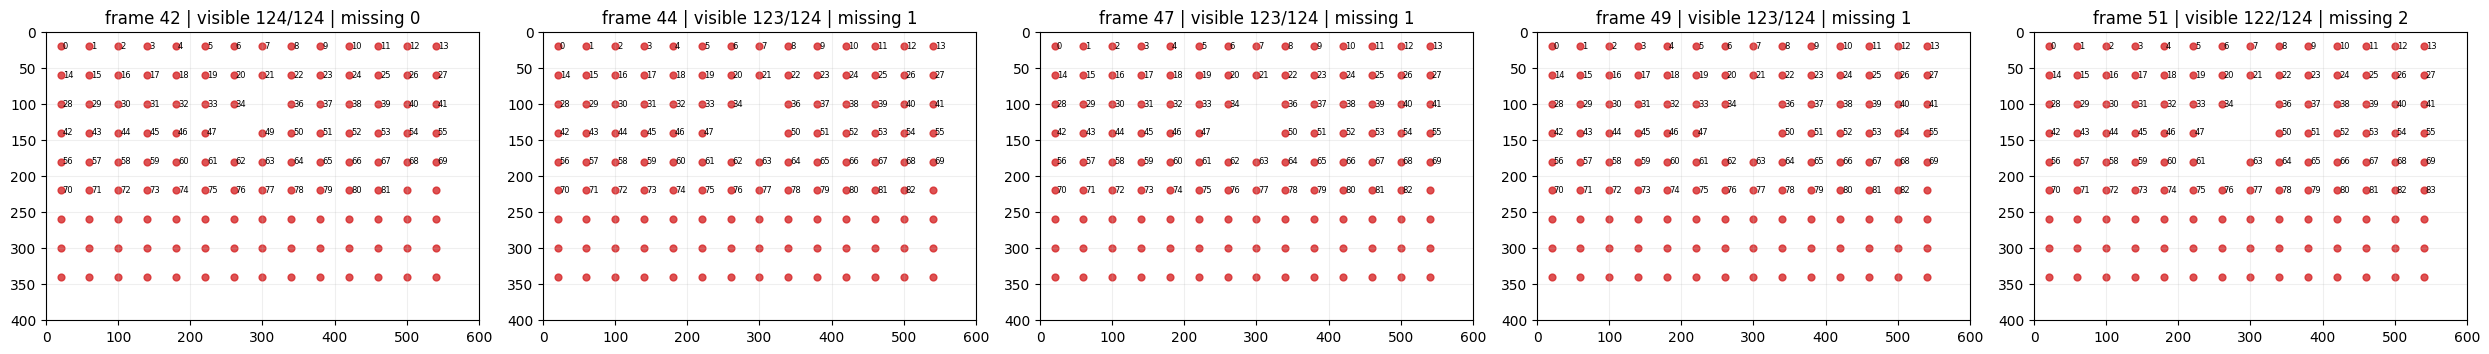

episode_id: 0
random source frame: 42
source background ids: 124


,frame,visible_from_source_ids,source_ids,missing_ids,survival_ratio
0,42,124,124,0,1.000000
1,44,123,124,1,0.991935
2,47,123,124,1,0.991935
3,49,123,124,1,0.991935
4,51,122,124,2,0.983871


In [90]:
# Background IDs Across Consecutive Sampled Frames

EPISODE_ID = 0
N_FRAMES = 5
MAX_LABELS = 80

rng = np.random.default_rng()

episode_df = lunar_bckg_df_selected[
    lunar_bckg_df_selected["episode_id"] == EPISODE_ID
].copy()

if episode_df.empty:
    raise ValueError(f"No background points found for episode_id={EPISODE_ID}")

frames = sorted(episode_df["frame"].unique())
if len(frames) == 0:
    raise ValueError(f"No frames found for episode_id={EPISODE_ID}")

n_frames = min(N_FRAMES, len(frames))
start_pos = int(rng.integers(0, len(frames) - n_frames + 1))
selected_frames = frames[start_pos:start_pos + n_frames]
source_frame = selected_frames[0]

source_frame_df = episode_df[episode_df["frame"] == source_frame].copy()
selected_ids = np.sort(source_frame_df["background_point_id"].unique())
selected_ids_set = set(selected_ids)

x_max = max(float(episode_df["x"].max()), 600.0)
y_max = max(float(episode_df["y"].max()), 400.0)

fig, axes = plt.subplots(
    1,
    n_frames,
    figsize=(5 * n_frames, 5),
    squeeze=False,
)
axes = axes.ravel()

for ax, frame in zip(axes, selected_frames):
    frame_df = episode_df[
        (episode_df["frame"] == frame)
        & (episode_df["background_point_id"].isin(selected_ids))
    ].copy()

    missing_count = len(selected_ids) - len(frame_df)

    if len(frame_df):
        ax.scatter(
            frame_df["x"],
            frame_df["y"],
            s=24,
            c="tab:red",
            alpha=0.8,
        )

        label_df = frame_df.sort_values("background_point_id").head(MAX_LABELS)
        for _, row in label_df.iterrows():
            ax.text(
                row["x"] + 3,
                row["y"] + 3,
                str(int(row["background_point_id"])),
                fontsize=6,
                color="black",
            )

    ax.set_title(
        f"frame {int(frame)} | visible {len(frame_df)}/{len(selected_ids)} | missing {missing_count}"
    )
    ax.set_xlim(0, x_max)
    ax.set_ylim(y_max, 0)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

survival = []

for frame in selected_frames:
    frame_ids = set(
        episode_df.loc[
            episode_df["frame"] == frame,
            "background_point_id",
        ]
    )

    visible_count = len(selected_ids_set & frame_ids)

    survival.append(
        {
            "frame": int(frame),
            "visible_from_source_ids": int(visible_count),
            "source_ids": int(len(selected_ids)),
            "missing_ids": int(len(selected_ids) - visible_count),
            "survival_ratio": float(visible_count / max(len(selected_ids), 1)),
        }
    )

print("episode_id:", EPISODE_ID)
print("random source frame:", int(source_frame))
print("source background ids:", len(selected_ids))

display(pd.DataFrame(survival))

##### Random Video with Background Points

The video review overlays the final saved background points for a random Lunar Lander episode.

For each sampled frame:

1. Saved stable-ID background points are displayed in red.
2. Recently observed IDs become brighter, making track continuity visible.
3. The frame label shows how many valid background IDs are available at that sampled timestep.

These are the exact rows used later by the action embedding code.


In [91]:
# Background Points - Stable ID Video Review

valid_episode_ids = sorted(
    int(ep_id)
    for ep_id in lunar_bckg_df_selected["episode_id"].unique()
    if int(ep_id) < len(lunar_video_paths)
)

if len(valid_episode_ids) == 0:
    raise ValueError(
        "No background episode_id matches current lunar_video_paths. "
        "Rerun background generation after setting N_PRETRAIN_VIDEOS."
    )

sample_episode_id = int(np.random.choice(valid_episode_ids))

episode_df = lunar_bckg_df_selected[
    lunar_bckg_df_selected["episode_id"] == sample_episode_id
].copy()

if episode_df.empty:
    raise ValueError(f"No background points found for episode_id={sample_episode_id}")

video_path = Path(lunar_video_paths[sample_episode_id])

frames, frame_indices = read_video_even(
    video_path,
    max_frames=MAX_FRAMES_PER_EPISODE,
    return_indices=True,
)

point_age = {}
annotated_frames = []

for image, frame in zip(frames, frame_indices):
    image = image.copy()

    frame_points = episode_df[
        episode_df["frame"] == frame
    ].copy()

    current_ids = set(frame_points["background_point_id"].tolist())

    point_age = {
        point_id: age
        for point_id, age in point_age.items()
        if point_id in current_ids
    }

    for point_id in current_ids:
        point_age[point_id] = point_age.get(point_id, 0) + 1

    for _, row in frame_points.iterrows():
        point_id = int(row["background_point_id"])
        age = point_age[point_id]

        red_intensity = int(np.clip(80 + age * 18, 80, 255))

        x = int(round(row["x"]))
        y = int(round(row["y"]))

        cv2.circle(
            image,
            (x, y),
            2,
            (red_intensity, 40, 40),
            -1,
        )

    cv2.putText(
        image,
        f"episode {sample_episode_id} | frame {int(frame)} | ids {len(current_ids)}",
        (12, 24),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    annotated_frames.append(image)

annotated_frames = np.stack(annotated_frames)

review_video_path = show_video(
    annotated_frames,
    f"background_stable_ids_episode_{sample_episode_id:04d}.mp4",
    fps=30,
    embed=True,
)

print("episode:", sample_episode_id)
print("video:", video_path)
print("review video:", review_video_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


episode: 320
video: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-387.mp4
review video: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/background_stable_ids_episode_0320.mp4


The red points are the saved stable background IDs. Brighter points are IDs that remain visible across consecutive sampled frames.


#### Data Review

In [92]:
lunar_bckg_df_selected[lunar_bckg_df_selected["background_point_id"] == 0].head(10)

,episode_id,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,0,0,20.0,20.0,NaN,NaN,NaN,True,False
126,0,2,0,20.0,20.0,0.0,0.0,0.0,True,True
252,0,4,0,20.0,20.0,0.0,0.0,0.0,True,True
378,0,6,0,20.0,20.0,0.0,0.0,0.0,True,True
503,0,8,0,20.0,20.0,0.0,0.0,0.0,True,True
628,0,10,0,20.0,20.0,0.0,0.0,0.0,True,True
753,0,12,0,20.0,20.0,0.0,0.0,0.0,True,True
878,0,14,0,20.0,20.0,0.0,0.0,0.0,True,True
1003,0,17,0,20.0,20.0,0.0,0.0,0.0,True,True
1128,0,19,0,20.0,20.0,0.0,0.0,0.0,True,True


# Action Embedding

## Plot 10 Consecutive Frames

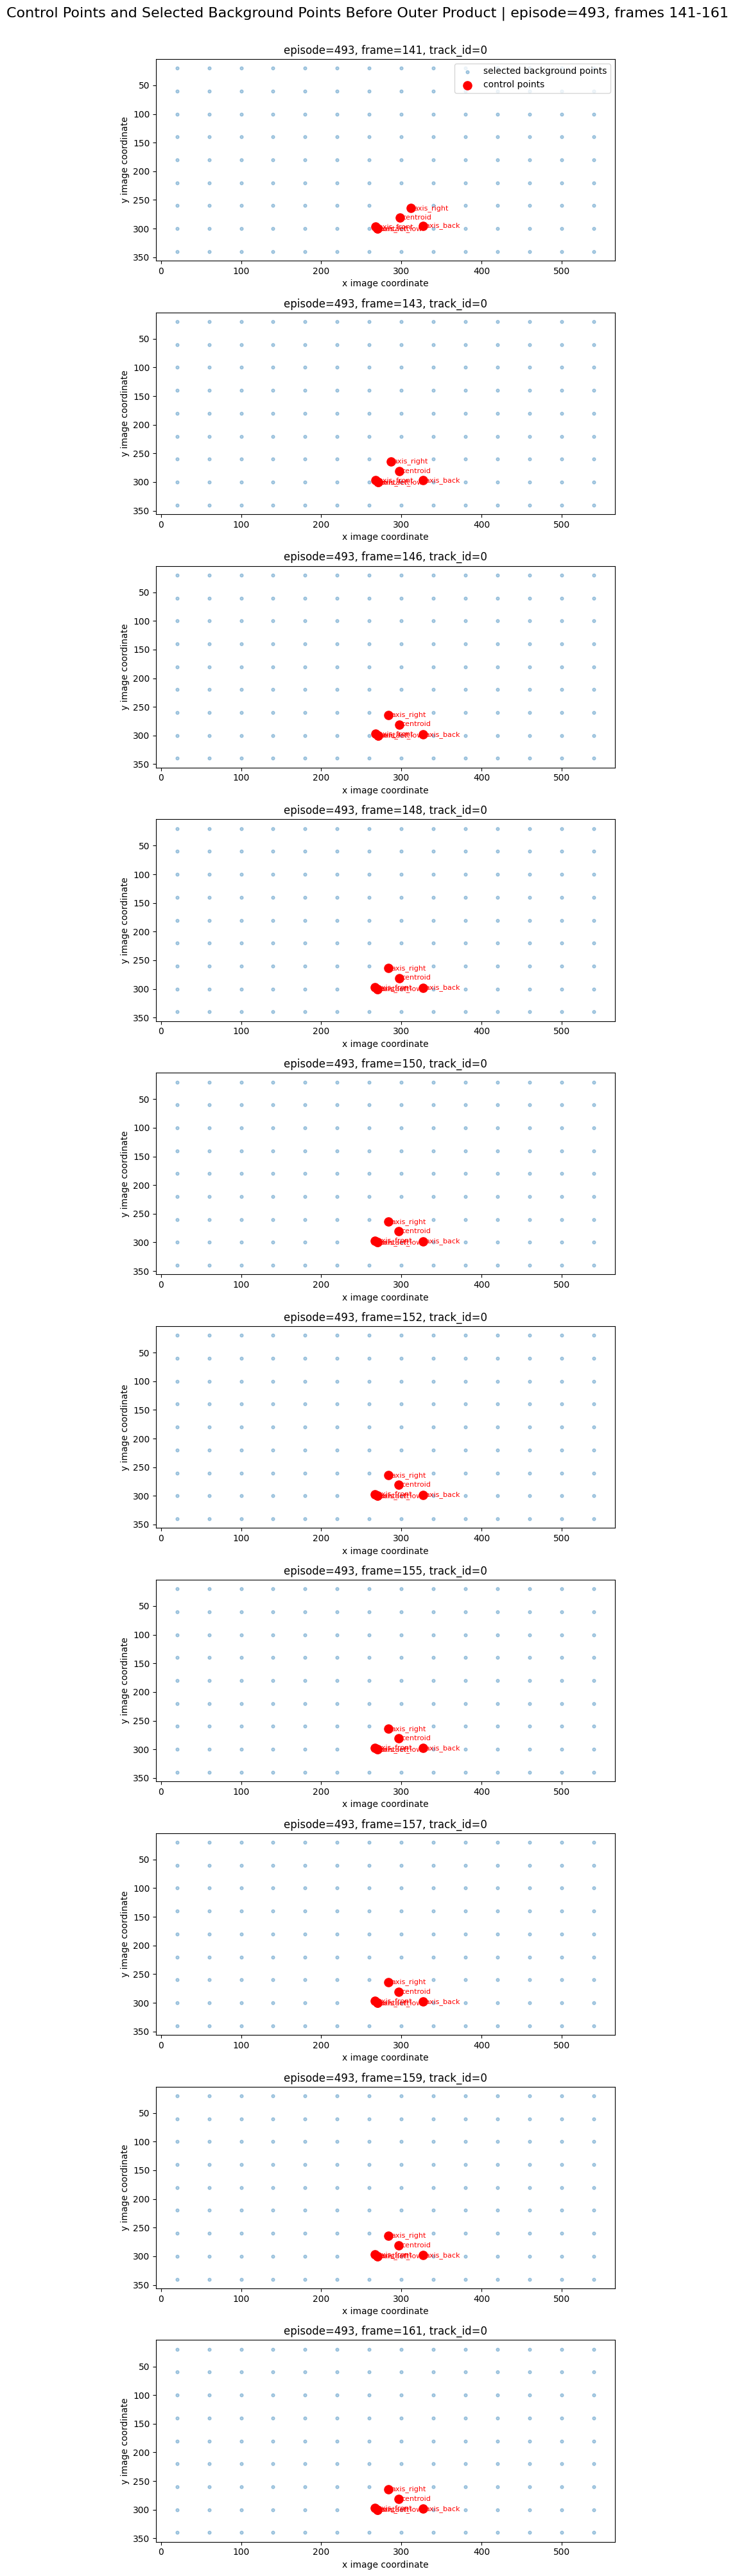

sample_episode_id: 493
sample_frames: [141, 143, 146, 148, 150, 152, 155, 157, 159, 161]
selected background points per sampled frame: {141: 125, 143: 125, 146: 125, 148: 124, 150: 124, 152: 124, 155: 124, 157: 124, 159: 124, 161: 124}


In [93]:
# Action Embeddings - Sample - Plot 10 Consecutive Frames

sample_episode_id = np.random.choice(lunar_cp_df_reduced["episode_id"].unique())

episode_frames = sorted(
    set(lunar_cp_df_reduced.loc[
        lunar_cp_df_reduced["episode_id"] == sample_episode_id,
        "frame",
    ])
    & set(lunar_bckg_df_selected.loc[
        lunar_bckg_df_selected["episode_id"] == sample_episode_id,
        "frame",
    ])
)

start_pos = np.random.randint(0, max(1, len(episode_frames) - 10 + 1))
sample_frames = episode_frames[start_pos:start_pos + 10]

fig, ax = plt.subplots(10, 1, figsize=(8, 40))

for row_idx, frame in enumerate(sample_frames):
    frame_tracks = lunar_cp_df_reduced[
        (lunar_cp_df_reduced["episode_id"] == sample_episode_id)
        & (lunar_cp_df_reduced["frame"] == frame)
    ]["track_id"]

    if frame_tracks.empty:
        ax[row_idx].set_title(f"episode={sample_episode_id}, frame={frame} | no control points")
        ax[row_idx].axis("off")
        continue

    track_id = frame_tracks.iloc[0]

    frame_cp = lunar_cp_df_reduced[
        (lunar_cp_df_reduced["episode_id"] == sample_episode_id)
        & (lunar_cp_df_reduced["frame"] == frame)
        & (lunar_cp_df_reduced["track_id"] == track_id)
    ].copy()

    frame_bckg = lunar_bckg_df_selected[
        (lunar_bckg_df_selected["episode_id"] == sample_episode_id)
        & (lunar_bckg_df_selected["frame"] == frame)
    ].copy()

    ax[row_idx].scatter(
        frame_bckg["x"],
        frame_bckg["y"],
        s=12,
        alpha=0.35,
        label="selected background points",
    )

    ax[row_idx].scatter(
        frame_cp["x"],
        frame_cp["y"],
        s=90,
        c="red",
        label="control points",
    )

    for _, cp_row in frame_cp.iterrows():
        ax[row_idx].text(
            cp_row["x"] + 3,
            cp_row["y"] + 3,
            cp_row["point_name"],
            fontsize=8,
            color="red",
        )

    ax[row_idx].invert_yaxis()
    ax[row_idx].set_xlabel("x image coordinate")
    ax[row_idx].set_ylabel("y image coordinate")
    ax[row_idx].set_title(f"episode={sample_episode_id}, frame={frame}, track_id={track_id}")

ax[0].legend(loc="upper right")

plt.suptitle(
    f"Control Points and Selected Background Points Before Outer Product | "
    f"episode={sample_episode_id}, frames {sample_frames[0]}-{sample_frames[-1]}",
    fontsize=16,
    y=1.002,
)

plt.tight_layout()
plt.show()

print("sample_episode_id:", sample_episode_id)
print("sample_frames:", sample_frames)
print(
    "selected background points per sampled frame:",
    lunar_bckg_df_selected[
        (lunar_bckg_df_selected["episode_id"] == sample_episode_id)
        & (lunar_bckg_df_selected["frame"].isin(sample_frames))
    ]
    .groupby("frame")
    .size()
    .to_dict()
)

## Single Raw Motion Key

For one transition `t-5 -> t`, we compute the change in relative position between every control point `k` and every background point `j`.

For the horizontal direction:

$$\Delta R^x_t(k,j)=\left(x^k_{cp,t}-x^j_{bckg,t}\right)-\left(x^k_{cp,t-5}-x^j_{bckg,t-5}\right)$$

For the vertical direction:

$$\Delta R^y_t(k,j)=\left(y^k_{cp,t}-y^j_{bckg,t}\right)-\left(y^k_{cp,t-5}-y^j_{bckg,t-5}\right)$$

These relations form the motion tensor:

$$M_t(k,j,:)=[\Delta R^x_t(k,j),\Delta R^y_t(k,j)]$$

with:

$$M_t\in\mathbb{R}^{K\times N\times 2}$$

The tensor is then flattened into one raw motion key:

$$z_{raw,t}=\operatorname{vec}(M_t)\in\mathbb{R}^{2KN}$$

Using a larger temporal stride makes the motion signal more pronounced than comparing immediately adjacent sampled frames.

The raw motion key is later encoded into a lower-dimensional motion representation before motion-token assignment.

| Motion token | dim 1 | dim 2 | dim 3 | ... | dim D |
|---|---:|---:|---:|---:|---:|
| `token_0` | $e_{0,1}$ | $e_{0,2}$ | $e_{0,3}$ | ... | $e_{0,D}$ |
| `token_1` | $e_{1,1}$ | $e_{1,2}$ | $e_{1,3}$ | ... | $e_{1,D}$ |
| `token_2` | $e_{2,1}$ | $e_{2,2}$ | $e_{2,3}$ | ... | $e_{2,D}$ |
| `...` | ... | ... | ... | ... | ... |
| `token_K` | $e_{K,1}$ | $e_{K,2}$ | $e_{K,3}$ | ... | $e_{K,D}$ |
| **`z_encoded`** | **$z_1$** | **$z_2$** | **$z_3$** | **...** | **$z_D$** |

After encoding, the closest codebook row can be selected using:

$$a_t=\arg\min_m \left\|z_{encoded,t}-e_m\right\|_2$$

where `a_t` is the discrete motion token assigned to the observed `t-5 -> t` transition.

In [94]:
# Motion-Key Action Embeddings - Helpers

FRAME_HEIGHT = int(random_video_frames.shape[1])
FRAME_WIDTH = int(random_video_frames.shape[2])
MOTION_STRIDE = 5

def normalize_xy(x, y):
    x = np.asarray(x, dtype=np.float32) / max(FRAME_WIDTH - 1, 1)
    y = np.asarray(y, dtype=np.float32) / max(FRAME_HEIGHT - 1, 1)
    return x, y

def build_motion_key(prev_frame_cp, frame_cp, prev_frame_bckg, frame_bckg):
    prev_frame_cp = prev_frame_cp.sort_values("point_name")
    frame_cp = frame_cp.sort_values("point_name")

    common_bckg_ids = sorted(set(prev_frame_bckg["background_point_id"]) & set(frame_bckg["background_point_id"]))

    if len(common_bckg_ids) == 0:
        raise ValueError("No common background points between the two frames.")

    prev_frame_bckg = prev_frame_bckg[prev_frame_bckg["background_point_id"].isin(common_bckg_ids)].sort_values("background_point_id")
    frame_bckg = frame_bckg[frame_bckg["background_point_id"].isin(common_bckg_ids)].sort_values("background_point_id")

    prev_x_cp, prev_y_cp = normalize_xy(prev_frame_cp["x"].to_numpy(), prev_frame_cp["y"].to_numpy())
    x_cp, y_cp = normalize_xy(frame_cp["x"].to_numpy(), frame_cp["y"].to_numpy())

    prev_x_bckg, prev_y_bckg = normalize_xy(prev_frame_bckg["x"].to_numpy(), prev_frame_bckg["y"].to_numpy())
    x_bckg, y_bckg = normalize_xy(frame_bckg["x"].to_numpy(), frame_bckg["y"].to_numpy())

    prev_R_x = prev_x_cp.reshape(-1, 1) - prev_x_bckg.reshape(1, -1)
    prev_R_y = prev_y_cp.reshape(-1, 1) - prev_y_bckg.reshape(1, -1)

    R_x = x_cp.reshape(-1, 1) - x_bckg.reshape(1, -1)
    R_y = y_cp.reshape(-1, 1) - y_bckg.reshape(1, -1)

    delta_R_x = R_x - prev_R_x
    delta_R_y = R_y - prev_R_y

    M = np.stack([delta_R_x, delta_R_y], axis=-1).astype(np.float32)
    z_raw = M.reshape(-1).astype(np.float32)

    return {
        "M_x": delta_R_x.astype(np.float32),
        "M_y": delta_R_y.astype(np.float32),
        "M": M,
        "z_raw": z_raw,
        "control_point_dim": int(len(frame_cp)),
        "background_dim": int(len(frame_bckg)),
        "relation_channels": int(M.shape[-1]),
        "raw_motion_key_dim": int(z_raw.shape[0]),
    }

## Single Motion-Key Action Embeddings

For tokenized pretraining, the motion key should represent how the agent moves relative to a stable background reference.

For now, the representation is limited to **2D image-space motion**, using only the horizontal and vertical image coordinates. Depth is not included at this stage.

For each control point and background point, we first define the relative position:

$$R^x_{i,t}(k,j)=x_{cp,i,t}^{(k)}-x_{bckg,t}^{(j)}$$

$$R^y_{i,t}(k,j)=y_{cp,i,t}^{(k)}-y_{bckg,t}^{(j)}$$

Motion is represented by the temporal change of this relative geometry over a stride of five sampled frames:

$$\Delta R^x_{i,t}(k,j)=R^x_{i,t}(k,j)-R^x_{i,t-5}(k,j)$$

$$\Delta R^y_{i,t}(k,j)=R^y_{i,t}(k,j)-R^y_{i,t-5}(k,j)$$

Using `t-5 -> t` instead of immediately adjacent frames produces a stronger motion signal and reduces near-zero motion keys.

The full raw motion tensor stacks the horizontal and vertical motion relations:

$$M_{i,t}=\left(\Delta R^x_{i,t},\Delta R^y_{i,t}\right)\in\mathbb{R}^{K\times N\times 2}$$

The tensor is flattened into a raw motion key:

$$z^{raw}_{i,t}=\operatorname{flatten}\left(M_{i,t}\right)\in\mathbb{R}^{K\cdot N\cdot 2}$$

Because the background points are filtered to remain temporally stable and motion-consistent, this representation emphasizes agent motion relative to the scene rather than background-tracker noise.

The raw motion key is then transformed into a lower-dimensional encoded motion key:

$$z^{encoded}_{i,t}=f_{\theta}\left(z^{raw}_{i,t}\right)$$

The encoded key is used for motion-token assignment. Similar motions should produce nearby encoded keys and therefore update the same motion prototype, while sufficiently different motions can create new motion tokens.

```text
CP-background motion
        ↓
     t-5 → t
        ↓
   M_x, M_y
        ↓
     flatten
        ↓
      z_raw
        ↓
 Motion Key Encoder
        ↓
    z_encoded
        ↓
 motion prototype matching
        ↓
 motion_token_id

TL;DR

We measure how the control points move relative to the stable background between `t-1` and `t`, then flatten that motion pattern into a single vector `z_raw`.

In [95]:
# Motion-Key Action Embeddings - Helpers

FRAME_HEIGHT = int(random_video_frames.shape[1])
FRAME_WIDTH = int(random_video_frames.shape[2])
MOTION_STRIDE = 5

def normalize_xy(x, y):
    x = np.asarray(x, dtype=np.float32) / max(FRAME_WIDTH - 1, 1)
    y = np.asarray(y, dtype=np.float32) / max(FRAME_HEIGHT - 1, 1)
    return x, y

def build_motion_key(prev_frame_cp, frame_cp, prev_frame_bckg, frame_bckg):
    prev_frame_cp = prev_frame_cp.sort_values("point_name")
    frame_cp = frame_cp.sort_values("point_name")

    common_bckg_ids = sorted(set(prev_frame_bckg["background_point_id"]) & set(frame_bckg["background_point_id"]))

    if len(common_bckg_ids) == 0:
        raise ValueError("No common background points between the two frames.")

    prev_frame_bckg = prev_frame_bckg[prev_frame_bckg["background_point_id"].isin(common_bckg_ids)].sort_values("background_point_id")
    frame_bckg = frame_bckg[frame_bckg["background_point_id"].isin(common_bckg_ids)].sort_values("background_point_id")

    prev_x_cp, prev_y_cp = normalize_xy(prev_frame_cp["x"].to_numpy(), prev_frame_cp["y"].to_numpy())
    x_cp, y_cp = normalize_xy(frame_cp["x"].to_numpy(), frame_cp["y"].to_numpy())

    prev_x_bckg, prev_y_bckg = normalize_xy(prev_frame_bckg["x"].to_numpy(), prev_frame_bckg["y"].to_numpy())
    x_bckg, y_bckg = normalize_xy(frame_bckg["x"].to_numpy(), frame_bckg["y"].to_numpy())

    prev_R_x = prev_x_cp.reshape(-1, 1) - prev_x_bckg.reshape(1, -1)
    prev_R_y = prev_y_cp.reshape(-1, 1) - prev_y_bckg.reshape(1, -1)

    R_x = x_cp.reshape(-1, 1) - x_bckg.reshape(1, -1)
    R_y = y_cp.reshape(-1, 1) - y_bckg.reshape(1, -1)

    delta_R_x = R_x - prev_R_x
    delta_R_y = R_y - prev_R_y

    M = np.stack([delta_R_x, delta_R_y], axis=-1).astype(np.float32)
    z_raw = M.reshape(-1).astype(np.float32)

    return {
        "M_x": delta_R_x.astype(np.float32),
        "M_y": delta_R_y.astype(np.float32),
        "M": M,
        "z_raw": z_raw,
        "control_point_dim": int(len(frame_cp)),
        "background_dim": int(len(frame_bckg)),
        "relation_channels": int(M.shape[-1]),
        "raw_motion_key_dim": int(z_raw.shape[0]),
    }

#### Visualize

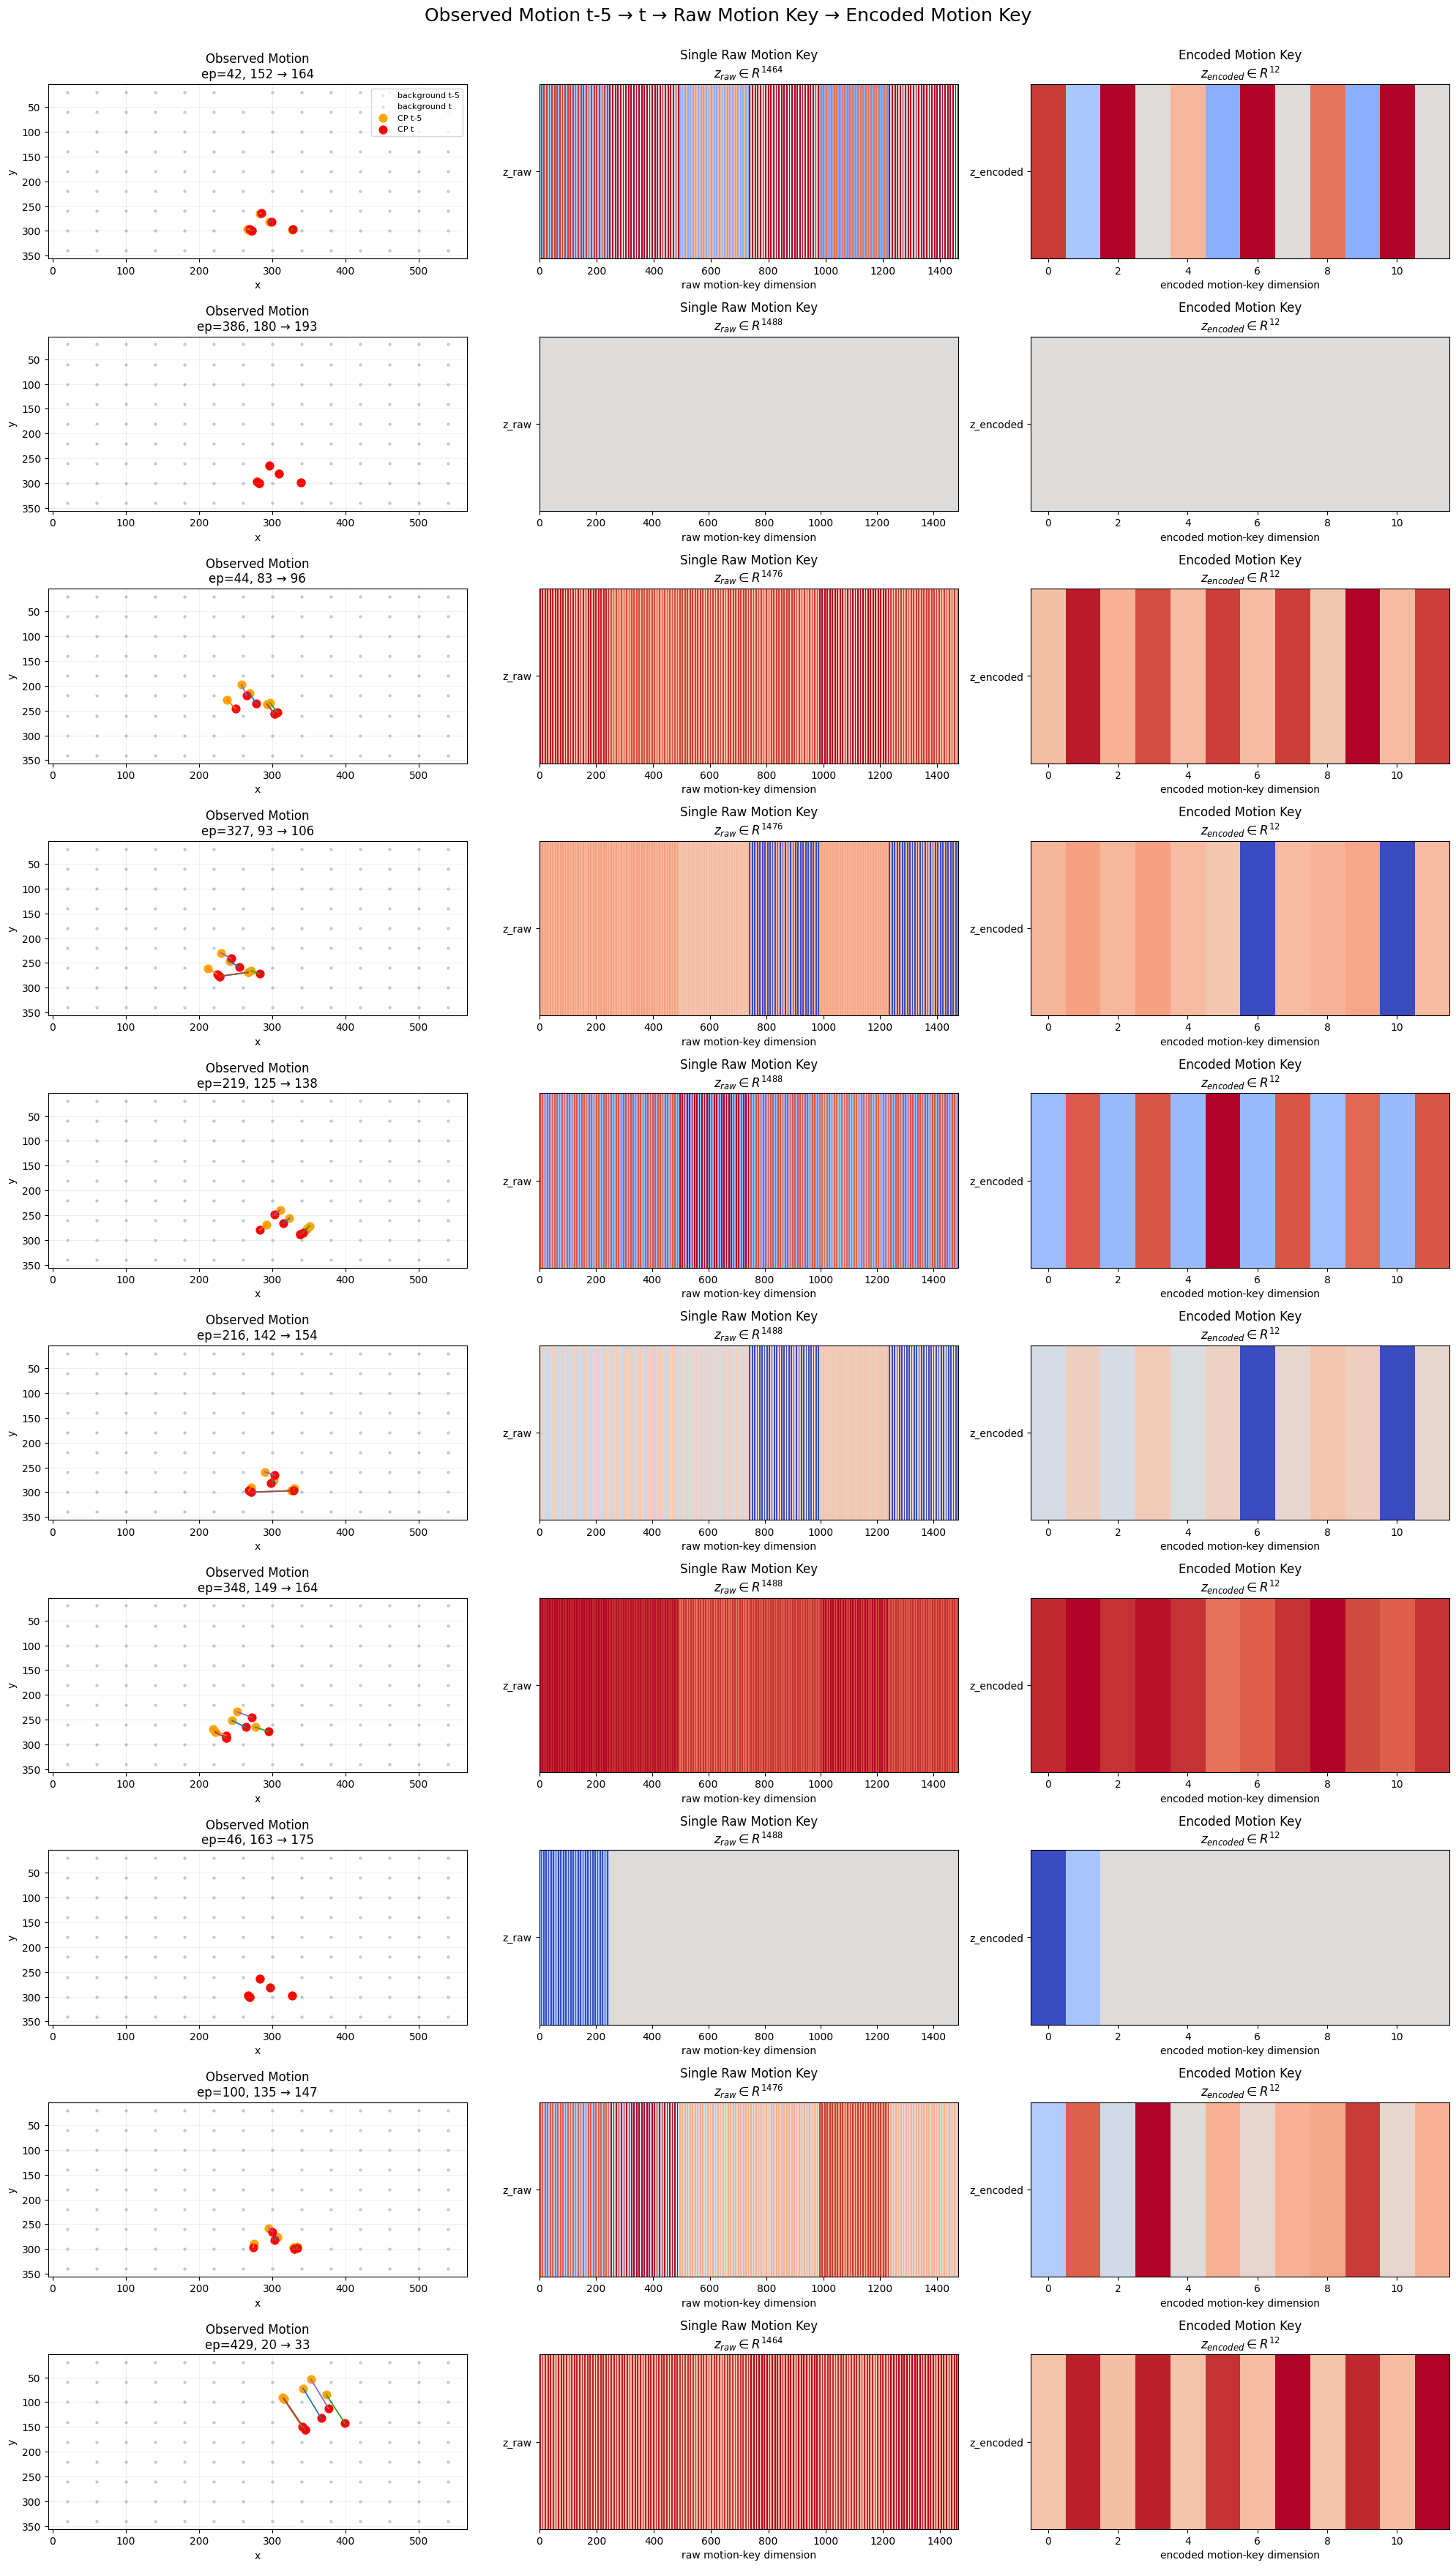

examples: 10
z_raw dim: 1464
z_encoded dim: 12


In [96]:
# Motion-Key Action Embeddings - 10 Random Examples

N_EXAMPLES = 10
RANDOM_STATE = 42

# ---------------------------------------------------------
# Encoded Motion Key helper
# ---------------------------------------------------------

def encode_motion_key(motion_key):
    M_x = np.asarray(motion_key["M_x"], dtype=np.float32)
    M_y = np.asarray(motion_key["M_y"], dtype=np.float32)

    median_x = np.median(M_x, axis=1)
    median_y = np.median(M_y, axis=1)

    z_encoded = np.stack([median_x, median_y], axis=1).reshape(-1)

    return z_encoded.astype(np.float32)


# ---------------------------------------------------------
# Sample valid t-5 -> t transitions
# ---------------------------------------------------------

rng = np.random.default_rng(RANDOM_STATE)
all_transitions = []

for episode_id in lunar_cp_df_reduced["episode_id"].unique():

    episode_frames = sorted(
        lunar_bckg_df_reduced.loc[
            lunar_bckg_df_reduced["episode_id"] == episode_id,
            "frame"
        ].unique()
    )

    selected_frames = set(
        lunar_bckg_df_selected.loc[
            lunar_bckg_df_selected["episode_id"] == episode_id,
            "frame"
        ].unique()
    )

    cp_frames = set(
        lunar_cp_df_reduced.loc[
            lunar_cp_df_reduced["episode_id"] == episode_id,
            "frame"
        ].unique()
    )

    for frame_idx in range(MOTION_STRIDE, len(episode_frames)):
        prev_frame = episode_frames[frame_idx - MOTION_STRIDE]
        frame = episode_frames[frame_idx]

        if prev_frame not in selected_frames or frame not in selected_frames:
            continue

        if prev_frame not in cp_frames or frame not in cp_frames:
            continue

        prev_frame_bckg = lunar_bckg_df_selected[
            (lunar_bckg_df_selected["episode_id"] == episode_id)
            & (lunar_bckg_df_selected["frame"] == prev_frame)
        ].sort_values("background_point_id")

        frame_bckg = lunar_bckg_df_selected[
            (lunar_bckg_df_selected["episode_id"] == episode_id)
            & (lunar_bckg_df_selected["frame"] == frame)
        ].sort_values("background_point_id")

        common_bckg_ids = set(prev_frame_bckg["background_point_id"]) & set(frame_bckg["background_point_id"])

        if len(common_bckg_ids) == 0:
            continue

        all_transitions.append((int(episode_id), int(prev_frame), int(frame)))


if len(all_transitions) == 0:
    raise ValueError("No valid t-5 -> t transitions found.")


sample_indices = rng.choice(len(all_transitions), size=min(N_EXAMPLES, len(all_transitions)), replace=False)
sample_transitions = [all_transitions[i] for i in sample_indices]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(len(sample_transitions), 3, figsize=(20, 3.5 * len(sample_transitions)))

if len(sample_transitions) == 1:
    axes = axes.reshape(1, -1)


for row_idx, (episode_id, prev_frame, frame) in enumerate(sample_transitions):

    # -----------------------------------------------------
    # Control points t-5 and t
    # -----------------------------------------------------

    prev_frame_cp_all = lunar_cp_df_reduced[
        (lunar_cp_df_reduced["episode_id"] == episode_id)
        & (lunar_cp_df_reduced["frame"] == prev_frame)
    ]

    frame_cp_all = lunar_cp_df_reduced[
        (lunar_cp_df_reduced["episode_id"] == episode_id)
        & (lunar_cp_df_reduced["frame"] == frame)
    ]

    if len(prev_frame_cp_all) == 0 or len(frame_cp_all) == 0:
        continue

    track_id = int(frame_cp_all["track_id"].iloc[0])

    prev_frame_cp = prev_frame_cp_all[prev_frame_cp_all["track_id"] == track_id].sort_values("point_name")
    frame_cp = frame_cp_all[frame_cp_all["track_id"] == track_id].sort_values("point_name")

    # -----------------------------------------------------
    # Background t-5 and t
    # -----------------------------------------------------

    prev_frame_bckg = lunar_bckg_df_selected[
        (lunar_bckg_df_selected["episode_id"] == episode_id)
        & (lunar_bckg_df_selected["frame"] == prev_frame)
    ].sort_values("background_point_id")

    frame_bckg = lunar_bckg_df_selected[
        (lunar_bckg_df_selected["episode_id"] == episode_id)
        & (lunar_bckg_df_selected["frame"] == frame)
    ].sort_values("background_point_id")

    common_bckg_ids = sorted(set(prev_frame_bckg["background_point_id"]) & set(frame_bckg["background_point_id"]))

    prev_frame_bckg_plot = prev_frame_bckg[
        prev_frame_bckg["background_point_id"].isin(common_bckg_ids)
    ].sort_values("background_point_id")

    frame_bckg_plot = frame_bckg[
        frame_bckg["background_point_id"].isin(common_bckg_ids)
    ].sort_values("background_point_id")

    # -----------------------------------------------------
    # Raw and encoded motion key
    # -----------------------------------------------------

    motion_key = build_motion_key(prev_frame_cp, frame_cp, prev_frame_bckg, frame_bckg)

    z_raw = motion_key["z_raw"]
    z_encoded = encode_motion_key(motion_key)

    # =====================================================
    # COLUMN 1 - Observed motion
    # =====================================================

    ax_motion = axes[row_idx, 0]

    ax_motion.scatter(prev_frame_bckg_plot["x"], prev_frame_bckg_plot["y"], s=5, alpha=0.15, c="gray", label="background t-5")
    ax_motion.scatter(frame_bckg_plot["x"], frame_bckg_plot["y"], s=5, alpha=0.15, c="tab:blue", label="background t")

    ax_motion.scatter(prev_frame_cp["x"], prev_frame_cp["y"], s=60, c="orange", label="CP t-5")
    ax_motion.scatter(frame_cp["x"], frame_cp["y"], s=60, c="red", label="CP t")

    for point_idx in range(min(len(prev_frame_cp), len(frame_cp))):
        ax_motion.plot(
            [prev_frame_cp.iloc[point_idx]["x"], frame_cp.iloc[point_idx]["x"]],
            [prev_frame_cp.iloc[point_idx]["y"], frame_cp.iloc[point_idx]["y"]],
            linewidth=1.3
        )

    ax_motion.invert_yaxis()
    ax_motion.set_title(f"Observed Motion\nep={episode_id}, {prev_frame} → {frame}")
    ax_motion.set_xlabel("x")
    ax_motion.set_ylabel("y")
    ax_motion.grid(alpha=0.2)

    if row_idx == 0:
        ax_motion.legend(fontsize=8)

    # =====================================================
    # COLUMN 2 - Raw motion key
    # =====================================================

    ax_raw = axes[row_idx, 1]

    raw_max_abs = max(float(np.max(np.abs(z_raw))), 1e-8)

    ax_raw.imshow(z_raw.reshape(1, -1), cmap="coolwarm", aspect="auto", interpolation="nearest", vmin=-raw_max_abs, vmax=raw_max_abs)
    ax_raw.set_title(f"Single Raw Motion Key\n$z_{{raw}} \\in R^{{{len(z_raw)}}}$")
    ax_raw.set_xlabel("raw motion-key dimension")
    ax_raw.set_yticks([0])
    ax_raw.set_yticklabels(["z_raw"])

    # =====================================================
    # COLUMN 3 - Encoded motion key
    # =====================================================

    ax_encoded = axes[row_idx, 2]

    encoded_max_abs = max(float(np.max(np.abs(z_encoded))), 1e-8)

    ax_encoded.imshow(z_encoded.reshape(1, -1), cmap="coolwarm", aspect="auto", interpolation="nearest", vmin=-encoded_max_abs, vmax=encoded_max_abs)
    ax_encoded.set_title(f"Encoded Motion Key\n$z_{{encoded}} \\in R^{{{len(z_encoded)}}}$")
    ax_encoded.set_xlabel("encoded motion-key dimension")
    ax_encoded.set_yticks([0])
    ax_encoded.set_yticklabels(["z_encoded"])


plt.suptitle("Observed Motion t-5 → t → Raw Motion Key → Encoded Motion Key", fontsize=18, y=1.001)
plt.tight_layout()
plt.show()

print("examples:", len(sample_transitions))
print("z_raw dim:", len(z_raw))
print("z_encoded dim:", len(z_encoded))

## All Videos Motion-Key Action Embeddings

In [97]:
# All Videos Motion-Key Action Embeddings

MAX_MOTION_TOKENS = 512
MOTION_TOKEN_DISTANCE_THRESHOLD = 0.015
ACTION_EMBEDDING_UPDATE_ALPHA = 0.05

# ---------------------------------------------------------
# Action embedding table
# ---------------------------------------------------------

action_embedding_table = []
action_embedding_counts = []

def assign_or_update_motion_token(z_encoded, table, counts):
    z_encoded = np.asarray(z_encoded, dtype=np.float32)

    # First observed motion
    if len(table) == 0:
        table.append(z_encoded.copy())
        counts.append(1)
        return 0, 0.0, True

    # Distance to every existing motion prototype
    table_array = np.stack(table).astype(np.float32)
    distances = np.linalg.norm(table_array - z_encoded.reshape(1, -1), axis=1)

    nearest_id = int(np.argmin(distances))
    nearest_distance = float(distances[nearest_id])

    # Create new token if motion is sufficiently novel
    should_create = nearest_distance > MOTION_TOKEN_DISTANCE_THRESHOLD and len(table) < MAX_MOTION_TOKENS

    if should_create:
        table.append(z_encoded.copy())
        counts.append(1)
        return len(table) - 1, nearest_distance, True

    # Otherwise update nearest prototype
    alpha = ACTION_EMBEDDING_UPDATE_ALPHA
    table[nearest_id] = ((1.0 - alpha) * table[nearest_id] + alpha * z_encoded).astype(np.float32)
    counts[nearest_id] += 1

    return nearest_id, nearest_distance, False


# ---------------------------------------------------------
# Process all videos / episodes
# ---------------------------------------------------------

motion_token_records = []

total_transitions = 0
created_tokens = 0

for episode_id in sorted(lunar_cp_df_reduced["episode_id"].unique()):

    episode_frames = sorted(
        lunar_bckg_df_reduced.loc[
            lunar_bckg_df_reduced["episode_id"] == episode_id,
            "frame"
        ].unique()
    )

    selected_frames = set(
        lunar_bckg_df_selected.loc[
            lunar_bckg_df_selected["episode_id"] == episode_id,
            "frame"
        ].unique()
    )

    cp_frames = set(
        lunar_cp_df_reduced.loc[
            lunar_cp_df_reduced["episode_id"] == episode_id,
            "frame"
        ].unique()
    )

    episode_transitions = 0

    for frame_idx in range(MOTION_STRIDE, len(episode_frames)):

        prev_frame = episode_frames[frame_idx - MOTION_STRIDE]
        frame = episode_frames[frame_idx]

        # Require CP + selected background at both endpoints
        if prev_frame not in selected_frames or frame not in selected_frames:
            continue

        if prev_frame not in cp_frames or frame not in cp_frames:
            continue

        # -------------------------------------------------
        # Control points
        # -------------------------------------------------

        prev_frame_cp_all = lunar_cp_df_reduced[
            (lunar_cp_df_reduced["episode_id"] == episode_id)
            & (lunar_cp_df_reduced["frame"] == prev_frame)
        ]

        frame_cp_all = lunar_cp_df_reduced[
            (lunar_cp_df_reduced["episode_id"] == episode_id)
            & (lunar_cp_df_reduced["frame"] == frame)
        ]

        if len(prev_frame_cp_all) == 0 or len(frame_cp_all) == 0:
            continue

        track_id = int(frame_cp_all["track_id"].iloc[0])

        prev_frame_cp = prev_frame_cp_all[prev_frame_cp_all["track_id"] == track_id].sort_values("point_name")
        frame_cp = frame_cp_all[frame_cp_all["track_id"] == track_id].sort_values("point_name")

        if len(prev_frame_cp) == 0 or len(frame_cp) == 0 or len(prev_frame_cp) != len(frame_cp):
            continue

        # -------------------------------------------------
        # Background
        # -------------------------------------------------

        prev_frame_bckg = lunar_bckg_df_selected[
            (lunar_bckg_df_selected["episode_id"] == episode_id)
            & (lunar_bckg_df_selected["frame"] == prev_frame)
        ].sort_values("background_point_id")

        frame_bckg = lunar_bckg_df_selected[
            (lunar_bckg_df_selected["episode_id"] == episode_id)
            & (lunar_bckg_df_selected["frame"] == frame)
        ].sort_values("background_point_id")

        common_bckg_ids = set(prev_frame_bckg["background_point_id"]) & set(frame_bckg["background_point_id"])

        if len(common_bckg_ids) == 0:
            continue

        # -------------------------------------------------
        # Raw motion key
        # -------------------------------------------------

        motion_key = build_motion_key(prev_frame_cp, frame_cp, prev_frame_bckg, frame_bckg)
        z_raw = motion_key["z_raw"]

        # -------------------------------------------------
        # Encoded motion key
        # -------------------------------------------------

        z_encoded = encode_motion_key(motion_key)

        # -------------------------------------------------
        # Assign / update motion token
        # -------------------------------------------------

        motion_token_id, nearest_distance, created_new_token = assign_or_update_motion_token(
            z_encoded,
            action_embedding_table,
            action_embedding_counts
        )

        if created_new_token:
            created_tokens += 1

        total_transitions += 1
        episode_transitions += 1

        # -------------------------------------------------
        # Save transition -> token mapping
        # -------------------------------------------------

        motion_token_records.append({
            "episode_id": int(episode_id),
            "prev_frame": int(prev_frame),
            "frame": int(frame),
            "track_id": int(track_id),
            "motion_token_id": int(motion_token_id),
            "nearest_distance": float(nearest_distance),
            "created_new_token": bool(created_new_token),
            "background_dim": int(motion_key["background_dim"]),
            "raw_motion_key_dim": int(len(z_raw)),
            "encoded_motion_key_dim": int(len(z_encoded)),
        })

    print(f"episode {episode_id}: {episode_transitions} transitions")


# ---------------------------------------------------------
# Final outputs
# ---------------------------------------------------------

motion_token_df = pd.DataFrame(motion_token_records)

action_embedding_table = np.stack(action_embedding_table).astype(np.float32)
action_embedding_counts = np.asarray(action_embedding_counts, dtype=np.int64)

print()
print("total transitions:", total_transitions)
print("motion tokens:", len(action_embedding_table))
print("action_embedding_table shape:", action_embedding_table.shape)
print("encoded motion dim:", action_embedding_table.shape[1])
print("token usage min / mean / max:", action_embedding_counts.min(), action_embedding_counts.mean(), action_embedding_counts.max())

display(motion_token_df.head(20))

episode 0: 75 transitions
episode 1: 75 transitions
episode 2: 75 transitions
episode 3: 75 transitions
episode 4: 75 transitions
episode 5: 75 transitions
episode 6: 75 transitions
episode 7: 75 transitions
episode 8: 75 transitions
episode 9: 75 transitions
episode 10: 75 transitions
episode 11: 75 transitions
episode 12: 71 transitions
episode 13: 75 transitions
episode 14: 75 transitions
episode 15: 69 transitions
episode 16: 75 transitions
episode 17: 67 transitions
episode 18: 75 transitions
episode 19: 75 transitions
episode 20: 75 transitions
episode 21: 75 transitions
episode 22: 75 transitions
episode 23: 75 transitions
episode 24: 75 transitions
episode 25: 75 transitions
episode 26: 75 transitions
episode 27: 75 transitions
episode 28: 75 transitions
episode 29: 75 transitions
episode 30: 75 transitions
episode 31: 75 transitions
episode 32: 75 transitions
episode 33: 70 transitions
episode 34: 75 transitions
episode 35: 75 transitions
episode 36: 75 transitions
episode 37:

,episode_id,prev_frame,frame,track_id,motion_token_id,nearest_distance,created_new_token,background_dim,raw_motion_key_dim,encoded_motion_key_dim
0,0,0,10,0,0,0.000000,True,125,1500,12
1,0,2,12,0,1,0.015752,True,125,1500,12
2,0,4,14,0,1,0.012347,False,125,1500,12
3,0,6,17,0,2,0.042231,True,125,1500,12
4,0,8,19,0,3,0.126874,True,125,1500,12
5,0,10,21,0,4,0.025360,True,125,1500,12
6,0,12,23,0,5,0.021496,True,125,1500,12
7,0,14,25,0,6,0.024624,True,123,1476,12
8,0,17,27,0,6,0.011284,False,123,1476,12
9,0,19,29,0,7,0.104723,True,124,1488,12


### Visualize

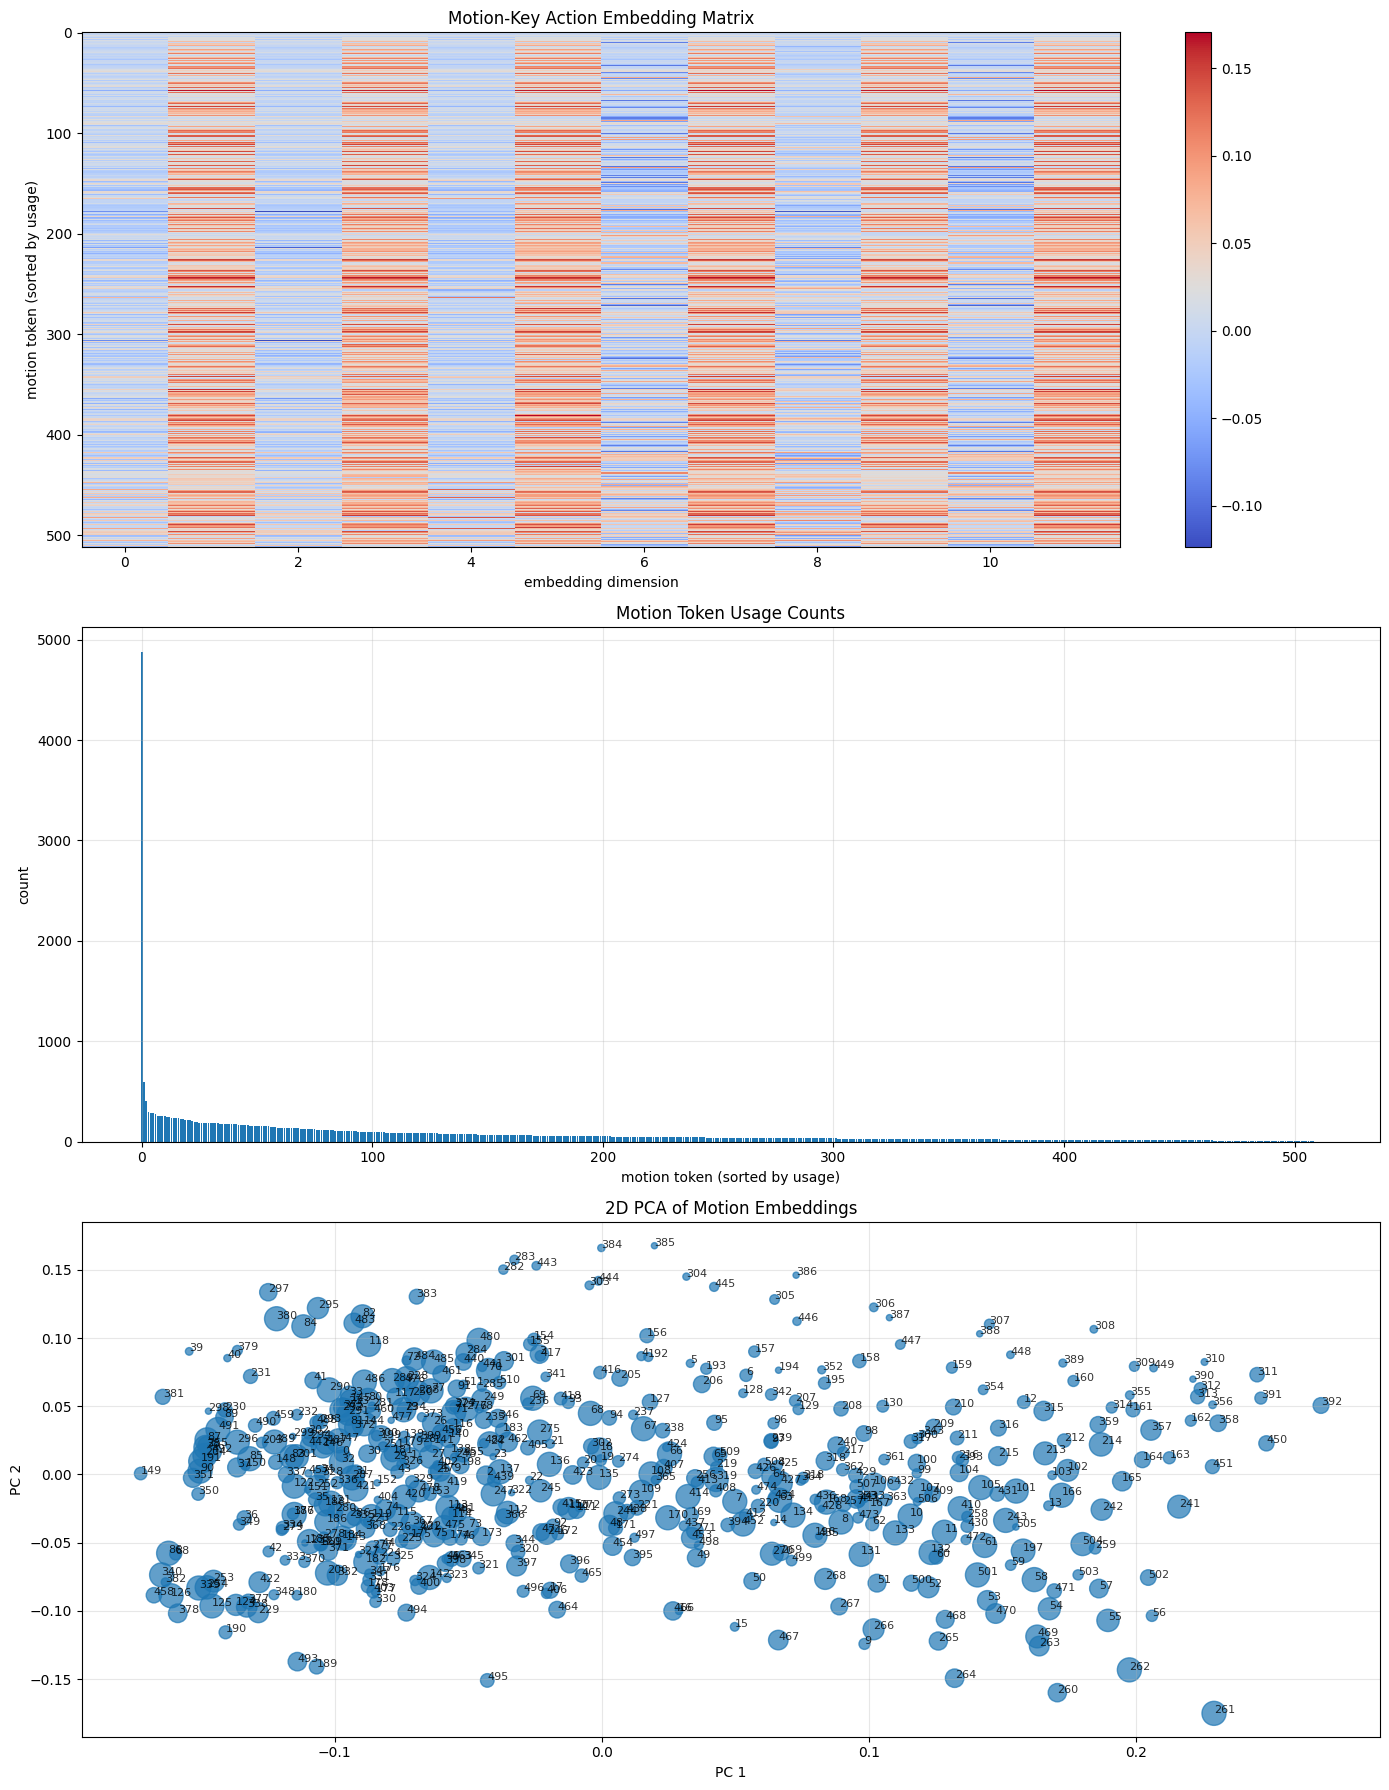

embedding_matrix shape: (512, 12)
n_tokens: 512
embedding_dim: 12
usage min: 2
usage mean: 72.361328125
usage max: 4878
most used token ids: [38, 87, 191, 80, 491, 121, 289, 186, 79, 108]
most used token counts: [4878, 596, 406, 300, 290, 287, 274, 261, 258, 258]


In [98]:
# Motion-Key Action Embeddings - Visualizer

import numpy as np
import matplotlib.pyplot as plt

if "action_embedding_table" not in globals():
    raise ValueError("action_embedding_table is not defined")

if "action_embedding_counts" not in globals():
    raise ValueError("action_embedding_counts is not defined")


embedding_matrix = np.asarray(
    action_embedding_table,
    dtype=np.float32,
)

token_counts = np.asarray(
    action_embedding_counts,
    dtype=np.int64,
)

if embedding_matrix.ndim != 2:
    raise ValueError(
        f"Expected 2D embedding matrix, got shape {embedding_matrix.shape}"
    )

if len(embedding_matrix) == 0:
    raise ValueError("Embedding matrix is empty")

if len(token_counts) != len(embedding_matrix):
    raise ValueError(
        "action_embedding_counts and action_embedding_table have different lengths"
    )


# -----------------------------------------------------
# Sort tokens by usage
# -----------------------------------------------------

sort_idx = np.argsort(-token_counts)

embedding_sorted = embedding_matrix[sort_idx]
counts_sorted = token_counts[sort_idx]
token_ids_sorted = sort_idx

n_tokens, embedding_dim = embedding_sorted.shape


# -----------------------------------------------------
# PCA to 2D using numpy only
# -----------------------------------------------------

X = embedding_sorted.copy()
X = X - X.mean(axis=0, keepdims=True)

if n_tokens >= 2 and embedding_dim >= 2:
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    pca_2d = X @ Vt[:2].T
else:
    pca_2d = np.zeros((n_tokens, 2), dtype=np.float32)


# -----------------------------------------------------
# Plot
# -----------------------------------------------------

fig, ax = plt.subplots(3, 1, figsize=(14, 18))

# 1. Heatmap
im = ax[0].imshow(
    embedding_sorted,
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)
ax[0].set_title("Motion-Key Action Embedding Matrix")
ax[0].set_xlabel("embedding dimension")
ax[0].set_ylabel("motion token (sorted by usage)")
plt.colorbar(im, ax=ax[0])

# 2. Usage counts
ax[1].bar(
    np.arange(n_tokens),
    counts_sorted,
)
ax[1].set_title("Motion Token Usage Counts")
ax[1].set_xlabel("motion token (sorted by usage)")
ax[1].set_ylabel("count")
ax[1].grid(alpha=0.3)

# 3. 2D PCA scatter
scatter = ax[2].scatter(
    pca_2d[:, 0],
    pca_2d[:, 1],
    s=np.clip(counts_sorted * 3, 20, 300),
    alpha=0.7,
)

for i in range(n_tokens):
    ax[2].text(
        pca_2d[i, 0],
        pca_2d[i, 1],
        str(token_ids_sorted[i]),
        fontsize=8,
        alpha=0.8,
    )

ax[2].set_title("2D PCA of Motion Embeddings")
ax[2].set_xlabel("PC 1")
ax[2].set_ylabel("PC 2")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("embedding_matrix shape:", embedding_matrix.shape)
print("n_tokens:", n_tokens)
print("embedding_dim:", embedding_dim)
print("usage min:", int(token_counts.min()))
print("usage mean:", float(token_counts.mean()))
print("usage max:", int(token_counts.max()))
print("most used token ids:", token_ids_sorted[:10].tolist())
print("most used token counts:", counts_sorted[:10].tolist())

# Motion Transformer Model Deconstruction

## One Video Sequence

Each video is converted into an ordered sequence of motion tokens by computing `z_raw`, encoding it into `z_encoded`, and matching it to the closest motion embedding. The same sequence also provides the true next `z_encoded` values used later as prediction targets.

episode_id: 0
idx shape: torch.Size([1, 16])
z_true_next shape: torch.Size([1, 16, 12])

input motion_token_ids:
tensor([ 0,  1,  1,  2,  3,  4,  5,  6,  6,  7,  8,  9, 10, 11, 11, 11])

first TRUE next z_encoded:
tensor([-0.0019,  0.0188,  0.0000,  0.0326, -0.0033,  0.0326,  0.0017,  0.0351,
         0.0150,  0.0000,  0.0017,  0.0351])


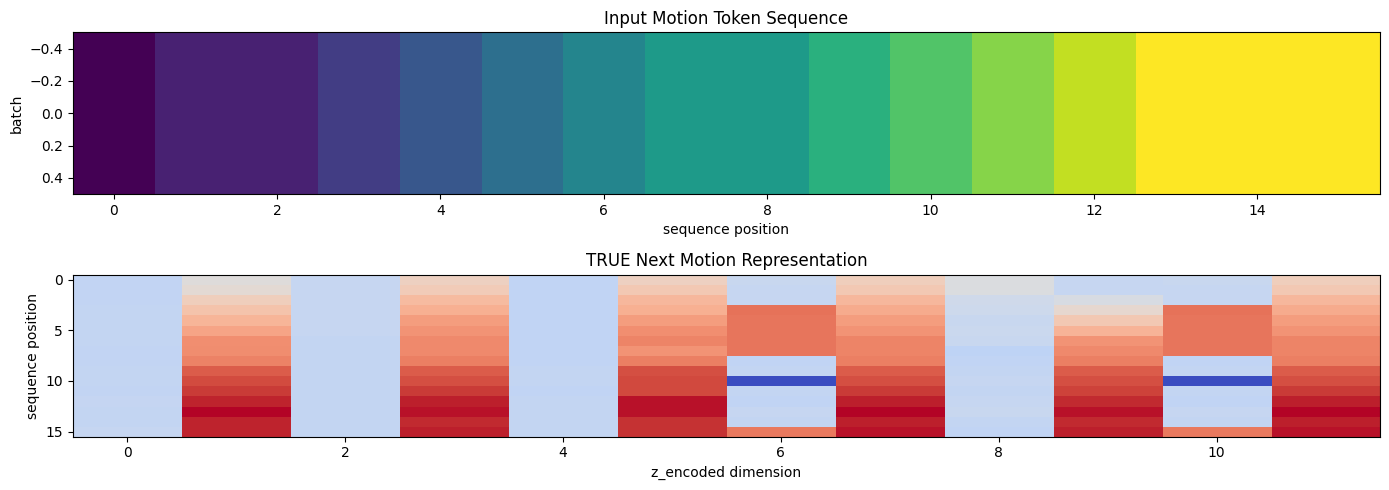

In [99]:
# Transformer Model Deconstruction - 1. One Video Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F


DECONSTRUCTION_EPISODE_ID = int(
    motion_token_df["episode_id"].iloc[0]
)

DECONSTRUCTION_SEQ_LEN = 16


episode_tokens = (
    motion_token_df[
        motion_token_df["episode_id"]
        == DECONSTRUCTION_EPISODE_ID
    ]
    .sort_values("frame")
    .reset_index(drop=True)
)


if len(episode_tokens) < DECONSTRUCTION_SEQ_LEN + 1:
    raise ValueError(
        "Episode is too short for selected sequence length."
    )


sequence_df = episode_tokens.iloc[
    :DECONSTRUCTION_SEQ_LEN + 1
].copy()


# ---------------------------------------------------------
# Input motion token IDs
# ---------------------------------------------------------

idx = torch.tensor(
    sequence_df[
        "motion_token_id"
    ]
    .iloc[:-1]
    .to_numpy(),
    dtype=torch.long,
).unsqueeze(0)


# ---------------------------------------------------------
# Rebuild TRUE z_encoded for every target transition
# ---------------------------------------------------------

z_true_next_list = []


for row_idx in range(
    1,
    len(sequence_df),
):

    row = sequence_df.iloc[
        row_idx
    ]

    episode_id = int(
        row["episode_id"]
    )

    prev_frame = int(
        row["prev_frame"]
    )

    frame = int(
        row["frame"]
    )

    track_id = int(
        row["track_id"]
    )

    prev_frame_cp = (
        lunar_cp_df_reduced[
            (
                lunar_cp_df_reduced["episode_id"]
                == episode_id
            )
            & (
                lunar_cp_df_reduced["frame"]
                == prev_frame
            )
            & (
                lunar_cp_df_reduced["track_id"]
                == track_id
            )
        ]
        .sort_values("point_name")
    )

    frame_cp = (
        lunar_cp_df_reduced[
            (
                lunar_cp_df_reduced["episode_id"]
                == episode_id
            )
            & (
                lunar_cp_df_reduced["frame"]
                == frame
            )
            & (
                lunar_cp_df_reduced["track_id"]
                == track_id
            )
        ]
        .sort_values("point_name")
    )

    prev_frame_bckg = (
        lunar_bckg_df_selected[
            (
                lunar_bckg_df_selected["episode_id"]
                == episode_id
            )
            & (
                lunar_bckg_df_selected["frame"]
                == prev_frame
            )
        ]
        .sort_values("background_point_id")
    )

    frame_bckg = (
        lunar_bckg_df_selected[
            (
                lunar_bckg_df_selected["episode_id"]
                == episode_id
            )
            & (
                lunar_bckg_df_selected["frame"]
                == frame
            )
        ]
        .sort_values("background_point_id")
    )

    motion_key = build_motion_key(
        prev_frame_cp,
        frame_cp,
        prev_frame_bckg,
        frame_bckg,
    )

    z_true_next = encode_motion_key(
        motion_key
    )

    z_true_next_list.append(
        z_true_next
    )


z_true_next = torch.tensor(
    np.stack(
        z_true_next_list
    ),
    dtype=torch.float32,
).unsqueeze(0)


# ---------------------------------------------------------
# Review
# ---------------------------------------------------------

print(
    "episode_id:",
    DECONSTRUCTION_EPISODE_ID,
)

print(
    "idx shape:",
    idx.shape,
)

print(
    "z_true_next shape:",
    z_true_next.shape,
)

print()

print(
    "input motion_token_ids:"
)

print(
    idx[0]
)

print()

print(
    "first TRUE next z_encoded:"
)

print(
    z_true_next[0, 0]
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(
        14,
        5,
    ),
)

axes[0].imshow(
    idx.numpy(),
    aspect="auto",
    interpolation="nearest",
)

axes[0].set_title(
    "Input Motion Token Sequence"
)

axes[0].set_xlabel(
    "sequence position"
)

axes[0].set_ylabel(
    "batch"
)

axes[1].imshow(
    z_true_next[0].numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "TRUE Next Motion Representation"
)

axes[1].set_xlabel(
    "z_encoded dimension"
)

axes[1].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

## Motion Embedding Lookup

Each `motion_token_id` selects one row from `action_embedding_table`, converting the discrete token sequence into continuous 12D motion embeddings. These embeddings form the transformer input before positional information is added.

idx shape: torch.Size([1, 16])
token_emb shape: torch.Size([1, 16, 12])
first token id: 0
first token embedding:
tensor([-0.0018,  0.0146,  0.0002,  0.0259, -0.0029,  0.0271, -0.0017,  0.0275,
         0.0161,  0.0000, -0.0017,  0.0275], grad_fn=<SelectBackward0>)


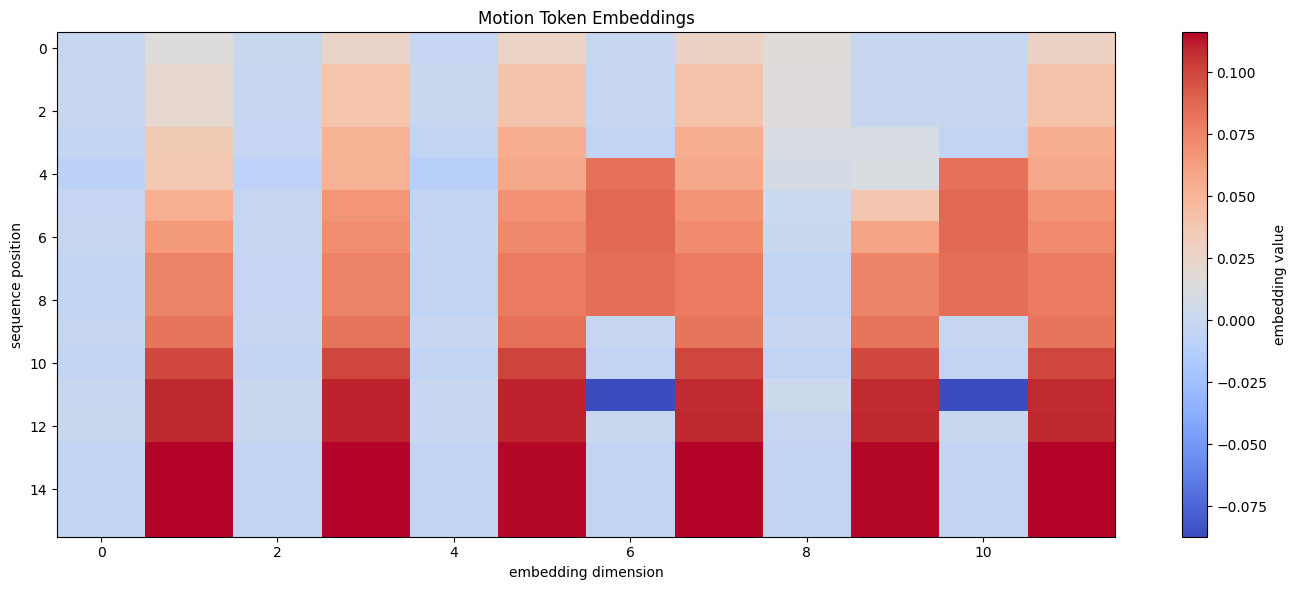

In [100]:
# Transformer Model Deconstruction - 2. Motion Embedding Lookup

motion_embedding_weight = torch.tensor(
    action_embedding_table,
    dtype=torch.float32,
)

motion_embedding = nn.Embedding.from_pretrained(
    motion_embedding_weight,
    freeze=False,
)

token_emb = motion_embedding(
    idx
)

print(
    "idx shape:",
    idx.shape,
)

print(
    "token_emb shape:",
    token_emb.shape,
)

print(
    "first token id:",
    int(idx[0, 0]),
)

print(
    "first token embedding:",
)

print(
    token_emb[0, 0]
)

plt.figure(
    figsize=(14, 6)
)

plt.imshow(
    token_emb[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

plt.title(
    "Motion Token Embeddings"
)

plt.xlabel(
    "embedding dimension"
)

plt.ylabel(
    "sequence position"
)

plt.colorbar(
    label="embedding value"
)

plt.tight_layout()
plt.show()

## Position Embedding

The motion embeddings describe what motion occurred, while positional embeddings describe where each motion appears in the sequence. Both representations are added element-wise before the sequence enters the transformer blocks.

token_emb shape: torch.Size([1, 16, 12])
posit_emb shape: torch.Size([16, 12])
x shape: torch.Size([1, 16, 12])


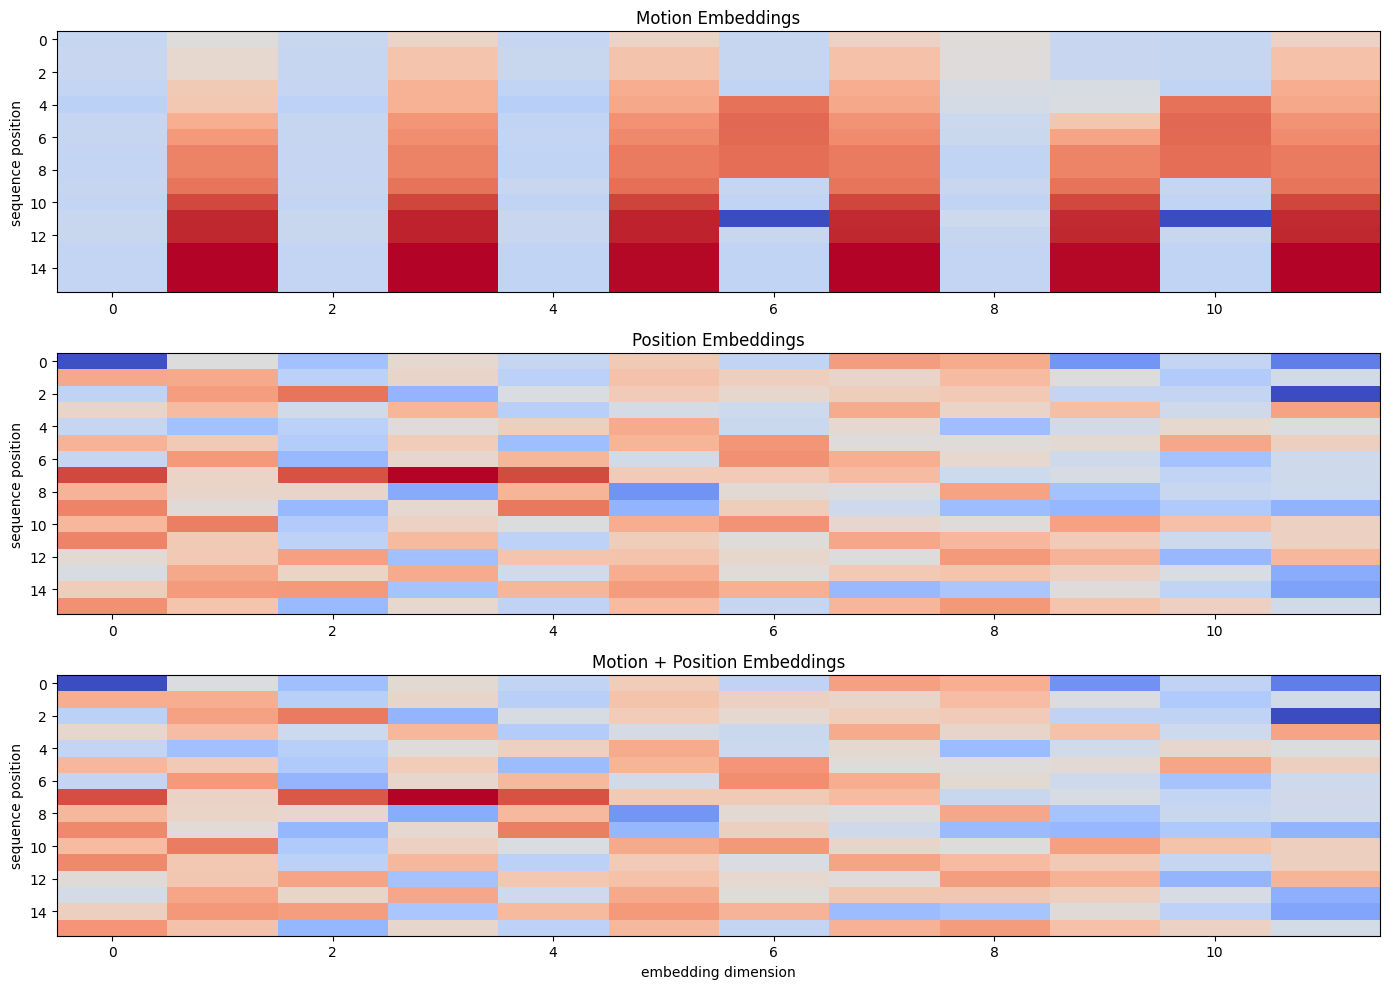

In [101]:
# Transformer Model Deconstruction - 3. Position Embedding

B, T, motion_dim = token_emb.shape

embed_dim = motion_dim

position_embedding = nn.Embedding(
    DECONSTRUCTION_SEQ_LEN,
    embed_dim,
)

position_ids = torch.arange(
    T,
    dtype=torch.long,
)

posit_emb = position_embedding(
    position_ids
)

x = (
    token_emb
    + posit_emb.unsqueeze(0)
)

print(
    "token_emb shape:",
    token_emb.shape,
)

print(
    "posit_emb shape:",
    posit_emb.shape,
)

print(
    "x shape:",
    x.shape,
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
)

axes[0].imshow(
    token_emb[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "Motion Embeddings"
)

axes[0].set_ylabel(
    "sequence position"
)


axes[1].imshow(
    posit_emb
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "Position Embeddings"
)

axes[1].set_ylabel(
    "sequence position"
)


axes[2].imshow(
    x[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[2].set_title(
    "Motion + Position Embeddings"
)

axes[2].set_xlabel(
    "embedding dimension"
)

axes[2].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

## LayerNorm + QKV Projection

The combined motion and position representation is first normalized, then projected into Query, Key, and Value tensors. These tensors are the inputs used by multi-head self-attention to compare motion states across the sequence.

x shape: torch.Size([1, 16, 12])
x_norm shape: torch.Size([1, 16, 12])
qkv shape: torch.Size([1, 16, 36])
q shape: torch.Size([1, 3, 16, 4])
k shape: torch.Size([1, 3, 16, 4])
v shape: torch.Size([1, 3, 16, 4])


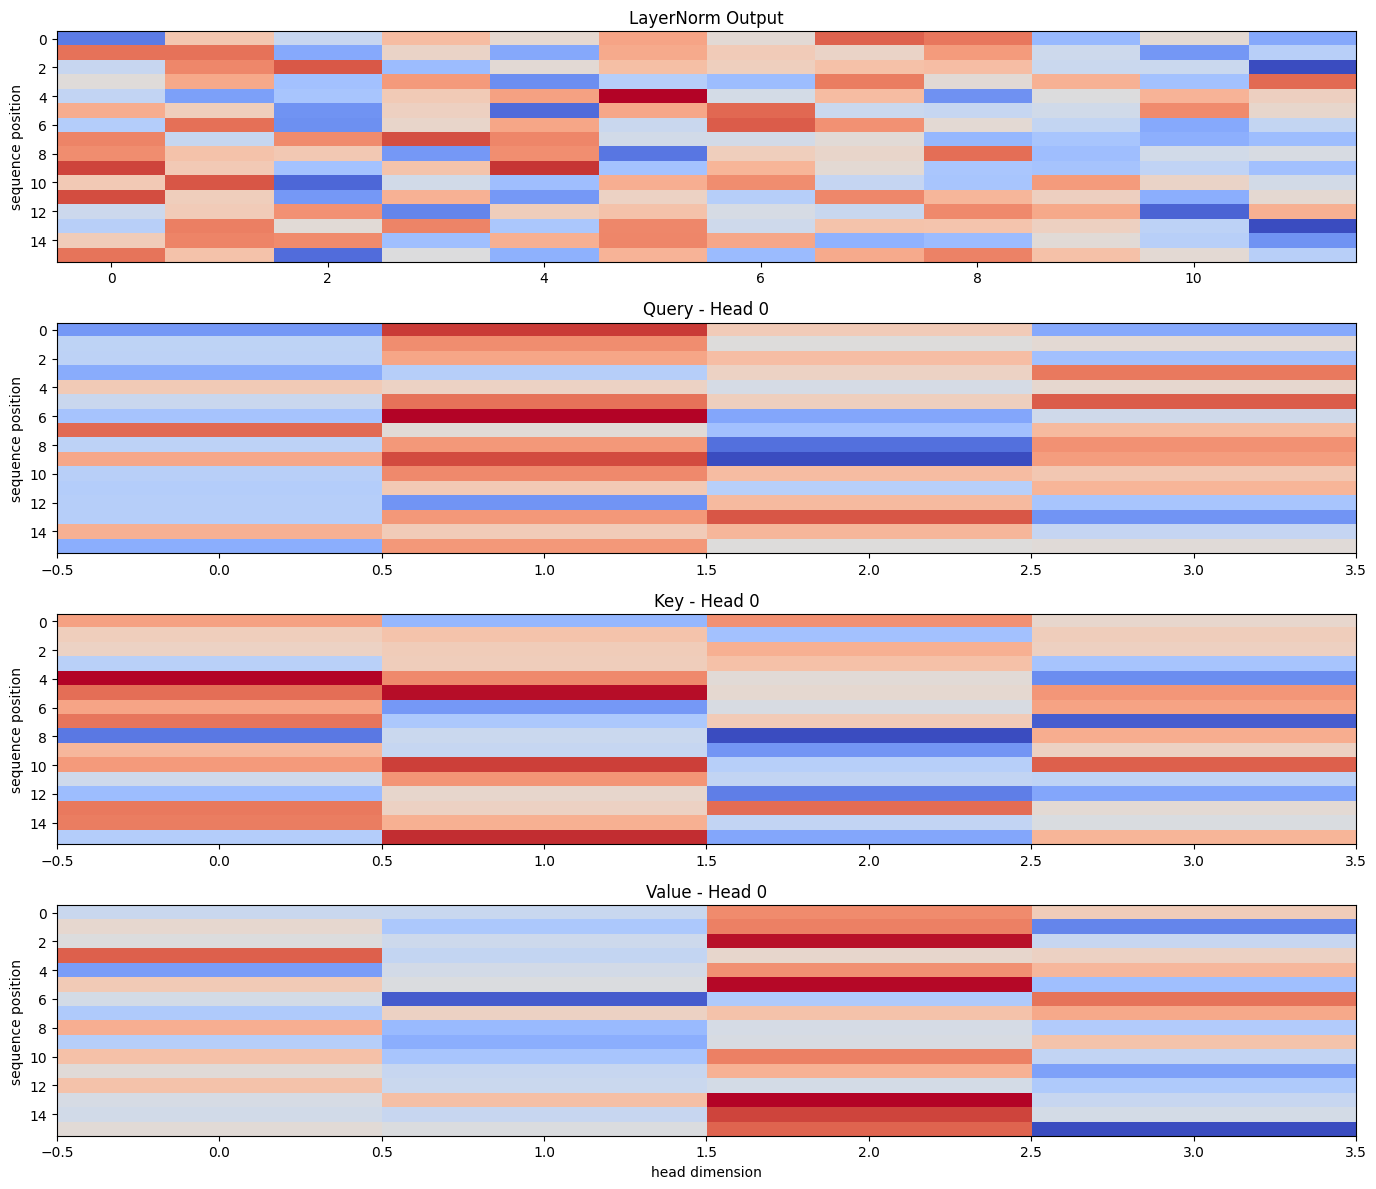

In [102]:
# Transformer Model Deconstruction - 4. LayerNorm + QKV Projection

B, T, E = x.shape

n_heads = 3
head_dim = E // n_heads

if E % n_heads != 0:
    raise ValueError(
        f"embed_dim={E} must be divisible by n_heads={n_heads}"
    )


# ---------------------------------------------------------
# LayerNorm
# ---------------------------------------------------------

layernorm_1 = nn.LayerNorm(
    E,
    eps=1e-5,
)

x_norm = layernorm_1(
    x
)


# ---------------------------------------------------------
# QKV projection
# ---------------------------------------------------------

QKV = nn.Linear(
    E,
    3 * E,
    bias=True,
)

qkv = QKV(
    x_norm
)

q, k, v = torch.split(
    qkv,
    E,
    dim=2,
)


# ---------------------------------------------------------
# Reshape into attention heads
# ---------------------------------------------------------

q = (
    q
    .view(
        B,
        T,
        n_heads,
        head_dim,
    )
    .transpose(
        1,
        2,
    )
)

k = (
    k
    .view(
        B,
        T,
        n_heads,
        head_dim,
    )
    .transpose(
        1,
        2,
    )
)

v = (
    v
    .view(
        B,
        T,
        n_heads,
        head_dim,
    )
    .transpose(
        1,
        2,
    )
)


# ---------------------------------------------------------
# Shapes
# ---------------------------------------------------------

print(
    "x shape:",
    x.shape,
)

print(
    "x_norm shape:",
    x_norm.shape,
)

print(
    "qkv shape:",
    qkv.shape,
)

print(
    "q shape:",
    q.shape,
)

print(
    "k shape:",
    k.shape,
)

print(
    "v shape:",
    v.shape,
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 12),
)

axes[0].imshow(
    x_norm[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "LayerNorm Output"
)

axes[0].set_ylabel(
    "sequence position"
)


axes[1].imshow(
    q[0, 0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "Query - Head 0"
)

axes[1].set_ylabel(
    "sequence position"
)


axes[2].imshow(
    k[0, 0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[2].set_title(
    "Key - Head 0"
)

axes[2].set_ylabel(
    "sequence position"
)


axes[3].imshow(
    v[0, 0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[3].set_title(
    "Value - Head 0"
)

axes[3].set_xlabel(
    "head dimension"
)

axes[3].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

## Attention Scores + Causal Mask

Queries are compared with keys to produce attention scores for every sequence position. A causal mask removes access to future motion tokens, and softmax converts the remaining scores into attention weights.

attention_scores shape: torch.Size([1, 3, 16, 16])
attention_weights shape: torch.Size([1, 3, 16, 16])


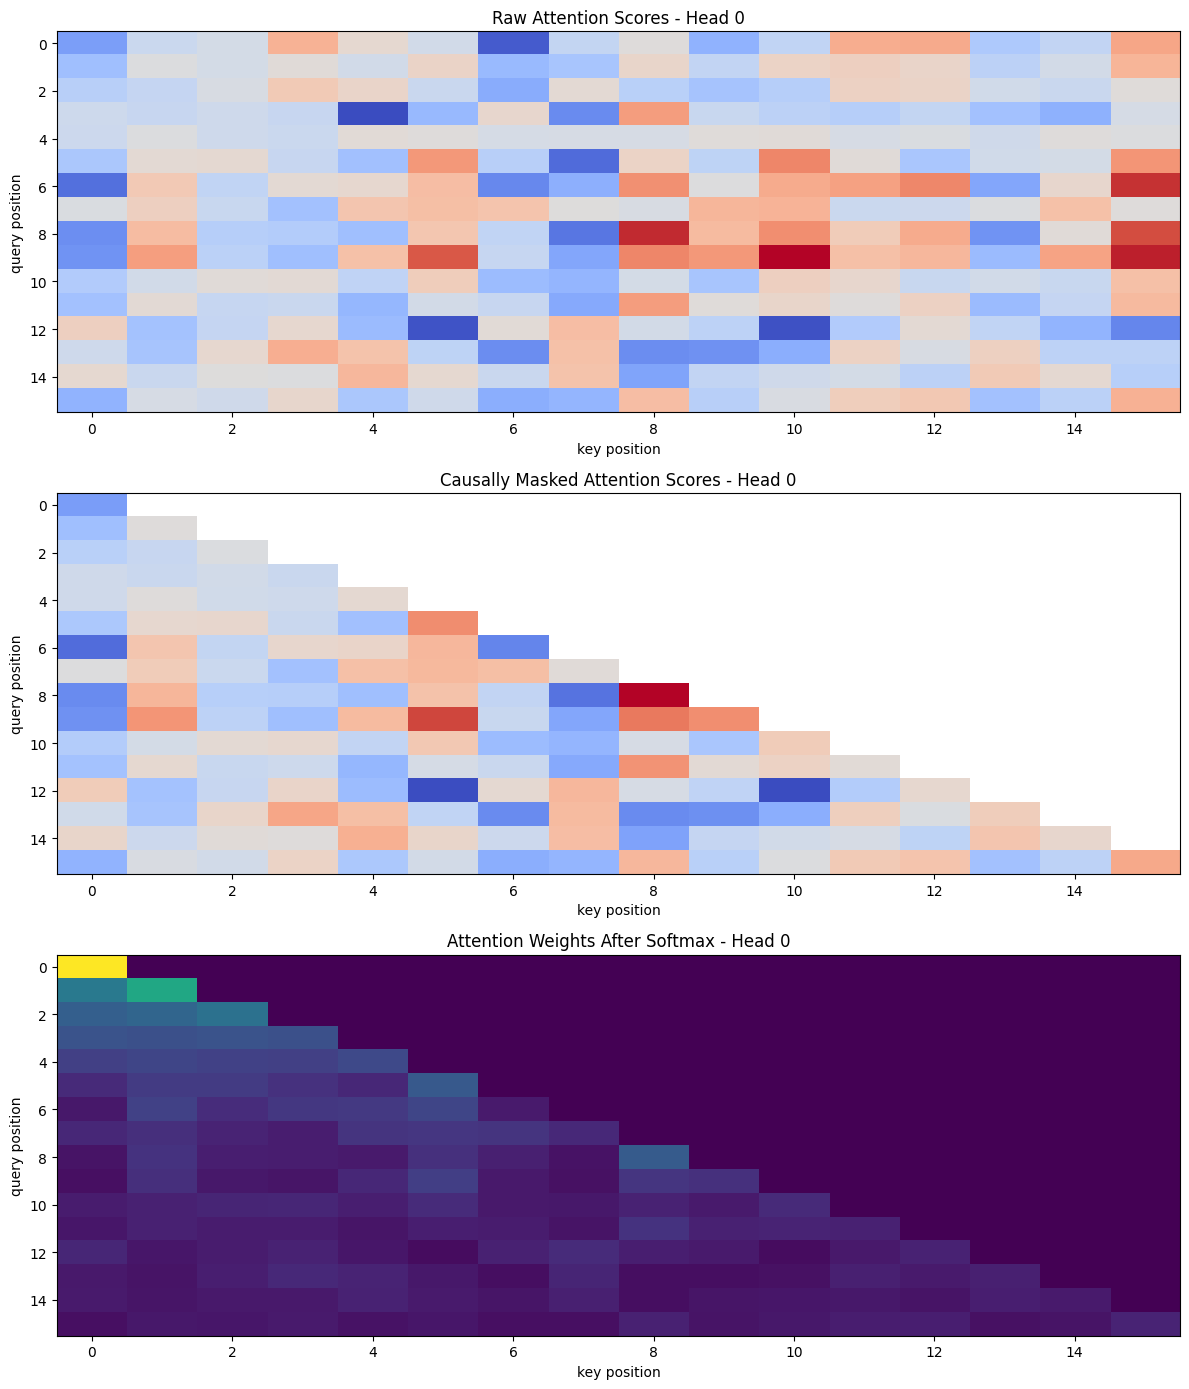

In [103]:
# Transformer Model Deconstruction - 5. Attention Scores + Causal Mask

# ---------------------------------------------------------
# Raw attention scores
# ---------------------------------------------------------

attention_scores = (
    q
    @ k.transpose(-2, -1)
) / np.sqrt(head_dim)

print(
    "attention_scores shape:",
    attention_scores.shape,
)


# ---------------------------------------------------------
# Causal mask
# ---------------------------------------------------------

causal_mask = torch.triu(
    torch.ones(
        T,
        T,
        dtype=torch.bool,
    ),
    diagonal=1,
)

attention_scores_masked = (
    attention_scores
    .masked_fill(
        causal_mask,
        float("-inf"),
    )
)


# ---------------------------------------------------------
# Softmax -> attention weights
# ---------------------------------------------------------

attention_weights = F.softmax(
    attention_scores_masked,
    dim=-1,
)

print(
    "attention_weights shape:",
    attention_weights.shape,
)


# ---------------------------------------------------------
# Visualization - Head 0
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14),
)

axes[0].imshow(
    attention_scores[
        0,
        0,
    ]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "Raw Attention Scores - Head 0"
)

axes[0].set_xlabel(
    "key position"
)

axes[0].set_ylabel(
    "query position"
)


masked_for_plot = (
    attention_scores_masked[
        0,
        0,
    ]
    .detach()
    .cpu()
    .numpy()
)

masked_for_plot = np.where(
    np.isfinite(
        masked_for_plot
    ),
    masked_for_plot,
    np.nan,
)

axes[1].imshow(
    masked_for_plot,
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "Causally Masked Attention Scores - Head 0"
)

axes[1].set_xlabel(
    "key position"
)

axes[1].set_ylabel(
    "query position"
)


axes[2].imshow(
    attention_weights[
        0,
        0,
    ]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="viridis",
    interpolation="nearest",
)

axes[2].set_title(
    "Attention Weights After Softmax - Head 0"
)

axes[2].set_xlabel(
    "key position"
)

axes[2].set_ylabel(
    "query position"
)

plt.tight_layout()
plt.show()

## Attention Output + Residual

Attention weights are applied to the Value vectors to produce one output per head. The heads are concatenated, projected back to the embedding dimension, and added to the residual stream.

attention_out shape: torch.Size([1, 3, 16, 4])
attention_out_merged shape: torch.Size([1, 16, 12])
attention_projected shape: torch.Size([1, 16, 12])
x_att shape: torch.Size([1, 16, 12])


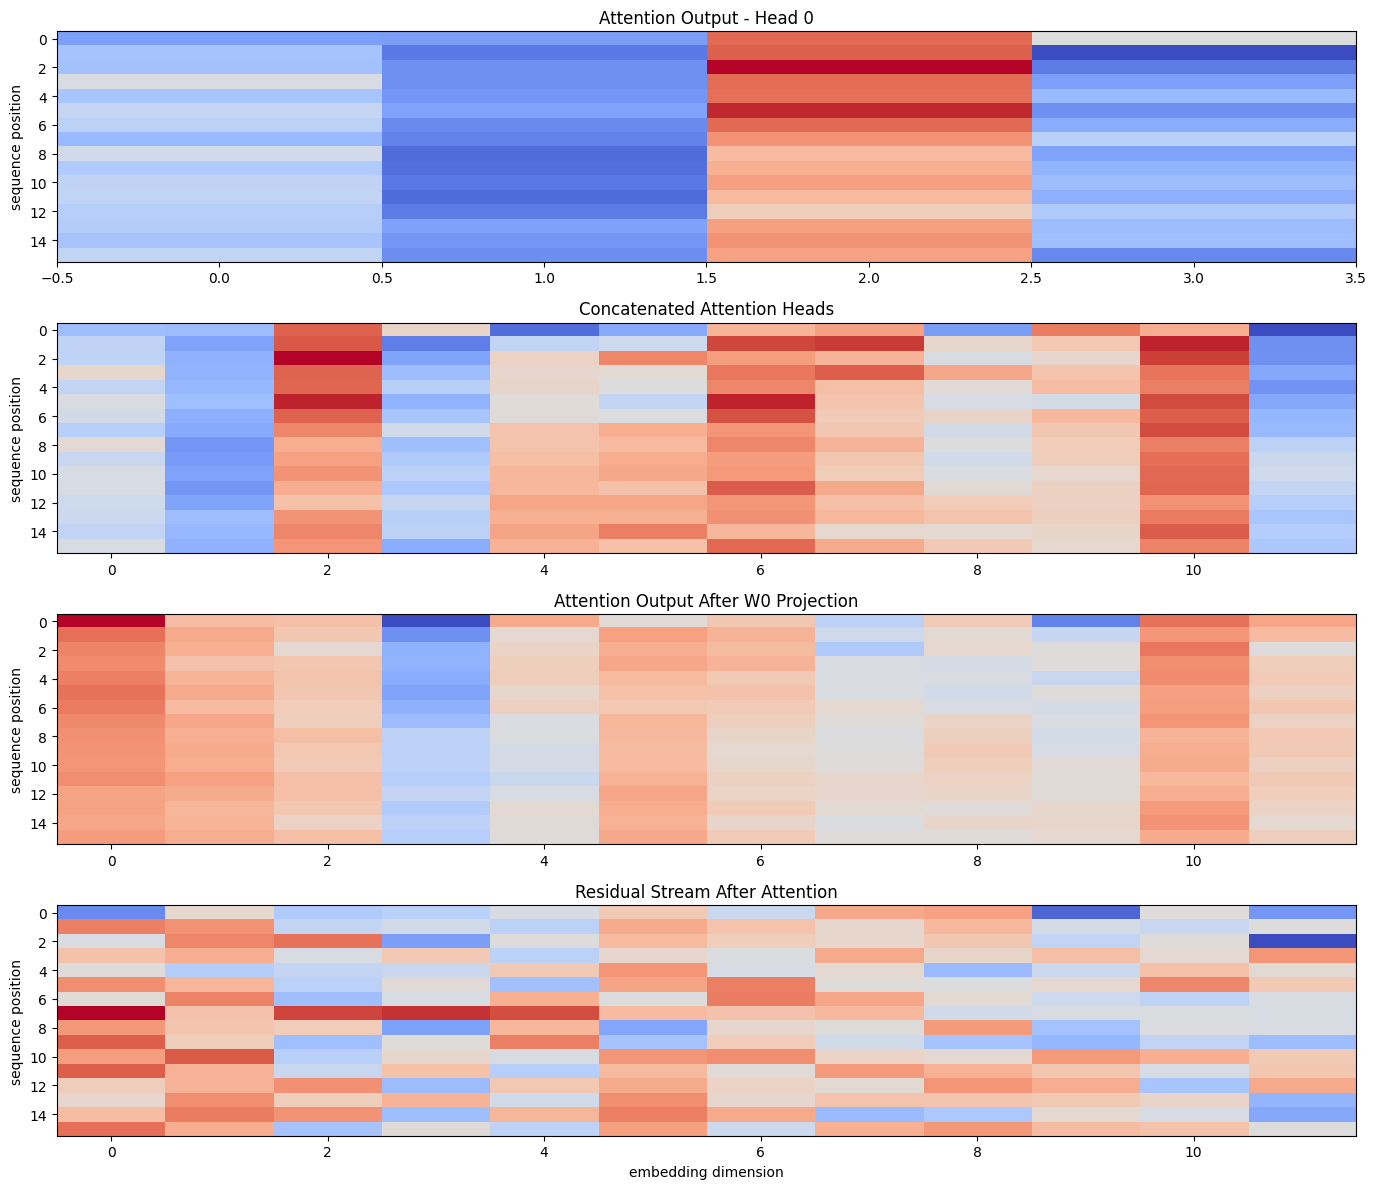

In [104]:
# Transformer Model Deconstruction - 6. Attention Output + Residual

# ---------------------------------------------------------
# Attention weights @ V
# ---------------------------------------------------------

attention_out = (
    attention_weights
    @ v
)

print(
    "attention_out shape:",
    attention_out.shape,
)


# ---------------------------------------------------------
# Recombine heads
# [B, n_heads, T, head_dim]
# -> [B, T, E]
# ---------------------------------------------------------

attention_out_merged = (
    attention_out
    .transpose(
        1,
        2,
    )
    .contiguous()
    .view(
        B,
        T,
        E,
    )
)

print(
    "attention_out_merged shape:",
    attention_out_merged.shape,
)


# ---------------------------------------------------------
# Output projection W0
# ---------------------------------------------------------

W0 = nn.Linear(
    E,
    E,
    bias=True,
)

attention_projected = W0(
    attention_out_merged
)

print(
    "attention_projected shape:",
    attention_projected.shape,
)


# ---------------------------------------------------------
# Residual connection
# ---------------------------------------------------------

x_att = (
    x
    + attention_projected
)

print(
    "x_att shape:",
    x_att.shape,
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 12),
)

axes[0].imshow(
    attention_out[
        0,
        0,
    ]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "Attention Output - Head 0"
)

axes[0].set_ylabel(
    "sequence position"
)


axes[1].imshow(
    attention_out_merged[
        0
    ]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "Concatenated Attention Heads"
)

axes[1].set_ylabel(
    "sequence position"
)


axes[2].imshow(
    attention_projected[
        0
    ]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[2].set_title(
    "Attention Output After W0 Projection"
)

axes[2].set_ylabel(
    "sequence position"
)


axes[3].imshow(
    x_att[
        0
    ]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[3].set_title(
    "Residual Stream After Attention"
)

axes[3].set_xlabel(
    "embedding dimension"
)

axes[3].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

## MLP Subblock + Residual

The attention output is normalized, expanded through the MLP, passed through GELU, projected back to the embedding dimension, and added to the residual stream. This completes one full transformer block.

x_att shape: torch.Size([1, 16, 12])
x_ff_norm shape: torch.Size([1, 16, 12])
mlp_hidden shape: torch.Size([1, 16, 48])
mlp_activated shape: torch.Size([1, 16, 48])
mlp_out shape: torch.Size([1, 16, 12])
x_block shape: torch.Size([1, 16, 12])


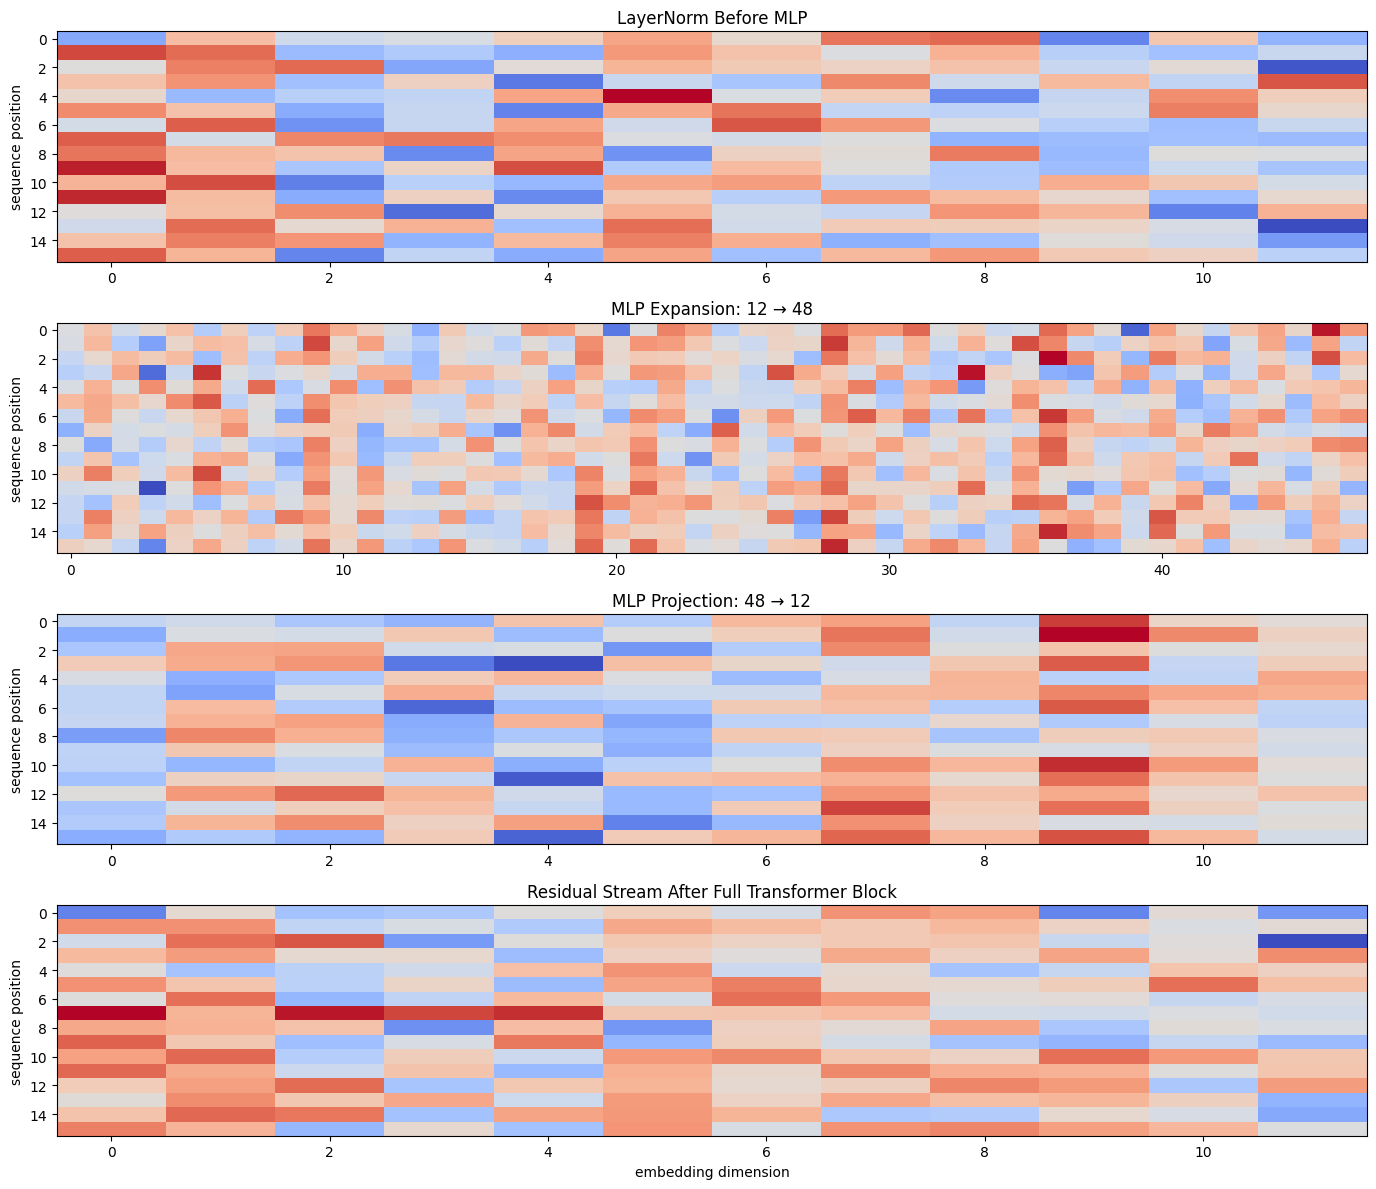

In [105]:
# Transformer Model Deconstruction - 7. MLP Subblock + Residual

# ---------------------------------------------------------
# LayerNorm before MLP
# ---------------------------------------------------------

layernorm_2 = nn.LayerNorm(
    E,
    eps=1e-5,
)

x_ff_norm = layernorm_2(
    x_att
)


# ---------------------------------------------------------
# MLP
# 12 -> 48 -> 12
# ---------------------------------------------------------

mlp_1 = nn.Linear(
    E,
    4 * E,
    bias=True,
)

gelu = nn.GELU()

mlp_2 = nn.Linear(
    4 * E,
    E,
    bias=True,
)


mlp_hidden = mlp_1(
    x_ff_norm
)

mlp_activated = gelu(
    mlp_hidden
)

mlp_out = mlp_2(
    mlp_activated
)


# ---------------------------------------------------------
# Residual connection
# ---------------------------------------------------------

x_block = (
    x_att
    + mlp_out
)


# ---------------------------------------------------------
# Shapes
# ---------------------------------------------------------

print(
    "x_att shape:",
    x_att.shape,
)

print(
    "x_ff_norm shape:",
    x_ff_norm.shape,
)

print(
    "mlp_hidden shape:",
    mlp_hidden.shape,
)

print(
    "mlp_activated shape:",
    mlp_activated.shape,
)

print(
    "mlp_out shape:",
    mlp_out.shape,
)

print(
    "x_block shape:",
    x_block.shape,
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 12),
)

axes[0].imshow(
    x_ff_norm[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "LayerNorm Before MLP"
)

axes[0].set_ylabel(
    "sequence position"
)


axes[1].imshow(
    mlp_hidden[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "MLP Expansion: 12 → 48"
)

axes[1].set_ylabel(
    "sequence position"
)


axes[2].imshow(
    mlp_out[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[2].set_title(
    "MLP Projection: 48 → 12"
)

axes[2].set_ylabel(
    "sequence position"
)


axes[3].imshow(
    x_block[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[3].set_title(
    "Residual Stream After Full Transformer Block"
)

axes[3].set_xlabel(
    "embedding dimension"
)

axes[3].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

## Final LayerNorm + Motion Prediction Head

The final transformer representation is normalized and projected back into the 12D motion space. The resulting `z_pred_next` is the model's prediction of the next true motion representation.

x_block shape: torch.Size([1, 16, 12])
x_final shape: torch.Size([1, 16, 12])
z_pred_next shape: torch.Size([1, 16, 12])
z_true_next shape: torch.Size([1, 16, 12])


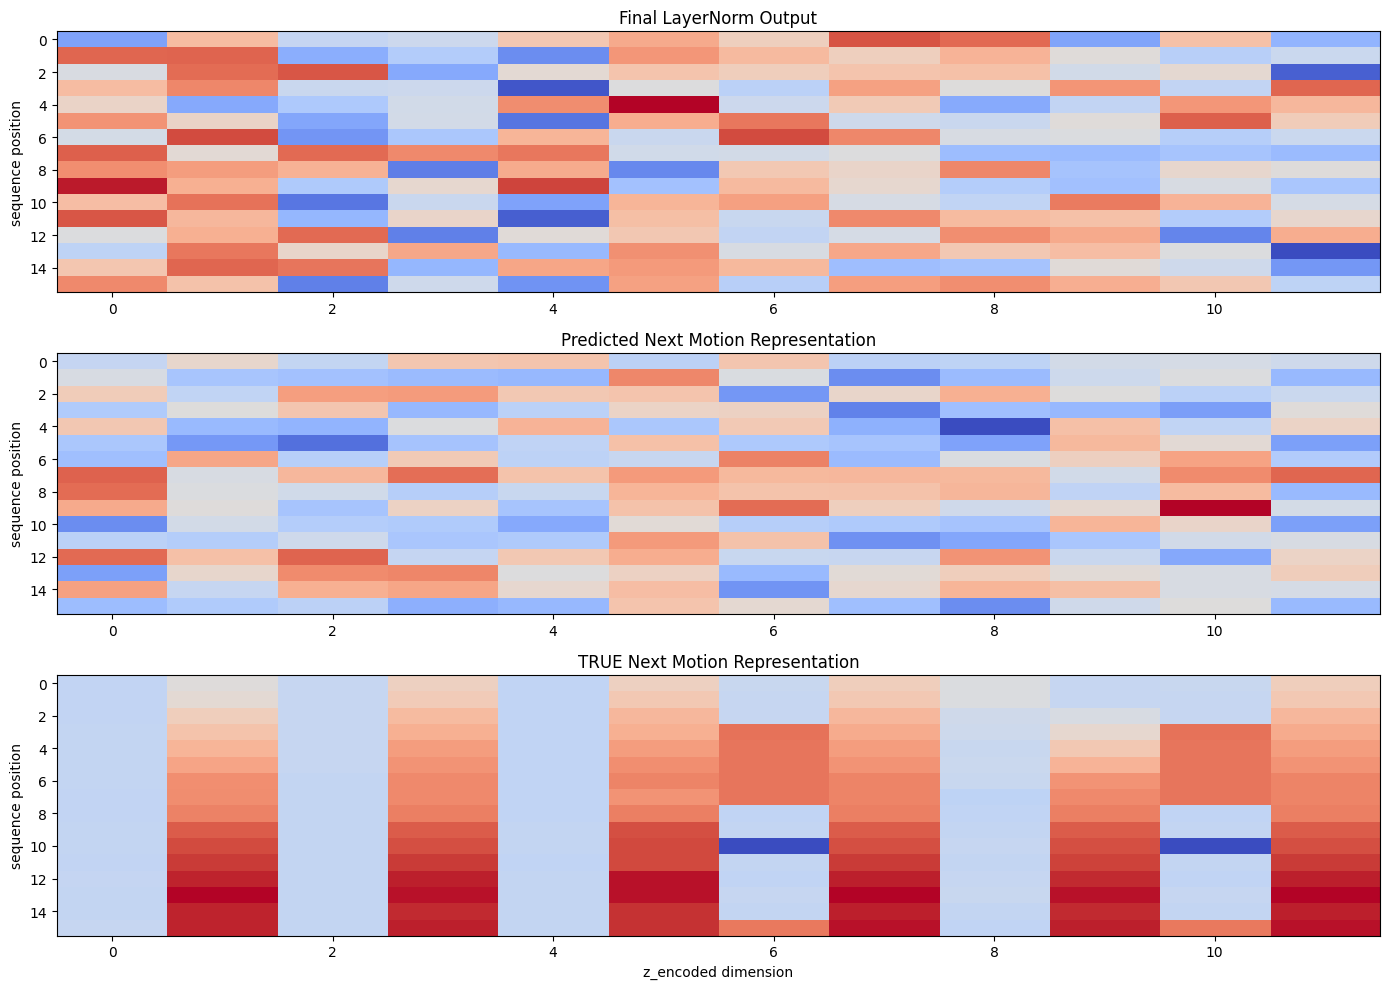

In [106]:
# Transformer Model Deconstruction - 8. Final LayerNorm + Motion Prediction Head

# ---------------------------------------------------------
# Final LayerNorm
# ---------------------------------------------------------

layernorm_final = nn.LayerNorm(
    E,
    eps=1e-5,
)

x_final = layernorm_final(
    x_block
)


# ---------------------------------------------------------
# Motion prediction head
# 12 -> 12
# ---------------------------------------------------------

motion_head = nn.Linear(
    E,
    E,
    bias=False,
)

z_pred_next = motion_head(
    x_final
)


# ---------------------------------------------------------
# Shapes
# ---------------------------------------------------------

print(
    "x_block shape:",
    x_block.shape,
)

print(
    "x_final shape:",
    x_final.shape,
)

print(
    "z_pred_next shape:",
    z_pred_next.shape,
)

print(
    "z_true_next shape:",
    z_true_next.shape,
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
)

axes[0].imshow(
    x_final[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "Final LayerNorm Output"
)

axes[0].set_ylabel(
    "sequence position"
)


axes[1].imshow(
    z_pred_next[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "Predicted Next Motion Representation"
)

axes[1].set_ylabel(
    "sequence position"
)


axes[2].imshow(
    z_true_next[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[2].set_title(
    "TRUE Next Motion Representation"
)

axes[2].set_xlabel(
    "z_encoded dimension"
)

axes[2].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

## Loss + Backward

The prediction is compared directly with the true next `z_encoded` extracted from the following motion window. MSE measures the continuous motion error, and `backward()` propagates that error through the motion head, transformer block, position embeddings, and motion embeddings.

loss: 0.3149975836277008

motion_head grad mean: 0.03018130548298359
final layernorm grad mean: 0.05059993267059326
mlp_2 grad mean: 0.006396763026714325
mlp_1 grad mean: 0.0028103734366595745
W0 grad mean: 0.010986875742673874
QKV grad mean: 0.0036393492482602596
position embedding grad mean: 0.0037048913072794676
motion embedding grad mean: 0.00010518212366150692


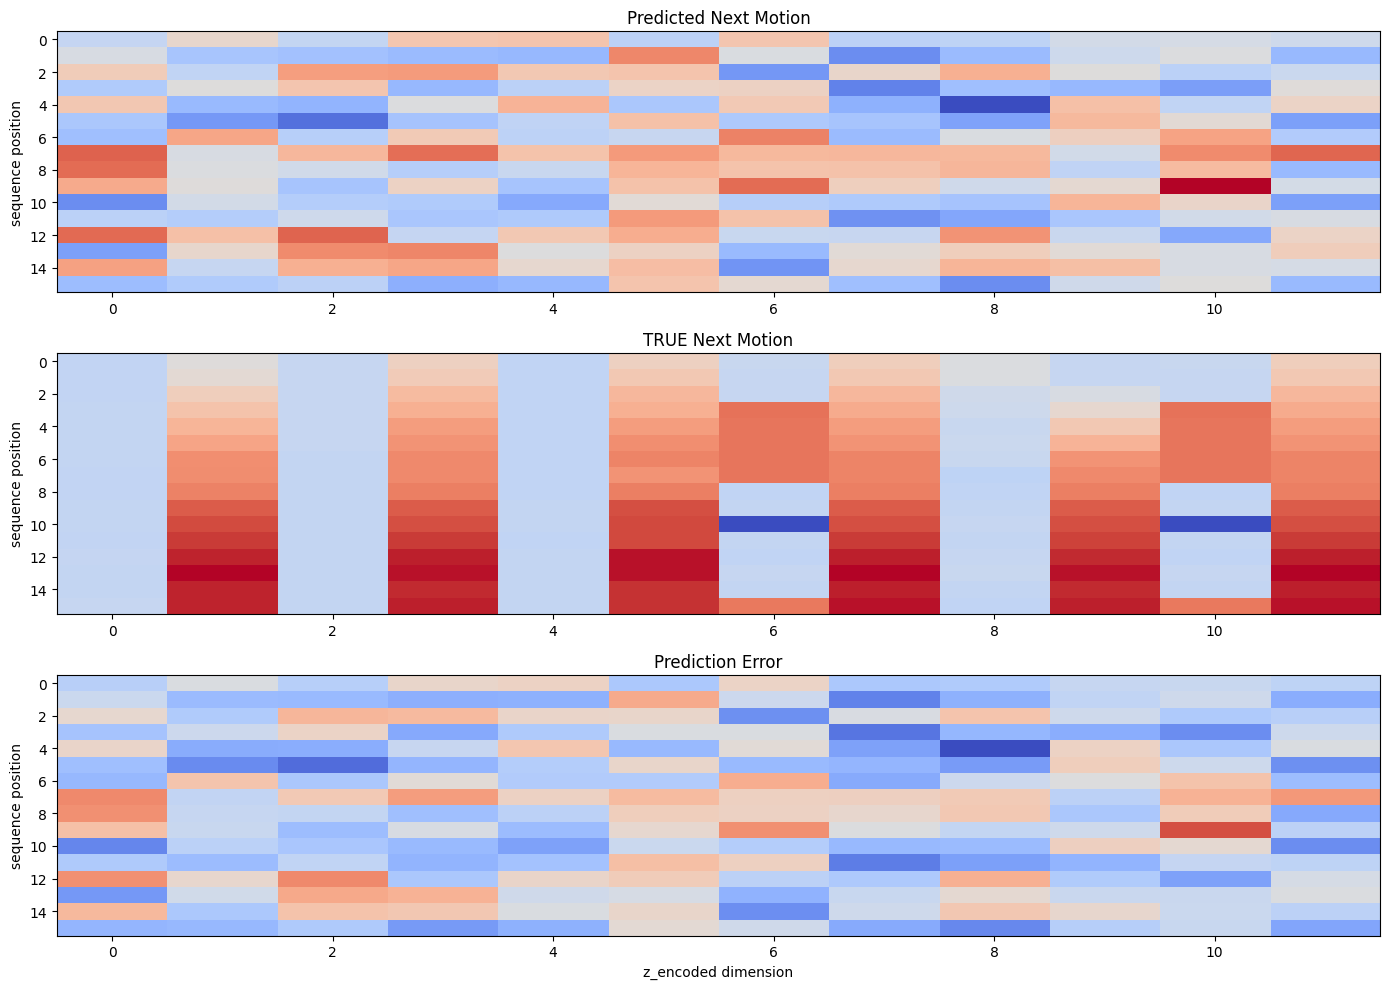

In [107]:
# Transformer Model Deconstruction - 9. Loss + Backward

# ---------------------------------------------------------
# MSE loss
# ---------------------------------------------------------

loss = F.mse_loss(
    z_pred_next,
    z_true_next,
)

print(
    "loss:",
    float(loss.item()),
)


# ---------------------------------------------------------
# Backward
# ---------------------------------------------------------

loss.backward()


# ---------------------------------------------------------
# Gradient review
# ---------------------------------------------------------

print()
print(
    "motion_head grad mean:",
    motion_head.weight.grad.abs().mean().item(),
)

print(
    "final layernorm grad mean:",
    layernorm_final.weight.grad.abs().mean().item(),
)

print(
    "mlp_2 grad mean:",
    mlp_2.weight.grad.abs().mean().item(),
)

print(
    "mlp_1 grad mean:",
    mlp_1.weight.grad.abs().mean().item(),
)

print(
    "W0 grad mean:",
    W0.weight.grad.abs().mean().item(),
)

print(
    "QKV grad mean:",
    QKV.weight.grad.abs().mean().item(),
)

print(
    "position embedding grad mean:",
    position_embedding.weight.grad.abs().mean().item(),
)

print(
    "motion embedding grad mean:",
    motion_embedding.weight.grad.abs().mean().item(),
)


# ---------------------------------------------------------
# Prediction error
# ---------------------------------------------------------

prediction_error = (
    z_pred_next
    - z_true_next
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(
        14,
        10,
    ),
)

axes[0].imshow(
    z_pred_next[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "Predicted Next Motion"
)

axes[0].set_ylabel(
    "sequence position"
)


axes[1].imshow(
    z_true_next[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "TRUE Next Motion"
)

axes[1].set_ylabel(
    "sequence position"
)


error_max_abs = max(
    float(
        prediction_error
        .detach()
        .abs()
        .max()
        .item()
    ),
    1e-8,
)

axes[2].imshow(
    prediction_error[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
    vmin=-error_max_abs,
    vmax=error_max_abs,
)

axes[2].set_title(
    "Prediction Error"
)

axes[2].set_xlabel(
    "z_encoded dimension"
)

axes[2].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

## Optimizer Step

The optimizer updates all trainable parameters using the gradients produced by the motion prediction loss. After one update, the same input sequence is passed through the model again to verify whether the loss moves in the correct direction.

loss before update: 0.3149975836277008
loss after update: 0.29844608902931213
loss change: -0.016551494598388672


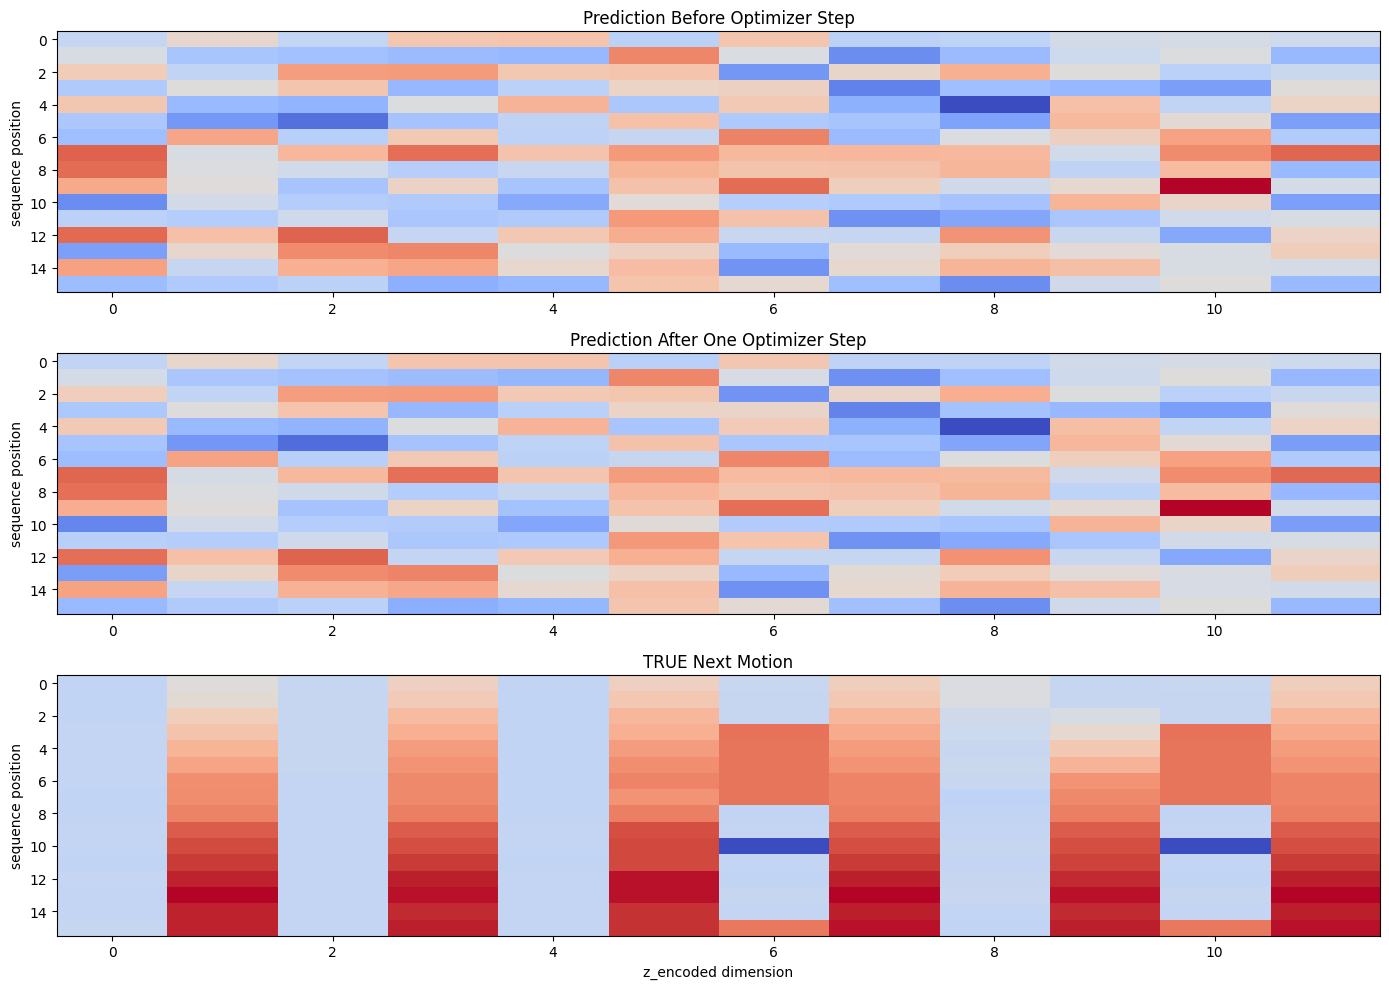

In [108]:
# Transformer Model Deconstruction - 10. Optimizer Step

# ---------------------------------------------------------
# Collect trainable parameters
# ---------------------------------------------------------

parameters = (
    list(motion_embedding.parameters())
    + list(position_embedding.parameters())
    + list(layernorm_1.parameters())
    + list(QKV.parameters())
    + list(W0.parameters())
    + list(layernorm_2.parameters())
    + list(mlp_1.parameters())
    + list(mlp_2.parameters())
    + list(layernorm_final.parameters())
    + list(motion_head.parameters())
)

optimizer = torch.optim.AdamW(
    parameters,
    lr=0.001,
    weight_decay=0.01,
)


# ---------------------------------------------------------
# Save loss before update
# ---------------------------------------------------------

loss_before = float(
    loss.item()
)


# ---------------------------------------------------------
# Optimizer step
# ---------------------------------------------------------

optimizer.step()

optimizer.zero_grad(
    set_to_none=True
)


# ---------------------------------------------------------
# Forward again after one update
# ---------------------------------------------------------

token_emb_after = motion_embedding(
    idx
)

posit_emb_after = position_embedding(
    position_ids
)

x_after = (
    token_emb_after
    + posit_emb_after.unsqueeze(0)
)


# LayerNorm + QKV

x_norm_after = layernorm_1(
    x_after
)

qkv_after = QKV(
    x_norm_after
)

q_after, k_after, v_after = torch.split(
    qkv_after,
    E,
    dim=2,
)

q_after = (
    q_after
    .view(
        B,
        T,
        n_heads,
        head_dim,
    )
    .transpose(
        1,
        2,
    )
)

k_after = (
    k_after
    .view(
        B,
        T,
        n_heads,
        head_dim,
    )
    .transpose(
        1,
        2,
    )
)

v_after = (
    v_after
    .view(
        B,
        T,
        n_heads,
        head_dim,
    )
    .transpose(
        1,
        2,
    )
)


# Attention scores

attention_scores_after = (
    q_after
    @ k_after.transpose(-2, -1)
) / np.sqrt(
    head_dim
)

attention_scores_masked_after = (
    attention_scores_after
    .masked_fill(
        causal_mask,
        float("-inf"),
    )
)

attention_weights_after = F.softmax(
    attention_scores_masked_after,
    dim=-1,
)


# Attention output

attention_out_after = (
    attention_weights_after
    @ v_after
)

attention_out_merged_after = (
    attention_out_after
    .transpose(
        1,
        2,
    )
    .contiguous()
    .view(
        B,
        T,
        E,
    )
)

attention_projected_after = W0(
    attention_out_merged_after
)

x_att_after = (
    x_after
    + attention_projected_after
)


# MLP

x_ff_norm_after = layernorm_2(
    x_att_after
)

mlp_hidden_after = mlp_1(
    x_ff_norm_after
)

mlp_activated_after = F.gelu(
    mlp_hidden_after
)

mlp_out_after = mlp_2(
    mlp_activated_after
)

x_block_after = (
    x_att_after
    + mlp_out_after
)


# Final prediction

x_final_after = layernorm_final(
    x_block_after
)

z_pred_next_after = motion_head(
    x_final_after
)


# ---------------------------------------------------------
# Loss after one update
# ---------------------------------------------------------

loss_after = F.mse_loss(
    z_pred_next_after,
    z_true_next,
)

print(
    "loss before update:",
    loss_before,
)

print(
    "loss after update:",
    float(
        loss_after.item()
    ),
)

print(
    "loss change:",
    float(
        loss_after.item()
        - loss_before
    ),
)


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
)

axes[0].imshow(
    z_pred_next[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[0].set_title(
    "Prediction Before Optimizer Step"
)

axes[0].set_ylabel(
    "sequence position"
)


axes[1].imshow(
    z_pred_next_after[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[1].set_title(
    "Prediction After One Optimizer Step"
)

axes[1].set_ylabel(
    "sequence position"
)


axes[2].imshow(
    z_true_next[0]
    .detach()
    .cpu()
    .numpy(),
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)

axes[2].set_title(
    "TRUE Next Motion"
)

axes[2].set_xlabel(
    "z_encoded dimension"
)

axes[2].set_ylabel(
    "sequence position"
)

plt.tight_layout()
plt.show()

# Train-Test-Val Split

In [109]:
# Motion Token Dataset - Train / Val / Test Split

SPLIT_RANDOM_STATE = 42
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

token_paths = sorted(TOKENS_DIR.glob("lunar_lander_motion_tokens_episode_*.npz"))

episode_ids = np.array([
    int(path.stem.split("episode_")[-1])
    for path in token_paths
])

rng = np.random.default_rng(SPLIT_RANDOM_STATE)
shuffled_episode_ids = episode_ids.copy()
rng.shuffle(shuffled_episode_ids)

n_episodes = len(shuffled_episode_ids)
n_train = int(n_episodes * TRAIN_RATIO)
n_val = int(n_episodes * VAL_RATIO)

train_episode_ids = set(shuffled_episode_ids[:n_train])
val_episode_ids = set(shuffled_episode_ids[n_train:n_train + n_val])
test_episode_ids = set(shuffled_episode_ids[n_train + n_val:])

train_token_paths = [
    path for path in token_paths
    if int(path.stem.split("episode_")[-1]) in train_episode_ids
]

val_token_paths = [
    path for path in token_paths
    if int(path.stem.split("episode_")[-1]) in val_episode_ids
]

test_token_paths = [
    path for path in token_paths
    if int(path.stem.split("episode_")[-1]) in test_episode_ids
]

def count_tokens(paths):
    total = 0
    shapes = []

    for path in paths:
        data = np.load(path)
        motion_token_ids = data["motion_token_ids"]
        z_raw = data["z_raw"]

        total += len(motion_token_ids)
        shapes.append(
            {
                "file": path.name,
                "motion_token_ids_shape": motion_token_ids.shape,
                "z_raw_shape": z_raw.shape,
            }
        )

    return total, shapes

train_tokens_count, train_shapes = count_tokens(train_token_paths)
val_tokens_count, val_shapes = count_tokens(val_token_paths)
test_tokens_count, test_shapes = count_tokens(test_token_paths)

print("split ratios:")
print(f"train={TRAIN_RATIO:.2f}, val={VAL_RATIO:.2f}, test={TEST_RATIO:.2f}")

print("\nepisodes:")
print("total:", n_episodes)
print("train:", len(train_token_paths), sorted(train_episode_ids))
print("val:", len(val_token_paths), sorted(val_episode_ids))
print("test:", len(test_token_paths), sorted(test_episode_ids))

print("\ntoken counts:")
print("train tokens:", train_tokens_count)
print("val tokens:", val_tokens_count)
print("test tokens:", test_tokens_count)

print("\nexample shapes:")
if train_shapes:
    print("train:", train_shapes[0])
if val_shapes:
    print("val:", val_shapes[0])
if test_shapes:
    print("test:", test_shapes[0])

split ratios:
train=0.80, val=0.10, test=0.10

episodes:
total: 20
train: 16 [0, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15, 16, 18, 19]
val: 2 [1, 17]
test: 2 [8, 13]

token counts:
train tokens: 1271
val tokens: 160
test tokens: 160

example shapes:
train: {'file': 'lunar_lander_motion_tokens_episode_0000.npz', 'motion_token_ids_shape': (80,), 'z_raw_shape': (80, 1200)}
val: {'file': 'lunar_lander_motion_tokens_episode_0001.npz', 'motion_token_ids_shape': (80,), 'z_raw_shape': (80, 1200)}
test: {'file': 'lunar_lander_motion_tokens_episode_0008.npz', 'motion_token_ids_shape': (80,), 'z_raw_shape': (80, 1200)}


# Motion Transformer Model

The manually deconstructed operations are now wrapped into reusable `MultiHeadAttention`, `TransformerBlock`, and `MotionModel` classes. The model takes a sequence of motion token IDs, looks up their pretrained motion embeddings, adds positional embeddings, processes the sequence through transformer blocks, and predicts the next 12D motion representation at every sequence position.

In [110]:
# Transformer Model Deconstruction - 11. Motion Transformer Model

n_motion_tokens = action_embedding_table.shape[0]
motion_dim = action_embedding_table.shape[1]

embed_dim = motion_dim
seq_len = DECONSTRUCTION_SEQ_LEN
n_heads = 3
n_blocks = 2


class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.num_heads = n_heads
        self.head_dim = embed_dim // n_heads

        if embed_dim % n_heads != 0:
            raise ValueError("embed_dim must be divisible by n_heads")

        self.QKV = nn.Linear(embed_dim, 3 * embed_dim, bias=True)
        self.W0 = nn.Linear(embed_dim, embed_dim, bias=True)

    def forward(self, x):
        B, T, E = x.shape

        qkv = self.QKV(x)
        q, k, v = torch.split(qkv, E, dim=2)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        out = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        out = out.transpose(1, 2).contiguous().view(B, T, E)
        out = self.W0(out)

        return out


class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()

        self.layernorm_1 = nn.LayerNorm(embed_dim, eps=1e-5)
        self.attn = MultiHeadAttention()

        self.layernorm_2 = nn.LayerNorm(embed_dim, eps=1e-5)
        self.mlp_1 = nn.Linear(embed_dim, 4 * embed_dim, bias=True)
        self.gelu = nn.GELU()
        self.mlp_2 = nn.Linear(4 * embed_dim, embed_dim, bias=True)

    def forward(self, x):
        x = x + self.attn(self.layernorm_1(x))
        x = x + self.mlp_2(self.gelu(self.mlp_1(self.layernorm_2(x))))

        return x


class MotionModel(nn.Module):
    def __init__(self):
        super().__init__()

        motion_embedding_weight = torch.tensor(action_embedding_table, dtype=torch.float32)

        self.wte = nn.Embedding.from_pretrained(motion_embedding_weight, freeze=False)
        self.wpe = nn.Embedding(seq_len, embed_dim)

        self.transformer_blocks = nn.Sequential(
            *[TransformerBlock() for _ in range(n_blocks)]
        )

        self.layernorm_final = nn.LayerNorm(embed_dim, eps=1e-5)
        self.motion_head = nn.Linear(embed_dim, motion_dim, bias=False)

        self.apply(self.weight_inits)

        with torch.no_grad():
            self.wte.weight.copy_(motion_embedding_weight)

    def forward(self, idx):
        B, T = idx.shape

        if T > seq_len:
            raise ValueError(f"Sequence length {T} exceeds seq_len={seq_len}")

        token_emb = self.wte(idx)

        position_ids = torch.arange(T, device=idx.device)
        posit_emb = self.wpe(position_ids)

        x = token_emb + posit_emb
        x = self.transformer_blocks(x)
        x = self.layernorm_final(x)

        z_pred_next = self.motion_head(x)

        return z_pred_next

    def weight_inits(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.xavier_normal_(module.weight)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MotionModel().to(device)

X = idx.to(device)

y = torch.tensor(
    z_true_next,
    dtype=torch.float32,
    device=device
)

out = model(X)

print(f"Input size: {X.shape}")
print(f"Output size: {out.shape}")
print(f"Target size: {y.shape}")

loss = F.mse_loss(out, y)

print(f"Loss: {loss.item()}")

Input size: torch.Size([1, 16])
Output size: torch.Size([1, 16, 12])
Target size: torch.Size([1, 16, 12])
Loss: 0.009245933033525944


/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_40938/3719240897.py:119: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(


## One Training Step

A full training step runs the motion-token sequence through the model, compares the predicted next motion representation with the true `z_encoded` target, backpropagates the MSE loss, and updates all trainable parameters.

In [111]:
# Transformer Model Deconstruction - 12. One Training Step

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

model.train()

optimizer.zero_grad(set_to_none=True)

z_pred = model(X)

loss = F.mse_loss(z_pred, y)

print(f"Loss before update: {loss.item()}")

loss.backward()

optimizer.step()

optimizer.zero_grad(set_to_none=True)

with torch.no_grad():
    z_pred_after = model(X)
    loss_after = F.mse_loss(z_pred_after, y)

print(f"Loss after update: {loss_after.item()}")
print(f"Loss change: {loss_after.item() - loss.item()}")

Loss before update: 0.009245933033525944
Loss after update: 0.00827386137098074
Loss change: -0.0009720716625452042


## Full Training Loop

The full training loop iterates over ordered motion-token sequences from all videos, predicts the next continuous motion representation at every sequence position, and optimizes the model against the true next `z_encoded` extracted from the video.

In [112]:
# Transformer Model - 13. Full Training Loop with Validation

N_EPOCHS = 200
BATCH_SIZE = 16
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.01
EMBEDDING_SNAPSHOT_EVERY = 10
BUILD_LOG_EVERY_EPISODES = 10
TRAIN_LOG_EVERY_BATCHES = 100

# ---------------------------------------------------------
# Fresh model initialization
# ---------------------------------------------------------

model = MotionModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ---------------------------------------------------------
# Build examples helper
# ---------------------------------------------------------

def build_examples(episode_ids, split_name):
    examples = []
    episode_ids_sorted = sorted(episode_ids)

    print(f"Building {split_name} examples from {len(episode_ids_sorted)} episodes...")

    for episode_pos, episode_id in enumerate(episode_ids_sorted, start=1):
        episode_df = motion_token_df[motion_token_df["episode_id"] == episode_id].sort_values("frame").reset_index(drop=True)

        if len(episode_df) < seq_len + 1:
            continue

        episode_sequences = 0

        for start_idx in range(len(episode_df) - seq_len):
            sequence_df = episode_df.iloc[start_idx:start_idx + seq_len + 1]

            X_seq = sequence_df["motion_token_id"].iloc[:-1].to_numpy()

            y_seq = []

            for row_idx in range(1, len(sequence_df)):
                row = sequence_df.iloc[row_idx]

                episode_id_row = int(row["episode_id"])
                prev_frame = int(row["prev_frame"])
                frame = int(row["frame"])
                track_id = int(row["track_id"])

                prev_frame_cp = lunar_cp_df_reduced[
                    (lunar_cp_df_reduced["episode_id"] == episode_id_row)
                    & (lunar_cp_df_reduced["frame"] == prev_frame)
                    & (lunar_cp_df_reduced["track_id"] == track_id)
                ].sort_values("point_name")

                frame_cp = lunar_cp_df_reduced[
                    (lunar_cp_df_reduced["episode_id"] == episode_id_row)
                    & (lunar_cp_df_reduced["frame"] == frame)
                    & (lunar_cp_df_reduced["track_id"] == track_id)
                ].sort_values("point_name")

                prev_frame_bckg = lunar_bckg_df_selected[
                    (lunar_bckg_df_selected["episode_id"] == episode_id_row)
                    & (lunar_bckg_df_selected["frame"] == prev_frame)
                ].sort_values("background_point_id")

                frame_bckg = lunar_bckg_df_selected[
                    (lunar_bckg_df_selected["episode_id"] == episode_id_row)
                    & (lunar_bckg_df_selected["frame"] == frame)
                ].sort_values("background_point_id")

                motion_key = build_motion_key(prev_frame_cp, frame_cp, prev_frame_bckg, frame_bckg)
                z_true_next = encode_motion_key(motion_key)

                y_seq.append(z_true_next)

            examples.append((X_seq, np.stack(y_seq)))
            episode_sequences += 1

        if episode_pos % BUILD_LOG_EVERY_EPISODES == 0 or episode_pos == 1 or episode_pos == len(episode_ids_sorted):
            print(
                f"[{split_name}] episode {episode_pos}/{len(episode_ids_sorted)} "
                f"| episode_id={episode_id} "
                f"| episode sequences={episode_sequences} "
                f"| total sequences={len(examples)}"
            )

    print(f"{split_name} sequences: {len(examples)}")

    return examples


# ---------------------------------------------------------
# Build train + validation examples
# ---------------------------------------------------------

train_examples = build_examples(train_episode_ids, "train")
val_examples = build_examples(val_episode_ids, "val")

# ---------------------------------------------------------
# Histories
# ---------------------------------------------------------

train_loss_history = []
val_loss_history = []
batch_loss_history = []
embedding_snapshots = []

embedding_snapshots.append({
    "step": 0,
    "epoch": 0,
    "embedding_matrix": model.wte.weight.detach().cpu().clone().numpy()
})

global_step = 0

# ---------------------------------------------------------
# Training
# ---------------------------------------------------------

print("Starting training...")

for epoch in range(N_EPOCHS):
    model.train()

    rng = np.random.default_rng(epoch)
    order = rng.permutation(len(train_examples))

    epoch_train_loss = 0.0
    n_train_batches = 0
    total_train_batches = int(np.ceil(len(order) / BATCH_SIZE))

    for batch_start in range(0, len(order), BATCH_SIZE):
        batch_indices = order[batch_start:batch_start + BATCH_SIZE]

        X_batch = np.stack([train_examples[i][0] for i in batch_indices])
        y_batch = np.stack([train_examples[i][1] for i in batch_indices])

        X_batch = torch.tensor(X_batch, dtype=torch.long, device=device)
        y_batch = torch.tensor(y_batch, dtype=torch.float32, device=device)

        optimizer.zero_grad(set_to_none=True)

        z_pred = model(X_batch)

        loss = F.mse_loss(z_pred, y_batch)

        loss.backward()
        optimizer.step()

        batch_loss = loss.item()

        batch_loss_history.append(batch_loss)

        epoch_train_loss += batch_loss
        n_train_batches += 1
        global_step += 1

        if global_step % EMBEDDING_SNAPSHOT_EVERY == 0:
            embedding_snapshots.append({
                "step": global_step,
                "epoch": epoch + 1,
                "embedding_matrix": model.wte.weight.detach().cpu().clone().numpy()
            })

        if n_train_batches % TRAIN_LOG_EVERY_BATCHES == 0 or n_train_batches == total_train_batches:
            print(
                f"[train] epoch {epoch + 1}/{N_EPOCHS} "
                f"| batch {n_train_batches}/{total_train_batches} "
                f"| global_step={global_step} "
                f"| batch_loss={batch_loss:.8f}"
            )

    mean_train_loss = epoch_train_loss / n_train_batches
    train_loss_history.append(mean_train_loss)

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------

    model.eval()

    epoch_val_loss = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for batch_start in range(0, len(val_examples), BATCH_SIZE):
            batch_examples = val_examples[batch_start:batch_start + BATCH_SIZE]

            X_batch = np.stack([example[0] for example in batch_examples])
            y_batch = np.stack([example[1] for example in batch_examples])

            X_batch = torch.tensor(X_batch, dtype=torch.long, device=device)
            y_batch = torch.tensor(y_batch, dtype=torch.float32, device=device)

            z_pred = model(X_batch)

            val_loss = F.mse_loss(z_pred, y_batch)

            epoch_val_loss += val_loss.item()
            n_val_batches += 1

    mean_val_loss = epoch_val_loss / n_val_batches
    val_loss_history.append(mean_val_loss)

    print(
        f"Epoch {epoch + 1:03d}/{N_EPOCHS} "
        f"| Train Loss: {mean_train_loss:.8f} "
        f"| Val Loss: {mean_val_loss:.8f}"
    )

# ---------------------------------------------------------
# Final snapshot
# ---------------------------------------------------------

if embedding_snapshots[-1]["step"] != global_step:
    embedding_snapshots.append({
        "step": global_step,
        "epoch": N_EPOCHS,
        "embedding_matrix": model.wte.weight.detach().cpu().clone().numpy()
    })

print(f"Train epoch losses saved: {len(train_loss_history)}")
print(f"Val epoch losses saved: {len(val_loss_history)}")
print(f"Batch losses saved: {len(batch_loss_history)}")
print(f"Embedding snapshots saved: {len(embedding_snapshots)}")
print(f"Each embedding matrix shape: {embedding_snapshots[0]['embedding_matrix'].shape}")

Building train examples from 16 episodes...
[train] episode 1/16 | episode_id=0 | episode sequences=59 | total sequences=59
[train] episode 10/16 | episode_id=11 | episode sequences=59 | total sequences=590
[train] episode 16/16 | episode_id=19 | episode sequences=59 | total sequences=934
train sequences: 934
Building val examples from 2 episodes...
[val] episode 1/2 | episode_id=1 | episode sequences=59 | total sequences=59
[val] episode 2/2 | episode_id=17 | episode sequences=51 | total sequences=110
val sequences: 110
Starting training...
[train] epoch 1/200 | batch 59/59 | global_step=59 | batch_loss=0.00113544
Epoch 001/200 | Train Loss: 0.00180511 | Val Loss: 0.00120742
[train] epoch 2/200 | batch 59/59 | global_step=118 | batch_loss=0.00033505
Epoch 002/200 | Train Loss: 0.00063740 | Val Loss: 0.00084614
[train] epoch 3/200 | batch 59/59 | global_step=177 | batch_loss=0.00028063
Epoch 003/200 | Train Loss: 0.00037274 | Val Loss: 0.00080547
[train] epoch 4/200 | batch 59/59 | glo

## Losses

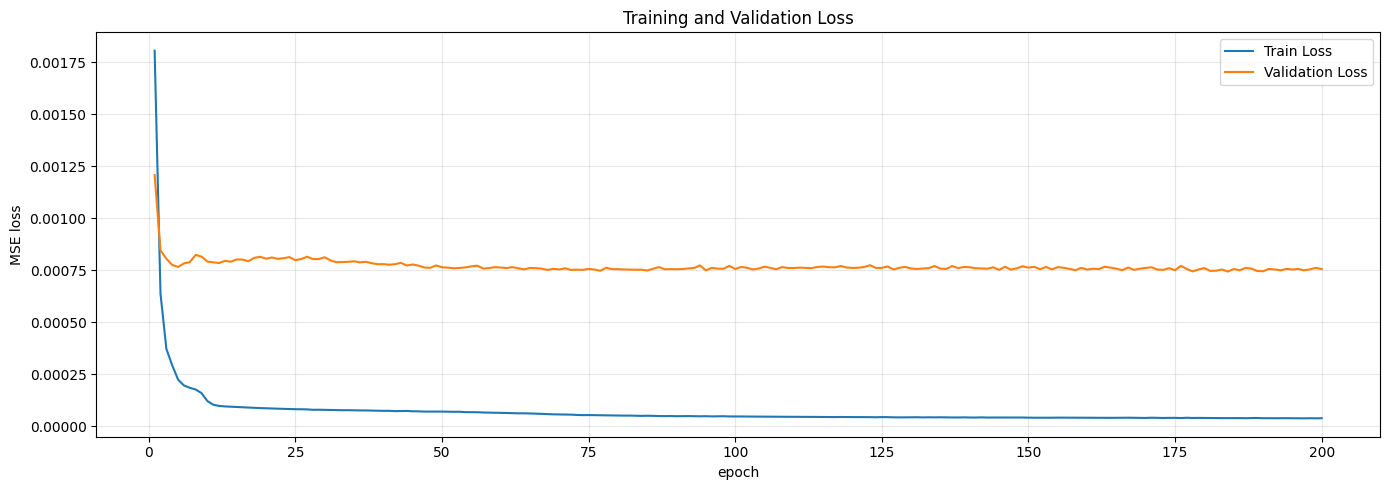

In [113]:
# Transformer Model - Training / Validation Loss

plt.figure(figsize=(14, 5))

epochs = np.arange(1, len(train_loss_history) + 1)

plt.plot(epochs, train_loss_history, label="Train Loss")
plt.plot(epochs, val_loss_history, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Motion Embedding Evolution

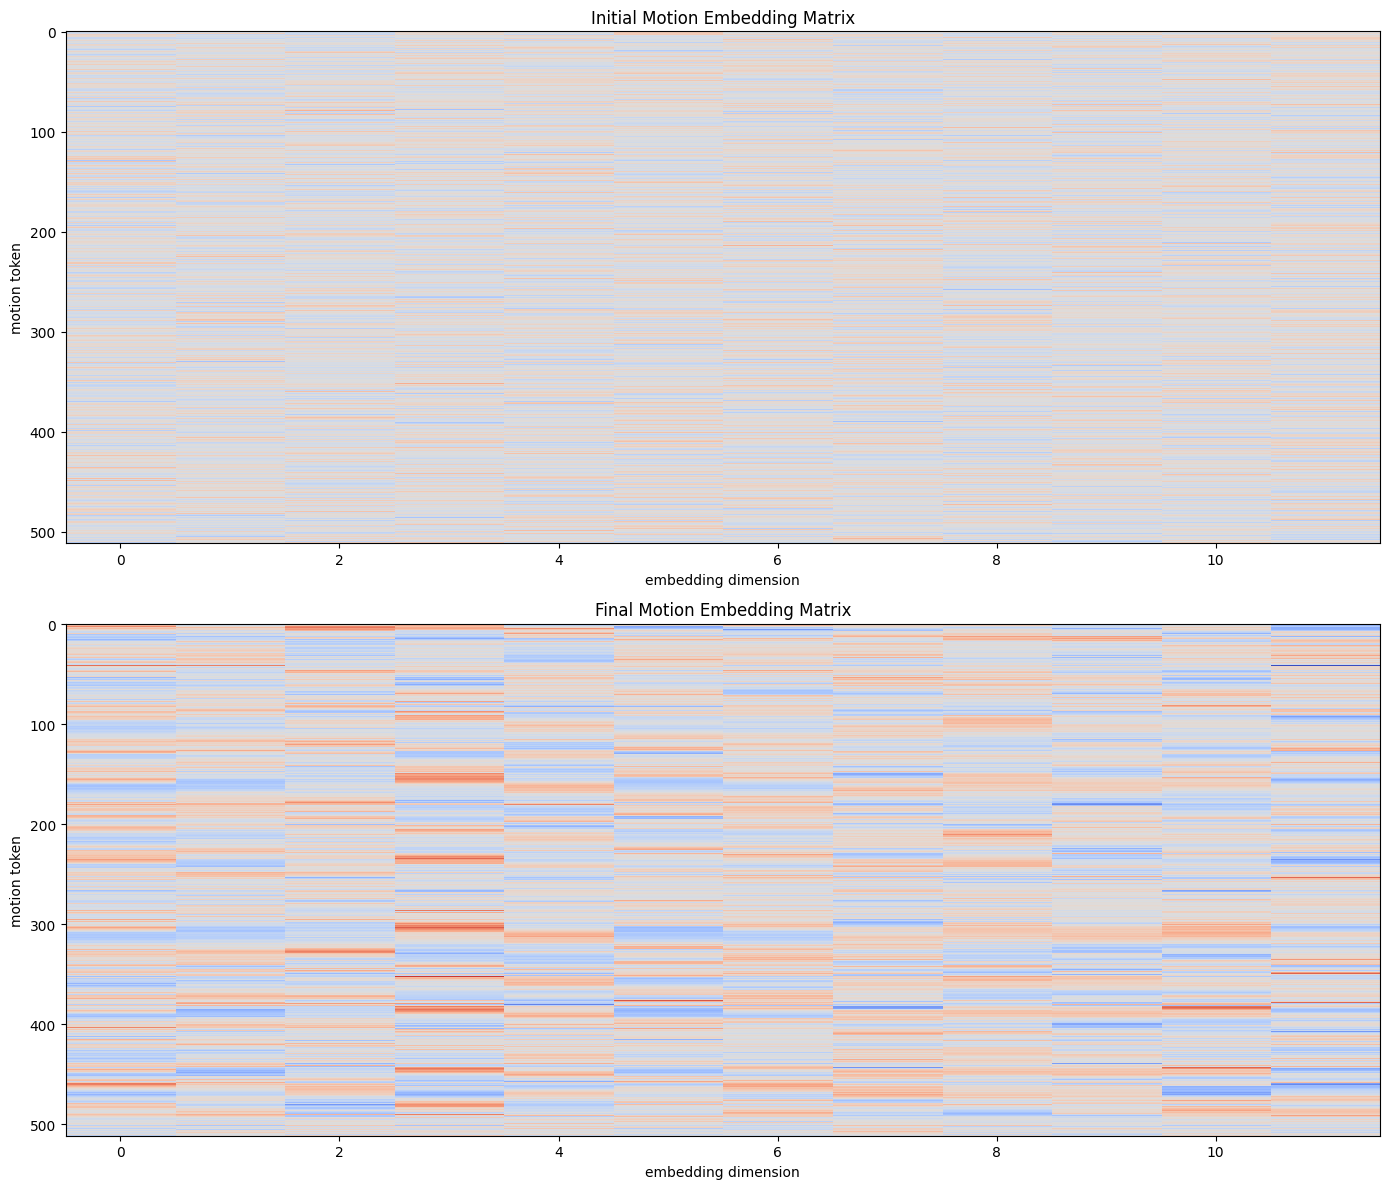

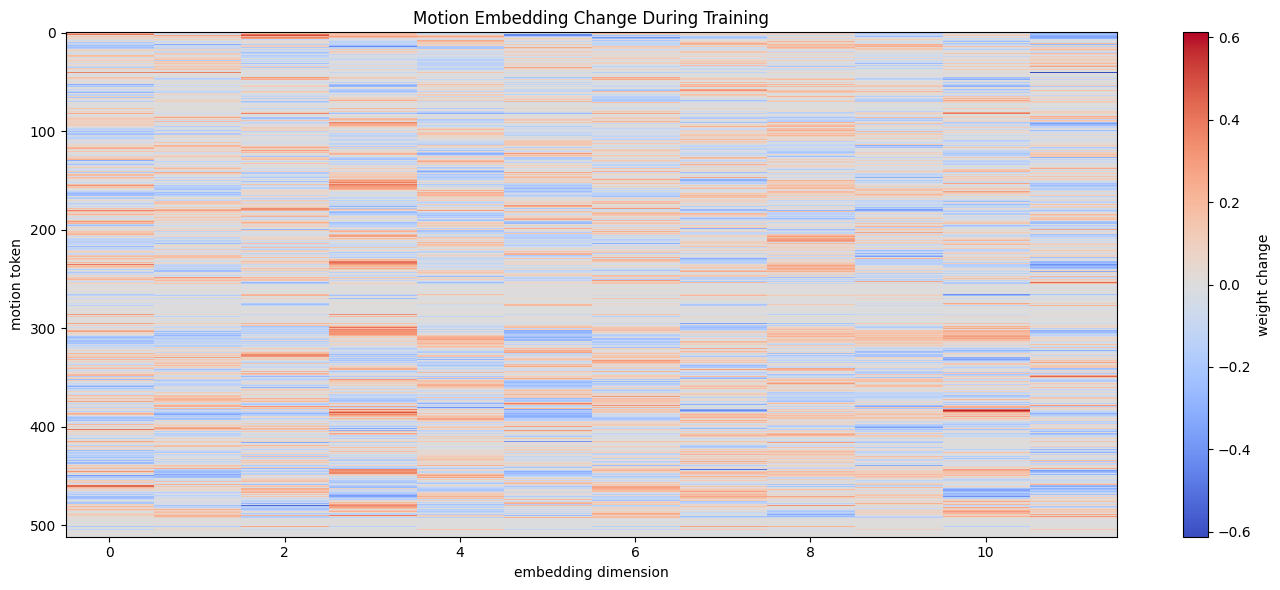

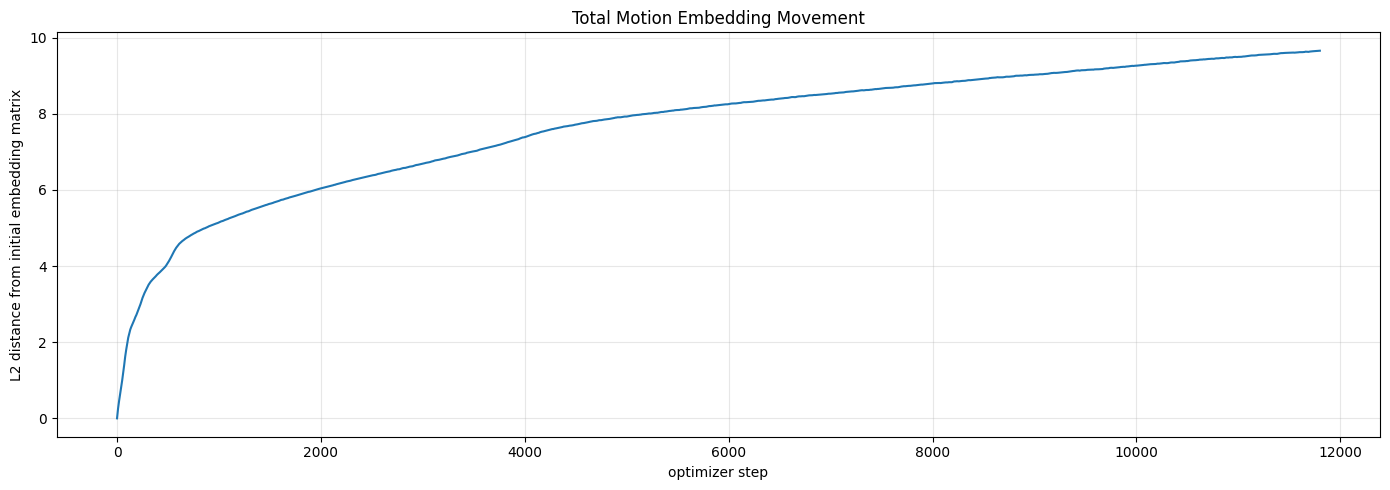

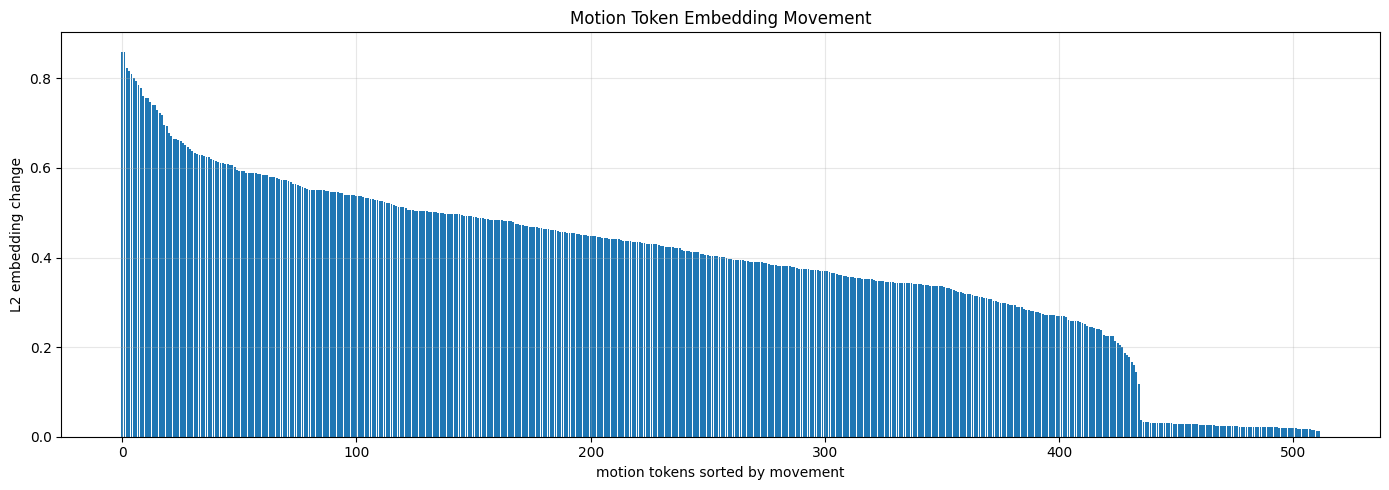

Most changed motion token IDs:
[ 41   3  82 180 480 382   2 470 383 445 460 386 384 443 303 387 235   5
   4 444]

Their embedding changes:
[0.8599101  0.85931295 0.82330245 0.81638443 0.80936366 0.8003072
 0.7952809  0.78610414 0.77867544 0.7611878  0.75658476 0.75541854
 0.74663454 0.7413023  0.74089164 0.7299479  0.72185445 0.7176996
 0.6970668  0.6936641 ]


In [114]:
# Transformer Model - 14. Embedding Evolution Plots

# ---------------------------------------------------------
# 1. Initial vs final embedding matrix
# ---------------------------------------------------------

initial_embedding = embedding_snapshots[0]["embedding_matrix"]
final_embedding = embedding_snapshots[-1]["embedding_matrix"]

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

vmax = max(np.abs(initial_embedding).max(), np.abs(final_embedding).max())

axes[0].imshow(initial_embedding, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-vmax, vmax=vmax)
axes[0].set_title("Initial Motion Embedding Matrix")
axes[0].set_xlabel("embedding dimension")
axes[0].set_ylabel("motion token")

axes[1].imshow(final_embedding, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-vmax, vmax=vmax)
axes[1].set_title("Final Motion Embedding Matrix")
axes[1].set_xlabel("embedding dimension")
axes[1].set_ylabel("motion token")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Embedding change matrix
# ---------------------------------------------------------

embedding_delta = final_embedding - initial_embedding
delta_max = np.abs(embedding_delta).max()

plt.figure(figsize=(14, 6))

plt.imshow(embedding_delta, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-delta_max, vmax=delta_max)

plt.title("Motion Embedding Change During Training")
plt.xlabel("embedding dimension")
plt.ylabel("motion token")

plt.colorbar(label="weight change")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Total embedding movement over training
# ---------------------------------------------------------

steps = []
embedding_movement = []

for snapshot in embedding_snapshots:
    current_embedding = snapshot["embedding_matrix"]

    movement = np.linalg.norm(
        current_embedding - initial_embedding
    )

    steps.append(snapshot["step"])
    embedding_movement.append(movement)

plt.figure(figsize=(14, 5))

plt.plot(steps, embedding_movement)

plt.title("Total Motion Embedding Movement")
plt.xlabel("optimizer step")
plt.ylabel("L2 distance from initial embedding matrix")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Mean movement per motion token
# ---------------------------------------------------------

token_movement = np.linalg.norm(
    final_embedding - initial_embedding,
    axis=1
)

sorted_token_ids = np.argsort(-token_movement)

plt.figure(figsize=(14, 5))

plt.bar(
    np.arange(len(token_movement)),
    token_movement[sorted_token_ids]
)

plt.title("Motion Token Embedding Movement")
plt.xlabel("motion tokens sorted by movement")
plt.ylabel("L2 embedding change")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("Most changed motion token IDs:")
print(sorted_token_ids[:20])

print()

print("Their embedding changes:")
print(token_movement[sorted_token_ids[:20]])

## Prediction vs True Motion Review

Several training sequences are passed through the trained transformer and the predicted next motion representation is compared directly with the true `z_encoded` extracted from the following motion window. The error heatmap shows where the predicted motion differs from the actual motion observed in the video.

Test sequences: 118


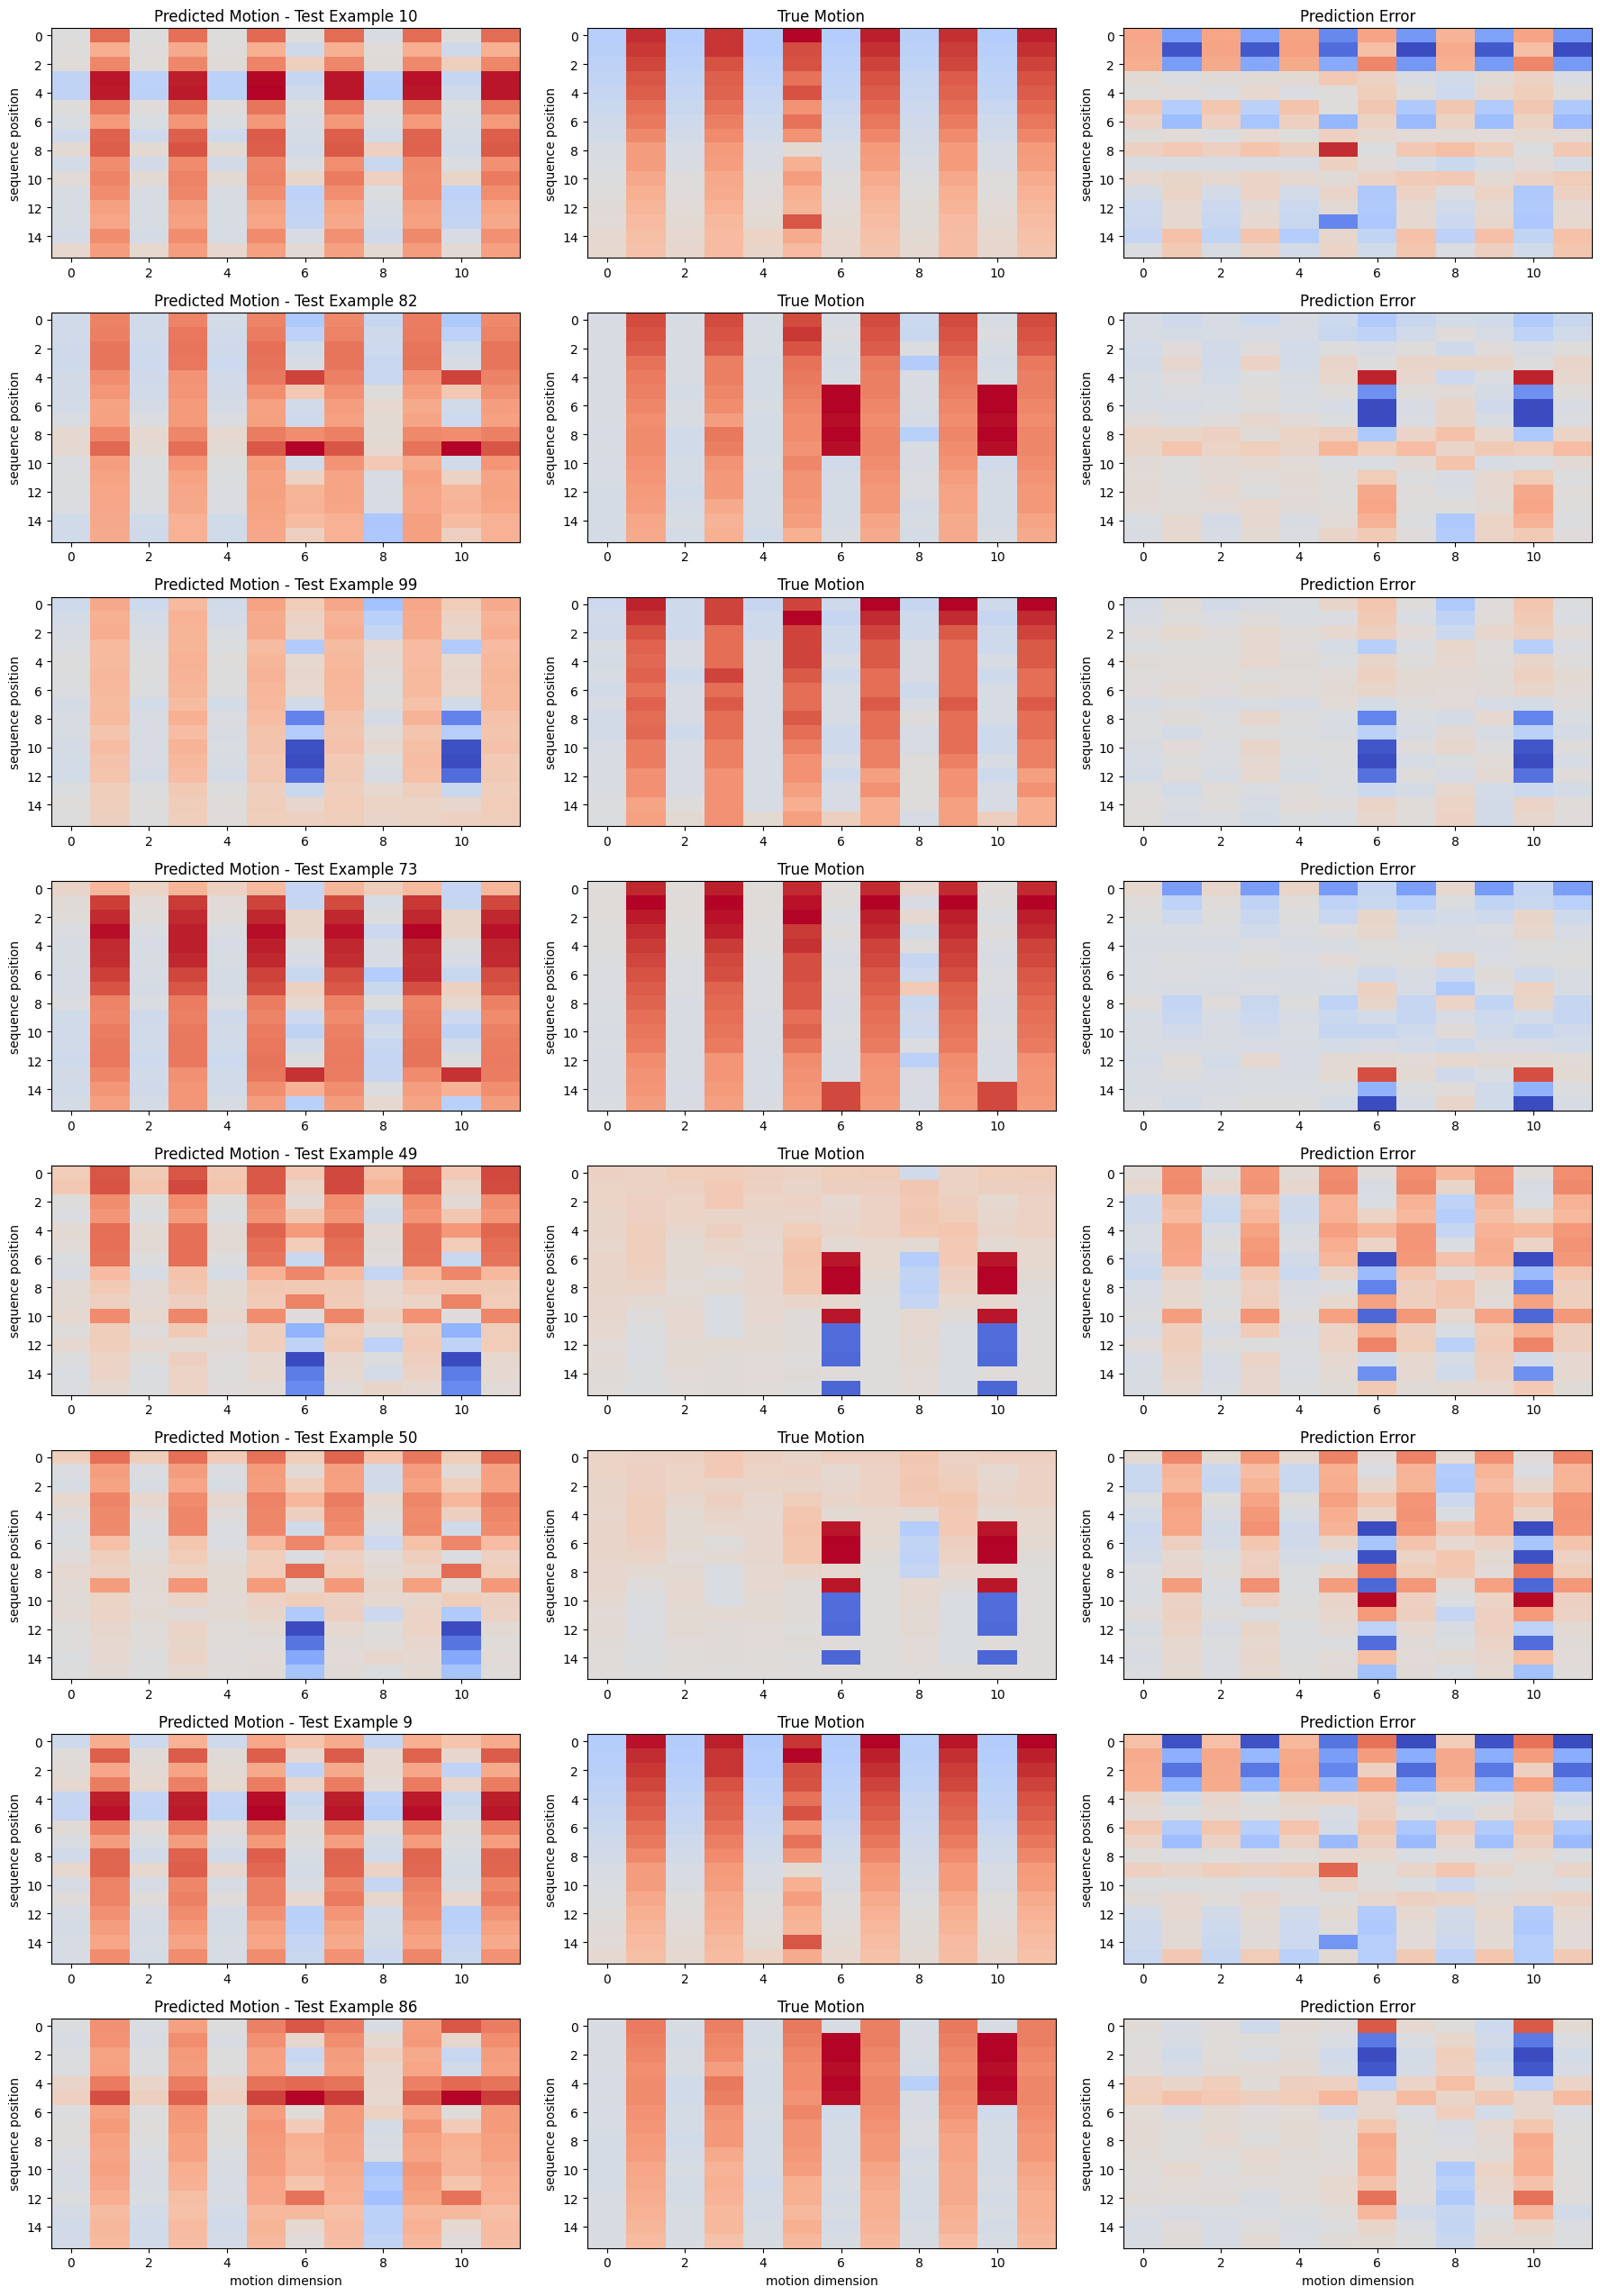

In [115]:
# Transformer Model - 16. Prediction vs True Motion Review - Test Set

N_REVIEW_EXAMPLES = 8
REVIEW_RANDOM_STATE = 42

# ---------------------------------------------------------
# Build test examples
# ---------------------------------------------------------

test_examples = []

for episode_id in sorted(test_episode_ids):
    episode_df = motion_token_df[motion_token_df["episode_id"] == episode_id].sort_values("frame").reset_index(drop=True)

    if len(episode_df) < seq_len + 1:
        continue

    for start_idx in range(len(episode_df) - seq_len):
        sequence_df = episode_df.iloc[start_idx:start_idx + seq_len + 1]

        X_seq = sequence_df["motion_token_id"].iloc[:-1].to_numpy()

        y_seq = []

        for row_idx in range(1, len(sequence_df)):
            row = sequence_df.iloc[row_idx]

            episode_id_row = int(row["episode_id"])
            prev_frame = int(row["prev_frame"])
            frame = int(row["frame"])
            track_id = int(row["track_id"])

            prev_frame_cp = lunar_cp_df_reduced[
                (lunar_cp_df_reduced["episode_id"] == episode_id_row)
                & (lunar_cp_df_reduced["frame"] == prev_frame)
                & (lunar_cp_df_reduced["track_id"] == track_id)
            ].sort_values("point_name")

            frame_cp = lunar_cp_df_reduced[
                (lunar_cp_df_reduced["episode_id"] == episode_id_row)
                & (lunar_cp_df_reduced["frame"] == frame)
                & (lunar_cp_df_reduced["track_id"] == track_id)
            ].sort_values("point_name")

            prev_frame_bckg = lunar_bckg_df_selected[
                (lunar_bckg_df_selected["episode_id"] == episode_id_row)
                & (lunar_bckg_df_selected["frame"] == prev_frame)
            ].sort_values("background_point_id")

            frame_bckg = lunar_bckg_df_selected[
                (lunar_bckg_df_selected["episode_id"] == episode_id_row)
                & (lunar_bckg_df_selected["frame"] == frame)
            ].sort_values("background_point_id")

            motion_key = build_motion_key(prev_frame_cp, frame_cp, prev_frame_bckg, frame_bckg)
            z_true_next = encode_motion_key(motion_key)

            y_seq.append(z_true_next)

        test_examples.append((X_seq, np.stack(y_seq)))

print(f"Test sequences: {len(test_examples)}")

# ---------------------------------------------------------
# Random test examples
# ---------------------------------------------------------

rng = np.random.default_rng(REVIEW_RANDOM_STATE)

review_indices = rng.choice(
    len(test_examples),
    size=min(N_REVIEW_EXAMPLES, len(test_examples)),
    replace=False
)

# ---------------------------------------------------------
# Prediction review
# ---------------------------------------------------------

model.eval()

fig, axes = plt.subplots(len(review_indices), 3, figsize=(18, 3.2 * len(review_indices)))

if len(review_indices) == 1:
    axes = axes.reshape(1, -1)

with torch.no_grad():
    for row_idx, example_idx in enumerate(review_indices):
        X_seq, y_seq = test_examples[example_idx]

        X_review = torch.tensor(X_seq, dtype=torch.long, device=device).unsqueeze(0)
        y_true = torch.tensor(y_seq, dtype=torch.float32, device=device).unsqueeze(0)

        y_pred = model(X_review)

        y_pred_np = y_pred[0].cpu().numpy()
        y_true_np = y_true[0].cpu().numpy()
        error_np = y_pred_np - y_true_np

        pred_max = max(float(np.abs(y_pred_np).max()), 1e-8)
        true_max = max(float(np.abs(y_true_np).max()), 1e-8)
        error_max = max(float(np.abs(error_np).max()), 1e-8)

        axes[row_idx, 0].imshow(y_pred_np, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-pred_max, vmax=pred_max)
        axes[row_idx, 0].set_title(f"Predicted Motion - Test Example {example_idx}")
        axes[row_idx, 0].set_ylabel("sequence position")

        axes[row_idx, 1].imshow(y_true_np, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-true_max, vmax=true_max)
        axes[row_idx, 1].set_title("True Motion")
        axes[row_idx, 1].set_ylabel("sequence position")

        axes[row_idx, 2].imshow(error_np, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-error_max, vmax=error_max)
        axes[row_idx, 2].set_title("Prediction Error")
        axes[row_idx, 2].set_ylabel("sequence position")

        if row_idx == len(review_indices) - 1:
            axes[row_idx, 0].set_xlabel("motion dimension")
            axes[row_idx, 1].set_xlabel("motion dimension")
            axes[row_idx, 2].set_xlabel("motion dimension")

plt.tight_layout()
plt.show()

# Prediction

## Embedding Prediction

Test episode: 8
Sequence length: 75
Prompt tokens: [256, 257, 258, 259, 260]

TRUE continuation tokens:
[260, 261, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 135, 136, 137, 274, 275, 140, 276, 277, 277, 278, 279, 280, 281, 282, 282, 283, 284, 285, 286, 287, 287, 288, 288, 288, 289, 289, 289, 290, 291, 291, 292, 292, 293, 293, 294, 82, 295, 295, 296, 297, 86, 86, 86, 38, 86, 38, 38, 38, 38, 38, 38, 38, 38, 38]

GENERATED continuation tokens:
[109, 244, 246, 246, 173, 114, 173, 173, 173, 398, 324, 177, 178, 179, 178, 250, 346, 456, 117, 404, 182, 177, 177, 401, 178, 372, 116, 371, 250, 248, 456, 117, 251, 456, 185, 185, 404, 347, 368, 185, 404, 189, 190, 125, 378, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36]

Autoregressive continuation MSE: 0.00182600


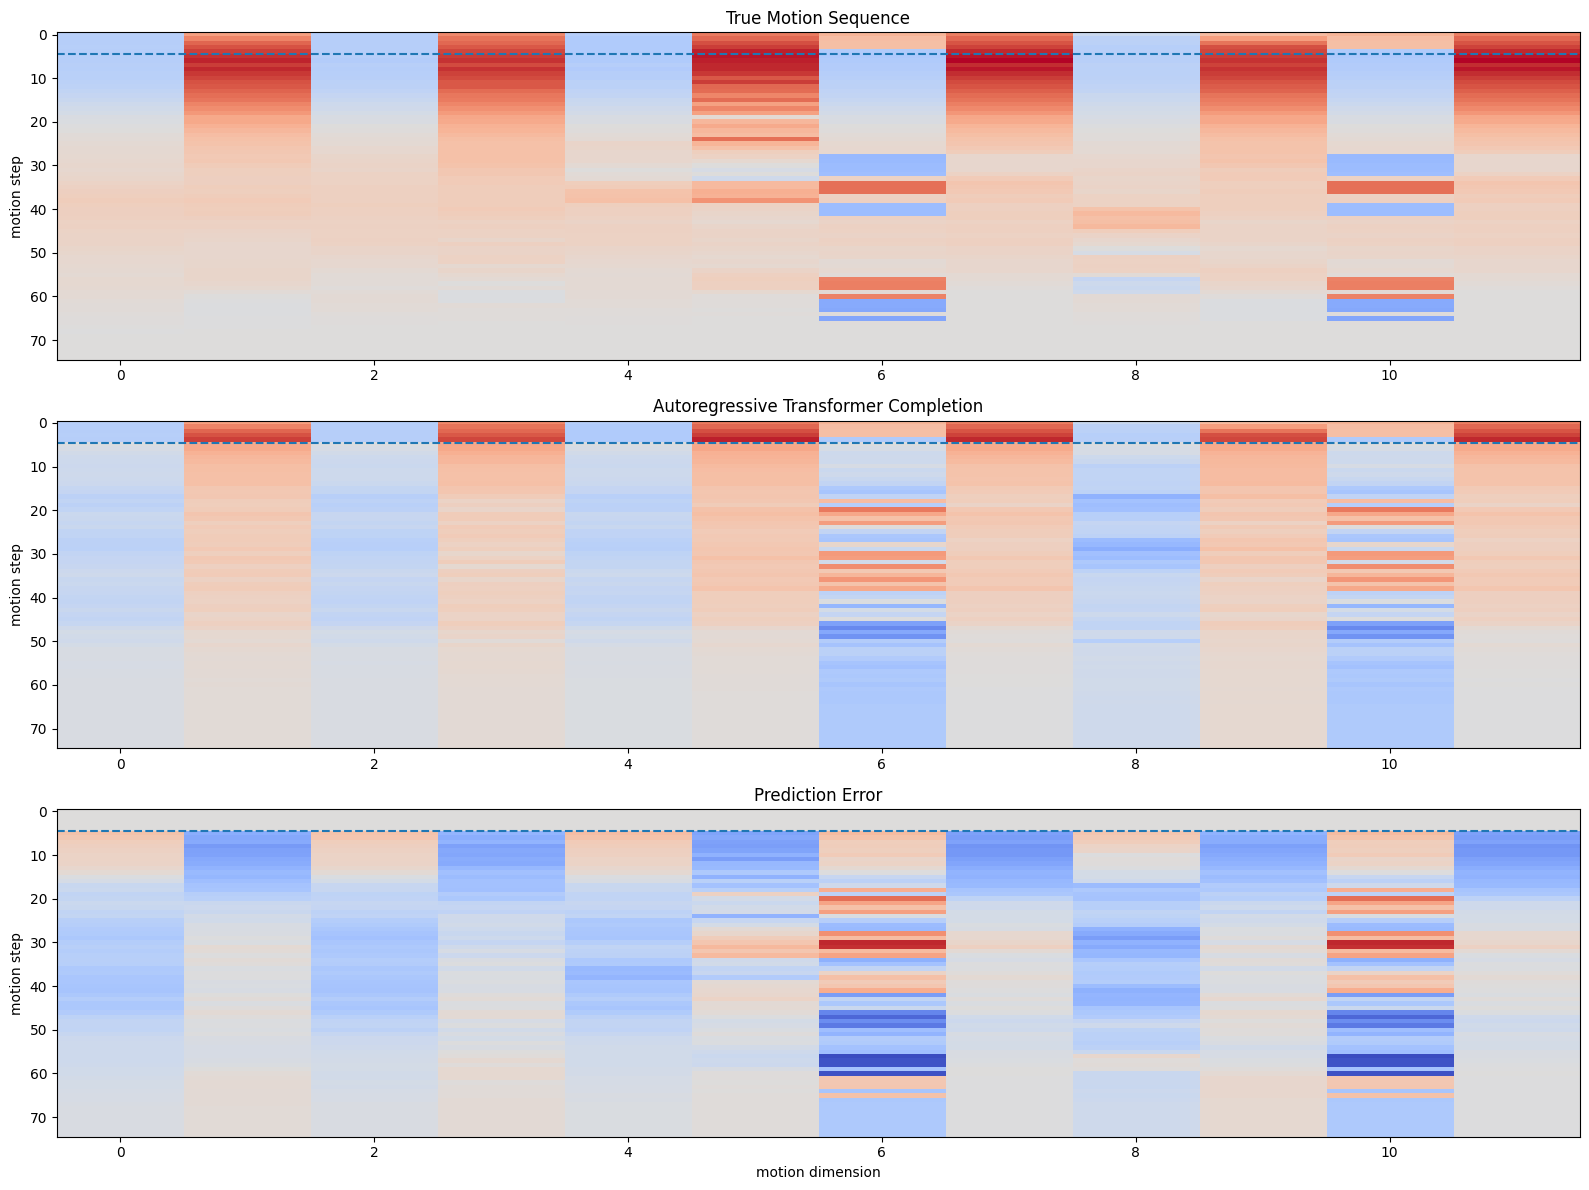

In [116]:
# Transformer Model - 17. Autoregressive Motion Completion

ROLLOUT_RANDOM_STATE = 42
PROMPT_TOKENS = 5

rng = np.random.default_rng(ROLLOUT_RANDOM_STATE)

# ---------------------------------------------------------
# Pick one completely unseen TEST episode
# ---------------------------------------------------------

test_episode_id = int(rng.choice(sorted(test_episode_ids)))

episode_df = motion_token_df[
    motion_token_df["episode_id"] == test_episode_id
].sort_values("frame").reset_index(drop=True)

true_token_ids = episode_df["motion_token_id"].to_numpy(dtype=np.int64)

if len(true_token_ids) <= PROMPT_TOKENS:
    raise ValueError("Episode is too short for selected PROMPT_TOKENS.")

print(f"Test episode: {test_episode_id}")
print(f"Sequence length: {len(true_token_ids)}")
print(f"Prompt tokens: {true_token_ids[:PROMPT_TOKENS].tolist()}")

# ---------------------------------------------------------
# TRUE continuous motion sequence
# ---------------------------------------------------------

true_z_sequence = []

for _, row in episode_df.iterrows():
    episode_id_row = int(row["episode_id"])
    prev_frame = int(row["prev_frame"])
    frame = int(row["frame"])
    track_id = int(row["track_id"])

    prev_frame_cp = lunar_cp_df_reduced[
        (lunar_cp_df_reduced["episode_id"] == episode_id_row)
        & (lunar_cp_df_reduced["frame"] == prev_frame)
        & (lunar_cp_df_reduced["track_id"] == track_id)
    ].sort_values("point_name")

    frame_cp = lunar_cp_df_reduced[
        (lunar_cp_df_reduced["episode_id"] == episode_id_row)
        & (lunar_cp_df_reduced["frame"] == frame)
        & (lunar_cp_df_reduced["track_id"] == track_id)
    ].sort_values("point_name")

    prev_frame_bckg = lunar_bckg_df_selected[
        (lunar_bckg_df_selected["episode_id"] == episode_id_row)
        & (lunar_bckg_df_selected["frame"] == prev_frame)
    ].sort_values("background_point_id")

    frame_bckg = lunar_bckg_df_selected[
        (lunar_bckg_df_selected["episode_id"] == episode_id_row)
        & (lunar_bckg_df_selected["frame"] == frame)
    ].sort_values("background_point_id")

    motion_key = build_motion_key(prev_frame_cp, frame_cp, prev_frame_bckg, frame_bckg)
    z_true = encode_motion_key(motion_key)

    true_z_sequence.append(z_true)

true_z_sequence = np.stack(true_z_sequence)

# ---------------------------------------------------------
# Autoregressive generation
# ---------------------------------------------------------

generated_token_ids = true_token_ids[:PROMPT_TOKENS].tolist()

generated_z_sequence = [
    true_z_sequence[i].copy()
    for i in range(PROMPT_TOKENS)
]

model.eval()

with torch.no_grad():
    for step_idx in range(PROMPT_TOKENS, len(true_token_ids)):
        context_token_ids = generated_token_ids[-seq_len:]

        X = torch.tensor(context_token_ids, dtype=torch.long, device=device).unsqueeze(0)

        z_pred = model(X)[0, -1].cpu().numpy()

        distances = np.linalg.norm(action_embedding_table - z_pred.reshape(1, -1), axis=1)
        next_token_id = int(np.argmin(distances))

        generated_z_sequence.append(z_pred.copy())
        generated_token_ids.append(next_token_id)

generated_z_sequence = np.stack(generated_z_sequence)
generated_token_ids = np.asarray(generated_token_ids, dtype=np.int64)

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

continuation_true = true_z_sequence[PROMPT_TOKENS:]
continuation_pred = generated_z_sequence[PROMPT_TOKENS:]

rollout_mse = np.mean((continuation_pred - continuation_true) ** 2)

print()
print("TRUE continuation tokens:")
print(true_token_ids[PROMPT_TOKENS:].tolist())

print()
print("GENERATED continuation tokens:")
print(generated_token_ids[PROMPT_TOKENS:].tolist())

print()
print(f"Autoregressive continuation MSE: {rollout_mse:.8f}")

# ---------------------------------------------------------
# Visualize complete motion continuation
# ---------------------------------------------------------

shared_max = max(
    float(np.abs(true_z_sequence).max()),
    float(np.abs(generated_z_sequence).max()),
    1e-8
)

error = generated_z_sequence - true_z_sequence
error_max = max(float(np.abs(error).max()), 1e-8)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].imshow(true_z_sequence, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-shared_max, vmax=shared_max)
axes[0].axhline(PROMPT_TOKENS - 0.5, linestyle="--")
axes[0].set_title("True Motion Sequence")
axes[0].set_ylabel("motion step")

axes[1].imshow(generated_z_sequence, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-shared_max, vmax=shared_max)
axes[1].axhline(PROMPT_TOKENS - 0.5, linestyle="--")
axes[1].set_title("Autoregressive Transformer Completion")
axes[1].set_ylabel("motion step")

axes[2].imshow(error, aspect="auto", cmap="coolwarm", interpolation="nearest", vmin=-error_max, vmax=error_max)
axes[2].axhline(PROMPT_TOKENS - 0.5, linestyle="--")
axes[2].set_title("Prediction Error")
axes[2].set_xlabel("motion dimension")
axes[2].set_ylabel("motion step")

plt.tight_layout()
plt.show()

## Autoregressive Prediction

Test episode: 8
Motion steps: 75
History tokens given to model: 5


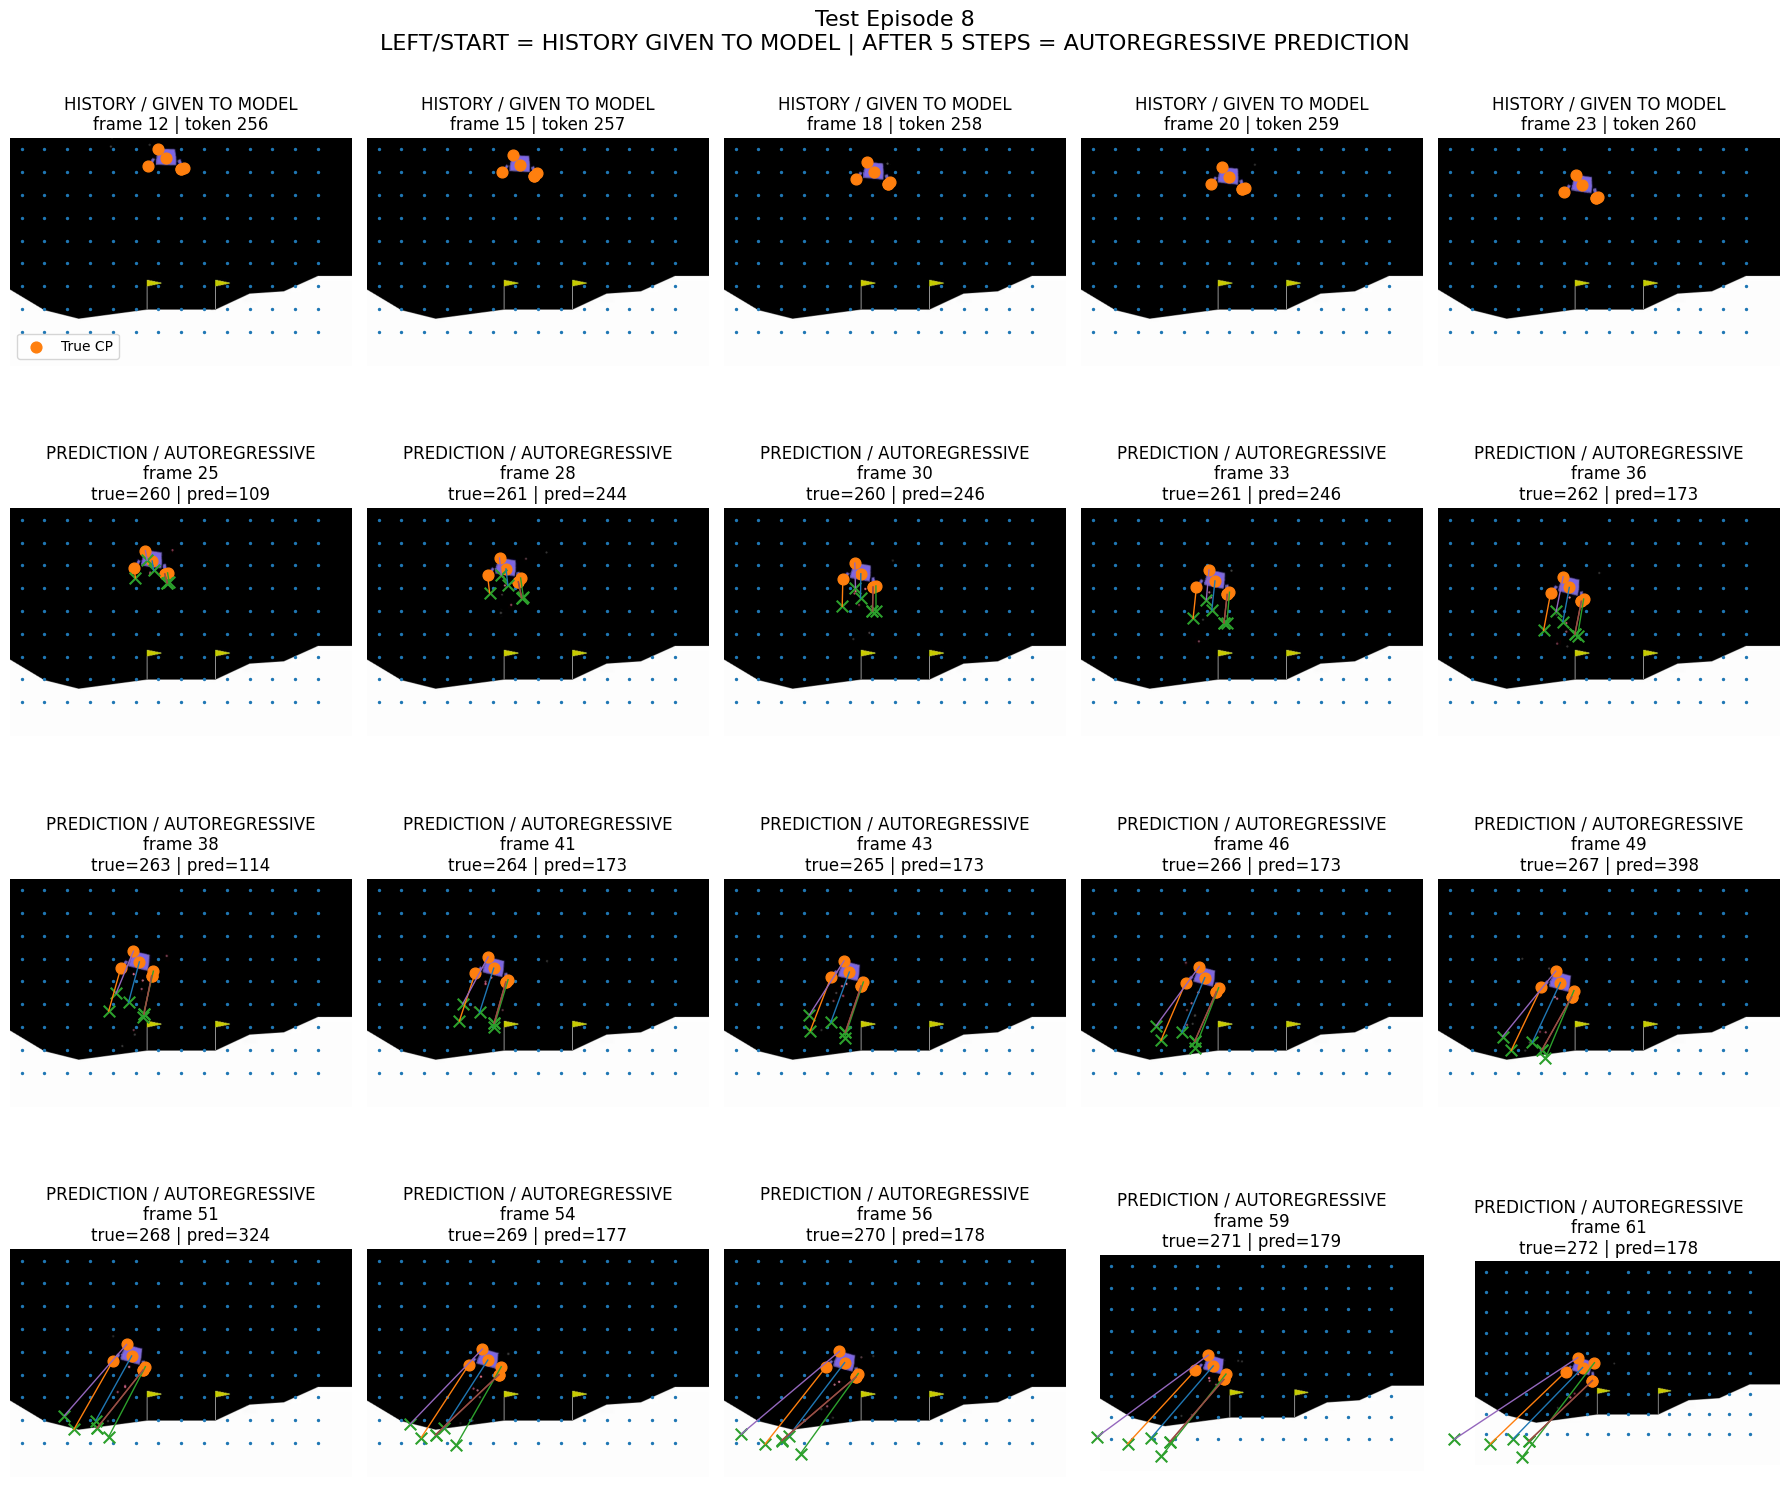

In [117]:
# Transformer Model - 17. History vs Autoregressive Prediction on Real Frames

TEST_EPISODE_ID = sorted(test_episode_ids)[0]
PROMPT_TOKENS = 5
N_PREDICT_FRAMES = 15

# ---------------------------------------------------------
# Episode
# ---------------------------------------------------------

episode_df = motion_token_df[
    motion_token_df["episode_id"] == TEST_EPISODE_ID
].sort_values("frame").reset_index(drop=True)

if len(episode_df) <= PROMPT_TOKENS:
    raise ValueError("Episode too short.")

track_id = int(episode_df.iloc[0]["track_id"])

print("Test episode:", TEST_EPISODE_ID)
print("Motion steps:", len(episode_df))
print("History tokens given to model:", PROMPT_TOKENS)

# ---------------------------------------------------------
# Load video
# ---------------------------------------------------------

video_path = lunar_video_paths[TEST_EPISODE_ID]
video_frames = read_video(video_path, max_frames=None, stride=1)

# ---------------------------------------------------------
# TRUE token sequence
# ---------------------------------------------------------

true_token_ids = episode_df["motion_token_id"].to_numpy(dtype=np.int64)

generated_token_ids = true_token_ids[:PROMPT_TOKENS].tolist()

# ---------------------------------------------------------
# HISTORY records
# ---------------------------------------------------------

history_records = []

for step_idx in range(PROMPT_TOKENS):
    row = episode_df.iloc[step_idx]

    frame = int(row["frame"])

    cp_df = lunar_cp_df_reduced[
        (lunar_cp_df_reduced["episode_id"] == TEST_EPISODE_ID)
        & (lunar_cp_df_reduced["frame"] == frame)
        & (lunar_cp_df_reduced["track_id"] == track_id)
    ].sort_values("point_name")

    bckg_df = lunar_bckg_df_selected[
        (lunar_bckg_df_selected["episode_id"] == TEST_EPISODE_ID)
        & (lunar_bckg_df_selected["frame"] == frame)
    ].sort_values("background_point_id")

    history_records.append({
        "frame": frame,
        "true_cp": cp_df[["x", "y"]].to_numpy(dtype=np.float32),
        "background": bckg_df[["x", "y"]].to_numpy(dtype=np.float32),
        "true_token_id": int(row["motion_token_id"]),
    })

# ---------------------------------------------------------
# Start prediction from last TRUE history state
# ---------------------------------------------------------

last_history_row = episode_df.iloc[PROMPT_TOKENS - 1]
last_history_frame = int(last_history_row["frame"])

last_cp_df = lunar_cp_df_reduced[
    (lunar_cp_df_reduced["episode_id"] == TEST_EPISODE_ID)
    & (lunar_cp_df_reduced["frame"] == last_history_frame)
    & (lunar_cp_df_reduced["track_id"] == track_id)
].sort_values("point_name")

predicted_cp = last_cp_df[["x", "y"]].to_numpy(dtype=np.float32)

predicted_cp[:, 0] /= max(FRAME_WIDTH - 1, 1)
predicted_cp[:, 1] /= max(FRAME_HEIGHT - 1, 1)

# ---------------------------------------------------------
# AUTOREGRESSIVE prediction
# ---------------------------------------------------------

prediction_records = []

model.eval()

with torch.no_grad():
    end_step = min(PROMPT_TOKENS + N_PREDICT_FRAMES, len(episode_df))

    for step_idx in range(PROMPT_TOKENS, end_step):
        row = episode_df.iloc[step_idx]

        prev_frame = int(row["prev_frame"])
        frame = int(row["frame"])

        context_ids = generated_token_ids[-seq_len:]

        X = torch.tensor(context_ids, dtype=torch.long, device=device).unsqueeze(0)

        z_pred = model(X)[0, -1].cpu().numpy()

        distances = np.linalg.norm(action_embedding_table - z_pred.reshape(1, -1), axis=1)
        predicted_token_id = int(np.argmin(distances))

        generated_token_ids.append(predicted_token_id)

        prev_bckg = lunar_bckg_df_selected[
            (lunar_bckg_df_selected["episode_id"] == TEST_EPISODE_ID)
            & (lunar_bckg_df_selected["frame"] == prev_frame)
        ].sort_values("background_point_id")

        frame_bckg = lunar_bckg_df_selected[
            (lunar_bckg_df_selected["episode_id"] == TEST_EPISODE_ID)
            & (lunar_bckg_df_selected["frame"] == frame)
        ].sort_values("background_point_id")

        common_ids = sorted(
            set(prev_bckg["background_point_id"])
            & set(frame_bckg["background_point_id"])
        )

        prev_common = prev_bckg[
            prev_bckg["background_point_id"].isin(common_ids)
        ].sort_values("background_point_id")

        frame_common = frame_bckg[
            frame_bckg["background_point_id"].isin(common_ids)
        ].sort_values("background_point_id")

        prev_background_xy = prev_common[["x", "y"]].to_numpy(dtype=np.float32)
        frame_background_xy = frame_common[["x", "y"]].to_numpy(dtype=np.float32)

        prev_background_xy[:, 0] /= max(FRAME_WIDTH - 1, 1)
        prev_background_xy[:, 1] /= max(FRAME_HEIGHT - 1, 1)

        frame_background_xy[:, 0] /= max(FRAME_WIDTH - 1, 1)
        frame_background_xy[:, 1] /= max(FRAME_HEIGHT - 1, 1)

        background_delta = frame_background_xy - prev_background_xy
        median_background_delta = np.median(background_delta, axis=0)

        z_pred_cp = z_pred.reshape(-1, 2)

        predicted_delta_cp = z_pred_cp + median_background_delta.reshape(1, 2)
        predicted_cp = predicted_cp + predicted_delta_cp

        predicted_cp_pixels = predicted_cp.copy()
        predicted_cp_pixels[:, 0] *= max(FRAME_WIDTH - 1, 1)
        predicted_cp_pixels[:, 1] *= max(FRAME_HEIGHT - 1, 1)

        true_cp_df = lunar_cp_df_reduced[
            (lunar_cp_df_reduced["episode_id"] == TEST_EPISODE_ID)
            & (lunar_cp_df_reduced["frame"] == frame)
            & (lunar_cp_df_reduced["track_id"] == track_id)
        ].sort_values("point_name")

        prediction_records.append({
            "frame": frame,
            "true_cp": true_cp_df[["x", "y"]].to_numpy(dtype=np.float32),
            "predicted_cp": predicted_cp_pixels.copy(),
            "background": frame_bckg[["x", "y"]].to_numpy(dtype=np.float32),
            "true_token_id": int(row["motion_token_id"]),
            "predicted_token_id": predicted_token_id,
        })

# ---------------------------------------------------------
# Combine HISTORY + PREDICTION
# ---------------------------------------------------------

all_records = []

for record in history_records:
    all_records.append(("HISTORY", record))

for record in prediction_records:
    all_records.append(("PREDICTION", record))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

n_cols = 5
n_rows = int(np.ceil(len(all_records) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.asarray(axes).reshape(-1)

for plot_idx, (mode, record) in enumerate(all_records):
    ax = axes[plot_idx]

    frame_idx = record["frame"]

    ax.imshow(video_frames[frame_idx])

    background_xy = record["background"]

    ax.scatter(
        background_xy[:, 0],
        background_xy[:, 1],
        s=8,
        marker="."
    )

    true_cp = record["true_cp"]

    ax.scatter(
        true_cp[:, 0],
        true_cp[:, 1],
        s=60,
        marker="o",
        label="True CP"
    )

    if mode == "HISTORY":
        ax.set_title(
            f"HISTORY / GIVEN TO MODEL\n"
            f"frame {frame_idx} | token {record['true_token_id']}"
        )

    else:
        predicted_cp = record["predicted_cp"]

        ax.scatter(
            predicted_cp[:, 0],
            predicted_cp[:, 1],
            s=70,
            marker="x",
            label="Predicted CP"
        )

        for point_idx in range(len(true_cp)):
            ax.plot(
                [true_cp[point_idx, 0], predicted_cp[point_idx, 0]],
                [true_cp[point_idx, 1], predicted_cp[point_idx, 1]],
                linewidth=1
            )

        ax.set_title(
            f"PREDICTION / AUTOREGRESSIVE\n"
            f"frame {frame_idx}\n"
            f"true={record['true_token_id']} | pred={record['predicted_token_id']}"
        )

    ax.axis("off")

    if plot_idx == 0:
        ax.legend()

for ax in axes[len(all_records):]:
    ax.axis("off")

plt.suptitle(
    f"Test Episode {TEST_EPISODE_ID}\n"
    f"LEFT/START = HISTORY GIVEN TO MODEL | AFTER {PROMPT_TOKENS} STEPS = AUTOREGRESSIVE PREDICTION",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Primitive-Agent Dataset

- We want action inference from video without real action labels.
- Pretraining already gives us a motion space:
  video transition -> CP/BG relation change -> z_motion.
- But z_motion is not an action yet. It only says “what movement happened”.
- To map motion to action, we create a supervised bridge:
  z_motion -> [main_engine, side_engine].
- Since real videos do not give action labels, we generate labels ourselves using motion primitives.
- A primitive is a simple known movement, like:
  UP, LEFT, RIGHT, UP_RIGHT, circle, etc.
- For each primitive, we know the intended action label because we define it:
  UP -> main engine, LEFT/RIGHT -> side engine.
- We render the primitive as a synthetic lander CP template, not as a single point, because the pretrained embedding expects lander control points.
- We do not make fake background points, because that would shift the embedding distribution.
- Instead, we reuse real background points from pretraining videos.
- So each training example is:
real background anchors
+ synthetic lander CP movement
-> z_primitive
-> known primitive action label
- This gives us a fake labeled dataset that still lives in the same CP/BG embedding space as real videos.
- Then we train an MLP:
input:  z_primitive
output: action [main_engine, side_engine]
loss:   MSE
- At inference time:
new video -> z_motion -> MLP -> inferred action
- If using the transformer:
past z tokens -> transformer -> z_next_pred -> MLP -> predicted next action
- Core idea: motion primitives provide action labels; real background anchors keep the generated embeddings compatible with real video embeddings.

## Infer Prim_Agent Shape from Env_CP

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_40938/1724832686.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp_with_centroid


,point_name,offset_x,offset_y,offset_x_std,offset_y_std,n
0,centroid,0.000000,0.000000,0.000000,0.000000,39693
1,axis_front,-29.097770,13.562833,3.664547,4.186676,39693
2,axis_back,29.041146,14.052113,3.635708,4.512500,39693
3,axis_left,-7.816184,20.104037,23.586083,4.015350,39693
4,axis_right,-7.520389,-16.682651,9.861050,3.603221,39693
5,contact_low,-7.816184,20.104037,23.586083,4.015350,39693


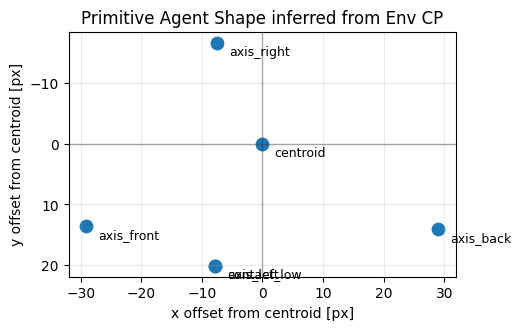

{'centroid': array([0., 0.], dtype=float32),
 'axis_front': array([-29.09777 ,  13.562833], dtype=float32),
 'axis_back': array([29.041145, 14.052114], dtype=float32),
 'axis_left': array([-7.816184, 20.104036], dtype=float32),
 'axis_right': array([ -7.5203886, -16.682652 ], dtype=float32),
 'contact_low': array([-7.816184, 20.104036], dtype=float32)}

In [122]:
# Infer Prim_Agent Shape from Env_CP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REQUIRED_CP_NAMES = [
    "centroid",
    "axis_front",
    "axis_back",
    "axis_left",
    "axis_right",
    "contact_low",
]

cp_df = lunar_cp_df_reduced.copy()

cp_df = cp_df[
    cp_df["point_name"].isin(REQUIRED_CP_NAMES)
].copy()

centroids = (
    cp_df[cp_df["point_name"] == "centroid"]
    [["episode_id", "track_id", "frame", "x", "y"]]
    .rename(columns={"x": "centroid_x", "y": "centroid_y"})
)

cp_with_centroid = cp_df.merge(
    centroids,
    on=["episode_id", "track_id", "frame"],
    how="inner",
)

cp_with_centroid["offset_x"] = (
    cp_with_centroid["x"] - cp_with_centroid["centroid_x"]
)

cp_with_centroid["offset_y"] = (
    cp_with_centroid["y"] - cp_with_centroid["centroid_y"]
)

prim_agent_shape_df = (
    cp_with_centroid
    .groupby("point_name", as_index=False)
    .agg(
        offset_x=("offset_x", "mean"),
        offset_y=("offset_y", "mean"),
        offset_x_std=("offset_x", "std"),
        offset_y_std=("offset_y", "std"),
        n=("offset_x", "size"),
    )
)

prim_agent_shape_df["point_name"] = pd.Categorical(
    prim_agent_shape_df["point_name"],
    categories=REQUIRED_CP_NAMES,
    ordered=True,
)

prim_agent_shape_df = (
    prim_agent_shape_df
    .sort_values("point_name")
    .reset_index(drop=True)
)

display(prim_agent_shape_df)

prim_agent_shape = {
    row["point_name"]: np.array(
        [row["offset_x"], row["offset_y"]],
        dtype=np.float32,
    )
    for _, row in prim_agent_shape_df.iterrows()
}

# sanity plot

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    prim_agent_shape_df["offset_x"],
    prim_agent_shape_df["offset_y"],
    s=80,
)

for _, row in prim_agent_shape_df.iterrows():
    ax.text(
        row["offset_x"] + 2,
        row["offset_y"] + 2,
        row["point_name"],
        fontsize=9,
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.3)
ax.axvline(0, color="black", linewidth=1, alpha=0.3)
ax.set_title("Primitive Agent Shape inferred from Env CP")
ax.set_xlabel("x offset from centroid [px]")
ax.set_ylabel("y offset from centroid [px]")
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.invert_yaxis()

plt.show()

prim_agent_shape

## Axis-Aligned Motion Primitives

primitives: 459
cp rows: 165240
action rows: 27540


,point_name,x,y,track_id,step,primitive_name,semantic_family
0,centroid,180.000000,89.340000,0,0,free_fall_x0.30_y0.22_s0.95,fall
1,axis_front,152.357119,102.224691,0,0,free_fall_x0.30_y0.22_s0.95,fall
2,axis_back,207.589088,102.689507,0,0,free_fall_x0.30_y0.22_s0.95,fall
3,axis_left,172.574625,108.438835,0,0,free_fall_x0.30_y0.22_s0.95,fall
4,axis_right,172.855631,73.491482,0,0,free_fall_x0.30_y0.22_s0.95,fall
5,contact_low,172.574625,108.438835,0,0,free_fall_x0.30_y0.22_s0.95,fall
6,centroid,180.000000,90.900000,0,1,free_fall_x0.30_y0.22_s0.95,fall
7,axis_front,152.357119,103.784691,0,1,free_fall_x0.30_y0.22_s0.95,fall
8,axis_back,207.589088,104.249507,0,1,free_fall_x0.30_y0.22_s0.95,fall
9,axis_left,172.574625,109.998835,0,1,free_fall_x0.30_y0.22_s0.95,fall


,primitive_name,semantic_family,step,action_main,action_side,action
0,free_fall_x0.30_y0.22_s0.95,fall,0,-1.0,0.0,"[-1.0, 0.0]"
1,free_fall_x0.30_y0.22_s0.95,fall,1,-1.0,0.0,"[-1.0, 0.0]"
2,free_fall_x0.30_y0.22_s0.95,fall,2,-1.0,0.0,"[-1.0, 0.0]"
3,free_fall_x0.30_y0.22_s0.95,fall,3,-1.0,0.0,"[-1.0, 0.0]"
4,free_fall_x0.30_y0.22_s0.95,fall,4,-1.0,0.0,"[-1.0, 0.0]"
5,free_fall_x0.30_y0.22_s0.95,fall,5,-1.0,0.0,"[-1.0, 0.0]"
6,free_fall_x0.30_y0.22_s0.95,fall,6,-1.0,0.0,"[-1.0, 0.0]"
7,free_fall_x0.30_y0.22_s0.95,fall,7,-1.0,0.0,"[-1.0, 0.0]"
8,free_fall_x0.30_y0.22_s0.95,fall,8,-1.0,0.0,"[-1.0, 0.0]"
9,free_fall_x0.30_y0.22_s0.95,fall,9,-1.0,0.0,"[-1.0, 0.0]"


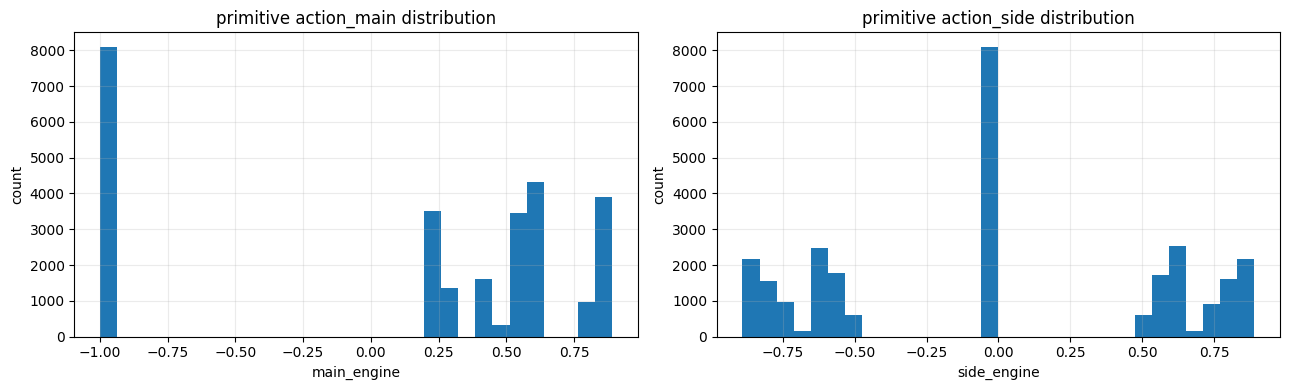

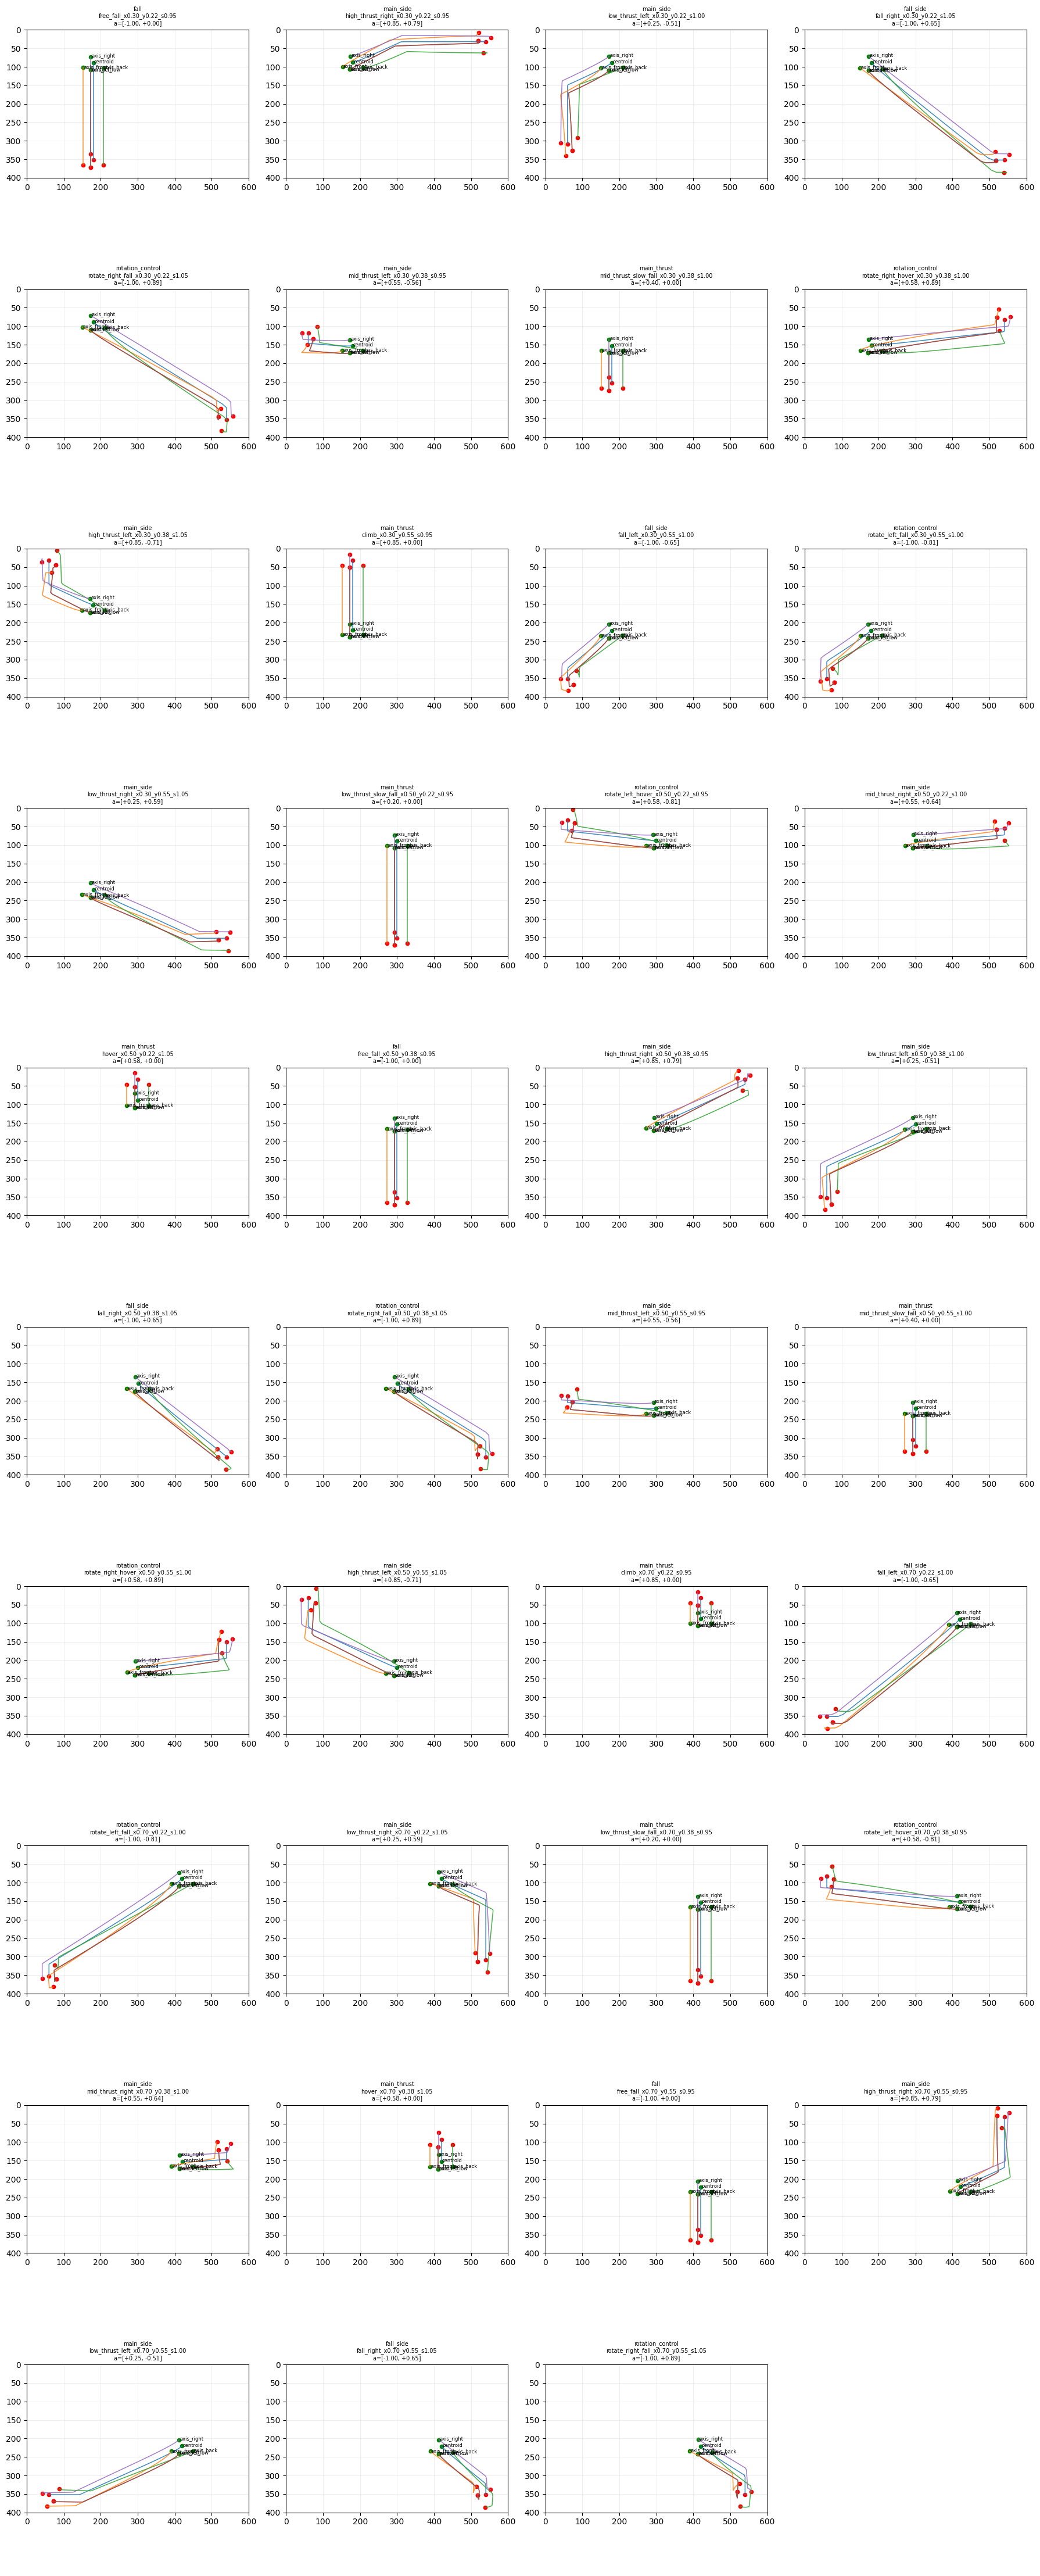

In [186]:
## Axis-Aligned Motion Primitives - LunarLander Action-Conditioned Balanced

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

N_STEPS = 60
FRAME_W = FRAME_WIDTH if "FRAME_WIDTH" in globals() else 600
FRAME_H = FRAME_HEIGHT if "FRAME_HEIGHT" in globals() else 400

CP_NAMES = [p for p in REQUIRED_CP_NAMES if p in prim_agent_shape]

START_XS = [0.30, 0.50, 0.70]
START_YS = [0.22, 0.38, 0.55]
SCALES = [0.95, 1.00, 1.05]

GRAVITY = 0.00055
MAIN_THRUST = 0.00110
SIDE_THRUST = 0.00075
ROT_SPEED = 0.030

X_MIN, X_MAX = 0.10, 0.90
Y_MIN, Y_MAX = 0.08, 0.88


def make_agent_frame(center_x, center_y, theta_rad=0.0, scale=1.0):
    c = np.cos(theta_rad)
    s = np.sin(theta_rad)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)

    rows = []
    for point_name in CP_NAMES:
        offset = prim_agent_shape[point_name].astype(np.float32) * scale
        rotated = R @ offset

        rows.append(
            {
                "point_name": point_name,
                "x": float(center_x + rotated[0]),
                "y": float(center_y + rotated[1]),
                "track_id": 0,
            }
        )

    return pd.DataFrame(rows)


def make_action_curve(main, side, n_steps=N_STEPS, wobble=0.0):
    phase = np.linspace(0, 2 * np.pi, n_steps)

    main_curve = np.full(n_steps, main, dtype=np.float32)
    side_curve = np.full(n_steps, side, dtype=np.float32)

    if wobble > 0:
        main_curve = main_curve + wobble * np.sin(phase)
        side_curve = side_curve + wobble * np.cos(phase)

    main_curve = np.clip(main_curve, -1.0, 1.0)
    side_curve = np.clip(side_curve, -1.0, 1.0)

    return np.stack([main_curve, side_curve], axis=1).astype(np.float32)


def simulate_lander_primitive(
    primitive_name,
    family,
    action_curve,
    start_x,
    start_y,
    init_vx=0.0,
    init_vy=0.0,
    init_theta=0.0,
    scale=1.0,
):
    x = float(start_x)
    y = float(start_y)
    vx = float(init_vx)
    vy = float(init_vy)
    theta = float(init_theta)

    cp_frames = []

    cx = []
    cy = []
    theta_values = []

    for step in range(N_STEPS):
        main = float(action_curve[step, 0])
        side = float(action_curve[step, 1])

        main_power = max(main, 0.0)

        ax = side * SIDE_THRUST
        ay = GRAVITY - main_power * MAIN_THRUST

        vx += ax
        vy += ay

        x += vx
        y += vy
        theta += side * ROT_SPEED

        x = float(np.clip(x, X_MIN, X_MAX))
        y = float(np.clip(y, Y_MIN, Y_MAX))

        cx.append(x * FRAME_W)
        cy.append(y * FRAME_H)
        theta_values.append(theta)

        cp_df = make_agent_frame(
            x * FRAME_W,
            y * FRAME_H,
            theta_rad=theta,
            scale=scale,
        )

        cp_df["step"] = step
        cp_df["primitive_name"] = primitive_name
        cp_df["semantic_family"] = family

        cp_frames.append(cp_df)

    return {
        "primitive_name": primitive_name,
        "family": family,
        "cx": np.asarray(cx, dtype=np.float32),
        "cy": np.asarray(cy, dtype=np.float32),
        "theta": np.asarray(theta_values, dtype=np.float32),
        "actions": [a.astype(np.float32) for a in action_curve],
        "cp_df": pd.concat(cp_frames, ignore_index=True),
    }


primitive_configs = [
    ("free_fall", "fall", -1.0, 0.0, 0.0000, 0.0028),
    ("fall_left", "fall_side", -1.0, -0.65, -0.0010, 0.0023),
    ("fall_right", "fall_side", -1.0, 0.65, 0.0010, 0.0023),

    ("low_thrust_slow_fall", "main_thrust", 0.20, 0.0, 0.0000, 0.0014),
    ("mid_thrust_slow_fall", "main_thrust", 0.40, 0.0, 0.0000, 0.0009),
    ("hover", "main_thrust", 0.58, 0.0, 0.0000, 0.0002),
    ("climb", "main_thrust", 0.85, 0.0, 0.0000, -0.0008),

    ("low_thrust_left", "main_side", 0.25, -0.55, -0.0004, 0.0012),
    ("low_thrust_right", "main_side", 0.25, 0.55, 0.0004, 0.0012),
    ("mid_thrust_left", "main_side", 0.55, -0.60, -0.0005, 0.0007),
    ("mid_thrust_right", "main_side", 0.55, 0.60, 0.0005, 0.0007),
    ("high_thrust_left", "main_side", 0.85, -0.75, -0.0006, 0.0002),
    ("high_thrust_right", "main_side", 0.85, 0.75, 0.0006, 0.0002),

    ("rotate_left_fall", "rotation_control", -1.0, -0.85, -0.0007, 0.0020),
    ("rotate_right_fall", "rotation_control", -1.0, 0.85, 0.0007, 0.0020),
    ("rotate_left_hover", "rotation_control", 0.58, -0.85, -0.0003, 0.0002),
    ("rotate_right_hover", "rotation_control", 0.58, 0.85, 0.0003, 0.0002),
]

primitive_specs = []

for start_x in START_XS:
    for start_y in START_YS:
        for scale in SCALES:
            for name, family, main, side, init_vx, init_vy in primitive_configs:
                action_curve = make_action_curve(
                    main,
                    side,
                    n_steps=N_STEPS,
                    wobble=0.04 if family in ["main_side", "rotation_control"] else 0.0,
                )

                primitive_specs.append(
                    simulate_lander_primitive(
                        primitive_name=f"{name}_x{start_x:.2f}_y{start_y:.2f}_s{scale:.2f}",
                        family=family,
                        action_curve=action_curve,
                        start_x=start_x,
                        start_y=start_y,
                        init_vx=init_vx,
                        init_vy=init_vy,
                        scale=scale,
                    )
                )

primitive_agent_cp_df = pd.concat(
    [spec["cp_df"] for spec in primitive_specs],
    ignore_index=True,
)

primitive_action_rows = []

for spec in primitive_specs:
    for step, action in enumerate(spec["actions"]):
        primitive_action_rows.append(
            {
                "primitive_name": spec["primitive_name"],
                "semantic_family": spec["family"],
                "step": step,
                "action_main": float(action[0]),
                "action_side": float(action[1]),
                "action": action,
            }
        )

primitive_action_df = pd.DataFrame(primitive_action_rows)

print("primitives:", len(primitive_specs))
print("cp rows:", len(primitive_agent_cp_df))
print("action rows:", len(primitive_action_df))

display(primitive_agent_cp_df.head(20))
display(primitive_action_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(primitive_action_df["action_main"], bins=30)
axes[0].set_title("primitive action_main distribution")
axes[0].set_xlabel("main_engine")
axes[0].set_ylabel("count")
axes[0].grid(alpha=0.25)

axes[1].hist(primitive_action_df["action_side"], bins=30)
axes[1].set_title("primitive action_side distribution")
axes[1].set_xlabel("side_engine")
axes[1].set_ylabel("count")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plot primitive motions
# ---------------------------------------------------------

plot_specs = primitive_specs[::max(1, len(primitive_specs) // 36)]

n_cols = 4
n_rows = int(np.ceil(len(plot_specs) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, spec in zip(axes, plot_specs):
    cp_df = spec["cp_df"]

    for point_name in CP_NAMES:
        point_df = cp_df[cp_df["point_name"] == point_name]
        ax.plot(point_df["x"], point_df["y"], linewidth=1.1, alpha=0.85)
        ax.scatter(point_df["x"].iloc[0], point_df["y"].iloc[0], s=20, c="green")
        ax.scatter(point_df["x"].iloc[-1], point_df["y"].iloc[-1], s=20, c="red")

    first = cp_df[cp_df["step"] == 0]
    for _, row in first.iterrows():
        ax.text(row["x"] + 2, row["y"] + 2, row["point_name"], fontsize=6)

    action0 = spec["actions"][0]
    ax.set_title(
        f"{spec['family']}\n{spec['primitive_name']}\na=[{action0[0]:+.2f}, {action0[1]:+.2f}]",
        fontsize=7,
    )
    ax.set_xlim(0, FRAME_W)
    ax.set_ylim(FRAME_H, 0)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

for ax in axes[len(plot_specs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Apply Prim_Background from Env_Background in Every Combination with Prim_Agent with z_primitve

This step builds the supervised dataset for the motion-to-action MLP.

We do not create synthetic background points. Instead, we reuse real background transitions from the pretraining videos and combine them with synthetic primitive-agent CP transitions. This keeps the generated primitive embeddings in the same CP/BG relation space as real video motion.

For each sampled pair:

```text
real BG_{t-s}, BG_t
+
primitive CP_{t-s}, CP_t
->
build_motion_key(...)
->
z_prim = encode_motion_key(...)

Each z_prim is paired with the known primitive action label:

z_prim -> action [main_engine, side_engine]

We sample combinations instead of using the full Cartesian product, because every background transition times every primitive transition creates too many rows without adding much value.```

In [187]:
## Apply Prim_Background from Env_Background sampled with Prim_Agent

import numpy as np
import pandas as pd
from IPython.display import display

N_BG_TRANSITIONS_SAMPLE = 500
N_PRIMITIVE_TRANSITIONS_PER_BG = 64
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

# ---------------------------------------------------------
# 1. Build env background transitions t-s -> t
# ---------------------------------------------------------

background_transitions = []

for bg_episode_id, episode_df in lunar_bckg_df_selected.groupby("episode_id"):
    episode_df = episode_df.sort_values(["frame", "background_point_id"])
    frames = sorted(episode_df["frame"].unique())

    for frame_idx in range(MOTION_STRIDE, len(frames)):
        prev_frame = frames[frame_idx - MOTION_STRIDE]
        frame = frames[frame_idx]

        prev_bg = episode_df[
            episode_df["frame"] == prev_frame
        ].sort_values("background_point_id")

        curr_bg = episode_df[
            episode_df["frame"] == frame
        ].sort_values("background_point_id")

        common_ids = sorted(
            set(prev_bg["background_point_id"])
            & set(curr_bg["background_point_id"])
        )

        if len(common_ids) == 0:
            continue

        background_transitions.append(
            {
                "bg_episode_id": int(bg_episode_id),
                "prev_frame": int(prev_frame),
                "frame": int(frame),
                "prev_bg": prev_bg[
                    prev_bg["background_point_id"].isin(common_ids)
                ].copy(),
                "curr_bg": curr_bg[
                    curr_bg["background_point_id"].isin(common_ids)
                ].copy(),
                "n_bg_points": int(len(common_ids)),
            }
        )

if len(background_transitions) > N_BG_TRANSITIONS_SAMPLE:
    keep_idx = rng.choice(
        len(background_transitions),
        size=N_BG_TRANSITIONS_SAMPLE,
        replace=False,
    )
    background_transitions = [background_transitions[i] for i in keep_idx]

print("background transitions:", len(background_transitions))


# ---------------------------------------------------------
# 2. Build primitive transitions t-s -> t
# ---------------------------------------------------------

primitive_transitions = []

for spec in primitive_specs:
    cp_df = spec["cp_df"].copy()
    steps = sorted(cp_df["step"].unique())
    actions = spec["actions"]

    for step_idx in range(MOTION_STRIDE, len(steps)):
        prev_step = steps[step_idx - MOTION_STRIDE]
        step = steps[step_idx]

        prev_cp = (
            cp_df[cp_df["step"] == prev_step]
            [["point_name", "x", "y", "track_id"]]
            .copy()
        )

        curr_cp = (
            cp_df[cp_df["step"] == step]
            [["point_name", "x", "y", "track_id"]]
            .copy()
        )

        primitive_transitions.append(
            {
                "primitive_name": spec["primitive_name"],
                "semantic_family": spec["family"],
                "prev_step": int(prev_step),
                "step": int(step),
                "prev_cp": prev_cp,
                "curr_cp": curr_cp,
                "action": np.asarray(actions[step], dtype=np.float32),
            }
        )

print("primitive transitions:", len(primitive_transitions))


# ---------------------------------------------------------
# 3. Sampled mix: env background x subset primitive agent
# ---------------------------------------------------------

mlp_rows = []
primitive_indices = np.arange(len(primitive_transitions))

for bg_item in background_transitions:
    n_prim = min(N_PRIMITIVE_TRANSITIONS_PER_BG, len(primitive_transitions))
    sampled_prim_idx = rng.choice(
        primitive_indices,
        size=n_prim,
        replace=False,
    )

    for prim_idx in sampled_prim_idx:
        prim_item = primitive_transitions[int(prim_idx)]

        motion_key = build_motion_key(
            prim_item["prev_cp"],
            prim_item["curr_cp"],
            bg_item["prev_bg"],
            bg_item["curr_bg"],
        )

        z = encode_motion_key(motion_key)
        action = prim_item["action"]

        mlp_rows.append(
            {
                "bg_episode_id": bg_item["bg_episode_id"],
                "bg_prev_frame": bg_item["prev_frame"],
                "bg_frame": bg_item["frame"],
                "n_bg_points": bg_item["n_bg_points"],
                "primitive_name": prim_item["primitive_name"],
                "semantic_family": prim_item["semantic_family"],
                "primitive_prev_step": prim_item["prev_step"],
                "primitive_step": prim_item["step"],
                "z_primitive": z,
                "action": action,
                "action_main": float(action[0]),
                "action_side": float(action[1]),
            }
        )

primitive_mlp_dataset_df = pd.DataFrame(mlp_rows)

print("MLP dataset rows:", len(primitive_mlp_dataset_df))
print("z dim:", len(primitive_mlp_dataset_df["z_primitive"].iloc[0]))
display(primitive_mlp_dataset_df.head(20))

background transitions: 500
primitive transitions: 25245
MLP dataset rows: 32000
z dim: 12


,bg_episode_id,bg_prev_frame,bg_frame,n_bg_points,primitive_name,semantic_family,primitive_prev_step,primitive_step,z_primitive,action,action_main,action_side
0,69,23,36,122,free_fall_x0.50_y0.22_s1.00,fall,40,45,"[0.0, 0.07182956, 0.0, 0.07182962, 0.0, 0.0718...","[-1.0, 0.0]",-1.000000,0.000000
1,69,23,36,122,high_thrust_right_x0.70_y0.22_s1.00,main_side,1,6,"[0.014454484, -0.00081029534, 0.015764177, -0....","[0.8738547, 0.7821085]",0.873855,0.782108
2,69,23,36,122,free_fall_x0.50_y0.22_s0.95,fall,9,14,"[0.0, 0.049874693, 0.0, 0.049874663, 0.0, 0.04...","[-1.0, 0.0]",-1.000000,0.000000
3,69,23,36,122,high_thrust_right_x0.70_y0.22_s1.00,main_side,49,54,"[-0.0062812567, -0.00051286817, 0.004212737, -...","[0.8296934, 0.78446215]",0.829693,0.784462
4,69,23,36,122,mid_thrust_left_x0.50_y0.38_s1.00,main_side,11,16,"[-0.033877432, -0.00973174, -0.031802922, 0.00...","[0.5896461, -0.60530907]",0.589646,-0.605309
5,69,23,36,122,fall_left_x0.70_y0.38_s1.05,fall_side,45,50,"[-0.029676318, -0.007280946, -0.021670535, 0.0...","[-1.0, -0.65]",-1.000000,-0.650000
6,69,23,36,122,rotate_right_fall_x0.70_y0.22_s1.05,rotation_control,17,22,"[0.06592286, 0.07376853, 0.07244539, 0.0574695...","[-0.9713417, 0.82209474]",-0.971342,0.822095
7,69,23,36,122,rotate_right_hover_x0.50_y0.38_s1.00,rotation_control,49,54,"[-0.0069381, -0.02510801, 0.005513251, -0.0294...","[0.55969334, 0.8844622]",0.559693,0.884462
8,69,23,36,122,rotate_left_fall_x0.70_y0.55_s0.95,rotation_control,44,49,"[-0.0044793487, -0.0069293976, 0.0063763782, -...","[-1.0, -0.83061796]",-1.000000,-0.830618
9,69,23,36,122,fall_left_x0.30_y0.22_s1.05,fall_side,8,13,"[-0.03306988, 0.036548167, -0.030942649, 0.051...","[-1.0, -0.65]",-1.000000,-0.650000


## Visualize Random Primitive + Env Background Mix

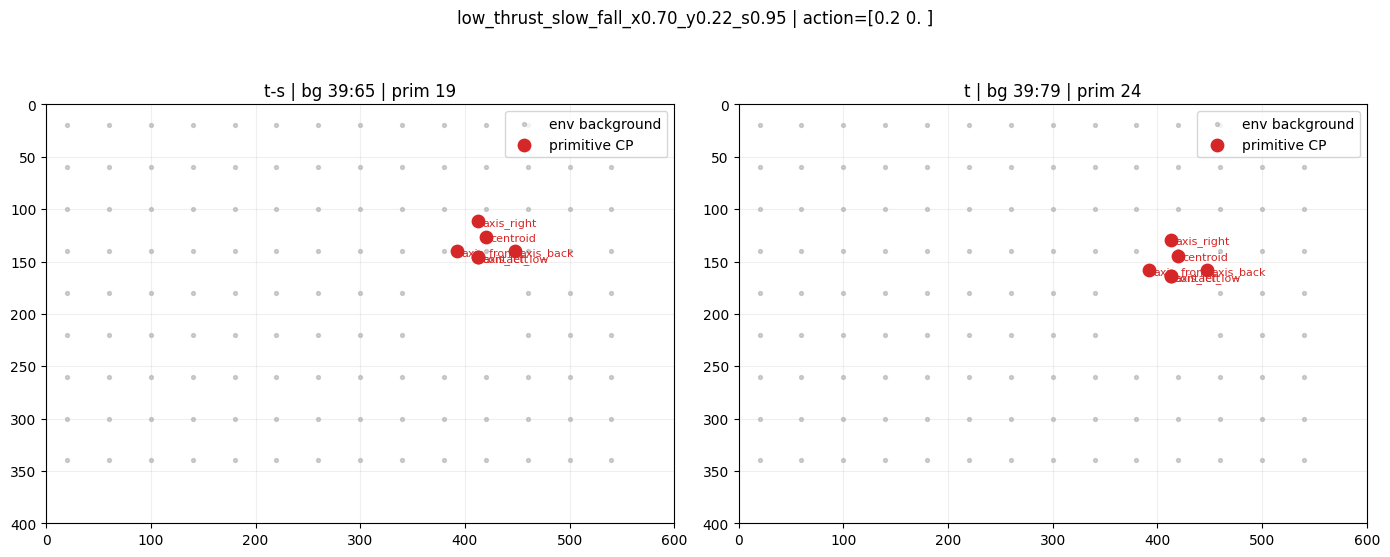

,primitive_name,semantic_family,bg_episode_id,bg_prev_frame,bg_frame,primitive_prev_step,primitive_step,n_bg_points,action_main,action_side
0,low_thrust_slow_fall_x0.70_y0.22_s0.95,main_thrust,39,65,79,19,24,122,0.2,0.0


In [188]:
## Visualize Random Primitive + Env Background Mix

import matplotlib.pyplot as plt
from IPython.display import display

sample_row = primitive_mlp_dataset_df.sample(1).iloc[0]

bg_episode_id = int(sample_row["bg_episode_id"])
bg_prev_frame = int(sample_row["bg_prev_frame"])
bg_frame = int(sample_row["bg_frame"])
primitive_name = sample_row["primitive_name"]
primitive_prev_step = int(sample_row["primitive_prev_step"])
primitive_step = int(sample_row["primitive_step"])

bg_episode_df = lunar_bckg_df_selected[
    lunar_bckg_df_selected["episode_id"] == bg_episode_id
].copy()

prev_bg = bg_episode_df[
    bg_episode_df["frame"] == bg_prev_frame
].sort_values("background_point_id")

curr_bg = bg_episode_df[
    bg_episode_df["frame"] == bg_frame
].sort_values("background_point_id")

common_bg_ids = sorted(
    set(prev_bg["background_point_id"])
    & set(curr_bg["background_point_id"])
)

prev_bg = prev_bg[
    prev_bg["background_point_id"].isin(common_bg_ids)
].copy()

curr_bg = curr_bg[
    curr_bg["background_point_id"].isin(common_bg_ids)
].copy()

primitive_spec = next(
    spec for spec in primitive_specs
    if spec["primitive_name"] == primitive_name
)

prim_cp_df = primitive_spec["cp_df"]

prev_cp = prim_cp_df[
    prim_cp_df["step"] == primitive_prev_step
].sort_values("point_name")

curr_cp = prim_cp_df[
    prim_cp_df["step"] == primitive_step
].sort_values("point_name")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, title, bg_df, cp_df in [
    (axes[0], f"t-s | bg {bg_episode_id}:{bg_prev_frame} | prim {primitive_prev_step}", prev_bg, prev_cp),
    (axes[1], f"t | bg {bg_episode_id}:{bg_frame} | prim {primitive_step}", curr_bg, curr_cp),
]:
    ax.scatter(
        bg_df["x"],
        bg_df["y"],
        s=8,
        c="gray",
        alpha=0.35,
        label="env background",
    )

    ax.scatter(
        cp_df["x"],
        cp_df["y"],
        s=80,
        c="tab:red",
        label="primitive CP",
        zorder=3,
    )

    for _, row in cp_df.iterrows():
        ax.text(
            row["x"] + 4,
            row["y"] + 4,
            row["point_name"],
            fontsize=8,
            color="tab:red",
        )

    ax.set_title(title)
    ax.set_xlim(0, FRAME_WIDTH)
    ax.set_ylim(FRAME_HEIGHT, 0)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")

plt.suptitle(
    f"{primitive_name} | action={sample_row['action']}",
    fontsize=12,
)

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        [
            {
                "primitive_name": primitive_name,
                "semantic_family": sample_row["semantic_family"],
                "bg_episode_id": bg_episode_id,
                "bg_prev_frame": bg_prev_frame,
                "bg_frame": bg_frame,
                "primitive_prev_step": primitive_prev_step,
                "primitive_step": primitive_step,
                "n_bg_points": int(sample_row["n_bg_points"]),
                "action_main": float(sample_row["action_main"]),
                "action_side": float(sample_row["action_side"]),
            }
        ]
    )
)

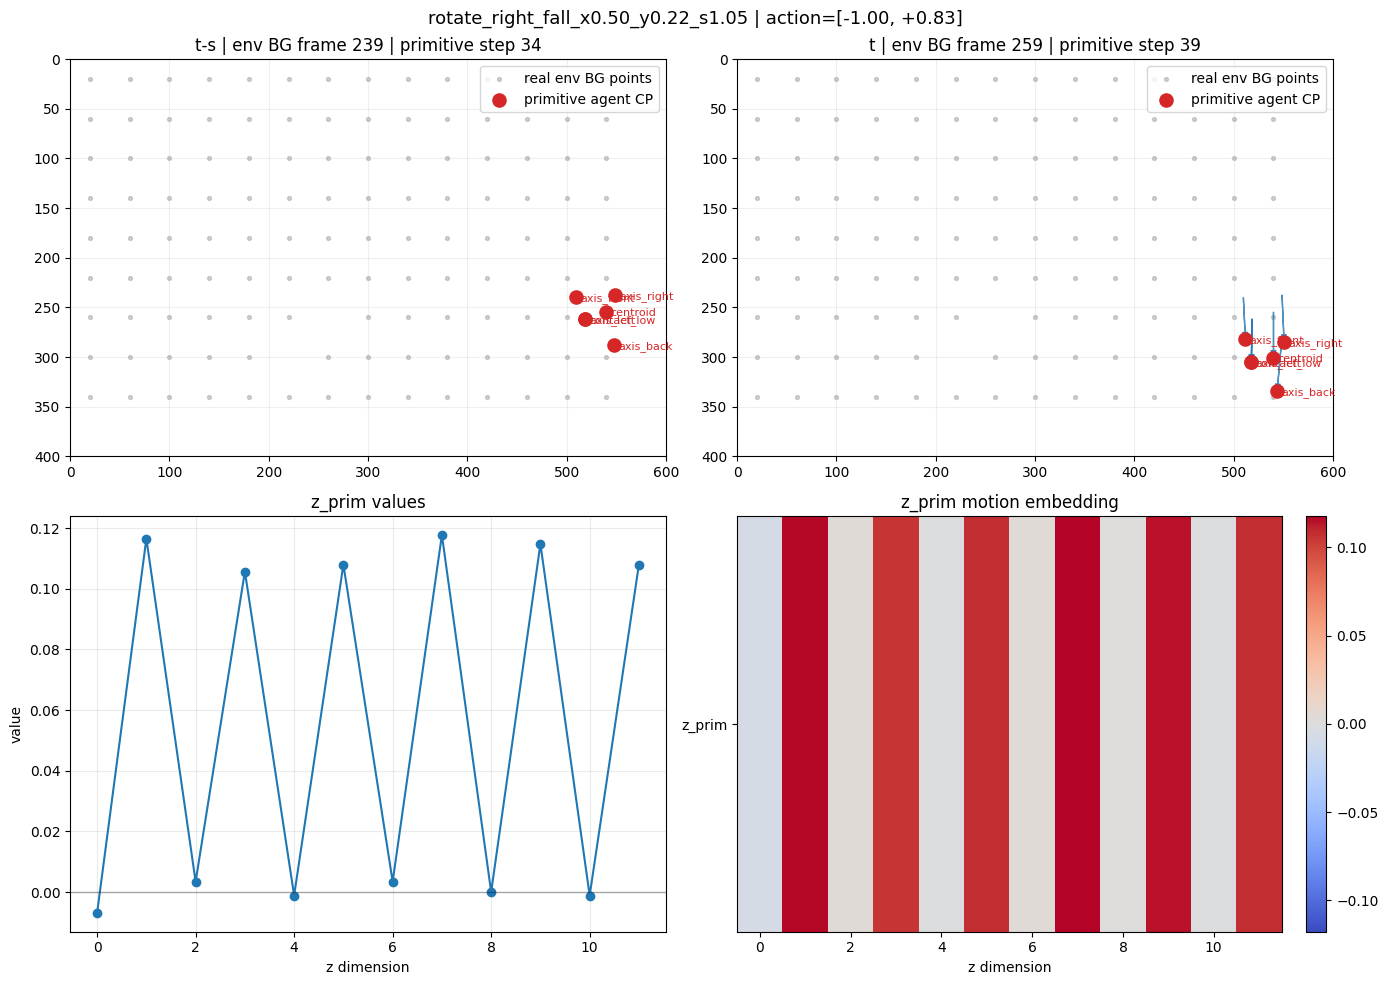

,primitive_name,semantic_family,bg_episode_id,bg_prev_frame,bg_frame,primitive_prev_step,primitive_step,n_bg_points,z_dim,action_main,action_side
0,rotate_right_fall_x0.50_y0.22_s1.05,rotation_control,390,239,259,34,39,124,12,-1.0,0.828783


In [189]:
## Visualize Primitive Background Mix: BG Points, Primitive CP, z_prim

sample_row = primitive_mlp_dataset_df.sample(1, random_state=None).iloc[0]

bg_episode_id = int(sample_row["bg_episode_id"])
bg_prev_frame = int(sample_row["bg_prev_frame"])
bg_frame = int(sample_row["bg_frame"])
primitive_name = sample_row["primitive_name"]
primitive_prev_step = int(sample_row["primitive_prev_step"])
primitive_step = int(sample_row["primitive_step"])

bg_episode_df = lunar_bckg_df_selected[
    lunar_bckg_df_selected["episode_id"] == bg_episode_id
].copy()

prev_bg = bg_episode_df[
    bg_episode_df["frame"] == bg_prev_frame
].sort_values("background_point_id")

curr_bg = bg_episode_df[
    bg_episode_df["frame"] == bg_frame
].sort_values("background_point_id")

common_bg_ids = sorted(
    set(prev_bg["background_point_id"])
    & set(curr_bg["background_point_id"])
)

prev_bg = prev_bg[
    prev_bg["background_point_id"].isin(common_bg_ids)
].copy()

curr_bg = curr_bg[
    curr_bg["background_point_id"].isin(common_bg_ids)
].copy()

primitive_spec = next(
    spec for spec in primitive_specs
    if spec["primitive_name"] == primitive_name
)

prim_cp_df = primitive_spec["cp_df"]

prev_cp = prim_cp_df[
    prim_cp_df["step"] == primitive_prev_step
].sort_values("point_name")

curr_cp = prim_cp_df[
    prim_cp_df["step"] == primitive_step
].sort_values("point_name")

motion_key = build_motion_key(
    prev_cp,
    curr_cp,
    prev_bg,
    curr_bg,
)

z_prim = encode_motion_key(motion_key)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax_prev = axes[0, 0]
ax_curr = axes[0, 1]
ax_z_line = axes[1, 0]
ax_z_heat = axes[1, 1]

for ax, bg_df, cp_df, title in [
    (
        ax_prev,
        prev_bg,
        prev_cp,
        f"t-s | env BG frame {bg_prev_frame} | primitive step {primitive_prev_step}",
    ),
    (
        ax_curr,
        curr_bg,
        curr_cp,
        f"t | env BG frame {bg_frame} | primitive step {primitive_step}",
    ),
]:
    ax.scatter(
        bg_df["x"],
        bg_df["y"],
        s=8,
        c="gray",
        alpha=0.35,
        label="real env BG points",
    )

    ax.scatter(
        cp_df["x"],
        cp_df["y"],
        s=90,
        c="tab:red",
        label="primitive agent CP",
        zorder=3,
    )

    for _, row in cp_df.iterrows():
        ax.text(
            row["x"] + 4,
            row["y"] + 4,
            row["point_name"],
            fontsize=8,
            color="tab:red",
        )

    ax.set_title(title)
    ax.set_xlim(0, FRAME_WIDTH)
    ax.set_ylim(FRAME_HEIGHT, 0)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")

for _, prev_row in prev_cp.iterrows():
    point_name = prev_row["point_name"]
    curr_match = curr_cp[curr_cp["point_name"] == point_name]

    if curr_match.empty:
        continue

    curr_row = curr_match.iloc[0]

    ax_curr.arrow(
        prev_row["x"],
        prev_row["y"],
        curr_row["x"] - prev_row["x"],
        curr_row["y"] - prev_row["y"],
        head_width=5,
        head_length=7,
        length_includes_head=True,
        color="tab:blue",
        alpha=0.8,
    )

ax_z_line.plot(np.arange(len(z_prim)), z_prim, marker="o")
ax_z_line.axhline(0, color="black", linewidth=1, alpha=0.3)
ax_z_line.set_title("z_prim values")
ax_z_line.set_xlabel("z dimension")
ax_z_line.set_ylabel("value")
ax_z_line.grid(alpha=0.25)

z_abs = max(float(np.max(np.abs(z_prim))), 1e-8)

im = ax_z_heat.imshow(
    z_prim.reshape(1, -1),
    cmap="coolwarm",
    aspect="auto",
    vmin=-z_abs,
    vmax=z_abs,
)

ax_z_heat.set_title("z_prim motion embedding")
ax_z_heat.set_xlabel("z dimension")
ax_z_heat.set_yticks([0])
ax_z_heat.set_yticklabels(["z_prim"])

fig.colorbar(im, ax=ax_z_heat, fraction=0.046, pad=0.04)

fig.suptitle(
    f"{primitive_name} | action=[{sample_row['action_main']:+.2f}, {sample_row['action_side']:+.2f}]",
    fontsize=13,
)

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        [
            {
                "primitive_name": primitive_name,
                "semantic_family": sample_row["semantic_family"],
                "bg_episode_id": bg_episode_id,
                "bg_prev_frame": bg_prev_frame,
                "bg_frame": bg_frame,
                "primitive_prev_step": primitive_prev_step,
                "primitive_step": primitive_step,
                "n_bg_points": int(sample_row["n_bg_points"]),
                "z_dim": int(len(z_prim)),
                "action_main": float(sample_row["action_main"]),
                "action_side": float(sample_row["action_side"]),
            }
        ]
    )
)

# Action Inference Model

## Dataset

In [190]:
## Action Inference Model - Dataset

import numpy as np
import pandas as pd
from IPython.display import display

# If z_primitive was not saved yet, rebuild it.
if "z_primitive" not in primitive_mlp_dataset_df.columns:
    z_values = []

    for _, row in primitive_mlp_dataset_df.iterrows():
        bg_episode_id = int(row["bg_episode_id"])
        bg_prev_frame = int(row["bg_prev_frame"])
        bg_frame = int(row["bg_frame"])
        primitive_name = row["primitive_name"]
        primitive_prev_step = int(row["primitive_prev_step"])
        primitive_step = int(row["primitive_step"])

        bg_episode_df = lunar_bckg_df_selected[
            lunar_bckg_df_selected["episode_id"] == bg_episode_id
        ]

        prev_bg = bg_episode_df[
            bg_episode_df["frame"] == bg_prev_frame
        ].sort_values("background_point_id")

        curr_bg = bg_episode_df[
            bg_episode_df["frame"] == bg_frame
        ].sort_values("background_point_id")

        common_bg_ids = sorted(
            set(prev_bg["background_point_id"])
            & set(curr_bg["background_point_id"])
        )

        prev_bg = prev_bg[
            prev_bg["background_point_id"].isin(common_bg_ids)
        ].copy()

        curr_bg = curr_bg[
            curr_bg["background_point_id"].isin(common_bg_ids)
        ].copy()

        primitive_spec = next(
            spec for spec in primitive_specs
            if spec["primitive_name"] == primitive_name
        )

        prim_cp_df = primitive_spec["cp_df"]

        prev_cp = (
            prim_cp_df[prim_cp_df["step"] == primitive_prev_step]
            [["point_name", "x", "y", "track_id"]]
            .sort_values("point_name")
            .copy()
        )

        curr_cp = (
            prim_cp_df[prim_cp_df["step"] == primitive_step]
            [["point_name", "x", "y", "track_id"]]
            .sort_values("point_name")
            .copy()
        )

        motion_key = build_motion_key(
            prev_cp,
            curr_cp,
            prev_bg,
            curr_bg,
        )

        z_values.append(encode_motion_key(motion_key))

    primitive_mlp_dataset_df["z_primitive"] = z_values


# Build numeric arrays for MLP.
X_action_inference = np.stack(
    primitive_mlp_dataset_df["z_primitive"].to_numpy()
).astype(np.float32)

y_action_inference = primitive_mlp_dataset_df[
    ["action_main", "action_side"]
].to_numpy(dtype=np.float32)

print("X shape:", X_action_inference.shape)
print("y shape:", y_action_inference.shape)
print("z dim:", X_action_inference.shape[1])
print("action dim:", y_action_inference.shape[1])

display(
    primitive_mlp_dataset_df[
        [
            "primitive_name",
            "semantic_family",
            "bg_episode_id",
            "bg_prev_frame",
            "bg_frame",
            "primitive_prev_step",
            "primitive_step",
            "n_bg_points",
            "action_main",
            "action_side",
        ]
    ].head(200)
)

X shape: (32000, 12)
y shape: (32000, 2)
z dim: 12
action dim: 2


,primitive_name,semantic_family,bg_episode_id,bg_prev_frame,bg_frame,primitive_prev_step,primitive_step,n_bg_points,action_main,action_side
0,free_fall_x0.50_y0.22_s1.00,fall,69,23,36,40,45,122,-1.000000,0.000000
1,high_thrust_right_x0.70_y0.22_s1.00,main_side,69,23,36,1,6,122,0.873855,0.782108
2,free_fall_x0.50_y0.22_s0.95,fall,69,23,36,9,14,122,-1.000000,0.000000
3,high_thrust_right_x0.70_y0.22_s1.00,main_side,69,23,36,49,54,122,0.829693,0.784462
4,mid_thrust_left_x0.50_y0.38_s1.00,main_side,69,23,36,11,16,122,0.589646,-0.605309
...,...,...,...,...,...,...,...,...,...,...
195,fall_left_x0.30_y0.55_s1.05,fall_side,314,44,57,18,23,121,-1.000000,-0.650000
196,free_fall_x0.30_y0.22_s0.95,fall,314,44,57,38,43,121,-1.000000,0.000000
197,mid_thrust_slow_fall_x0.50_y0.38_s1.05,main_thrust,314,44,57,30,35,121,0.400000,0.000000
198,high_thrust_left_x0.30_y0.55_s1.00,main_side,314,44,57,15,20,121,0.883909,-0.771217


## Train-Test Split

In [191]:
## Action Inference Model - Train/Test Split

import numpy as np
import pandas as pd
from IPython.display import display

RANDOM_STATE = 42
TEST_SIZE = 0.2

n_samples = len(X_action_inference)

rng = np.random.default_rng(RANDOM_STATE)
indices = np.arange(n_samples)
rng.shuffle(indices)

n_test = int(round(n_samples * TEST_SIZE))

test_idx = indices[:n_test]
train_idx = indices[n_test:]

X_train = X_action_inference[train_idx]
y_train = y_action_inference[train_idx]

X_test = X_action_inference[test_idx]
y_test = y_action_inference[test_idx]

train_meta_df = primitive_mlp_dataset_df.iloc[train_idx].reset_index(drop=True)
test_meta_df = primitive_mlp_dataset_df.iloc[test_idx].reset_index(drop=True)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

display(
    pd.DataFrame(
        {
            "split": ["train", "test"],
            "samples": [len(X_train), len(X_test)],
            "fraction": [len(X_train) / n_samples, len(X_test) / n_samples],
        }
    )
)

X_train: (25600, 12)
y_train: (25600, 2)
X_test: (6400, 12)
y_test: (6400, 2)


,split,samples,fraction
0,train,25600,0.8
1,test,6400,0.2


## MLP ($z_{dim} \rightarrow 2$)

In [192]:
## Action Inference Model - MLP

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ACTION_INPUT_DIM = X_train.shape[1]
ACTION_OUTPUT_DIM = y_train.shape[1]
ACTION_HIDDEN_DIM = 128
ACTION_DROPOUT = 0.1


class ActionInferenceMLP(nn.Module):
    def __init__(
        self,
        input_dim=ACTION_INPUT_DIM,
        hidden_dim=ACTION_HIDDEN_DIM,
        output_dim=ACTION_OUTPUT_DIM,
        dropout=ACTION_DROPOUT,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, output_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


action_inference_model = ActionInferenceMLP().to(DEVICE)

print(action_inference_model)
print("device:", DEVICE)
print("input dim:", ACTION_INPUT_DIM)
print("output dim:", ACTION_OUTPUT_DIM)

ActionInferenceMLP(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=2, bias=True)
    (9): Tanh()
  )
)
device: cpu
input dim: 12
output dim: 2


## Train

In [193]:
## Action Inference Model - Training

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display

ACTION_BATCH_SIZE = 256
ACTION_TRAIN_STEPS = 1000
ACTION_LR = 1e-3
ACTION_WEIGHT_DECAY = 1e-4
ACTION_EVAL_EVERY = 50

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)

X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DEVICE)

optimizer = torch.optim.AdamW(
    action_inference_model.parameters(),
    lr=ACTION_LR,
    weight_decay=ACTION_WEIGHT_DECAY,
)

loss_fn = nn.MSELoss()

history = []

for step in range(1, ACTION_TRAIN_STEPS + 1):
    batch_idx = torch.randint(
        0,
        X_train_t.shape[0],
        (min(ACTION_BATCH_SIZE, X_train_t.shape[0]),),
        device=DEVICE,
    )

    xb = X_train_t[batch_idx]
    yb = y_train_t[batch_idx]

    action_inference_model.train()
    pred = action_inference_model(xb)
    train_loss = loss_fn(pred, yb)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    if step == 1 or step % ACTION_EVAL_EVERY == 0:
        action_inference_model.eval()
        with torch.no_grad():
            test_pred = action_inference_model(X_test_t)
            test_loss = loss_fn(test_pred, y_test_t)

        history.append(
            {
                "step": step,
                "train_loss": float(train_loss.detach().cpu()),
                "test_loss": float(test_loss.detach().cpu()),
            }
        )

        print(
            f"step {step:04d} | "
            f"train loss {history[-1]['train_loss']:.6f} | "
            f"test loss {history[-1]['test_loss']:.6f}"
        )

action_inference_history_df = pd.DataFrame(history)
display(action_inference_history_df.tail())

step 0001 | train loss 0.682919 | test loss 0.474420
step 0050 | train loss 0.279844 | test loss 0.250271
step 0100 | train loss 0.235045 | test loss 0.243894
step 0150 | train loss 0.239015 | test loss 0.238494
step 0200 | train loss 0.223140 | test loss 0.231071
step 0250 | train loss 0.212222 | test loss 0.219310
step 0300 | train loss 0.244047 | test loss 0.204546
step 0350 | train loss 0.189076 | test loss 0.173296
step 0400 | train loss 0.182814 | test loss 0.163887
step 0450 | train loss 0.156197 | test loss 0.152537
step 0500 | train loss 0.153542 | test loss 0.144299
step 0550 | train loss 0.151575 | test loss 0.143387
step 0600 | train loss 0.131063 | test loss 0.142687
step 0650 | train loss 0.144689 | test loss 0.131590
step 0700 | train loss 0.142916 | test loss 0.128684
step 0750 | train loss 0.133478 | test loss 0.124492
step 0800 | train loss 0.130295 | test loss 0.123567
step 0850 | train loss 0.165921 | test loss 0.121533
step 0900 | train loss 0.135742 | test loss 0.

,step,train_loss,test_loss
16,800,0.130295,0.123567
17,850,0.165921,0.121533
18,900,0.135742,0.120250
19,950,0.128882,0.115509
20,1000,0.109022,0.115542


## Plot Loss

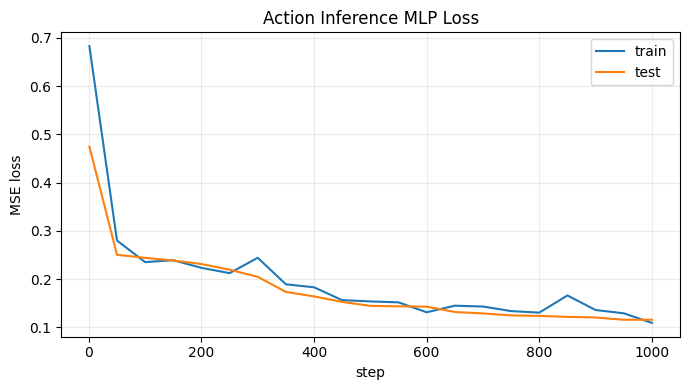

,step,train_loss,test_loss
11,550,0.151575,0.143387
12,600,0.131063,0.142687
13,650,0.144689,0.131590
14,700,0.142916,0.128684
15,750,0.133478,0.124492
16,800,0.130295,0.123567
17,850,0.165921,0.121533
18,900,0.135742,0.120250
19,950,0.128882,0.115509
20,1000,0.109022,0.115542


In [194]:
## Action Inference Model - Loss Curve

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    action_inference_history_df["step"],
    action_inference_history_df["train_loss"],
    label="train",
)

ax.plot(
    action_inference_history_df["step"],
    action_inference_history_df["test_loss"],
    label="test",
)

ax.set_title("Action Inference MLP Loss")
ax.set_xlabel("step")
ax.set_ylabel("MSE loss")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

display(action_inference_history_df.tail(10))

## Eval Scatter

,split,action_dim,rmse,mae
0,train,main_engine,0.465391,0.304341
1,train,side_engine,0.118681,0.079421
2,test,main_engine,0.465997,0.302284
3,test,side_engine,0.118027,0.078499


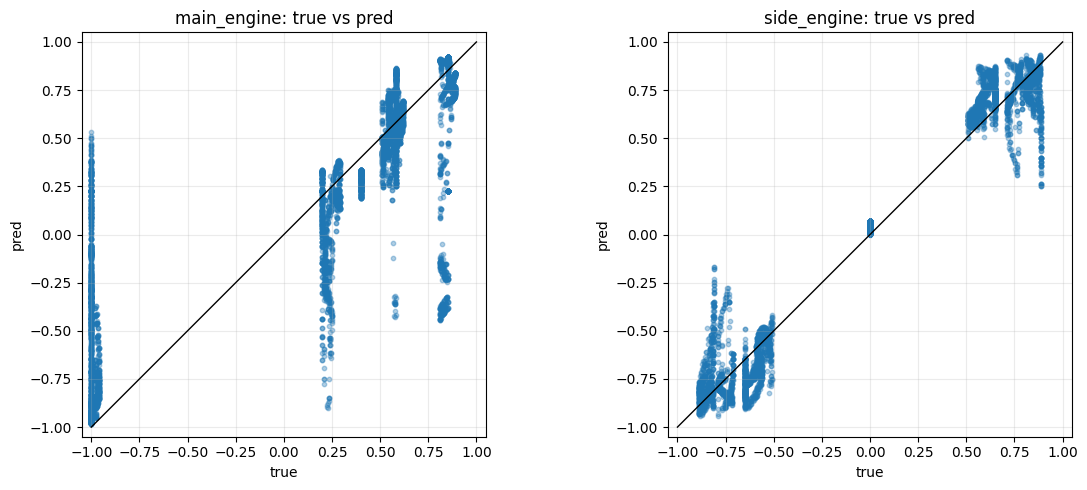

In [195]:
## Action Inference Model - Evaluation

action_inference_model.eval()

with torch.no_grad():
    y_train_pred = action_inference_model(X_train_t).detach().cpu().numpy()
    y_test_pred = action_inference_model(X_test_t).detach().cpu().numpy()

train_rmse = np.sqrt(np.mean((y_train_pred - y_train) ** 2, axis=0))
test_rmse = np.sqrt(np.mean((y_test_pred - y_test) ** 2, axis=0))

train_mae = np.mean(np.abs(y_train_pred - y_train), axis=0)
test_mae = np.mean(np.abs(y_test_pred - y_test), axis=0)

eval_df = pd.DataFrame(
    {
        "split": ["train", "train", "test", "test"],
        "action_dim": ["main_engine", "side_engine"] * 2,
        "rmse": [
            train_rmse[0],
            train_rmse[1],
            test_rmse[0],
            test_rmse[1],
        ],
        "mae": [
            train_mae[0],
            train_mae[1],
            test_mae[0],
            test_mae[1],
        ],
    }
)

display(eval_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for action_idx, action_name in enumerate(["main_engine", "side_engine"]):
    ax = axes[action_idx]

    ax.scatter(
        y_test[:, action_idx],
        y_test_pred[:, action_idx],
        s=10,
        alpha=0.35,
    )

    ax.plot([-1, 1], [-1, 1], color="black", linewidth=1)

    ax.set_title(f"{action_name}: true vs pred")
    ax.set_xlabel("true")
    ax.set_ylabel("pred")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

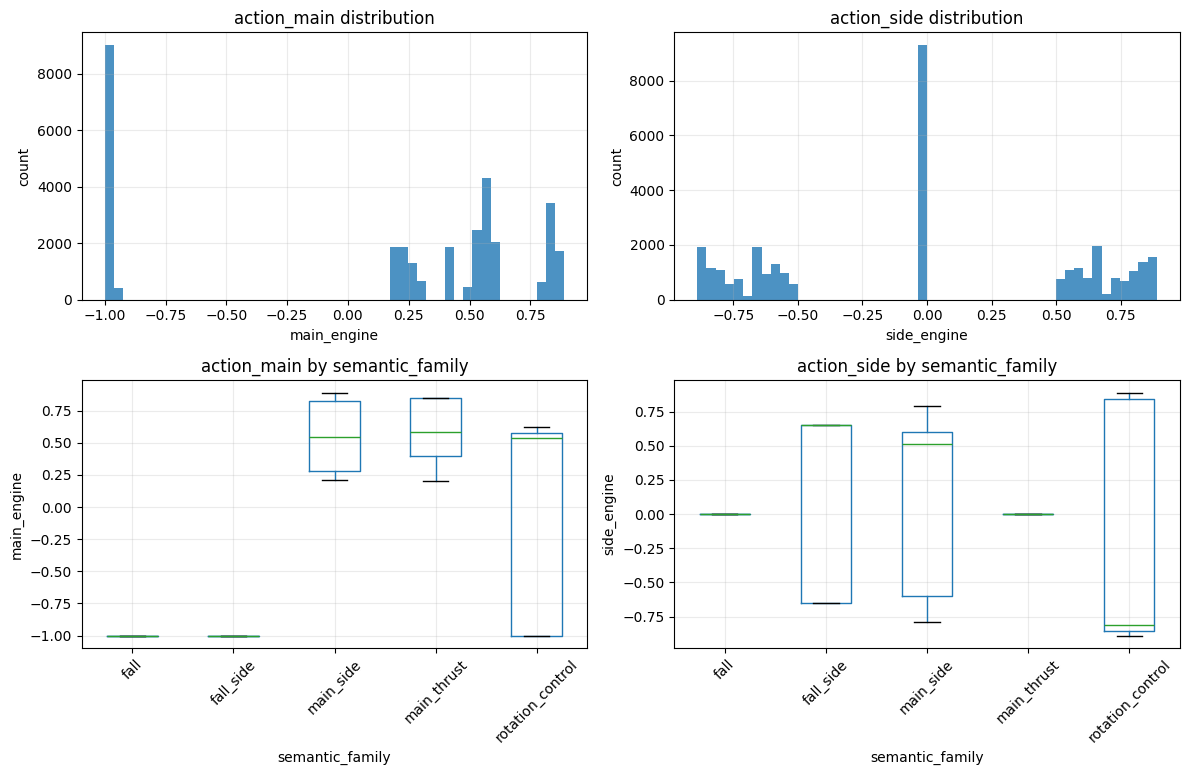

,semantic_family,n,main_mean,main_std,main_min,main_max,side_mean,side_std,side_min,side_max
0,fall,1839,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.00
1,fall_side,3868,-1.000000,0.000000,-1.000000,-1.000000,0.007058,0.650046,-0.650000,0.65
2,main_side,11320,0.548916,0.247559,0.210014,0.889986,0.000900,0.639491,-0.789943,0.79
3,main_thrust,7457,0.511703,0.241948,0.200000,0.850000,0.000000,0.000000,0.000000,0.00
4,rotation_control,7516,-0.198674,0.783500,-1.000000,0.619986,-0.006122,0.850506,-0.889943,0.89


In [196]:
## Action Inference Model - Action Label Distribution

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(
    primitive_mlp_dataset_df["action_main"],
    bins=50,
    alpha=0.8,
)
axes[0, 0].set_title("action_main distribution")
axes[0, 0].set_xlabel("main_engine")
axes[0, 0].set_ylabel("count")
axes[0, 0].grid(alpha=0.25)

axes[0, 1].hist(
    primitive_mlp_dataset_df["action_side"],
    bins=50,
    alpha=0.8,
)
axes[0, 1].set_title("action_side distribution")
axes[0, 1].set_xlabel("side_engine")
axes[0, 1].set_ylabel("count")
axes[0, 1].grid(alpha=0.25)

primitive_mlp_dataset_df.boxplot(
    column="action_main",
    by="semantic_family",
    ax=axes[1, 0],
    rot=45,
)
axes[1, 0].set_title("action_main by semantic_family")
axes[1, 0].set_xlabel("semantic_family")
axes[1, 0].set_ylabel("main_engine")
axes[1, 0].grid(alpha=0.25)

primitive_mlp_dataset_df.boxplot(
    column="action_side",
    by="semantic_family",
    ax=axes[1, 1],
    rot=45,
)
axes[1, 1].set_title("action_side by semantic_family")
axes[1, 1].set_xlabel("semantic_family")
axes[1, 1].set_ylabel("side_engine")
axes[1, 1].grid(alpha=0.25)

plt.suptitle("")
plt.tight_layout()
plt.show()

display(
    primitive_mlp_dataset_df
    .groupby("semantic_family")
    .agg(
        n=("action_main", "size"),
        main_mean=("action_main", "mean"),
        main_std=("action_main", "std"),
        main_min=("action_main", "min"),
        main_max=("action_main", "max"),
        side_mean=("action_side", "mean"),
        side_std=("action_side", "std"),
        side_min=("action_side", "min"),
        side_max=("action_side", "max"),
    )
    .reset_index()
)

# Static Action Inference Rollout

## Load / Select Video

In [197]:
## Action Inference Rollout - Load Expert Test Videos

from pathlib import Path
import pandas as pd
from IPython.display import display

ROLLOUT_VIDEO_DIR = PROJECT_ROOT / "lunarlander_expert" / "videos" / "expert_test"

rollout_video_paths = sorted(ROLLOUT_VIDEO_DIR.glob("*.mp4"))

rollout_rewards_path = ROLLOUT_VIDEO_DIR / "rewards.csv"
rollout_rewards_df = (
    pd.read_csv(rollout_rewards_path)
    if rollout_rewards_path.exists()
    else pd.DataFrame()
)

print("rollout video dir:", ROLLOUT_VIDEO_DIR)
print("rollout videos:", len(rollout_video_paths))

if len(rollout_video_paths) == 0:
    raise FileNotFoundError(f"No .mp4 files found in {ROLLOUT_VIDEO_DIR}")

display(pd.DataFrame({"video_path": rollout_video_paths}).head(20))

if not rollout_rewards_df.empty:
    display(rollout_rewards_df.head(20))

rollout video dir: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_test
rollout videos: 10


,video_path
0,/Users/adriankazi/Desktop/Action Inference/lun...
1,/Users/adriankazi/Desktop/Action Inference/lun...
2,/Users/adriankazi/Desktop/Action Inference/lun...
3,/Users/adriankazi/Desktop/Action Inference/lun...
4,/Users/adriankazi/Desktop/Action Inference/lun...
5,/Users/adriankazi/Desktop/Action Inference/lun...
6,/Users/adriankazi/Desktop/Action Inference/lun...
7,/Users/adriankazi/Desktop/Action Inference/lun...
8,/Users/adriankazi/Desktop/Action Inference/lun...
9,/Users/adriankazi/Desktop/Action Inference/lun...


,episode,reward,steps
0,0,277.921438,202
1,1,288.169328,203
2,2,310.192337,200
3,3,279.735328,162
4,4,285.821735,223
5,5,309.671399,216
6,6,283.327973,172
7,7,297.246102,194
8,8,287.687308,207
9,9,297.616053,223


## Extract Rollut CP

In [198]:
## Action Inference Rollout - Extract Rollout Control Points

rollout_cp_rows = []

for rollout_episode_id, video_path in enumerate(tqdm(rollout_video_paths, desc="rollout control points")):
    frames, frame_indices = read_video_even(
        video_path,
        max_frames=MAX_FRAMES_PER_EPISODE,
        return_indices=True,
    )

    for local_frame_idx, frame in enumerate(frames):
        source_frame_idx = int(frame_indices[local_frame_idx])
        records = active_agent_records(frame, scene_type="lunar_lander")

        for track_id, record in enumerate(records):
            for row in control_points_from_record(record):
                row.update(
                    {
                        "episode_id": int(rollout_episode_id),
                        "video_path": str(video_path),
                        "frame": source_frame_idx,
                        "local_frame": int(local_frame_idx),
                        "track_id": int(track_id),
                    }
                )
                rollout_cp_rows.append(row)

rollout_cp_df = pd.DataFrame(rollout_cp_rows)

rollout_cp_df["point_name"] = pd.Categorical(
    rollout_cp_df["point_name"],
    categories=CONTROL_POINT_NAMES,
    ordered=True,
)

rollout_cp_df = rollout_cp_df.sort_values(
    ["episode_id", "track_id", "frame", "point_name"]
).reset_index(drop=True)

print("rollout_cp_df shape:", rollout_cp_df.shape)
print("episodes:", rollout_cp_df["episode_id"].nunique())

display(rollout_cp_df.head(20))

rollout control points: 100%|██████████| 10/10 [00:14<00:00,  1.41s/it]

rollout_cp_df shape: (4764, 15)
episodes: 10


,point_name,x,y,box_x1,box_y1,box_x2,box_y2,area,class_name,source,episode_id,video_path,frame,local_frame,track_id
0,centroid,300.976351,5.273649,269,0,334,15,592,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
1,axis_front,269.000000,11.000000,269,0,334,15,592,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
2,axis_back,333.000000,12.000000,269,0,334,15,592,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
3,axis_left,273.000000,14.000000,269,0,334,15,592,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
4,axis_right,274.000000,0.000000,269,0,334,15,592,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
5,contact_low,273.000000,14.000000,269,0,334,15,592,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,0
6,centroid,303.963526,5.948328,272,0,336,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,2,1,0
7,axis_front,272.000000,13.000000,272,0,336,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,2,1,0
8,axis_back,335.000000,13.000000,272,0,336,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,2,1,0
9,axis_left,275.000000,16.000000,272,0,336,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Action Inference/lun...,2,1,0


## Control Points Video Review

In [199]:
## Action Inference Rollout - Control Points Video Review

sample_rollout_episode_id = int(
    np.random.choice(sorted(rollout_cp_df["episode_id"].unique()))
)

sample_video_path = rollout_video_paths[sample_rollout_episode_id]

frames, frame_indices = read_video_even(
    sample_video_path,
    max_frames=MAX_FRAMES_PER_EPISODE,
    return_indices=True,
)

annotated_frames = []

for image, frame in zip(frames, frame_indices):
    image = image.copy()

    frame_cp = rollout_cp_df[
        (rollout_cp_df["episode_id"] == sample_rollout_episode_id)
        & (rollout_cp_df["frame"] == int(frame))
    ]

    for _, row in frame_cp.iterrows():
        x = int(round(row["x"]))
        y = int(round(row["y"]))

        cv2.circle(
            image,
            (x, y),
            4,
            (255, 60, 60),
            -1,
        )

        cv2.putText(
            image,
            str(row["point_name"]),
            (x + 5, y + 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

    cv2.putText(
        image,
        f"rollout ep {sample_rollout_episode_id} | frame {int(frame)}",
        (12, 24),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    annotated_frames.append(image)

annotated_frames = np.stack(annotated_frames)

cp_review_video_path = show_video(
    annotated_frames,
    f"rollout_control_points_episode_{sample_rollout_episode_id:04d}.mp4",
    fps=30,
    embed=True,
)

print("episode:", sample_rollout_episode_id)
print("video:", sample_video_path)
print("review video:", cp_review_video_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


episode: 7
video: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_test/lunar_lander_expert-episode-7.mp4
review video: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/rollout_control_points_episode_0007.mp4


## Extract Rollout Background Points

In [200]:
## Action Inference Rollout - Extract Rollout Background Points

rollout_bckg_rows = []
rollout_bckg_summaries = []

for rollout_episode_id, video_path in enumerate(tqdm(rollout_video_paths, desc="rollout background points")):
    episode_bckg_df, n_full_frames, n_sampled_frames = build_background_points_for_video(
        video_path,
        episode_id=rollout_episode_id,
        max_frames=MAX_FRAMES_PER_EPISODE,
    )

    rollout_bckg_rows.append(episode_bckg_df)

    rollout_bckg_summaries.append(
        {
            "episode_id": int(rollout_episode_id),
            "video_path": str(video_path),
            "full_frames": int(n_full_frames),
            "sampled_frames": int(n_sampled_frames),
            "rows": int(len(episode_bckg_df)),
            "background_ids": int(episode_bckg_df["background_point_id"].nunique()),
            "points_per_frame_mean": float(
                episode_bckg_df.groupby("frame").size().mean()
            ) if len(episode_bckg_df) else 0.0,
        }
    )

rollout_bckg_df = pd.concat(
    rollout_bckg_rows,
    ignore_index=True,
)

rollout_bckg_df = rollout_bckg_df.sort_values(
    ["episode_id", "frame", "background_point_id"]
).reset_index(drop=True)

rollout_bckg_summary_df = pd.DataFrame(rollout_bckg_summaries)

print("rollout_bckg_df shape:", rollout_bckg_df.shape)
print("episodes:", rollout_bckg_df["episode_id"].nunique())

display(rollout_bckg_summary_df)
display(rollout_bckg_df.head(20))

rollout background points: 100%|██████████| 10/10 [00:14<00:00,  1.48s/it]

rollout_bckg_df shape: (99033, 11)
episodes: 10


,episode_id,video_path,full_frames,sampled_frames,rows,background_ids,points_per_frame_mean
0,0,/Users/adriankazi/Desktop/Action Inference/lun...,203,80,9917,126,123.9625
1,1,/Users/adriankazi/Desktop/Action Inference/lun...,204,80,9983,126,124.7875
2,2,/Users/adriankazi/Desktop/Action Inference/lun...,201,80,9860,125,123.2500
3,3,/Users/adriankazi/Desktop/Action Inference/lun...,163,80,9986,126,124.8250
4,4,/Users/adriankazi/Desktop/Action Inference/lun...,223,80,9917,126,123.9625
5,5,/Users/adriankazi/Desktop/Action Inference/lun...,216,80,9854,125,123.1750
6,6,/Users/adriankazi/Desktop/Action Inference/lun...,173,80,9854,125,123.1750
7,7,/Users/adriankazi/Desktop/Action Inference/lun...,195,80,9847,125,123.0875
8,8,/Users/adriankazi/Desktop/Action Inference/lun...,207,80,9954,126,124.4250
9,9,/Users/adriankazi/Desktop/Action Inference/lun...,223,80,9861,125,123.2625


,episode_id,video_path,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,0,20.0,20.0,NaN,NaN,NaN,True,False
1,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,1,60.0,20.0,NaN,NaN,NaN,True,False
2,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,2,100.0,20.0,NaN,NaN,NaN,True,False
3,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,3,140.0,20.0,NaN,NaN,NaN,True,False
4,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,4,180.0,20.0,NaN,NaN,NaN,True,False
5,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,5,220.0,20.0,NaN,NaN,NaN,True,False
6,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,6,260.0,20.0,NaN,NaN,NaN,True,False
7,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,7,300.0,20.0,NaN,NaN,NaN,True,False
8,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,8,340.0,20.0,NaN,NaN,NaN,True,False
9,0,/Users/adriankazi/Desktop/Action Inference/lun...,0,9,380.0,20.0,NaN,NaN,NaN,True,False


## Background Points Video Review

In [201]:
## Action Inference Rollout - Background Points Video Review

sample_rollout_episode_id = int(
    np.random.choice(sorted(rollout_bckg_df["episode_id"].unique()))
)

sample_video_path = rollout_video_paths[sample_rollout_episode_id]

frames, frame_indices = read_video_even(
    sample_video_path,
    max_frames=MAX_FRAMES_PER_EPISODE,
    return_indices=True,
)

point_age = {}
annotated_frames = []

for image, frame in zip(frames, frame_indices):
    image = image.copy()

    frame_bckg = rollout_bckg_df[
        (rollout_bckg_df["episode_id"] == sample_rollout_episode_id)
        & (rollout_bckg_df["frame"] == int(frame))
    ]

    current_ids = set(frame_bckg["background_point_id"].tolist())

    point_age = {
        point_id: age
        for point_id, age in point_age.items()
        if point_id in current_ids
    }

    for point_id in current_ids:
        point_age[point_id] = point_age.get(point_id, 0) + 1

    for _, row in frame_bckg.iterrows():
        point_id = int(row["background_point_id"])
        age = point_age[point_id]

        intensity = int(np.clip(90 + age * 15, 90, 255))

        x = int(round(row["x"]))
        y = int(round(row["y"]))

        cv2.circle(
            image,
            (x, y),
            2,
            (intensity, 60, 60),
            -1,
        )

    cv2.putText(
        image,
        f"rollout ep {sample_rollout_episode_id} | frame {int(frame)} | bg ids {len(current_ids)}",
        (12, 24),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    annotated_frames.append(image)

annotated_frames = np.stack(annotated_frames)

bckg_review_video_path = show_video(
    annotated_frames,
    f"rollout_background_points_episode_{sample_rollout_episode_id:04d}.mp4",
    fps=30,
    embed=True,
)

print("episode:", sample_rollout_episode_id)
print("video:", sample_video_path)
print("review video:", bckg_review_video_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


episode: 9
video: /Users/adriankazi/Desktop/Action Inference/lunarlander_expert/videos/expert_test/lunar_lander_expert-episode-9.mp4
review video: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/rollout_background_points_episode_0009.mp4


## Compute Rollout Motion Embeddings z_t

In [202]:
## Action Inference Rollout - Compute Rollout Motion Embeddings z_t

rollout_motion_rows = []

for episode_id in sorted(rollout_cp_df["episode_id"].unique()):
    episode_frames = sorted(
        rollout_bckg_df.loc[
            rollout_bckg_df["episode_id"] == episode_id,
            "frame",
        ].unique()
    )

    bckg_frames = set(
        rollout_bckg_df.loc[
            rollout_bckg_df["episode_id"] == episode_id,
            "frame",
        ].unique()
    )

    cp_frames = set(
        rollout_cp_df.loc[
            rollout_cp_df["episode_id"] == episode_id,
            "frame",
        ].unique()
    )

    for frame_idx in range(MOTION_STRIDE, len(episode_frames)):
        prev_frame = int(episode_frames[frame_idx - MOTION_STRIDE])
        frame = int(episode_frames[frame_idx])

        if prev_frame not in bckg_frames or frame not in bckg_frames:
            continue

        if prev_frame not in cp_frames or frame not in cp_frames:
            continue

        prev_cp_all = rollout_cp_df[
            (rollout_cp_df["episode_id"] == episode_id)
            & (rollout_cp_df["frame"] == prev_frame)
        ]

        curr_cp_all = rollout_cp_df[
            (rollout_cp_df["episode_id"] == episode_id)
            & (rollout_cp_df["frame"] == frame)
        ]

        if len(prev_cp_all) == 0 or len(curr_cp_all) == 0:
            continue

        track_id = int(curr_cp_all["track_id"].iloc[0])

        prev_cp = (
            prev_cp_all[prev_cp_all["track_id"] == track_id]
            .sort_values("point_name")
            .copy()
        )

        curr_cp = (
            curr_cp_all[curr_cp_all["track_id"] == track_id]
            .sort_values("point_name")
            .copy()
        )

        if len(prev_cp) == 0 or len(curr_cp) == 0 or len(prev_cp) != len(curr_cp):
            continue

        prev_bg = (
            rollout_bckg_df[
                (rollout_bckg_df["episode_id"] == episode_id)
                & (rollout_bckg_df["frame"] == prev_frame)
            ]
            .sort_values("background_point_id")
            .copy()
        )

        curr_bg = (
            rollout_bckg_df[
                (rollout_bckg_df["episode_id"] == episode_id)
                & (rollout_bckg_df["frame"] == frame)
            ]
            .sort_values("background_point_id")
            .copy()
        )

        common_bg_ids = sorted(
            set(prev_bg["background_point_id"])
            & set(curr_bg["background_point_id"])
        )

        if len(common_bg_ids) == 0:
            continue

        prev_bg = prev_bg[
            prev_bg["background_point_id"].isin(common_bg_ids)
        ].copy()

        curr_bg = curr_bg[
            curr_bg["background_point_id"].isin(common_bg_ids)
        ].copy()

        motion_key = build_motion_key(
            prev_cp,
            curr_cp,
            prev_bg,
            curr_bg,
        )

        z_t = encode_motion_key(motion_key)

        rollout_motion_rows.append(
            {
                "episode_id": int(episode_id),
                "prev_frame": int(prev_frame),
                "frame": int(frame),
                "track_id": int(track_id),
                "n_bg_points": int(len(common_bg_ids)),
                "z_t": z_t,
                "z_dim": int(len(z_t)),
            }
        )

rollout_motion_df = pd.DataFrame(rollout_motion_rows)

print("rollout_motion_df shape:", rollout_motion_df.shape)
print("episodes:", rollout_motion_df["episode_id"].nunique())
print("z dim:", rollout_motion_df["z_dim"].iloc[0] if len(rollout_motion_df) else None)

display(rollout_motion_df.head(20))

rollout_motion_df shape: (741, 7)
episodes: 10
z dim: 12


,episode_id,prev_frame,frame,track_id,n_bg_points,z_t,z_dim
0,0,0,12,0,124,"[0.02462107, 0.023886025, 0.028380632, 0.04761...",12
1,0,2,15,0,124,"[0.024497032, 0.036944885, 0.030050099, 0.0601...",12
2,0,5,17,0,124,"[0.02405709, 0.04432784, 0.028380632, 0.067669...",12
3,0,7,20,0,123,"[0.024692714, 0.061457694, 0.03005007, 0.08270...",12
4,0,10,23,0,122,"[0.026212692, 0.07832059, 0.031719536, 0.09022...",12
5,0,12,25,0,122,"[0.025132895, 0.08968711, 0.031719536, 0.09523...",12
6,0,15,28,0,123,"[0.026709318, 0.10364923, 0.031719536, 0.10025...",12
7,0,17,30,0,123,"[0.025850415, 0.11138207, 0.03005007, 0.112781...",12
8,0,20,33,0,121,"[0.026853979, 0.12291187, 0.030050099, 0.12531...",12
9,0,23,35,0,121,"[0.024169564, 0.12164931, 0.026711166, 0.12030...",12


## Map z_t to Motion Token IDs

In [203]:
## Action Inference Rollout - Map z_t to Motion Token IDs

motion_codebook = np.asarray(action_embedding_table, dtype=np.float32)

rollout_token_rows = []

for _, row in rollout_motion_df.iterrows():
    z_t = np.asarray(row["z_t"], dtype=np.float32)

    distances = np.linalg.norm(
        motion_codebook - z_t.reshape(1, -1),
        axis=1,
    )

    motion_token_id = int(np.argmin(distances))

    row_dict = row.to_dict()
    row_dict["motion_token_id"] = motion_token_id
    row_dict["token_distance"] = float(distances[motion_token_id])

    rollout_token_rows.append(row_dict)

rollout_token_df = pd.DataFrame(rollout_token_rows)

print("rollout_token_df shape:", rollout_token_df.shape)
print("tokens used:", rollout_token_df["motion_token_id"].nunique())
print("mean token distance:", rollout_token_df["token_distance"].mean())

display(
    rollout_token_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "motion_token_id",
            "token_distance",
            "n_bg_points",
        ]
    ].head(20)
)

rollout_token_df shape: (741, 9)
tokens used: 258
mean token distance: 0.0133898339732946


,episode_id,prev_frame,frame,motion_token_id,token_distance,n_bg_points
0,0,0,12,91,0.017711,124
1,0,2,15,341,0.016156,124
2,0,5,17,205,0.012994,124
3,0,7,20,206,0.009022,123
4,0,10,23,342,0.010615,122
5,0,12,25,208,0.012309,122
6,0,15,28,210,0.021682,123
7,0,17,30,211,0.007409,123
8,0,20,33,212,0.015498,121
9,0,23,35,316,0.013291,121


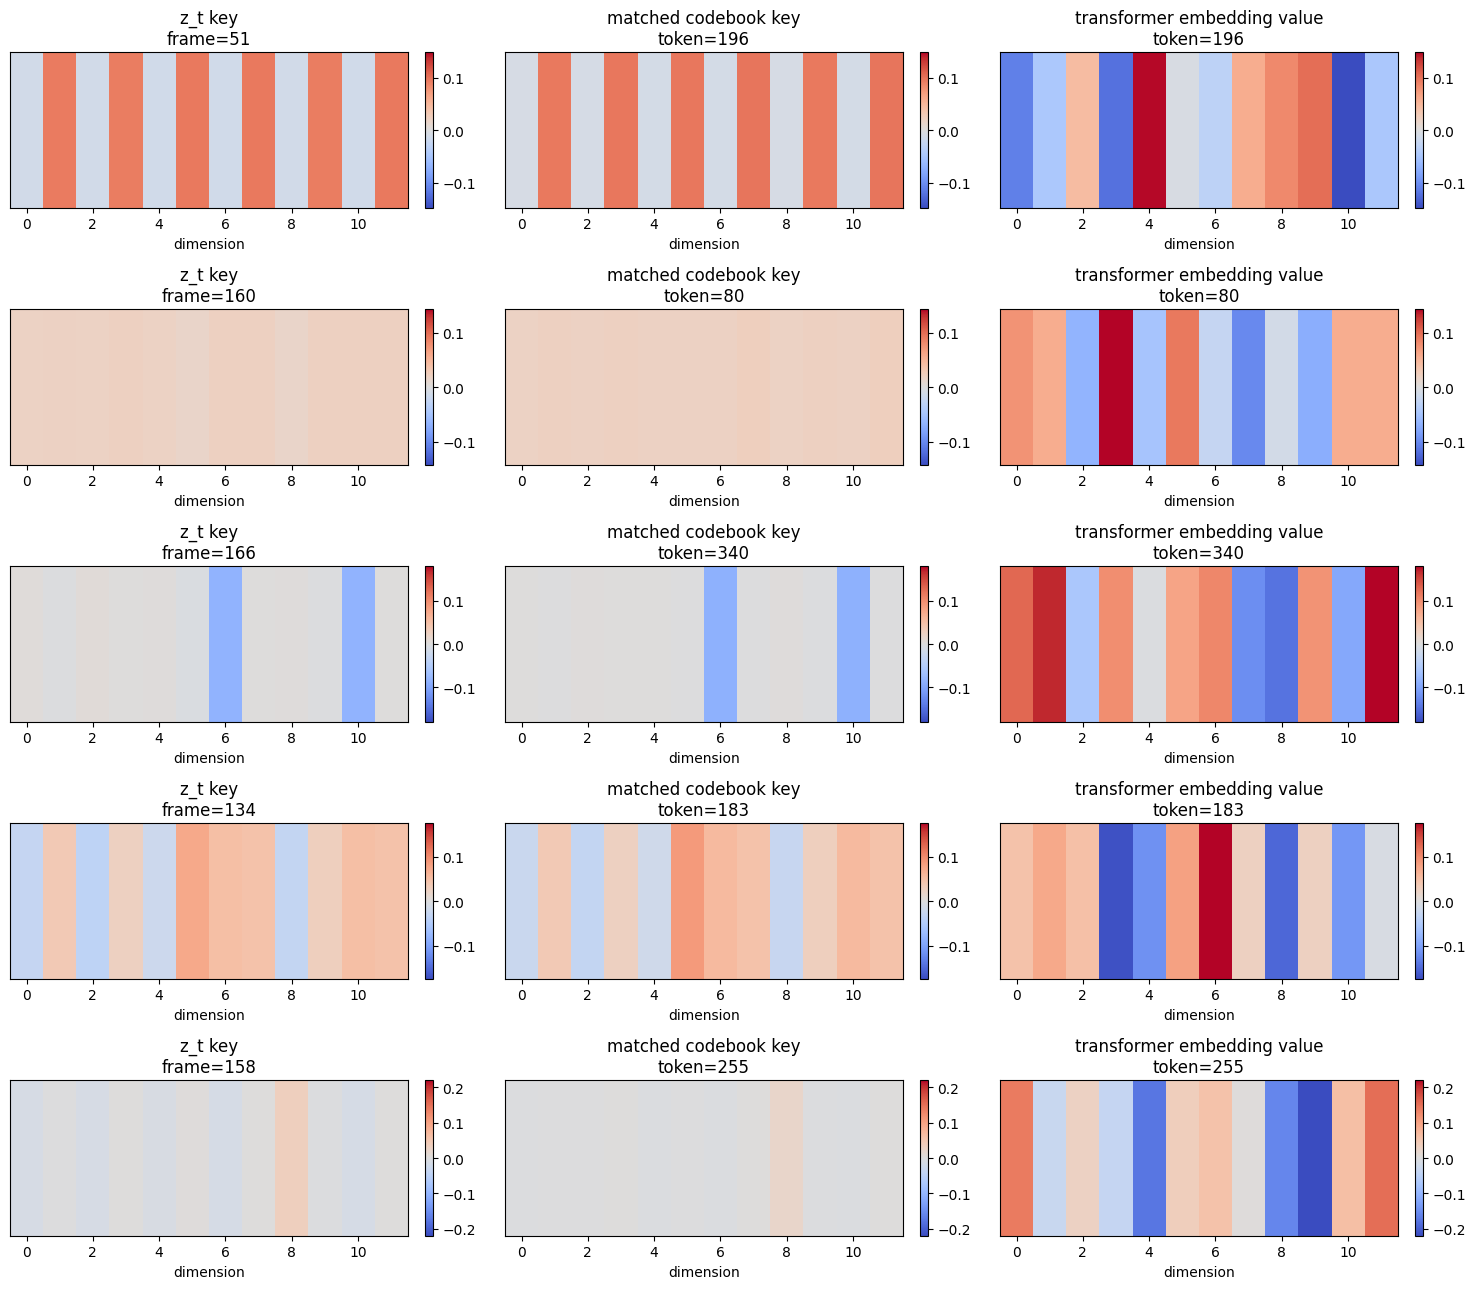

,episode_id,prev_frame,frame,motion_token_id,token_distance,n_bg_points
0,7,39,51,196,0.011156,121
1,9,146,160,80,0.007371,122
2,7,154,166,340,0.007677,122
3,4,120,134,183,0.018570,124
4,0,145,158,255,0.024601,123


In [204]:
## Action Inference Rollout - z_t to Token to Transformer Embedding Visualization

N_EXAMPLES = 5

sample_df = rollout_token_df.sample(
    min(N_EXAMPLES, len(rollout_token_df)),
    random_state=None,
).reset_index(drop=True)

motion_codebook_keys = np.asarray(action_embedding_table, dtype=np.float32)
transformer_embedding_values = model.wte.weight.detach().cpu().numpy().astype(np.float32)

fig, axes = plt.subplots(len(sample_df), 3, figsize=(15, 2.6 * len(sample_df)))

if len(sample_df) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, row) in enumerate(sample_df.iterrows()):
    token_id = int(row["motion_token_id"])

    z_t_key = np.asarray(row["z_t"], dtype=np.float32)
    matched_codebook_key = motion_codebook_keys[token_id]
    transformer_embedding = transformer_embedding_values[token_id]

    key_error = z_t_key - matched_codebook_key

    shared_abs = max(
        float(np.max(np.abs(z_t_key))),
        float(np.max(np.abs(matched_codebook_key))),
        float(np.max(np.abs(transformer_embedding))),
        1e-8,
    )

    panels = [
        (z_t_key, f"z_t key\nframe={int(row['frame'])}"),
        (matched_codebook_key, f"matched codebook key\ntoken={token_id}"),
        (transformer_embedding, f"transformer embedding value\ntoken={token_id}"),
    ]

    for ax, (vec, title) in zip(axes[row_idx], panels):
        im = ax.imshow(
            vec.reshape(1, -1),
            cmap="coolwarm",
            aspect="auto",
            vmin=-shared_abs,
            vmax=shared_abs,
        )
        ax.set_title(title)
        ax.set_xlabel("dimension")
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

display(
    sample_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "motion_token_id",
            "token_distance",
            "n_bg_points",
        ]
    ]
)

## Predict z_next with Motion Transformer

In [205]:
## Predict z_next with Motion Transformer

if "seq_len" not in globals():
    if "DECONSTRUCTION_SEQ_LEN" in globals():
        seq_len = DECONSTRUCTION_SEQ_LEN
    else:
        seq_len = 8

if "device" not in globals():
    device = DEVICE if "DEVICE" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()

rollout_z_next_pred_rows = []

for episode_id, episode_df in rollout_token_df.groupby("episode_id"):
    episode_df = episode_df.sort_values("frame").reset_index(drop=True)

    token_ids = episode_df["motion_token_id"].to_numpy(dtype=np.int64)

    for row_idx in range(len(episode_df)):
        context_start = max(0, row_idx - seq_len + 1)
        context_token_ids = token_ids[context_start:row_idx + 1]

        x_context = torch.tensor(
            context_token_ids[None, :],
            dtype=torch.long,
            device=device,
        )

        with torch.no_grad():
            z_next_pred = (
                model(x_context)[0, -1]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

        row = episode_df.iloc[row_idx].to_dict()
        row["context_len"] = int(len(context_token_ids))
        row["z_next_pred"] = z_next_pred
        row["z_next_pred_dim"] = int(len(z_next_pred))

        rollout_z_next_pred_rows.append(row)

rollout_z_next_pred_df = pd.DataFrame(rollout_z_next_pred_rows)

print("seq_len:", seq_len)
print("rollout_z_next_pred_df shape:", rollout_z_next_pred_df.shape)
print("episodes:", rollout_z_next_pred_df["episode_id"].nunique())
print(
    "z_next_pred dim:",
    rollout_z_next_pred_df["z_next_pred_dim"].iloc[0]
    if len(rollout_z_next_pred_df)
    else None,
)

display(
    rollout_z_next_pred_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "motion_token_id",
            "context_len",
            "z_next_pred_dim",
        ]
    ].head(20)
)

seq_len: 16
rollout_z_next_pred_df shape: (741, 12)
episodes: 10
z_next_pred dim: 12


,episode_id,prev_frame,frame,motion_token_id,context_len,z_next_pred_dim
0,0,0,12,91,1,12
1,0,2,15,341,2,12
2,0,5,17,205,3,12
3,0,7,20,206,4,12
4,0,10,23,342,5,12
5,0,12,25,208,6,12
6,0,15,28,210,7,12
7,0,17,30,211,8,12
8,0,20,33,212,9,12
9,0,23,35,316,10,12


## Visualize z_t

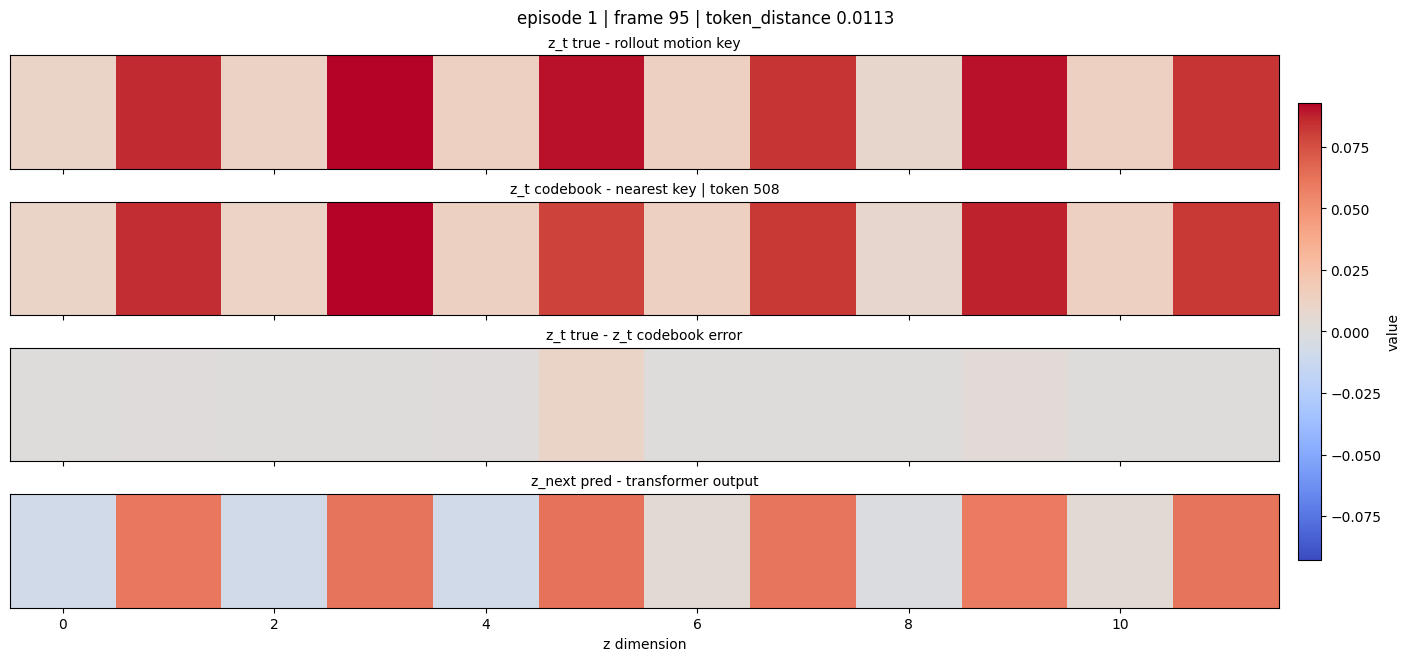

,z_dim,z_t_true,z_t_codebook,z_t_error,z_next_pred
0,0,0.010764,0.010542,0.000222,-0.007441
1,1,0.085957,0.085094,0.000863,0.060345
2,2,0.011686,0.011583,0.000103,-0.008078
3,3,0.092732,0.092311,0.000420,0.062103
4,4,0.013356,0.012613,0.000743,-0.007303
5,5,0.090226,0.079442,0.010783,0.062497
6,6,0.013356,0.013093,0.000262,0.003863
7,7,0.082707,0.081989,0.000718,0.061545
8,8,0.008347,0.007672,0.000675,-0.002173
9,9,0.090226,0.087205,0.003021,0.058797


In [206]:
## Visualize z_t True, z_t Codebook, z_next Pred

sample_row = rollout_z_next_pred_df.sample(1, random_state=None).iloc[0]

z_t_true = np.asarray(sample_row["z_t"], dtype=np.float32)
motion_token_id = int(sample_row["motion_token_id"])
z_t_cp = np.asarray(action_embedding_table[motion_token_id], dtype=np.float32)
z_next_pred = np.asarray(sample_row["z_next_pred"], dtype=np.float32)

z_t_error = z_t_true - z_t_cp

z_shared_abs = max(
    float(np.max(np.abs(z_t_true))),
    float(np.max(np.abs(z_t_cp))),
    float(np.max(np.abs(z_next_pred))),
    1e-8,
)

fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 6.5),
    sharex=True,
    constrained_layout=True,
)

items = [
    ("z_t true - rollout motion key", z_t_true),
    (f"z_t codebook - nearest key | token {motion_token_id}", z_t_cp),
    ("z_t true - z_t codebook error", z_t_error),
    ("z_next pred - transformer output", z_next_pred),
]

for ax, (title, z) in zip(axes, items):
    im = ax.imshow(
        z.reshape(1, -1),
        cmap="coolwarm",
        aspect="auto",
        interpolation="nearest",
        vmin=-z_shared_abs,
        vmax=z_shared_abs,
    )
    ax.set_title(title, fontsize=10)
    ax.set_yticks([])
    ax.grid(False)

axes[-1].set_xlabel("z dimension")

fig.colorbar(
    im,
    ax=axes,
    fraction=0.018,
    pad=0.015,
    label="value",
)

fig.suptitle(
    f"episode {int(sample_row['episode_id'])} | "
    f"frame {int(sample_row['frame'])} | "
    f"token_distance {float(sample_row['token_distance']):.4f}",
    fontsize=12,
)

plt.show()

display(
    pd.DataFrame(
        {
            "z_dim": np.arange(len(z_t_true)),
            "z_t_true": z_t_true,
            "z_t_codebook": z_t_cp,
            "z_t_error": z_t_error,
            "z_next_pred": z_next_pred,
        }
    )
)

## Predict Actions from z_next_pred

In [207]:
## Predict Actions from z_next_pred

action_inference_model.eval()

X_next = np.stack(
    rollout_z_next_pred_df["z_next_pred"].to_numpy()
).astype(np.float32)

X_next_t = torch.tensor(
    X_next,
    dtype=torch.float32,
    device=DEVICE,
)

with torch.no_grad():
    action_next_pred = (
        action_inference_model(X_next_t)
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

rollout_action_next_df = rollout_z_next_pred_df.copy()

rollout_action_next_df["action_main_pred"] = action_next_pred[:, 0]
rollout_action_next_df["action_side_pred"] = action_next_pred[:, 1]

rollout_action_next_df["action_pred"] = [
    np.array([main, side], dtype=np.float32)
    for main, side in zip(
        rollout_action_next_df["action_main_pred"],
        rollout_action_next_df["action_side_pred"],
    )
]

print("rollout_action_next_df shape:", rollout_action_next_df.shape)
print("episodes:", rollout_action_next_df["episode_id"].nunique())

display(
    rollout_action_next_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "motion_token_id",
            "context_len",
            "action_main_pred",
            "action_side_pred",
        ]
    ].head(20)
)

rollout_action_next_df shape: (741, 15)
episodes: 10


,episode_id,prev_frame,frame,motion_token_id,context_len,action_main_pred,action_side_pred
0,0,0,12,91,1,-0.645735,-0.875951
1,0,2,15,341,2,-0.003770,-0.410066
2,0,5,17,205,3,-0.415353,0.033938
3,0,7,20,206,4,-0.710581,0.366395
4,0,10,23,342,5,-0.539072,0.061547
5,0,12,25,208,6,-0.876606,0.424514
6,0,15,28,210,7,-0.814827,-0.218102
7,0,17,30,211,8,-0.935673,0.699325
8,0,20,33,212,9,-0.944792,0.693243
9,0,23,35,316,10,-0.940011,0.683443


# Env Action Inference Model

1. Setup
2. Frame Capture
3. Extract CP
4. Extract Background Points
5. Build z_t
6. Map z_t to Motion Token
7. Predict z_next
8. Predict Action
9. Closed-Loop Run
10. Review Video
11. Rewards Summary

## Setup

In [223]:
## Hyper Params

ENV_NAME = "LunarLanderContinuous-v3"

ENV_N_EPISODES = 3
ENV_MAX_STEPS = 600
ENV_SEED = 42

ENV_BOOTSTRAP_ACTION = np.array([0.0, 0.0], dtype=np.float32)

ENV_FRAME_SAMPLE_STEP = None  # inferred below from train video sampling if None

ENV_BG_STEP = BACKGROUND_GRID_STEP if "BACKGROUND_GRID_STEP" in globals() else 40
ENV_BG_MARGIN = BACKGROUND_GRID_MARGIN if "BACKGROUND_GRID_MARGIN" in globals() else 20
ENV_BG_Y_START_RATIO = BACKGROUND_Y_START_RATIO if "BACKGROUND_Y_START_RATIO" in globals() else 0.0

ENV_ACTION_CLIP_LOW = -1.0
ENV_ACTION_CLIP_HIGH = 1.0

ENV_SAVE_FRAMES = True
ENV_SAVE_REVIEW_VIDEO = True
ENV_REVIEW_VIDEO_FPS = 30

print("ENV_NAME:", ENV_NAME)
print("ENV_N_EPISODES:", ENV_N_EPISODES)
print("ENV_MAX_STEPS:", ENV_MAX_STEPS)
print("ENV_SEED:", ENV_SEED)
print("ENV_FRAME_SAMPLE_STEP:", ENV_FRAME_SAMPLE_STEP)
print("ENV_BG_STEP:", ENV_BG_STEP)
print("ENV_BG_MARGIN:", ENV_BG_MARGIN)
print("ENV_BG_Y_START_RATIO:", ENV_BG_Y_START_RATIO)

ENV_NAME: LunarLanderContinuous-v3
ENV_N_EPISODES: 3
ENV_MAX_STEPS: 600
ENV_SEED: 42
ENV_FRAME_SAMPLE_STEP: None
ENV_BG_STEP: 40
ENV_BG_MARGIN: 20
ENV_BG_Y_START_RATIO: 0


## Frame Capture

Testing seq_len for each function

ENV_FRAME_SAMPLE_STEP: 2
seq_len: 16
MOTION_STRIDE: 5
probe sampled frames: (21, 400, 600, 3)
probe env steps: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
FRAME_WIDTH: 600
FRAME_HEIGHT: 400


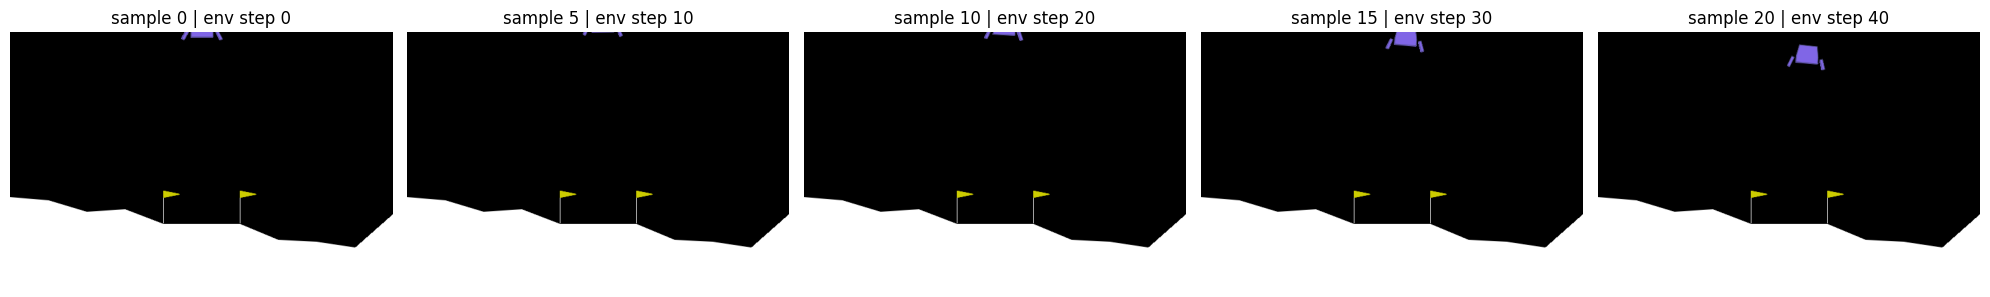

In [224]:
## Frame Capture

def make_lunar_env():
    try:
        return gym.make(
            ENV_NAME,
            continuous=True,
            render_mode="rgb_array",
        )
    except TypeError:
        return gym.make(
            ENV_NAME,
            render_mode="rgb_array",
        )


def reset_lunar_env(env, seed=None):
    out = env.reset(seed=seed)

    if isinstance(out, tuple):
        obs, info = out
        return obs, info

    return out, {}


def step_lunar_env(env, action):
    out = env.step(action)

    if len(out) == 5:
        obs, reward, terminated, truncated, info = out
        done = bool(terminated or truncated)
    else:
        obs, reward, done, info = out

    return obs, float(reward), bool(done), info


def capture_lunar_frame(env):
    frame = env.render()

    if frame is None:
        raise RuntimeError("env.render() returned None. Check render_mode='rgb_array'.")

    return np.asarray(frame).copy()


def infer_env_frame_sample_step():
    if "lunar_video_paths" in globals() and len(lunar_video_paths):
        _, train_frame_indices = read_video_even(
            lunar_video_paths[0],
            max_frames=MAX_FRAMES_PER_EPISODE,
            return_indices=True,
        )

        diffs = np.diff(train_frame_indices)

        if len(diffs):
            return max(1, int(round(float(np.median(diffs)))))

    return 2


ENV_FRAME_SAMPLE_STEP = infer_env_frame_sample_step()


def capture_probe_frame_sequence(
    n_motion_tokens,
    motion_stride=MOTION_STRIDE,
    frame_sample_step=ENV_FRAME_SAMPLE_STEP,
    seed=ENV_SEED,
    bootstrap_action=None,
):
    if bootstrap_action is None:
        bootstrap_action = np.array([0.0, 0.0], dtype=np.float32)

    n_sampled_frames_needed = n_motion_tokens + motion_stride

    env = make_lunar_env()
    obs, info = reset_lunar_env(env, seed=seed)

    sampled_frames = []
    sampled_env_steps = []
    rewards = []
    dones = []

    raw_step = 0

    while len(sampled_frames) < n_sampled_frames_needed:
        frame = capture_lunar_frame(env)

        if raw_step % frame_sample_step == 0:
            sampled_frames.append(frame)
            sampled_env_steps.append(raw_step)

        obs, reward, done, info = step_lunar_env(env, bootstrap_action)

        rewards.append(reward)
        dones.append(done)

        raw_step += 1

        if done:
            break

    env.close()

    return {
        "frames": np.stack(sampled_frames),
        "frame_indices": np.asarray(sampled_env_steps, dtype=np.int64),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=bool),
        "frame_sample_step": int(frame_sample_step),
    }


probe_sequence = capture_probe_frame_sequence(
    n_motion_tokens=seq_len,
    motion_stride=MOTION_STRIDE,
    frame_sample_step=ENV_FRAME_SAMPLE_STEP,
    seed=ENV_SEED,
)

probe_frames = probe_sequence["frames"]
probe_frame_indices = probe_sequence["frame_indices"]

FRAME_HEIGHT, FRAME_WIDTH = probe_frames[0].shape[:2]

print("ENV_FRAME_SAMPLE_STEP:", ENV_FRAME_SAMPLE_STEP)
print("seq_len:", seq_len)
print("MOTION_STRIDE:", MOTION_STRIDE)
print("probe sampled frames:", probe_frames.shape)
print("probe env steps:", probe_frame_indices.tolist())
print("FRAME_WIDTH:", FRAME_WIDTH)
print("FRAME_HEIGHT:", FRAME_HEIGHT)

n_show = min(5, len(probe_frames))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4), squeeze=False)
axes = axes.ravel()

show_positions = np.linspace(0, len(probe_frames) - 1, n_show).astype(int)

for ax, pos in zip(axes, show_positions):
    ax.imshow(probe_frames[pos])
    ax.set_title(f"sample {pos} | env step {int(probe_frame_indices[pos])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Extract CP

probe_cp_df shape: (126, 6)
frames with CP: 21
expected frames: 21
point names: ['axis_back', 'axis_front', 'axis_left', 'axis_right', 'centroid', 'contact_low']


,episode_id,frame,track_id,point_name,x,y
0,0,0,0,centroid,299.444223,4.384462
1,0,0,0,axis_front,268.000000,9.000000
2,0,0,0,axis_back,332.000000,9.000000
3,0,0,0,axis_left,271.000000,12.000000
4,0,0,0,axis_right,272.000000,0.000000
5,0,0,0,contact_low,271.000000,12.000000
6,0,2,0,centroid,308.650519,2.965398
7,0,2,0,axis_front,284.000000,3.000000
8,0,2,0,axis_back,333.000000,7.000000
9,0,2,0,axis_left,329.000000,10.000000


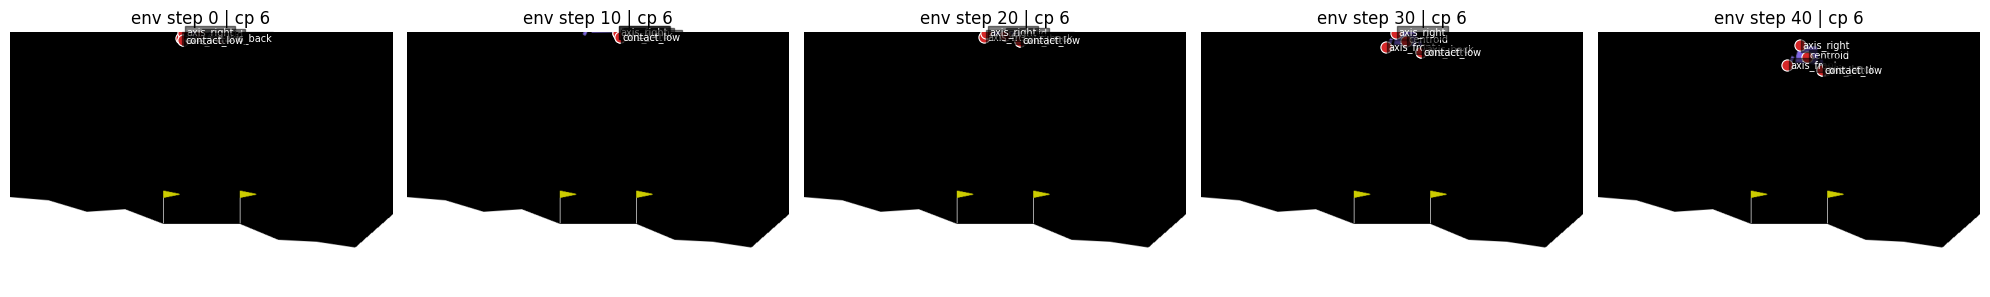

In [226]:
## Extract CP

def extract_env_cp_df(frame, episode_id, frame_id):
    records = active_agent_records(frame)

    if len(records) == 0:
        return pd.DataFrame(
            columns=[
                "episode_id",
                "frame",
                "track_id",
                "point_name",
                "x",
                "y",
            ]
        )

    record = max(
        records,
        key=lambda r: float(np.sum(r["mask"])) if "mask" in r else 0.0,
    )

    cp_records = control_points_from_record(record)
    cp_df = pd.DataFrame(cp_records).copy()

    if len(cp_df) == 0:
        return pd.DataFrame(
            columns=[
                "episode_id",
                "frame",
                "track_id",
                "point_name",
                "x",
                "y",
            ]
        )

    cp_df["episode_id"] = int(episode_id)
    cp_df["frame"] = int(frame_id)
    cp_df["track_id"] = 0

    keep_cols = [
        "episode_id",
        "frame",
        "track_id",
        "point_name",
        "x",
        "y",
    ]

    return cp_df[keep_cols].copy()


probe_cp_dfs = []

for frame, frame_id in zip(probe_frames, probe_frame_indices):
    cp_df = extract_env_cp_df(
        frame,
        episode_id=0,
        frame_id=int(frame_id),
    )

    probe_cp_dfs.append(cp_df)

probe_cp_df = (
    pd.concat(probe_cp_dfs, ignore_index=True)
    if len(probe_cp_dfs)
    else pd.DataFrame()
)

print("probe_cp_df shape:", probe_cp_df.shape)
print("frames with CP:", probe_cp_df["frame"].nunique() if len(probe_cp_df) else 0)
print("expected frames:", len(probe_frame_indices))
print("point names:", sorted(probe_cp_df["point_name"].unique()) if len(probe_cp_df) else [])

display(probe_cp_df.head(30))


n_show = min(5, len(probe_frames))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4), squeeze=False)
axes = axes.ravel()

show_positions = np.linspace(0, len(probe_frames) - 1, n_show).astype(int)

for ax, pos in zip(axes, show_positions):
    frame = probe_frames[pos]
    frame_id = int(probe_frame_indices[pos])

    frame_cp = probe_cp_df[
        probe_cp_df["frame"] == frame_id
    ].copy()

    ax.imshow(frame)

    if len(frame_cp):
        ax.scatter(
            frame_cp["x"],
            frame_cp["y"],
            s=65,
            c="tab:red",
            edgecolors="white",
            linewidths=0.8,
            zorder=3,
        )

        for _, row in frame_cp.iterrows():
            ax.text(
                row["x"] + 4,
                row["y"] + 4,
                row["point_name"],
                fontsize=7,
                color="white",
                bbox=dict(facecolor="black", alpha=0.5, pad=1),
                zorder=4,
            )

    ax.set_title(f"env step {frame_id} | cp {len(frame_cp)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Exctract Background Points

probe_bckg_df shape: (2646, 5)
background ids: 126
points per frame:


frame
0     126
2     126
4     126
6     126
8     126
10    126
12    126
14    126
16    126
18    126
20    126
22    126
24    126
26    126
28    126
30    126
32    126
34    126
36    126
38    126
dtype: int64

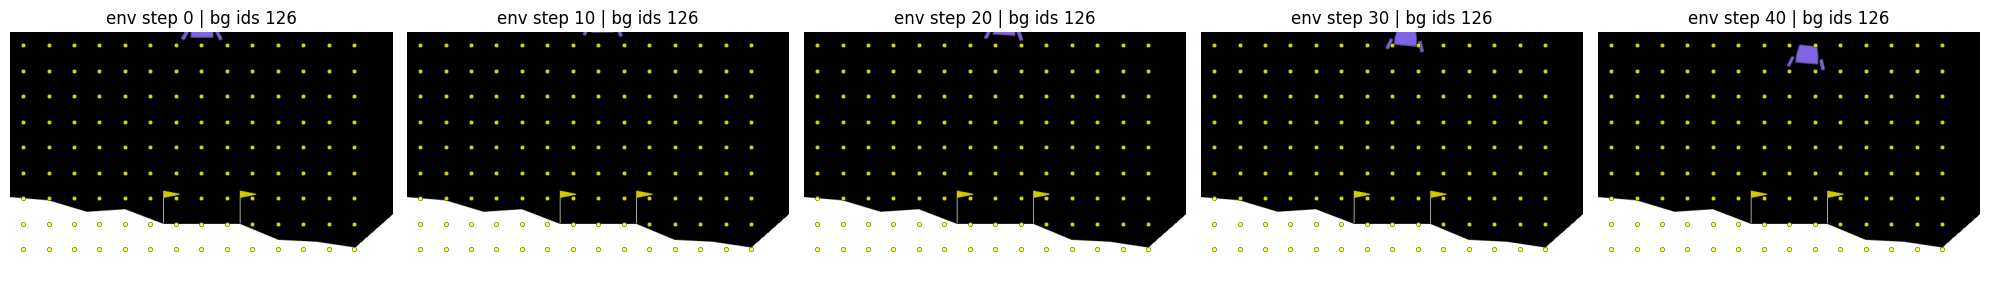

In [227]:
## Extract Background Points

def env_agent_inverse_mask(frame, records):
    active_mask = np.zeros(frame.shape[:2], dtype=bool)

    for record in records:
        if "mask" in record:
            active_mask |= record["mask"].astype(bool)

    background_mask = ~active_mask

    return background_mask, active_mask


def env_lower_base_mask(frame, background_mask, y_start_ratio=0.0):
    h, w = frame.shape[:2]

    lower = np.zeros((h, w), dtype=bool)
    lower[int(h * y_start_ratio):, :] = True

    return background_mask & lower


def env_make_base_grid_points(base_mask, step=40, margin=20):
    h, w = base_mask.shape
    points = []

    for y in range(margin, h - margin, step):
        for x in range(margin, w - margin, step):
            if base_mask[y, x]:
                points.append((x, y))

    return np.asarray(points, dtype=np.float32)


def extract_env_background_points(frame):
    records = active_agent_records(frame)

    background_mask, active_mask = env_agent_inverse_mask(
        frame,
        records,
    )

    base_mask = env_lower_base_mask(
        frame,
        background_mask,
        y_start_ratio=ENV_BG_Y_START_RATIO,
    )

    points = env_make_base_grid_points(
        base_mask,
        step=ENV_BG_STEP,
        margin=ENV_BG_MARGIN,
    )

    return points.astype(np.float32), base_mask, active_mask


def env_background_points_to_df(points, episode_id, frame_id):
    return pd.DataFrame(
        {
            "episode_id": int(episode_id),
            "frame": int(frame_id),
            "background_point_id": np.arange(len(points), dtype=np.int64),
            "x": points[:, 0].astype(np.float32),
            "y": points[:, 1].astype(np.float32),
        }
    )


bg_points_probe, bg_base_mask_probe, bg_active_mask_probe = extract_env_background_points(
    probe_frames[0]
)

probe_bckg_dfs = []

for frame_id in probe_frame_indices:
    bckg_df = env_background_points_to_df(
        bg_points_probe,
        episode_id=0,
        frame_id=int(frame_id),
    )

    probe_bckg_dfs.append(bckg_df)

probe_bckg_df = pd.concat(probe_bckg_dfs, ignore_index=True)

print("probe_bckg_df shape:", probe_bckg_df.shape)
print("background ids:", probe_bckg_df["background_point_id"].nunique())
print("points per frame:")
display(probe_bckg_df.groupby("frame").size().head(20))


n_show = min(5, len(probe_frames))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4), squeeze=False)
axes = axes.ravel()

show_positions = np.linspace(0, len(probe_frames) - 1, n_show).astype(int)

for ax, pos in zip(axes, show_positions):
    frame = probe_frames[pos].copy()
    frame_id = int(probe_frame_indices[pos])

    frame_bckg = probe_bckg_df[
        probe_bckg_df["frame"] == frame_id
    ].copy()

    ax.imshow(frame)

    ax.scatter(
        frame_bckg["x"],
        frame_bckg["y"],
        s=10,
        c="yellow",
        edgecolors="black",
        linewidths=0.3,
        alpha=0.85,
    )

    ax.set_title(f"env step {frame_id} | bg ids {len(frame_bckg)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Build z_t

probe_z_df shape: (16, 5)
z dim: 12


,episode_id,prev_frame,frame,z_t,z_dim
0,0,0,10,"[0.01001668, -0.012531325, 0.10517529, -0.0225...",12
1,0,2,12,"[0.01001668, -0.007518783, 0.08013356, -0.0075...",12
2,0,4,14,"[0.033388972, 0.01253134, 0.01001668, 0.0, 0.0...",12
3,0,6,16,"[0.01001668, 0.0, 0.011686146, 0.0, 0.02838063...",12
4,0,8,18,"[0.031719506, 0.020050123, 0.011686146, 0.0, 0...",12
5,0,10,20,"[0.008347273, 0.015037596, -0.08013353, 0.0175...",12
6,0,12,22,"[0.008347213, 0.020050123, -0.07846412, 0.0225...",12
7,0,14,24,"[0.008347213, 0.02506265, -0.01001668, 0.03007...",12
8,0,16,26,"[0.031719565, 0.05263158, -0.011686146, 0.0401...",12
9,0,18,28,"[0.01001668, 0.03759399, -0.01001671, 0.047619...",12


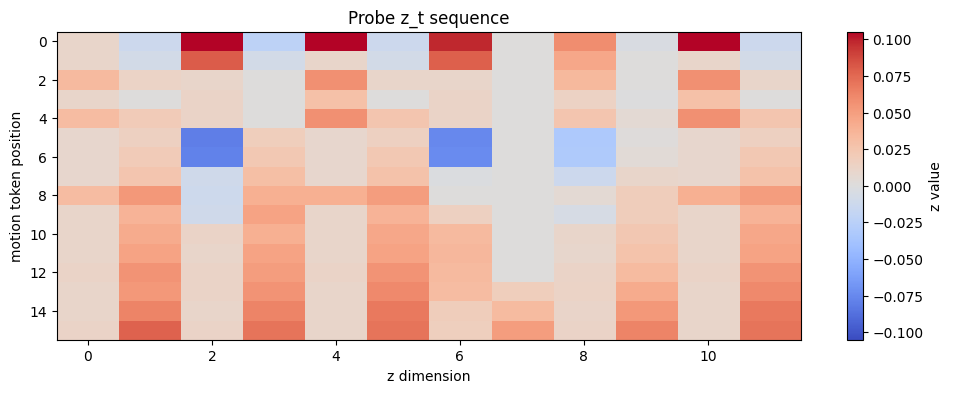

In [230]:
## Build z_t

def build_env_z_t_from_dfs(prev_cp, curr_cp, prev_bg, curr_bg):
    prev_cp = prev_cp.sort_values("point_name").copy()
    curr_cp = curr_cp.sort_values("point_name").copy()

    prev_bg = prev_bg.sort_values("background_point_id").copy()
    curr_bg = curr_bg.sort_values("background_point_id").copy()

    common_bg_ids = sorted(
        set(prev_bg["background_point_id"])
        & set(curr_bg["background_point_id"])
    )

    if len(common_bg_ids) == 0:
        return None

    prev_bg = prev_bg[
        prev_bg["background_point_id"].isin(common_bg_ids)
    ].copy()

    curr_bg = curr_bg[
        curr_bg["background_point_id"].isin(common_bg_ids)
    ].copy()

    common_cp_names = sorted(
        set(prev_cp["point_name"])
        & set(curr_cp["point_name"])
    )

    if len(common_cp_names) == 0:
        return None

    prev_cp = prev_cp[
        prev_cp["point_name"].isin(common_cp_names)
    ].copy()

    curr_cp = curr_cp[
        curr_cp["point_name"].isin(common_cp_names)
    ].copy()

    prev_cp = prev_cp.sort_values("point_name").copy()
    curr_cp = curr_cp.sort_values("point_name").copy()

    motion_key = build_motion_key(
        prev_cp,
        curr_cp,
        prev_bg,
        curr_bg,
    )

    z_t = encode_motion_key(motion_key).astype(np.float32)

    return z_t


probe_z_rows = []

probe_frames_available = sorted(
    set(probe_cp_df["frame"].unique())
    & set(probe_bckg_df["frame"].unique())
)

for frame_idx in range(MOTION_STRIDE, len(probe_frames_available)):
    prev_frame = int(probe_frames_available[frame_idx - MOTION_STRIDE])
    frame = int(probe_frames_available[frame_idx])

    prev_cp = probe_cp_df[
        probe_cp_df["frame"] == prev_frame
    ].copy()

    curr_cp = probe_cp_df[
        probe_cp_df["frame"] == frame
    ].copy()

    prev_bg = probe_bckg_df[
        probe_bckg_df["frame"] == prev_frame
    ].copy()

    curr_bg = probe_bckg_df[
        probe_bckg_df["frame"] == frame
    ].copy()

    z_t = build_env_z_t_from_dfs(
        prev_cp,
        curr_cp,
        prev_bg,
        curr_bg,
    )

    if z_t is None:
        continue

    probe_z_rows.append(
        {
            "episode_id": 0,
            "prev_frame": prev_frame,
            "frame": frame,
            "z_t": z_t,
            "z_dim": int(len(z_t)),
        }
    )

probe_z_df = pd.DataFrame(probe_z_rows)

print("probe_z_df shape:", probe_z_df.shape)
print("z dim:", probe_z_df["z_dim"].iloc[0] if len(probe_z_df) else None)

display(probe_z_df.head(20))


if len(probe_z_df):
    z_matrix = np.stack(probe_z_df["z_t"].to_numpy()).astype(np.float32)
    z_abs = max(float(np.max(np.abs(z_matrix))), 1e-8)

    plt.figure(figsize=(12, 4))
    plt.imshow(
        z_matrix,
        cmap="coolwarm",
        aspect="auto",
        interpolation="nearest",
        vmin=-z_abs,
        vmax=z_abs,
    )
    plt.colorbar(label="z value")
    plt.title("Probe z_t sequence")
    plt.xlabel("z dimension")
    plt.ylabel("motion token position")
    plt.show()

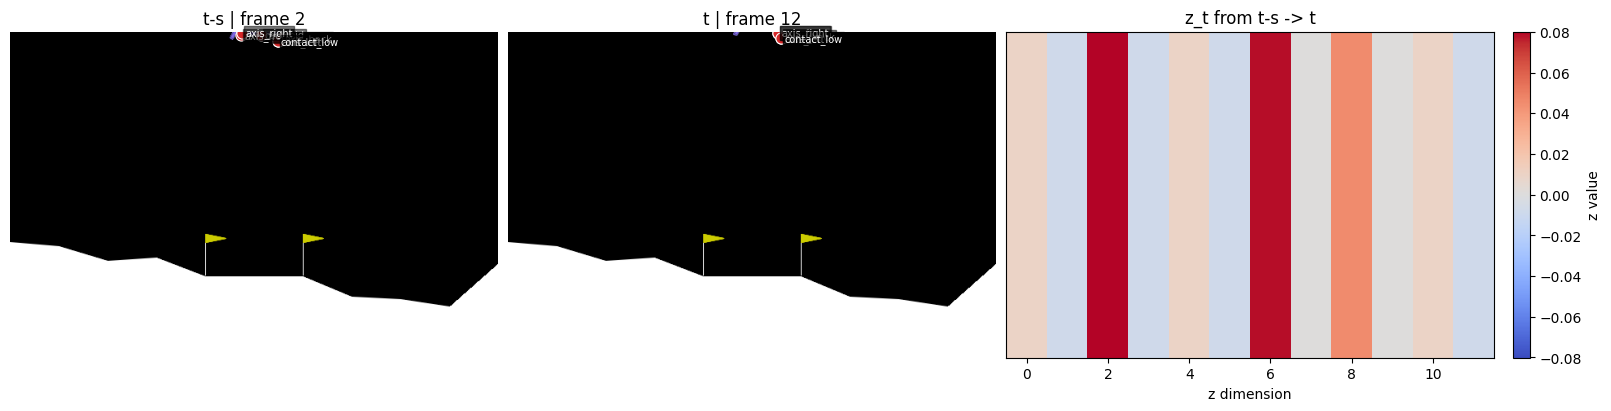

,z_dim,z_t
0,0,0.010017
1,1,-0.007519
2,2,0.080134
3,3,-0.007519
4,4,0.010017
5,5,-0.007519
6,6,0.078464
7,7,0.000000
8,8,0.045172
9,9,0.000504


In [231]:
## Build z_t - Visual Check

if len(probe_z_df) == 0:
    raise ValueError("probe_z_df is empty. Run Build z_t first.")

sample_row = probe_z_df.sample(1, random_state=None).iloc[0]

prev_frame = int(sample_row["prev_frame"])
frame = int(sample_row["frame"])
z_t = np.asarray(sample_row["z_t"], dtype=np.float32)

frame_to_image = {
    int(frame_id): image
    for image, frame_id in zip(probe_frames, probe_frame_indices)
}

prev_image = frame_to_image[prev_frame]
curr_image = frame_to_image[frame]

prev_cp = probe_cp_df[
    probe_cp_df["frame"] == prev_frame
].copy()

curr_cp = probe_cp_df[
    probe_cp_df["frame"] == frame
].copy()

z_abs = max(float(np.max(np.abs(z_t))), 1e-8)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
    constrained_layout=True,
)

for ax, image, cp_df, title in [
    (axes[0], prev_image, prev_cp, f"t-s | frame {prev_frame}"),
    (axes[1], curr_image, curr_cp, f"t | frame {frame}"),
]:
    ax.imshow(image)

    if len(cp_df):
        ax.scatter(
            cp_df["x"],
            cp_df["y"],
            s=65,
            c="tab:red",
            edgecolors="white",
            linewidths=0.8,
            zorder=3,
        )

        for _, row in cp_df.iterrows():
            ax.text(
                row["x"] + 4,
                row["y"] + 4,
                row["point_name"],
                fontsize=7,
                color="white",
                bbox=dict(facecolor="black", alpha=0.5, pad=1),
                zorder=4,
            )

    ax.set_title(title)
    ax.axis("off")

im = axes[2].imshow(
    z_t.reshape(1, -1),
    cmap="coolwarm",
    aspect="auto",
    interpolation="nearest",
    vmin=-z_abs,
    vmax=z_abs,
)

axes[2].set_title("z_t from t-s -> t")
axes[2].set_xlabel("z dimension")
axes[2].set_yticks([])

fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="z value")

plt.show()

display(
    pd.DataFrame(
        {
            "z_dim": np.arange(len(z_t)),
            "z_t": z_t,
        }
    )
)

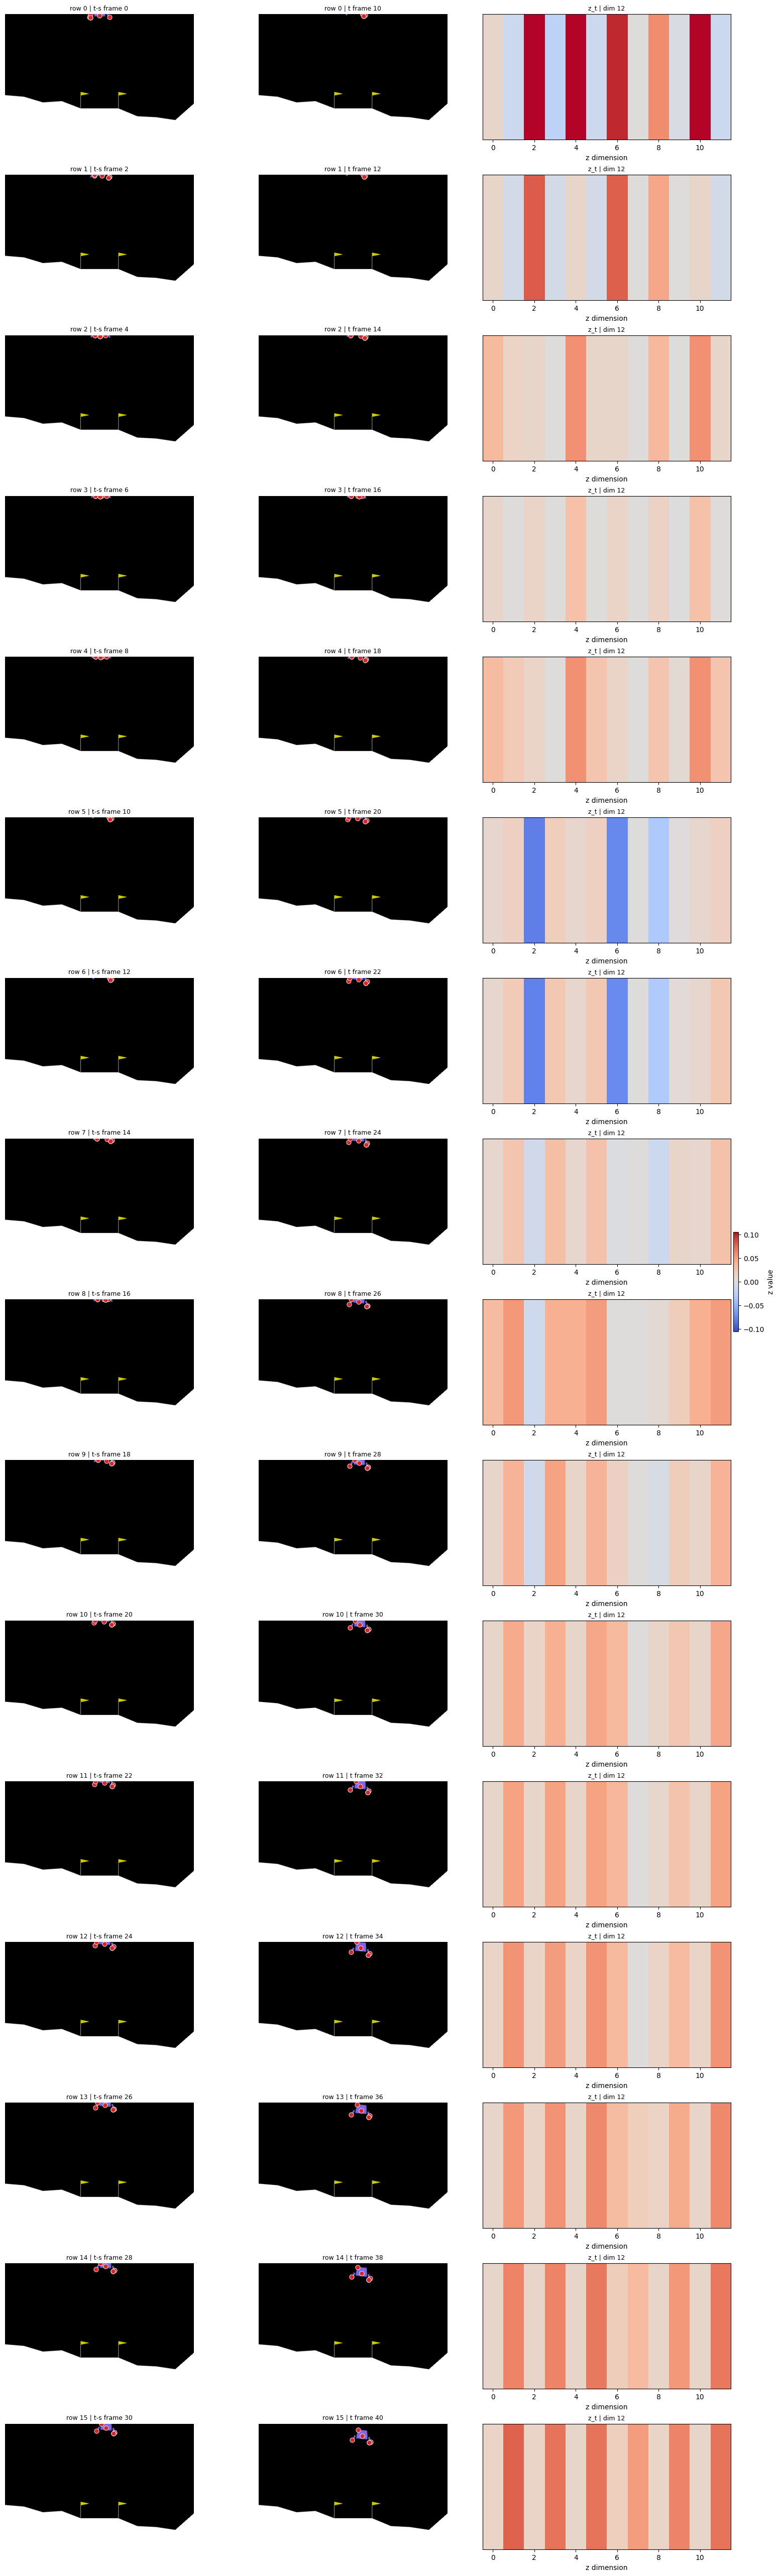

,episode_id,prev_frame,frame,z_dim
0,0,0,10,12
1,0,2,12,12
2,0,4,14,12
3,0,6,16,12
4,0,8,18,12
5,0,10,20,12
6,0,12,22,12
7,0,14,24,12
8,0,16,26,12
9,0,18,28,12


In [232]:
## Build z_t - Visual Check for Full Probe Sequence

if len(probe_z_df) == 0:
    raise ValueError("probe_z_df is empty. Run Build z_t first.")

frame_to_image = {
    int(frame_id): image
    for image, frame_id in zip(probe_frames, probe_frame_indices)
}

n_rows = len(probe_z_df)

fig, axes = plt.subplots(
    n_rows,
    3,
    figsize=(16, 3.2 * n_rows),
    squeeze=False,
    constrained_layout=True,
)

all_z = np.stack(probe_z_df["z_t"].to_numpy()).astype(np.float32)
z_abs = max(float(np.max(np.abs(all_z))), 1e-8)

for row_idx, (_, sample_row) in enumerate(probe_z_df.iterrows()):
    prev_frame = int(sample_row["prev_frame"])
    frame = int(sample_row["frame"])
    z_t = np.asarray(sample_row["z_t"], dtype=np.float32)

    prev_image = frame_to_image[prev_frame]
    curr_image = frame_to_image[frame]

    prev_cp = probe_cp_df[
        probe_cp_df["frame"] == prev_frame
    ].copy()

    curr_cp = probe_cp_df[
        probe_cp_df["frame"] == frame
    ].copy()

    for ax, image, cp_df, title in [
        (
            axes[row_idx, 0],
            prev_image,
            prev_cp,
            f"row {row_idx} | t-s frame {prev_frame}",
        ),
        (
            axes[row_idx, 1],
            curr_image,
            curr_cp,
            f"row {row_idx} | t frame {frame}",
        ),
    ]:
        ax.imshow(image)

        if len(cp_df):
            ax.scatter(
                cp_df["x"],
                cp_df["y"],
                s=45,
                c="tab:red",
                edgecolors="white",
                linewidths=0.6,
                zorder=3,
            )

        ax.set_title(title, fontsize=9)
        ax.axis("off")

    im = axes[row_idx, 2].imshow(
        z_t.reshape(1, -1),
        cmap="coolwarm",
        aspect="auto",
        interpolation="nearest",
        vmin=-z_abs,
        vmax=z_abs,
    )

    axes[row_idx, 2].set_title(f"z_t | dim {len(z_t)}", fontsize=9)
    axes[row_idx, 2].set_xlabel("z dimension")
    axes[row_idx, 2].set_yticks([])

fig.colorbar(im, ax=axes[:, 2], fraction=0.02, pad=0.01, label="z value")

plt.show()

display(
    probe_z_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "z_dim",
        ]
    ]
)

## Map z_ to Motion Token

motion_codebook_table shape: (512, 12)
probe_token_df shape: (16, 8)
tokens: [483, 231, 290, 230, 290, 42, 42, 146, 276, 141, 140, 140, 275, 275, 18, 66]
mean token distance: 0.058435861370526254


,episode_id,prev_frame,frame,motion_token_id,token_distance,z_dim
0,0,0,10,483,0.146631,12
1,0,2,12,231,0.082268,12
2,0,4,14,290,0.061512,12
3,0,6,16,230,0.023599,12
4,0,8,18,290,0.059220,12
5,0,10,20,42,0.090676,12
6,0,12,22,42,0.089561,12
7,0,14,24,146,0.033202,12
8,0,16,26,276,0.069196,12
9,0,18,28,141,0.041630,12


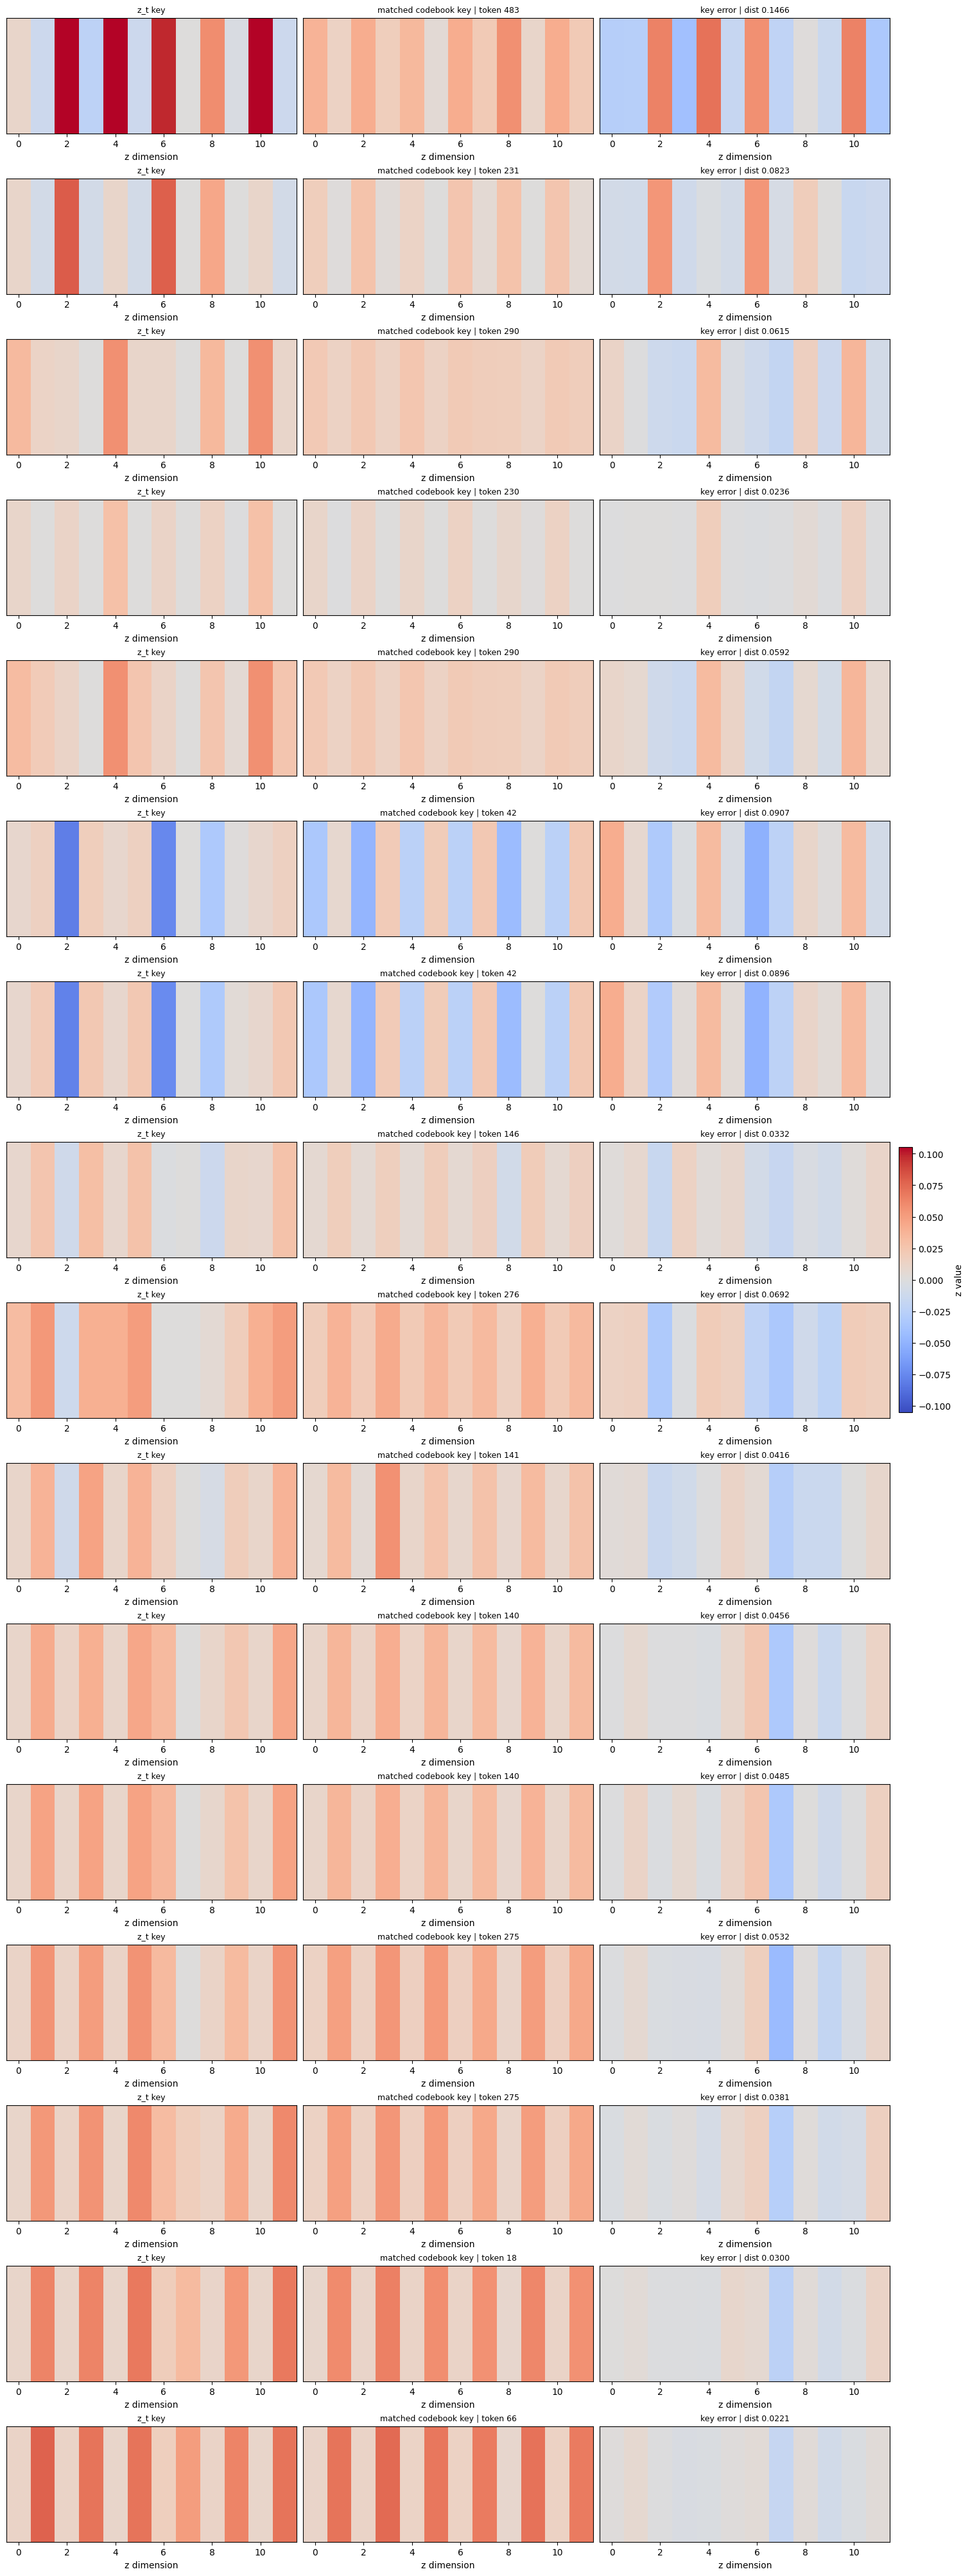

In [234]:
## Map z_t to Motion Token

motion_codebook_table = np.asarray(action_embedding_table, dtype=np.float32)


def map_z_t_to_motion_token(z_t):
    z_t = np.asarray(z_t, dtype=np.float32)

    distances = np.linalg.norm(
        motion_codebook_table - z_t.reshape(1, -1),
        axis=1,
    )

    token_id = int(np.argmin(distances))
    token_distance = float(distances[token_id])
    z_codebook_key = motion_codebook_table[token_id].astype(np.float32)

    return {
        "motion_token_id": token_id,
        "token_distance": token_distance,
        "z_codebook_key": z_codebook_key,
        "distances": distances.astype(np.float32),
    }


probe_token_rows = []

for _, row in probe_z_df.iterrows():
    token_info = map_z_t_to_motion_token(row["z_t"])

    row_dict = row.to_dict()
    row_dict["motion_token_id"] = token_info["motion_token_id"]
    row_dict["token_distance"] = token_info["token_distance"]
    row_dict["z_codebook_key"] = token_info["z_codebook_key"]

    probe_token_rows.append(row_dict)

probe_token_df = pd.DataFrame(probe_token_rows)

print("motion_codebook_table shape:", motion_codebook_table.shape)
print("probe_token_df shape:", probe_token_df.shape)
print("tokens:", probe_token_df["motion_token_id"].tolist())
print("mean token distance:", probe_token_df["token_distance"].mean())

display(
    probe_token_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "motion_token_id",
            "token_distance",
            "z_dim",
        ]
    ]
)


fig, axes = plt.subplots(
    len(probe_token_df),
    3,
    figsize=(15, 2.5 * len(probe_token_df)),
    squeeze=False,
    constrained_layout=True,
)

all_z_true = np.stack(probe_token_df["z_t"].to_numpy()).astype(np.float32)
all_z_codebook = np.stack(probe_token_df["z_codebook_key"].to_numpy()).astype(np.float32)
all_z_error = all_z_true - all_z_codebook

z_abs = max(
    float(np.max(np.abs(all_z_true))),
    float(np.max(np.abs(all_z_codebook))),
    float(np.max(np.abs(all_z_error))),
    1e-8,
)

for row_idx, (_, row) in enumerate(probe_token_df.iterrows()):
    z_t = np.asarray(row["z_t"], dtype=np.float32)
    z_codebook_key = np.asarray(row["z_codebook_key"], dtype=np.float32)
    z_error = z_t - z_codebook_key

    items = [
        ("z_t key", z_t),
        (f"matched codebook key | token {int(row['motion_token_id'])}", z_codebook_key),
        (f"key error | dist {float(row['token_distance']):.4f}", z_error),
    ]

    for col_idx, (title, z) in enumerate(items):
        im = axes[row_idx, col_idx].imshow(
            z.reshape(1, -1),
            cmap="coolwarm",
            aspect="auto",
            interpolation="nearest",
            vmin=-z_abs,
            vmax=z_abs,
        )

        axes[row_idx, col_idx].set_title(title, fontsize=9)
        axes[row_idx, col_idx].set_yticks([])
        axes[row_idx, col_idx].set_xlabel("z dimension")

fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, label="z value")
plt.show()

## Predict z_next

input token seq len: 16
model seq_len: 16
probe_z_next_pred shape: (16, 12)


,episode_id,prev_frame,frame,motion_token_id,token_distance,z_dim,z_next_pred_dim
0,0,0,10,483,0.146631,12,12
1,0,2,12,231,0.082268,12,12
2,0,4,14,290,0.061512,12,12
3,0,6,16,230,0.023599,12,12
4,0,8,18,290,0.059220,12,12
5,0,10,20,42,0.090676,12,12
6,0,12,22,42,0.089561,12,12
7,0,14,24,146,0.033202,12,12
8,0,16,26,276,0.069196,12,12
9,0,18,28,141,0.041630,12,12


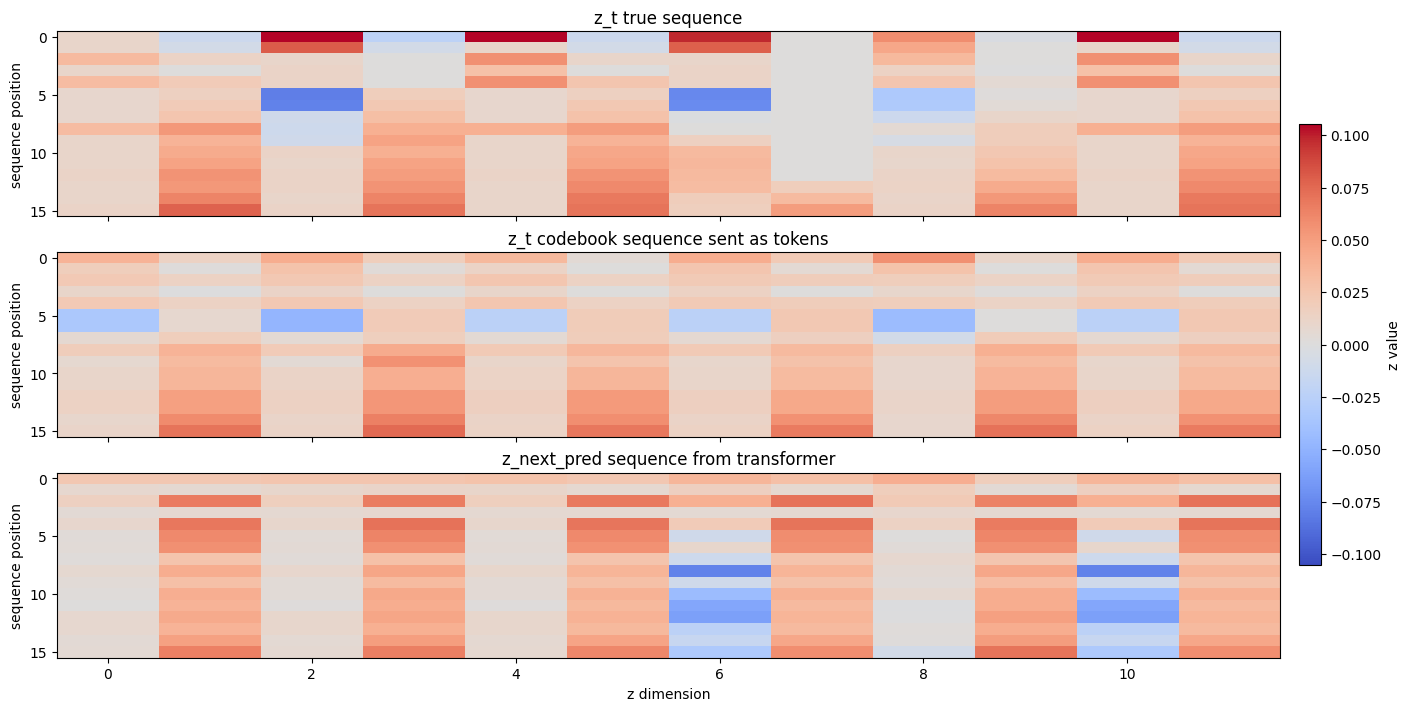

In [235]:
## Predict z_next

def predict_z_next_from_motion_tokens(motion_token_ids):
    motion_token_ids = np.asarray(motion_token_ids, dtype=np.int64)

    if len(motion_token_ids) == 0:
        raise ValueError("motion_token_ids is empty")

    if len(motion_token_ids) > seq_len:
        motion_token_ids = motion_token_ids[-seq_len:]

    x = torch.tensor(
        motion_token_ids[None, :],
        dtype=torch.long,
        device=device,
    )

    model.eval()

    with torch.no_grad():
        z_next_pred = (
            model(x)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

    return z_next_pred[0]


probe_motion_token_ids = probe_token_df["motion_token_id"].to_numpy(dtype=np.int64)

probe_z_next_pred = predict_z_next_from_motion_tokens(
    probe_motion_token_ids
)

probe_z_next_pred_df = probe_token_df.copy()
probe_z_next_pred_df["z_next_pred"] = [
    z for z in probe_z_next_pred
]
probe_z_next_pred_df["z_next_pred_dim"] = [
    int(len(z)) for z in probe_z_next_pred
]

print("input token seq len:", len(probe_motion_token_ids))
print("model seq_len:", seq_len)
print("probe_z_next_pred shape:", probe_z_next_pred.shape)

display(
    probe_z_next_pred_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "motion_token_id",
            "token_distance",
            "z_dim",
            "z_next_pred_dim",
        ]
    ]
)


all_z_t = np.stack(probe_z_next_pred_df["z_t"].to_numpy()).astype(np.float32)
all_z_codebook = np.stack(probe_z_next_pred_df["z_codebook_key"].to_numpy()).astype(np.float32)
all_z_next_pred = np.stack(probe_z_next_pred_df["z_next_pred"].to_numpy()).astype(np.float32)

z_abs = max(
    float(np.max(np.abs(all_z_t))),
    float(np.max(np.abs(all_z_codebook))),
    float(np.max(np.abs(all_z_next_pred))),
    1e-8,
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 7),
    sharex=True,
    constrained_layout=True,
)

items = [
    ("z_t true sequence", all_z_t),
    ("z_t codebook sequence sent as tokens", all_z_codebook),
    ("z_next_pred sequence from transformer", all_z_next_pred),
]

for ax, (title, matrix) in zip(axes, items):
    im = ax.imshow(
        matrix,
        cmap="coolwarm",
        aspect="auto",
        interpolation="nearest",
        vmin=-z_abs,
        vmax=z_abs,
    )

    ax.set_title(title)
    ax.set_ylabel("sequence position")

axes[-1].set_xlabel("z dimension")

fig.colorbar(im, ax=axes, fraction=0.018, pad=0.015, label="z value")

plt.show()

## Predict Action

probe_action_pred shape: (16, 2)


,episode_id,prev_frame,frame,motion_token_id,token_distance,action_main_pred,action_side_pred
0,0,0,10,483,0.146631,0.230514,0.039493
1,0,2,12,231,0.082268,0.209333,-0.172795
2,0,4,14,290,0.061512,-0.655551,0.626927
3,0,6,16,230,0.023599,0.090097,-0.238399
4,0,8,18,290,0.059220,-0.138350,0.278466
5,0,10,20,42,0.090676,-0.137815,-0.449843
6,0,12,22,42,0.089561,0.060617,0.123826
7,0,14,24,146,0.033202,0.049435,-0.507026
8,0,16,26,276,0.069196,-0.894993,-0.972215
9,0,18,28,141,0.041630,0.005525,-0.522497


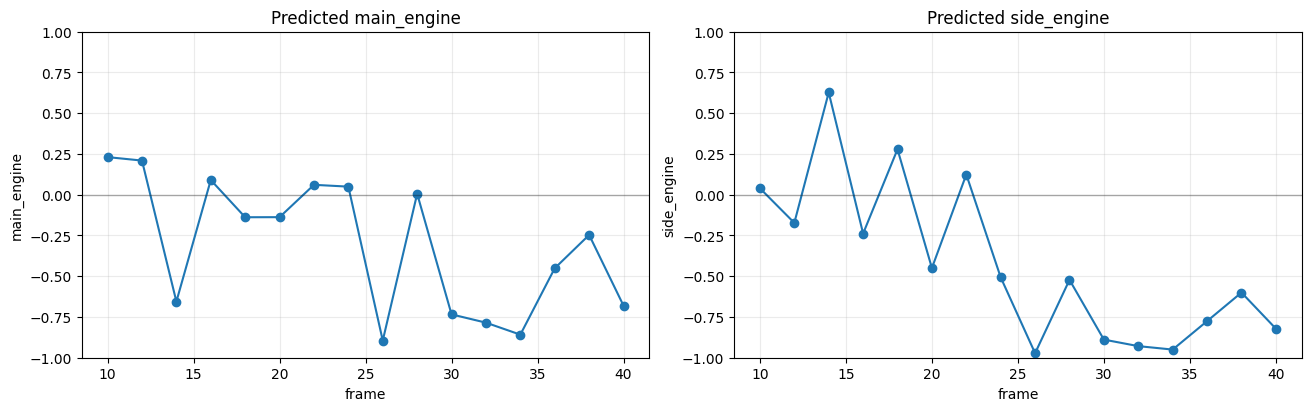

In [236]:
## Predict Action

def predict_action_from_z_next(z_next_pred):
    z_next_pred = np.asarray(z_next_pred, dtype=np.float32)

    if z_next_pred.ndim == 1:
        z_next_pred = z_next_pred[None, :]

    z_next_t = torch.tensor(
        z_next_pred,
        dtype=torch.float32,
        device=DEVICE,
    )

    action_inference_model.eval()

    with torch.no_grad():
        action_pred = (
            action_inference_model(z_next_t)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

    action_pred = np.clip(
        action_pred,
        ENV_ACTION_CLIP_LOW,
        ENV_ACTION_CLIP_HIGH,
    )

    return action_pred


probe_action_pred = predict_action_from_z_next(
    np.stack(probe_z_next_pred_df["z_next_pred"].to_numpy()).astype(np.float32)
)

probe_action_pred_df = probe_z_next_pred_df.copy()

probe_action_pred_df["action_main_pred"] = probe_action_pred[:, 0]
probe_action_pred_df["action_side_pred"] = probe_action_pred[:, 1]

probe_action_pred_df["action_pred"] = [
    np.array([main, side], dtype=np.float32)
    for main, side in zip(
        probe_action_pred_df["action_main_pred"],
        probe_action_pred_df["action_side_pred"],
    )
]

print("probe_action_pred shape:", probe_action_pred.shape)

display(
    probe_action_pred_df[
        [
            "episode_id",
            "prev_frame",
            "frame",
            "motion_token_id",
            "context_len" if "context_len" in probe_action_pred_df.columns else "token_distance",
            "action_main_pred",
            "action_side_pred",
        ]
    ]
)


fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].plot(
    probe_action_pred_df["frame"],
    probe_action_pred_df["action_main_pred"],
    marker="o",
)
axes[0].axhline(0, color="black", linewidth=1, alpha=0.3)
axes[0].set_title("Predicted main_engine")
axes[0].set_xlabel("frame")
axes[0].set_ylabel("main_engine")
axes[0].set_ylim(ENV_ACTION_CLIP_LOW, ENV_ACTION_CLIP_HIGH)
axes[0].grid(alpha=0.25)

axes[1].plot(
    probe_action_pred_df["frame"],
    probe_action_pred_df["action_side_pred"],
    marker="o",
)
axes[1].axhline(0, color="black", linewidth=1, alpha=0.3)
axes[1].set_title("Predicted side_engine")
axes[1].set_xlabel("frame")
axes[1].set_ylabel("side_engine")
axes[1].set_ylim(ENV_ACTION_CLIP_LOW, ENV_ACTION_CLIP_HIGH)
axes[1].grid(alpha=0.25)

plt.show()

## Closed-Loop Run

In [237]:
## Closed-Loop Run

def infer_action_from_cp_bg_transition(
    prev_cp,
    curr_cp,
    prev_bg,
    curr_bg,
    token_context,
    prev_action=None,
    smoothing=0.30,
):
    z_t = build_env_z_t_from_dfs(
        prev_cp=prev_cp,
        curr_cp=curr_cp,
        prev_bg=prev_bg,
        curr_bg=curr_bg,
    )

    if z_t is None:
        action_pred = (
            np.asarray(prev_action, dtype=np.float32)
            if prev_action is not None
            else ENV_BOOTSTRAP_ACTION.copy()
        )

        return {
            "valid": False,
            "z_t": None,
            "motion_token_id": None,
            "token_distance": np.nan,
            "z_codebook_key": None,
            "z_next_pred": None,
            "action_raw_pred": action_pred,
            "action_pred": action_pred,
            "context_len": len(token_context),
            "token_context": list(token_context),
        }

    token_info = map_z_t_to_motion_token(z_t)

    next_token_context = list(token_context)
    next_token_context.append(token_info["motion_token_id"])
    next_token_context = next_token_context[-seq_len:]

    z_next_pred = predict_z_next_from_motion_tokens(
        np.asarray(next_token_context, dtype=np.int64)
    )[-1]

    action_raw_pred = predict_action_from_z_next(
        z_next_pred
    )[0]

    if prev_action is None:
        action_pred = action_raw_pred.copy()
    else:
        action_pred = (
            (1.0 - smoothing) * np.asarray(prev_action, dtype=np.float32)
            + smoothing * action_raw_pred
        ).astype(np.float32)

    action_pred = np.clip(
        action_pred,
        ENV_ACTION_CLIP_LOW,
        ENV_ACTION_CLIP_HIGH,
    ).astype(np.float32)

    return {
        "valid": True,
        "z_t": z_t,
        "motion_token_id": token_info["motion_token_id"],
        "token_distance": token_info["token_distance"],
        "z_codebook_key": token_info["z_codebook_key"],
        "z_next_pred": z_next_pred,
        "action_raw_pred": action_raw_pred,
        "action_pred": action_pred,
        "context_len": len(next_token_context),
        "token_context": next_token_context,
    }


def run_closed_loop_action_inference(
    n_episodes=ENV_N_EPISODES,
    max_steps=ENV_MAX_STEPS,
    seed=ENV_SEED,
    frame_sample_step=ENV_FRAME_SAMPLE_STEP,
    action_smoothing=0.30,
):
    if frame_sample_step is None:
        frame_sample_step = infer_env_frame_sample_step()

    env = make_lunar_env()

    rows = []
    cp_parts = []
    bg_parts = []
    frame_rows = []

    for episode_id in range(n_episodes):
        reset_lunar_env(env, seed=seed + episode_id)

        token_context = []
        cp_by_sample = {}
        bg_by_sample = {}

        prev_action = ENV_BOOTSTRAP_ACTION.copy()
        action = ENV_BOOTSTRAP_ACTION.copy()

        episode_reward = 0.0
        sample_idx = 0

        first_frame = capture_lunar_frame(env)
        bg_points = extract_env_background_points(first_frame)[0]

        for env_step in range(max_steps):
            frame = capture_lunar_frame(env)

            should_sample = env_step % frame_sample_step == 0

            pred = {
                "valid": False,
                "z_t": None,
                "motion_token_id": None,
                "token_distance": np.nan,
                "z_codebook_key": None,
                "z_next_pred": None,
                "action_raw_pred": action,
                "action_pred": action,
                "context_len": len(token_context),
                "token_context": token_context,
            }

            if should_sample:
                cp_df = extract_env_cp_df(
                    frame=frame,
                    episode_id=episode_id,
                    frame_id=sample_idx,
                )

                bg_df = env_background_points_to_df(
                    bg_points,
                    episode_id=episode_id,
                    frame_id=sample_idx,
                )

                cp_by_sample[sample_idx] = cp_df
                bg_by_sample[sample_idx] = bg_df

                cp_parts.append(cp_df)
                bg_parts.append(bg_df)

                if sample_idx >= MOTION_STRIDE:
                    prev_sample_idx = sample_idx - MOTION_STRIDE

                    pred = infer_action_from_cp_bg_transition(
                        prev_cp=cp_by_sample[prev_sample_idx],
                        curr_cp=cp_by_sample[sample_idx],
                        prev_bg=bg_by_sample[prev_sample_idx],
                        curr_bg=bg_by_sample[sample_idx],
                        token_context=token_context,
                        prev_action=prev_action,
                        smoothing=action_smoothing,
                    )

                    token_context = pred["token_context"]
                    action = pred["action_pred"]
                    prev_action = action.copy()

                sample_idx += 1

            obs, reward, done, info = step_lunar_env(
                env,
                action,
            )

            episode_reward += reward

            rows.append(
                {
                    "episode_id": int(episode_id),
                    "env_step": int(env_step),
                    "sample_idx": int(sample_idx - 1) if should_sample else None,
                    "is_sampled_frame": bool(should_sample),
                    "valid_inference": bool(pred["valid"]),
                    "motion_token_id": pred["motion_token_id"],
                    "token_distance": pred["token_distance"],
                    "context_len": int(pred["context_len"]),
                    "action_main_raw_pred": float(pred["action_raw_pred"][0]),
                    "action_side_raw_pred": float(pred["action_raw_pred"][1]),
                    "action_main_pred": float(action[0]),
                    "action_side_pred": float(action[1]),
                    "reward": float(reward),
                    "episode_reward_so_far": float(episode_reward),
                    "done": bool(done),
                    "z_t": pred["z_t"],
                    "z_codebook_key": pred["z_codebook_key"],
                    "z_next_pred": pred["z_next_pred"],
                }
            )

            if ENV_SAVE_FRAMES:
                frame_rows.append(
                    {
                        "episode_id": int(episode_id),
                        "env_step": int(env_step),
                        "sample_idx": int(sample_idx - 1) if should_sample else None,
                        "frame": frame.copy(),
                    }
                )

            if done:
                break

        print(
            f"episode {episode_id + 1}/{n_episodes} | "
            f"steps {env_step + 1} | "
            f"samples {sample_idx} | "
            f"reward {episode_reward:.2f}"
        )

    env.close()

    closed_loop_action_df = pd.DataFrame(rows)

    closed_loop_cp_df = (
        pd.concat(cp_parts, ignore_index=True)
        if len(cp_parts)
        else pd.DataFrame()
    )

    closed_loop_bckg_df = (
        pd.concat(bg_parts, ignore_index=True)
        if len(bg_parts)
        else pd.DataFrame()
    )

    closed_loop_frame_df = pd.DataFrame(frame_rows)

    return (
        closed_loop_action_df,
        closed_loop_cp_df,
        closed_loop_bckg_df,
        closed_loop_frame_df,
    )


closed_loop_action_df, closed_loop_cp_df, closed_loop_bckg_df, closed_loop_frame_df = run_closed_loop_action_inference()

print("closed_loop_action_df shape:", closed_loop_action_df.shape)
print("closed_loop_cp_df shape:", closed_loop_cp_df.shape)
print("closed_loop_bckg_df shape:", closed_loop_bckg_df.shape)
print("closed_loop_frame_df shape:", closed_loop_frame_df.shape)

display(
    closed_loop_action_df[
        [
            "episode_id",
            "env_step",
            "sample_idx",
            "is_sampled_frame",
            "valid_inference",
            "motion_token_id",
            "context_len",
            "action_main_pred",
            "action_side_pred",
            "reward",
            "episode_reward_so_far",
            "done",
        ]
    ].head(40)
)

episode 1/3 | steps 121 | samples 61 | reward -276.04
episode 2/3 | steps 82 | samples 41 | reward -134.42
episode 3/3 | steps 91 | samples 46 | reward -321.29
closed_loop_action_df shape: (294, 18)
closed_loop_cp_df shape: (648, 6)
closed_loop_bckg_df shape: (18648, 5)
closed_loop_frame_df shape: (294, 4)


/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_40938/3182250723.py:225: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(cp_parts, ignore_index=True)


,episode_id,env_step,sample_idx,is_sampled_frame,valid_inference,motion_token_id,context_len,action_main_pred,action_side_pred,reward,episode_reward_so_far,done
0,0,0,0.0,True,False,NaN,0,0.000000,0.000000,1.144981,1.144981,False
1,0,1,NaN,False,False,NaN,0,0.000000,0.000000,1.188060,2.333041,False
2,0,2,1.0,True,False,NaN,0,0.000000,0.000000,1.164770,3.497811,False
3,0,3,NaN,False,False,NaN,0,0.000000,0.000000,1.121927,4.619738,False
4,0,4,2.0,True,False,NaN,0,0.000000,0.000000,1.060037,5.679775,False
5,0,5,NaN,False,False,NaN,0,0.000000,0.000000,0.975665,6.655441,False
6,0,6,3.0,True,False,NaN,0,0.000000,0.000000,0.865521,7.520961,False
7,0,7,NaN,False,False,NaN,0,0.000000,0.000000,0.726925,8.247887,False
8,0,8,4.0,True,False,NaN,0,0.000000,0.000000,0.558489,8.806376,False
9,0,9,NaN,False,False,NaN,0,0.000000,0.000000,0.361250,9.167626,False


## Revier Video

In [238]:
## Review Video

closed_loop_review_video_paths = []

for episode_id in sorted(closed_loop_action_df["episode_id"].unique()):
    episode_action_df = (
        closed_loop_action_df[
            closed_loop_action_df["episode_id"] == episode_id
        ]
        .sort_values("env_step")
        .reset_index(drop=True)
    )

    episode_frame_df = (
        closed_loop_frame_df[
            closed_loop_frame_df["episode_id"] == episode_id
        ]
        .sort_values("env_step")
        .reset_index(drop=True)
    )

    if len(episode_frame_df) == 0:
        continue

    annotated_frames = []

    action_by_step = {
        int(row["env_step"]): row
        for _, row in episode_action_df.iterrows()
    }

    for _, frame_row in episode_frame_df.iterrows():
        env_step = int(frame_row["env_step"])
        image = np.asarray(frame_row["frame"]).copy()

        action_row = action_by_step.get(env_step)

        if action_row is not None:
            text = (
                f"ep {episode_id} | step {env_step} | "
                f"valid {bool(action_row['valid_inference'])} | "
                f"a=[{float(action_row['action_main_pred']):+.2f}, "
                f"{float(action_row['action_side_pred']):+.2f}] | "
                f"R={float(action_row['episode_reward_so_far']):+.1f}"
            )
        else:
            text = f"ep {episode_id} | step {env_step}"

        cv2.putText(
            image,
            text,
            (12, 24),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        annotated_frames.append(image)

    annotated_frames = np.stack(annotated_frames)

    review_video_path = show_video(
        annotated_frames,
        f"closed_loop_action_inference_episode_{int(episode_id):04d}.mp4",
        fps=ENV_REVIEW_VIDEO_FPS,
        embed=True,
    )

    closed_loop_review_video_paths.append(review_video_path)

    print("episode:", int(episode_id))
    print("review video:", review_video_path)

print("review videos:", len(closed_loop_review_video_paths))

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


episode: 0
review video: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/closed_loop_action_inference_episode_0000.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


episode: 1
review video: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/closed_loop_action_inference_episode_0001.mp4


episode: 2
review video: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/closed_loop_action_inference_episode_0002.mp4
review videos: 3


## Rewards Summary

,episode_id,env_steps,total_reward,final_reward_so_far,valid_inference_steps,sampled_frames,mean_action_main,std_action_main,min_action_main,max_action_main,mean_action_side,std_action_side,min_action_side,max_action_side,final_done,valid_inference_ratio
0,0,121,-276.042866,-276.042866,56,61,-0.222049,0.379265,-0.941339,0.353959,-0.051579,0.376119,-0.857113,0.552858,True,0.462810
1,1,82,-134.418817,-134.418817,36,41,-0.158129,0.289932,-0.832348,0.204180,0.205317,0.191304,-0.084321,0.619793,True,0.439024
2,2,91,-321.293760,-321.293760,1,46,0.061555,0.021748,0.000000,0.069154,0.010546,0.003726,0.000000,0.011848,True,0.010989


episodes: 3
mean total reward: -243.91848089516398
median total reward: -276.0428655671467
best total reward: -134.418817017313
worst total reward: -321.2937601010323


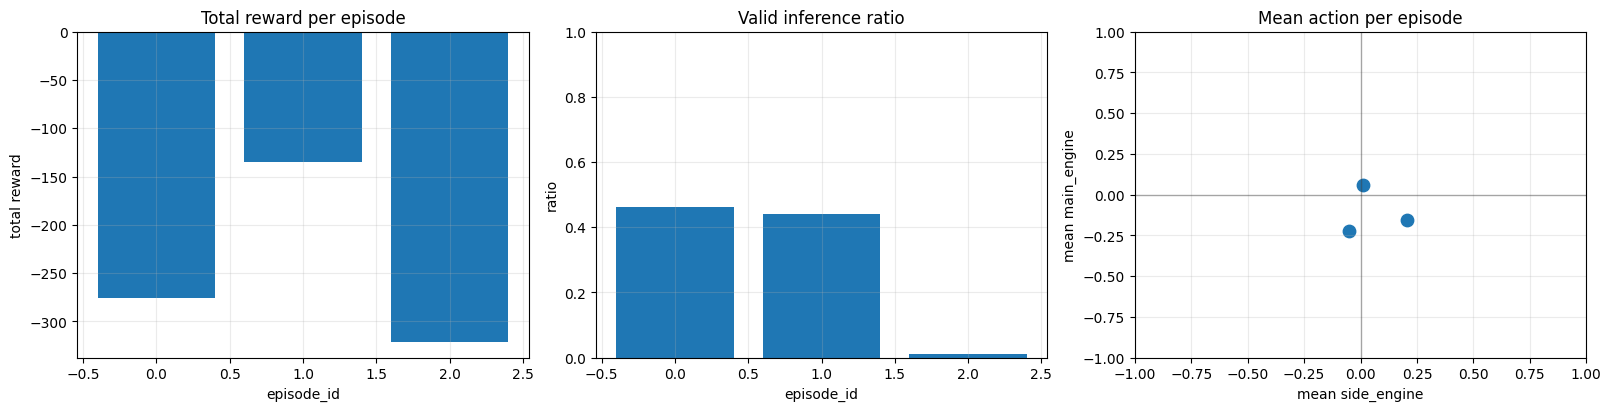

In [239]:
## Rewards Summary

closed_loop_reward_summary_df = (
    closed_loop_action_df
    .groupby("episode_id")
    .agg(
        env_steps=("env_step", "max"),
        total_reward=("reward", "sum"),
        final_reward_so_far=("episode_reward_so_far", "last"),
        valid_inference_steps=("valid_inference", "sum"),
        sampled_frames=("is_sampled_frame", "sum"),
        mean_action_main=("action_main_pred", "mean"),
        std_action_main=("action_main_pred", "std"),
        min_action_main=("action_main_pred", "min"),
        max_action_main=("action_main_pred", "max"),
        mean_action_side=("action_side_pred", "mean"),
        std_action_side=("action_side_pred", "std"),
        min_action_side=("action_side_pred", "min"),
        max_action_side=("action_side_pred", "max"),
        final_done=("done", "last"),
    )
    .reset_index()
)

closed_loop_reward_summary_df["env_steps"] = (
    closed_loop_reward_summary_df["env_steps"] + 1
)

closed_loop_reward_summary_df["valid_inference_ratio"] = (
    closed_loop_reward_summary_df["valid_inference_steps"]
    / closed_loop_reward_summary_df["env_steps"].clip(lower=1)
)

display(closed_loop_reward_summary_df)

print("episodes:", closed_loop_reward_summary_df["episode_id"].nunique())
print("mean total reward:", closed_loop_reward_summary_df["total_reward"].mean())
print("median total reward:", closed_loop_reward_summary_df["total_reward"].median())
print("best total reward:", closed_loop_reward_summary_df["total_reward"].max())
print("worst total reward:", closed_loop_reward_summary_df["total_reward"].min())


fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

axes[0].bar(
    closed_loop_reward_summary_df["episode_id"],
    closed_loop_reward_summary_df["total_reward"],
)
axes[0].set_title("Total reward per episode")
axes[0].set_xlabel("episode_id")
axes[0].set_ylabel("total reward")
axes[0].grid(alpha=0.25)

axes[1].bar(
    closed_loop_reward_summary_df["episode_id"],
    closed_loop_reward_summary_df["valid_inference_ratio"],
)
axes[1].set_title("Valid inference ratio")
axes[1].set_xlabel("episode_id")
axes[1].set_ylabel("ratio")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)

axes[2].scatter(
    closed_loop_reward_summary_df["mean_action_side"],
    closed_loop_reward_summary_df["mean_action_main"],
    s=80,
)
axes[2].axhline(0, color="black", linewidth=1, alpha=0.3)
axes[2].axvline(0, color="black", linewidth=1, alpha=0.3)
axes[2].set_title("Mean action per episode")
axes[2].set_xlabel("mean side_engine")
axes[2].set_ylabel("mean main_engine")
axes[2].set_xlim(ENV_ACTION_CLIP_LOW, ENV_ACTION_CLIP_HIGH)
axes[2].set_ylim(ENV_ACTION_CLIP_LOW, ENV_ACTION_CLIP_HIGH)
axes[2].grid(alpha=0.25)

plt.show()